In [31]:
import setuptools  # Ensures distutils is available
import pyximport
pyximport.install()

(None, None)

In [32]:
from scipy.integrate import trapezoid as trapz
from datetime import datetime
import os
import shutil
import pandas as pd
#!/anaconda3/bin/python
from math import cos, sin, pi, sqrt
from numpy import (
    array, linspace, arange, loadtxt, vectorize, pi as npi, exp, zeros,
    empty, log, log2, finfo, true_divide, asarray, where, partition, isnan, nan,
    ones, argmax, argmin, set_printoptions, diagonal, round, inf,concatenate, sin, cos
    )
import imageio
from numpy.random import random
from scipy.integrate import trapezoid as trapz
from scipy.signal import correlate2d
from matplotlib import rcParams, rc, ticker, colors, cm
from matplotlib.style import use
from matplotlib.pyplot import subplots, close
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from os import getcwd
from datetime import datetime
import os
from matplotlib.patches import Rectangle
import matplotlib.font_manager as font_manager
import pyximport
import numpy as np
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit, fsolve
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib


In [33]:
# Install setuptools to resolve the distutils issue
%pip install setuptools

import pyximport
pyximport.install()

from utilities import (
    calc_flux #, calc_learning_rate
    )

DEPRECATION: Loading egg at /Users/sarealles/Desktop/Data/code/.venv/lib/python3.12/site-packages/Cython-3.1.0a0-py3.12-macosx-14.0-arm64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
l_title_s = 11
l_entry_s = 10
ticks_size = 11
fs = 12
ts = 13
ms = 3
off_text_size = 11

In [35]:
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica']})
rc('text', usetex=True)

In [36]:
def infinite_eff(psi_0,psi_1,n0,n1,model):
    '''gets the psi_0/1 that is applied to model 1,3 
    (dont divide it for mod 2,4 before hand)'''
    
    if model=="model1":
        if abs(psi_0)>abs(psi_1):
            eff = - psi_1/psi_0
        else:
            eff = - psi_0/psi_1
    if model == "model2":
        if abs(n0*psi_0/8)>abs(n1*psi_1/3):
            eff = - (n1*psi_1/3)/(n0*psi_0/8)
        elif abs(n0*psi_0/8)==abs(n1*psi_1/3):
            eff =-1
        else:
            eff = - ((n0*psi_0/8)/(n1*psi_1/3))
    if model=="model3":
        X2 = (psi_0*((n1*psi_0/n0) + psi_1))
        X1 =(psi_1*(psi_0 + (n0*psi_1/n1)))
        if X2 != 0:
            if abs(psi_0/n0)>abs(psi_1/n1):
                eff = - X1/X2
            else:
                eff = - (X1/X2)**(-1)
        else:
            eff = 0
    if model == "model4":
        psi_0 = psi_0*n0/8
        psi_1 = psi_1*n1/3
        
        X2 = (psi_0*((n1*psi_0/n0) + psi_1))
        X1 =(psi_1*(psi_0 + (n0*psi_1/n1)))
        if X2 != 0:
            if abs(psi_0/n0)>abs(psi_1/n1):
                eff = - X1/X2
            else:
                eff = - (X1/X2)**(-1)
        else:
            eff = 0
            
        # eff = ["undefined" if x == -1 else x for x in eff]
    return eff

In [37]:
def set_params(model, n0,n1,f0,f1=-2.0,E0=2.0,E1=2.0):
    N = 100
    
     # energy scale of Fo
    Ecouple = 20.0 # energy scale of coupling between Fo and F1


    psi_0 = f0
    psi_1 = f1
    psi_0_n = f0
    psi_1_n = f1
    
    if model =="model4" or model =="model2" or model=="BFM":
        psi_0_n = n0*psi_0/8
        psi_1_n = n1*psi_1/3
        

    

    m0 = 1.0
    m1 = 1.0
    beta = 1.0
    gamma = 1000.0
    phase = 0.0

    

    return (
        E0, Ecouple, E1,  psi_0, psi_1, psi_0_n, psi_1_n, 
        n0, n1,
        m0, m1, phase,beta, gamma, model
        ) 

def set_params_Fo_4(model,n0,n1,E0,E1):

    N = 100
    
    # E0 = 2.0 # energy scale of Fo
    Ecouple = 20.0 # energy scale of coupling between Fo and F1
    # E1 = 2.0

    psi_0 = 4.0
    psi_1 = -2.0
    psi_0_n = 4.0
    psi_1_n = -2.0
    
    if model =="model4" or model =="model2":
        psi_0_n = n0*psi_0/8
        psi_1_n = n1*psi_1/3
        

    

    m0 = 1.0
    m1 = 1.0
    beta = 1.0
    gamma = 1000.0
    phase = 0.0

    

    return (
        E0, Ecouple, E1,  psi_0, psi_1, psi_0_n, psi_1_n, 
        n0, n1,
        m0, m1, phase,beta, gamma, model
        ) 

def set_params_Fo_2(model,n0,n1,E0,E1):

    N = 100
    
    # E0 = 2.0 # energy scale of Fo
    Ecouple = 20.0 # energy scale of coupling between Fo and F1
    # E1 = 2.0

    psi_0 = 2.0
    psi_1 = -2.0
    psi_0_n = 2.0
    psi_1_n = -2.0
    
    if model =="model4" or model =="model2":
        psi_0_n = n0*psi_0/8
        psi_1_n = n1*psi_1/3
        

    

    m0 = 1.0
    m1 = 1.0
    beta = 1.0
    gamma = 1000.0
    phase = 0.0
    
    return (
        E0, Ecouple, E1,  psi_0, psi_1, psi_0_n, psi_1_n, 
        n0, n1,
        m0, m1, phase,beta, gamma, model
        ) 
def set_params_Fo_3(model,n0,n1,E0,E1):

    N = 100
    
    # E0 = 2.0 # energy scale of Fo
    Ecouple = 20.0 # energy scale of coupling between Fo and F1
    # E1 = 2.0

    psi_0 = 3.0
    psi_1 = -2.0
    psi_0_n = 3.0
    psi_1_n = -2.0
    
    if model =="model4" or model =="model2":
        psi_0_n = n0*psi_0/8
        psi_1_n = n1*psi_1/3
        

    

    m0 = 1.0
    m1 = 1.0
    beta = 1.0
    gamma = 1000.0
    phase = 0.0

    

    return (
        E0, Ecouple, E1,  psi_0, psi_1, psi_0_n, psi_1_n, 
        n0, n1,
        m0, m1, phase,beta, gamma, model
        ) 
def set_params_Fo_5(model,n0,n1,E0,E1):

    N = 100
    
    # E0 = 2.0 # energy scale of Fo
    Ecouple = 20.0 # energy scale of coupling between Fo and F1
    # E1 = 2.0

    psi_0 = 5.0
    psi_1 = -2.0
    psi_0_n = 5.0
    psi_1_n = -2.0
    
    if model =="model4" or model =="model2":
        psi_0_n = n0*psi_0/8
        psi_1_n = n1*psi_1/3
        

    

    m0 = 1.0
    m1 = 1.0
    beta = 1.0
    gamma = 1000.0
    phase = 0.0

    

    return (
        E0, Ecouple, E1,  psi_0, psi_1, psi_0_n, psi_1_n, 
        n0, n1,
        m0, m1, phase,beta, gamma, model
        ) 
def set_params_Fo_6(model,n0,n1,E0,E1):

    N = 100
    
    # E0 = 2.0 # energy scale of Fo
    Ecouple = 20.0 # energy scale of coupling between Fo and F1
    # E1 = 2.0

    psi_0 = 6.0
    psi_1 = -2.0
    psi_0_n = 6.0
    psi_1_n = -2.0
    
    if model =="model4" or model =="model2":
        psi_0_n = n0*psi_0/8
        psi_1_n = n1*psi_1/3
        

    

    m0 = 1.0
    m1 = 1.0
    beta = 1.0
    gamma = 1000.0
    phase = 0.0

    

    return (
        E0, Ecouple, E1,  psi_0, psi_1, psi_0_n, psi_1_n, 
        n0, n1,
        m0, m1, phase,beta, gamma, model
        ) 
def set_params_Fo_7(model,n0,n1,E0,E1):

    N = 100
    
    # E0 = 2.0 # energy scale of Fo
    Ecouple = 20.0 # energy scale of coupling between Fo and F1
    # E1 = 2.0

    psi_0 = 7.0
    psi_1 = -2.0
    psi_0_n = 7.0
    psi_1_n = -2.0
    
    if model =="model4" or model =="model2":
        psi_0_n = n0*psi_0/8
        psi_1_n = n1*psi_1/3
        

    

    m0 = 1.0
    m1 = 1.0
    beta = 1.0
    gamma = 1000.0
    phase = 0.0

    

    return (
        E0, Ecouple, E1,  psi_0, psi_1, psi_0_n, psi_1_n, 
        n0, n1,
        m0, m1, phase,beta, gamma, model
        )        
def set_params_Fo_8(model,n0,n1,E0,E1):

    N = 500
    
    # E0 = 2.0 # energy scale of Fo
    Ecouple = 20.0 # energy scale of coupling between Fo and F1
    # E1 = 2.0

    psi_0 = 8.0
    psi_1 = -2.0
    psi_0_n = 8.0
    psi_1_n = -2.0
    
    if model =="model4" or model =="model2":
        psi_0_n = n0*psi_0/8
        psi_1_n = n1*psi_1/3
        

    

    m0 = 1.0
    m1 = 1.0
    beta = 1.0
    gamma = 1000.0
    phase = 0.0

    

    return (
        E0, Ecouple, E1,  psi_0, psi_1, psi_0_n, psi_1_n, 
        n0, n1,
        m0, m1, phase,beta, gamma, model
        ) 
    
def set_params_Fo_0(model,n0,n1,E0,E1):

    N = 500
    
    # E0 = 0.0 # energy scale of Fo
    Ecouple = 0.0 # energy scale of coupling between Fo and F1
    # E1 = 0.0

    psi_0 = 0.0
    psi_1 = -0.0
    psi_0_n = 0.0
    psi_1_n = -0.0


    m0 = 1.0
    m1 = 1.0
    beta = 1.0
    gamma = 1000.0
    phase = 0.0

    

    return (
        E0, Ecouple, E1,  psi_0, psi_1, psi_0_n, psi_1_n, 
        n0, n1,
        m0, m1, phase,beta, gamma, model
        ) 

In [38]:
def move_files_and_create_dataframe(source_folder, destination_folder, n0, n1,psi0,model):
    # Create the destination folder if it doesn't exist
    os.makedirs(destination_folder, exist_ok=True)
    
    # Create the subfolder based on n0 and n1
    subfolder = os.path.join(destination_folder, f"{int(n0)}_{int(n1)}")
    os.makedirs(subfolder, exist_ok=True)
    
    # Get the list of files in the source folder
    files = os.listdir(source_folder)
    
    # Initialize lists to store the Ec values, square root of the number of rows, model, psi_0, and psi_1
    ec_values = []
    sqrt_num_rows = []
    models = []
    psi_0_values = []
    psi_1_values = []
    n0_values = []
    n1_values = []
    dt_values = []
    
    # Set to keep track of processed file names
    processed_files = set()
    
    # Iterate over the files
    for file_name in files:
        if model in file_name:
            if f"psi0_{psi0}" in file_name:
        # Check if the file matches the pattern and has not been processed before
                if f"n0_{n0}_n1_{n1}" in file_name and file_name not in processed_files:
                    # Move the file to the subfolder
                    source_path = os.path.join(source_folder, file_name)
                    print(source_path)
                    destination_path = os.path.join(subfolder, file_name)
                    shutil.copy(source_path, destination_path)
                    #print(f"File '{file_name}' copied to '{subfolder}'")
                    
                    # Count the number of rows in the file
                    # with open(destination_path, 'r') as file:
                    #     num_rows = sum(1 for line in file)
                    #     sqrt_num_rows.append(np.sqrt(num_rows))
                    #     #print(f"N: {sqrt_num_rows[-1]}")
                    try:
                        with open(destination_path, 'r') as file:
                            num_rows = sum(1 for line in file)
                            sqrt_num_rows.append(np.sqrt(num_rows))
                    except UnicodeDecodeError:
                        print(f"UnicodeDecodeError occurred with file: {destination_path}")
                        continue  # Move to the next file
                    
                    # Extract the Ec value from the file name
                    ec_value = float(file_name.split("_Ecouple_")[1].split("_")[0])
                    if "dt" in file_name:
                        dt = float(file_name.split("_dt_")[1].split("_")[0])
                        print(fr"{file_name[:6]}, n0={n0},n1={n1},N={np.sqrt(num_rows)},EC={ec_value},dt={dt}")
                    else:
                        print(fr"{file_name[:6]}, n0={n0},n1={n1},N={np.sqrt(num_rows)},EC={ec_value}")
                    
                    # Extract the model, psi_0, and psi_1 from the file name
                    model = file_name.split("_")[0]
                    psi_0 = float(file_name.split("_psi0_")[1].split("_")[0])
                    psi_1 = float(file_name.split("_psi1_")[1].split("_")[0])
                    
                    # Append the values to the respective lists
                    ec_values.append(ec_value)
                    models.append(model)
                    psi_0_values.append(psi_0)
                    psi_1_values.append(psi_1)
                    n0_values.append(n0)
                    n1_values.append(n1)
                    if "dt" in file_name:
                        dt = float(file_name.split("_dt_")[1].split("_")[0])
                        print(fr"{file_name[:6]}, n0={n0},n1={n1},N={np.sqrt(num_rows)},EC={ec_value},dt={dt}")
                        dt_values.append(dt)
                    else:
                        dt_values.append(0.001)
                        print(fr"{file_name[:6]}, n0={n0},n1={n1},N={np.sqrt(num_rows)},EC={ec_value}")
                    
                    # Add the file name to the processed files set
                    processed_files.add(file_name)
    # Create a pandas DataFrame with the Ec values, square root of the number of rows, model, psi_0, and psi_1
    df = pd.DataFrame({"n0": n0_values, "n1": n1_values, 'Model': models, 'Ec': ec_values, 'SqrtNumRows': sqrt_num_rows, 'Psi_0': psi_0_values, 'Psi_1': psi_1_values, 'dt': dt_values})
    # Check if the CSV file already exists
    csv_file_path = os.path.join(destination_folder, f"{int(n0)}_{int(n1)}.csv")
    if os.path.exists(csv_file_path):
        # Read the existing CSV file
        existing_df = pd.read_csv(csv_file_path)
        
        # Check if the contents of the CSV file are the same as the data to be added
        if existing_df.equals(df):
            print(f"Skipping file '{file_name}' as it already exists with the same data")
        else:
            # Append the new data to the existing CSV file
            combined_df = pd.concat([existing_df, df], ignore_index=True)
            combined_df.to_csv(csv_file_path, index=False)
            print(f"Data appended to '{csv_file_path}'")
    else:
        df.to_csv(os.path.join(destination_folder, f'{int(n0)}_{int(n1)}.csv'), index=False)

    
    return df


In [39]:
####Copies files from downloaded folder to specific direction#####
n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0]
# n0_array = [1.0,2.0,3.0,4.0,5.0,6,7.0,8.0,9.0,20.0]


# n1_array = [1.0,2.0,3.0,4.0,5.0,6,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0]

# target_dir = "/Users/sarealles/Desktop/model1/data_N_360/cluster/"
# target_dir_out = "/Users/sarealles/Desktop/model1/data_N_360/cluster/"

# target_dir = "/Volumes/Sara/Data_unprocessed/"
# target_dir_out = "/Volumes/Sara/Data/Data_processed/"

# target_dir = "/Users/sarealles/Desktop/model1/data_N_100"
# target_dir_out = "/Users/sarealles/Desktop/model1/data_N_100"

# target_dir = "/Users/sarealles/Desktop/model2/data_540_probably_previously_downloaded_somewhere/f0_8"
# target_dir_out = "/Users/sarealles/Desktop/model2/data_540_probably_previously_downloaded_somewhere/f0_8/moved"



target_dir = "/Users/sarealles/Desktop/model1/DF_vs_Ec"
target_dir_out = "/Users/sarealles/Desktop/model1/DF_vs_Ec"

target_dir = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_0"
target_dir_out = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_0/f0_4/moved"

target_dir = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_1/rest"
target_dir_out = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_1/f0_4/moved"

target_dir = "/Users/sarealles/Desktop/model1/DF_vs_Ec"
target_dir_out = "/Users/sarealles/Desktop/model1/DF_vs_Ec"

target_dir = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_3/f0_8"
target_dir_out = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_3/f0_8/moved"

target_dir = "/Users/sarealles/Desktop/model1/test_n0_5_vs_n0_5"
target_dir = "/Users/sarealles/Desktop/model1/test_n0_5_vs_n0_5/moved"

target_dir = "/Users/sarealles/Desktop/model1/test_n0_5_vs_n1_7"
target_dir_out = "/Users/sarealles/Desktop/model1/test_n0_5_vs_n1_7/moved"

target_dir = "/Users/sarealles/Desktop/model3/test"
target_dir_out = "/Users/sarealles/Desktop/model3/test/moved"

# target_dir = "/Volumes/Sara/model1/data_N_1000"
# target_dir_out = "/Volumes/Sara/model1/data_N_1000/moved_files"

# target_dir = "/Users/sarealles/Desktop/dt_dx_cluster/dt_0.01/N_100"
# target_dir_out = "/Users/sarealles/Desktop/dt_dx_cluster/dt_0.01/N_100"

# input_file_name = (
#         "/"+model+"_t_reference_E0_{0}_Ecouple_{1}_E1_{2}_psi0_{3}_psi1_{4}_n0_{5}_n1_{6}_phase_{7}_outfile.dat")
#     output_file_name = (
#         "/"+model+"_flux_power_efficiency_"
#         + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat"
#         )

n1_array = [3.0]
n0_array=[1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0]
# n0_array=[25.0,26.0,27.0,28.0,29.0,30.0]
# n0_array=[.0]
psi0= 4.0

for n0 in n0_array:
    for n1 in n1_array:
        move_files_and_create_dataframe(target_dir, target_dir_out, n0, n1, psi0, "model3")


/Users/sarealles/Desktop/model3/test/model3_t_reference_E0_0.0_Ecouple_10.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_1.0_n1_3.0_phase_0.0_outfile.dat
model3, n0=1.0,n1=3.0,N=1000.0,EC=10.0
model3, n0=1.0,n1=3.0,N=1000.0,EC=10.0
/Users/sarealles/Desktop/model3/test/model3_t_reference_E0_0.0_Ecouple_1.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_1.0_n1_3.0_phase_0.0_outfile.dat
model3, n0=1.0,n1=3.0,N=1000.0,EC=1.0
model3, n0=1.0,n1=3.0,N=1000.0,EC=1.0
Skipping file 'model3_t_reference_E0_2.0_Ecouple_12.0_E1_2.0_psi0_8.0_psi1_-2.0_n0_2.0_n1_3.0_phase_0.0_outfile.dat' as it already exists with the same data
/Users/sarealles/Desktop/model3/test/model3_t_reference_E0_0.0_Ecouple_1.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_2.0_n1_3.0_phase_0.0_outfile.dat
model3, n0=2.0,n1=3.0,N=1000.0,EC=1.0
model3, n0=2.0,n1=3.0,N=1000.0,EC=1.0
/Users/sarealles/Desktop/model3/test/model3_t_reference_E0_0.0_Ecouple_0.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_2.0_n1_3.0_phase_0.0_outfile.dat
model3, n0=2.0,n1=3.0,N=1000.0,EC=0.0
model3, n0=2.0,n1=3.0,N=10

### calculate flux,power,efficiency

!!!!!!!!!!!!!!!!change the efficiency part!!!!!!!!!!!

In [40]:
def calculate_flux_power_and_efficiency(target_dir,target_dir_out,Ecouple_array, params, N_array,dt=0.001):

    [
        E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, n0, n1,
        m0, m1, phase,beta, gamma,model
        ] = params

    
    input_file_name = (
        "/"+model+"_t_reference_E0_{0}_Ecouple_{1}_E1_{2}_psi0_{3}_psi1_{4}_n0_{5}_n1_{6}_phase_{7}_outfile.dat")
    output_file_name = (
        "/"+model+"_flux_power_efficiency_"
        + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat"
        )
    
    # input_file_name = (
    #     "/"+model+"_dt_{8}_N_{9}"+"_reference_E0_{0}_Ecouple_{1}_E1_{2}_psi0_{3}_psi1_{4}_n0_{5}_n1_{6}_phase_{7}_outfile.dat")
    # output_file_name = (
    #     "/"+model+"_dt_{7}_N_{8}"+"_flux_power_efficiency_"
    #     + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat"
    #     )

    #psi_0*nm0/8.0

    efficiency_ratio_mod = []
    
    #l = Ecouple_array.size
    l = len(Ecouple_array)

    integrate_flux_X = empty(l)
    integrate_flux_Y = empty(l)
    integrate_power_X = empty(l)
    integrate_power_Y = empty(l)
    efficiency_ratio = empty(l)
    
    
    for ii, Ec in enumerate(Ecouple_array):

        N = int(N_array[ii])
        dx = 2*pi/N
        positions = linspace(0.0,2*pi-dx,N)
        
    
        flux_array = empty((2,N,N))
        if "dt" in input_file_name:
            data_array = loadtxt(
                target_dir + input_file_name.format(
                    E0,Ec,E1, psi_0, psi_1,n0,n1,phase,dt,N
                    ), usecols=(0,3,4,5,6,7,8)
            )
        else:
            try:
                data_array = loadtxt(
                    target_dir + input_file_name.format(
                        E0,Ec,E1, psi_0, psi_1,n0,n1,phase
                        ), usecols=(0,3,4,5,6,7,8)
                )
            except:
                continue
    
        
        prob_ss_array = data_array[:,0].reshape((N,N))
        print("normalized?",prob_ss_array.sum(axis=None))
        drift_at_pos = data_array[:,1:3].T.reshape((2,N,N))
        diffusion_at_pos = data_array[:,3:].T.reshape((4,N,N))
    
        
        calc_flux(
            positions,prob_ss_array, drift_at_pos, 
            diffusion_at_pos, flux_array, N,dx
            )

        flux_array = asarray(flux_array)/(dx*dx)

        integrate_flux_X[ii] = (1./(2*pi))*trapz(trapz(flux_array[0,...], dx=dx, axis=1), dx=dx)
        integrate_flux_Y[ii] = (1./(2*pi))*trapz(trapz(flux_array[1,...], dx=dx, axis=0), dx=dx)  
        '''You’re not averaging over the entire area of the 2D domain (which would need (2\pi)^2), but rather you’re computing the net average flux per 2π rotation of one motor
        (e.g., per full cycle of \theta_{\rm o})'''
        integrate_power_X[ii] = integrate_flux_X[ii]*psi_0_n
        integrate_power_Y[ii] = integrate_flux_Y[ii]*psi_1_n
        
        # efficiency_ratio_mod.append(0)
        if (abs(integrate_power_X[ii]) <= abs(integrate_power_Y[ii])):
            #print("X")
            efficiency_ratio_mod.append(-(integrate_power_X[ii]/integrate_power_Y[ii]))
        else:
            efficiency_ratio_mod.append(-(integrate_power_Y[ii]/integrate_power_X[ii]))
            #print("Y")
        
            
        
    efficiency_ratio = np.zeros(len(integrate_power_Y))   
    if (abs(psi_0_n) <= abs(psi_1_n)):
        efficiency_ratio = -(integrate_power_X/integrate_power_Y)
    else:
        efficiency_ratio = -(integrate_power_Y/integrate_power_X)
        
    
    
    print(model + " n0 = {0} n1= {1} f0= {2:.2f}, <j0>={3}".format(n0,n1,psi_0_n, [format(value, ".14e") for value in integrate_flux_X]))
    print(model + " n0 = {0} n1= {1} f1= {2:.2f}, <j1>={3}".format(n0,n1,psi_1_n, [format(value, ".14e") for value in integrate_flux_Y]))

    print("-------------------------------------------------------------------------------------")
    
    if "dt" in input_file_name:
        print("error",N_array)
        with open(
        target_dir_out + output_file_name.format(
            E0,E1, psi_0, psi_1,n0,n1,phase,dt,int(N_array[0])
            ), "w"
            ) as ofile:
            for ii, Ec in enumerate(Ecouple_array):

                ofile.write(
                    f"{Ec:.15e}" + "\t"
                    + f"{integrate_flux_X[ii]:.15e}" + "\t"
                    + f"{integrate_flux_Y[ii]:.15e}" + "\t" 
                    + f"{integrate_power_X[ii]:.15e}" + "\t"
                    + f"{integrate_power_Y[ii]:.15e}" + "\t"
                    + f"{efficiency_ratio[ii]:.15e}" + "\t"
                    + f"{efficiency_ratio_mod[ii]:.15e}" + "\n"
                )
            ofile.flush()
    else:
        
        with open(
        target_dir_out + output_file_name.format(
            E0,E1, psi_0, psi_1,n0,n1,phase
            ), "w"
            ) as ofile:
            for ii, Ec in enumerate(Ecouple_array):

                ofile.write(
                    f"{Ec:.15e}" + "\t"
                    + f"{integrate_flux_X[ii]:.15e}" + "\t"
                    + f"{integrate_flux_Y[ii]:.15e}" + "\t" 
                    + f"{integrate_power_X[ii]:.15e}" + "\t"
                    + f"{integrate_power_Y[ii]:.15e}" + "\t"
                    + f"{efficiency_ratio[ii]:.15e}" + "\t"
                    + f"{efficiency_ratio_mod[ii]:.15e}" + "\n"
                )
            print("saved",ofile)
            ofile.flush()
        ofile.close()
        with open(target_dir_out + output_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase), "r") as ofile:
            first_line = ofile.readline()
            print(first_line)
    

        
        
        # ofile.flush()


<>:77: SyntaxWarning: invalid escape sequence '\p'
<>:77: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_8836/2124069929.py:77: SyntaxWarning: invalid escape sequence '\p'
  '''You’re not averaging over the entire area of the 2D domain (which would need (2\pi)^2), but rather you’re computing the net average flux per 2π rotation of one motor


In [41]:
'''calculate flux and power from reference file
be careful of the fo and f1 you're analyzing
#change the target_dir and params to evaluate different parameter data. 66,4 
# change N_array_full_fo_8 based on f0 (=4 or =8)
#chenge the input file name in the function if youre working with dt,N specific files'''
# n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0]
n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0]
# n0_array = [17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0]
n1_array = [3.0]
#model_array = ["model1","model2","model3","model4"]
model_array = ["model3"]

# target_dir = "/Volumes/Sara/Data/Data_processed/"
# target_dir_out = "/Users/sarealles/Desktop/Data_processed/pfe/" #be careful of the fo and f1 you're analyzing
# target_dir = "/Users/sarealles/Desktop/dt_dx_cluster/dt_0.01/N_100/"
# target_dir_out = "/Users/sarealles/Desktop/dt_dx_cluster/dt_0.01/N_100/pfe/"
# /Users/sarealles/Desktop/model1/data_N_360/cluster/pfe

# target_dir = "/Users/sarealles/Desktop/model1/data_N_360/cluster/"
# target_dir_out = "/Users/sarealles/Desktop/model1/data_N_360/cluster/pfe/"

# target_dir = "/Users/sarealles/Desktop/model1/data_N_100/Normalized_p/"
# target_dir_out = "/Users/sarealles/Desktop/model1/data_N_100/Normalized_p/pfe/"

# target_dir = "/Users/sarealles/Desktop/model1/data_N_100/"
# target_dir_out = "/Users/sarealles/Desktop/model1/data_N_100/pfe/"



#For the N=1000 data#
# target_dir = "/Volumes/Sara/model1/data_N_1000/moved_files/"
# target_dir_out = "/Users/sarealles/Desktop/model1/data_N_1000/pfe/"
# target_dir="/Users/sarealles/Desktop/model2/data_540_probably_previously_downloaded_somewhere/f0_8/moved/"
# target_dir_out="/Users/sarealles/Desktop/model2/data_540_probably_previously_downloaded_somewhere/f0_8/moved/pfe/"

# target_dir = "/Users/sarealles/Desktop/model2/new_data_540_CM/f0_2/moved/"
# target_dir_out = "/Users/sarealles/Desktop/model2/new_data_540_CM/f0_2/pfe/"





target_dir = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_1/f0_4/moved/"
target_dir_out = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_1/f0_4/moved/pfe/"

target_dir = "/Users/sarealles/Desktop/model1/DF_vs_Ec/"
target_dir_out = "/Users/sarealles/Desktop/model1/DF_vs_Ec/pfe/"

target_dir = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_3/f0_8/moved/"
target_dir_out = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_3/f0_8/moved/pfe/"

target_dir = "/Users/sarealles/Desktop/model1/test_n0_5_vs_n1_7/moved/"
target_dir_out = "/Users/sarealles/Desktop/model1/test_n0_5_vs_n1_7/pfe/"

target_dir = "/Users/sarealles/Desktop/model3/test/moved/"
target_dir_out = "/Users/sarealles/Desktop/model3/test/pfe/"

psi_0 = 4.0
dt=0.001
J0_end = []
J1_end = []
n0_array=[1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0]
# n0_array=[12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0]
# n0_array=[9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0]

# n0_array=[8.0]

for n1 in n1_array:
    for n0 in n0_array:
        # n0n1_str = "n0"+"_"+str(n0)+"_"+"n1"+"_"+ str(n1)
        n0n1_str = str(int(n0))+"_"+str(int(n1))
        
        for model in model_array:
            df_file_path = target_dir + f'{int(n0)}_{int(n1)}.csv'
            print(df_file_path)
            if not os.path.exists(df_file_path):
                print(f"DataFrame file for n0={n0}, n1={n1} does not exist. Skipping...")
                continue

            df = pd.read_csv(df_file_path)
            # Filter the DataFrame based on n0, n1, model, and psi_0
            filtered_df = df[(df['n0'] == n0) & (df['n1'] == n1) & (df['Model'] == model) & (df['Psi_0'] == psi_0)]

            # Get the Ec and N values
            Ecouple_array = filtered_df['Ec'].values
            N_array = filtered_df['SqrtNumRows'].values
            # dt_array = filtered_df['dt'].values
            
            # if len(Ecouple_array) == 0 or len(N_array) == 0:
            #     print(f"No data available for n0={n0}, n1={n1}, model={model}, and psi_0={psi_0}. Skipping...")
            #     continue
            sorted_indices = np.argsort(Ecouple_array)
            Ec_array_sorted = Ecouple_array[sorted_indices]
            N_array_sorted = N_array[sorted_indices]

            print(Ec_array_sorted)
            print(N_array_sorted)

            '''changing E0,E1 to match E0=1,2,3....'''
            params = set_params(model, n0,n1,psi_0,E0=0.0,E1=0.0)
            # print(params)

            
            print(os.path.exists(target_dir_out + n0n1_str))
            if not os.path.exists(target_dir_out + n0n1_str):
                print("were here")
                os.makedirs(target_dir_out + n0n1_str)
            calculate_flux_power_and_efficiency(target_dir + n0n1_str ,target_dir_out + n0n1_str,Ec_array_sorted, params, N_array_sorted,dt)
            #Ec_array = Ec_array_full.get(key,[])
        

/Users/sarealles/Desktop/model3/test/moved/1_3.csv
[ 1. 10.]
[1000. 1000.]
True
normalized? 1.0000000000008087
normalized? 1.0000000000024996
model3 n0 = 1.0 n1= 3.0 f0= 4.00, <j0>=['6.25668225350351e-04', '4.77136711856046e-04']
model3 n0 = 1.0 n1= 3.0 f1= -2.00, <j1>=['-2.88636325522806e-04', '1.56963975410249e-04']
-------------------------------------------------------------------------------------
saved <_io.TextIOWrapper name='/Users/sarealles/Desktop/model3/test/pfe/1_3/model3_flux_power_efficiency_E0_0.0_E1_0.0_psi0_4.0_psi1_-2.0_n0_1.0_n1_3.0_phase_0.0_outfile.dat' mode='w' encoding='UTF-8'>
1.000000000000000e+00	6.256682253503512e-04	-2.886363255228065e-04	2.502672901401405e-03	5.772726510456129e-04	-2.306624452290035e-01	-2.306624452290035e-01

/Users/sarealles/Desktop/model3/test/moved/2_3.csv
[ 0.  0.  0.  0.  1.  1.  1.  1. 10. 10. 10. 10. 10.]
[1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000.]
True
normalized? 0.9999999999999981
normalized? 

IndexError: list index out of range

In [ ]:
'''the reason why you need T'''

p = array([[[1,2,3],[4,5,6],[7,8,9]],[[11,21,31],[41,51,61],[71,81,91]]])
f = []
s = []
# drift_at_pos = data_array[:,1:3].T.reshape((2,N,N))
for i in range(3):
            for j in range(3):
                f.append(p[0,i,j])
                s.append(p[1,i,j])
l = zeros((9,2))
print(p)
l[:,0] = f
l[:,1] = s
r = l.T.reshape(2,3,3)
r
# print(trapz(trapz(p, dx=1,axis=0),dx=1))
# print(trapz(trapz(p, dx=1,axis=1),dx=1))

In [ ]:

from kneed import KneeLocator

In [ ]:
l_title_s = 9
l_entry_s = 8
ticks_size = 8
fs = 8
ts = 10
ms = 3
off_text_size = 8

In [66]:
def plot_P_n0(target_dir,params, model_array,n0_array,n1_array,Ec):
    
    colors = ["crimson","salmon",  "navy","cornflowerblue"]
    ms = [12,6,12,6]
    legend_saver = []
    #fig for P vs n0
    fig, ax = plt.subplots(1, 1, figsize=(5,5))
    #fig1 for eta vs n0
    fig1, ax1 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for j1 vs n0
    fig2, ax2 = plt.subplots(1, 1, figsize=(5,5))
    ax.axhline(0.0,color="black", lw=1.0)
    ax1.axhline(0.0,color="black", lw=1.0)
    ax2.axhline(0.0,color="black", lw=1.0)
    ax1.axhline(1.0,color="black", lw=1.0)
    
    
    
    for model in model_array:
        for n1 in n1_array:
            
            n0_exists = []
            P_at_Ec = []
            eta_at_Ec = []
            j1_at_Ec = []
            for n0 in n0_array:
                target_dir_temp = target_dir + str(int(n0))+"_" +str(int(n1))
            
                [
                E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                m0, m1, phase,beta, gamma,__
                ] = params
                
                input_file_name = ("/" + model + "_flux_power_efficiency_"
                + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                
                Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase),unpack=True, usecols=(0,1,2,3,4,5,6))
                for j in range(len(Ec_list)):
                    if Ec_list[j] == Ec:
                        n0_exists.append(int(n0))
                        P_at_Ec.append(-2*pi*integrate_power_Y[j])
                        eta_at_Ec.append(efficiency_mod[j])
                        j1_at_Ec.append(integrate_flux_Y[j])
                
            fig.suptitle(fr"$P_1, E_c = {Ec},\ n_1 = {n1}, \ f_o = {psi_0}$", fontsize=16)
            p, = ax.plot(n0_exists,P_at_Ec, label = model,marker ="o", lw=1.0, color=colors[int(model[-1])-1], markersize=ms[int(model[-1])-1])
            legend_saver.append(p)
            ax.tick_params(labelsize=15, axis='both')
            ax.set_xlabel(r"$n_o$", fontsize=15)
            ax.set_xticks(n0_exists)
            ax.set_ylabel(r"$\mathcal{P}_{1}$", fontsize=15)
            #ax.legend(loc='upper right', prop={'size':12})

            fig1.suptitle(fr"$\eta , E_c = {Ec},\ n_1 = {n1}, \ f_o = {psi_0}$", fontsize=16)
            ax1.plot(n0_exists,eta_at_Ec, label = model,marker ="o", lw=1.0, color=colors[int(model[-1])-1], markersize=ms[int(model[-1])-1])
            ax1.tick_params(labelsize=15, axis='both')
            ax1.set_xlabel(r"$n_o$", fontsize=15)
            ax1.set_ylabel(r"$\eta$", fontsize=15)
            #ax1.legend(loc='upper right', prop={'size':12})
            
            fig2.suptitle(fr"$J_1, E_c = {Ec},\ n_1 = {n1}, \ f_o = {psi_0}$", fontsize=16)
            ax2.plot(n0_exists,j1_at_Ec, label = model,marker ="o", lw=1.0, color=colors[int(model[-1])-1], markersize=ms[int(model[-1])-1])
            ax2.tick_params(labelsize=15, axis='both')
            ax2.set_xlabel(r"$n_o$", fontsize=15)
            ax2.set_xticks(n0_exists)
            ax2.set_ylabel(r"$J_{1}$", fontsize=15)

            ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['top'].set_visible(False)
            
            ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax2.spines['right'].set_visible(False)
            ax2.spines['bottom'].set_visible(False)
            ax2.spines['top'].set_visible(False)

            
            ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax1.spines['right'].set_visible(False)
            ax1.spines['bottom'].set_visible(False)
            ax1.spines['top'].set_visible(False)
            
            ax.set_xscale("log")
            ax1.set_xscale("log")
            ax2.set_xscale("log")
           

    extra = Rectangle((0, 0), 1, 1, fc="w", fill=False, edgecolor='none', linewidth=0)
    legend_handle = [extra, extra, extra, extra, legend_saver[0], legend_saver[1], extra, legend_saver[2], legend_saver[3],]
    label_row_1 = [" ",r"$\Delta\mu_{2\pi}$", r"$\Delta\mu_{\frac{2\pi}{n}}$"]
    label_j_1 = [r"$spring$"]
    label_j_2 = [r"$gear$"]
    label_empty = [""]
    legend_labels = concatenate([label_row_1, label_j_1, label_empty * 2, label_j_2, label_empty * 2])
    leg = ax.legend(legend_handle, legend_labels, loc=9, ncol=3, shadow=False, handletextpad=-2, prop={'size':12}, bbox_to_anchor=(0.7, 0.9))
    ax.add_artist(leg)
    leg1 = ax1.legend(legend_handle, legend_labels, loc=9, ncol=3, shadow=False, handletextpad=-2, prop={'size':12}, bbox_to_anchor=(0.7, 0.9))
    ax1.add_artist(leg1)
    leg2 = ax2.legend(legend_handle, legend_labels, loc=9, ncol=3, shadow=False, handletextpad=-2, prop={'size':12}, bbox_to_anchor=(0.7, 0.9))
    ax2.add_artist(leg2)
    fig.savefig(fr"/Users/sarealles/Desktop/Data/P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
    fig1.savefig(fr"/Users/sarealles/Desktop/Data/eta_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
    fig2.savefig(fr"/Users/sarealles/Desktop/Data/J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
    plt.show()
    
def plot_P_n0_individual(target_dir,model,n0_array,n1_array,Ec_array,Ec_analytic_list,x_lim,f0,f1,dt,N,E0,E1,vs_n0=True):
    '''wrong timescale used in paper'''
    timescale = 1.5 * 10**4 
    '''timescale used in thesis'''
    timescale = 4.8 * 10**7 
    #individually plotting for each model P vs no for various Ec values in one single plot
    #fig for P vs n0
    fig, ax = plt.subplots(1, 1, figsize=(4,2))
    ax.vlines(5, 0, 2*(10**5), colors='gray', linestyles='dashed', lw=0.8)
    #fig6 for P0 vs n0
    fig6, ax6 = plt.subplots(1, 1, figsize=(5,5))
    #fig1 for eta vs n0
    fig1, ax1 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for j1 vs n0
    fig2, ax2 = plt.subplots(1, 1, figsize=(5, 5))
    #fig5 for jo vs n0
    fig5, ax5 = plt.subplots(1, 1, figsize=(5,5))
    #fig3 for jslip vs n0
    fig3, ax3 = plt.subplots(1, 1, figsize=(5,5))
    #fig8 for j0 and J1 vs n0 and J_slip vs n0
    fig8, ax8 = plt.subplots(2, 1, figsize=(7, 8), gridspec_kw={'height_ratios': [1, 1]}, sharex=True)
    '''alternative size for fig 8'''
    fig8, ax8 = plt.subplots(2, 1, figsize=(3, 5), gridspec_kw={'height_ratios': [3, 2]}, sharex=True)
    #fig9 for P1 vs P0
    fig9, ax9 = plt.subplots(1, 1, figsize=(5,5))

    # #fig4 for eta if assume fo always wins
    fig4, ax4 = plt.subplots(1, 1, figsize=(5,5))
    #fig7 P1 vs. eta
    fig7, ax7 = plt.subplots(1, 2, figsize=(8,4), sharey="row")
    
    # ax.axhline(0.0,color="black", lw=1.0)
    # ax3.axhline(0.0,color="black", lw=1.0)
    # ax6.axhline(0.0,color="black", lw=1.0)
    # ax4.axhline(0.0,color="black", lw=1.0)
    # ax2.axhline(0.0,color="black", lw=1.0)
    # ax5.axhline(0.0,color="black", lw=1.0)
    # ax1.axhline(1.0,color="black", lw=1.0)
    
    # index = (model[-1])-1
    colors = array(plt.get_cmap('tab10').colors)
    colors = cm.PuBuGn(np.linspace(0.4, 1, len(Ec_array)))

    # colors = ["red","blue", "green","orange","purple","brown","pink","gray","olive","cyan"]
    Ecouple= []
    maximizing_n0 = []

    # ax8[1].hlines(0.0, 0, x_lim+2, color="black", lw=1.0, zorder=-1000) 
    ax8[0].hlines(0.0, 0, x_lim+2, color="black", lw=0.8, zorder=-1000)
    
    '''super coupled, barrierless'''
    # ax8[0].plot(arange(1,x_lim),((timescale*array(arange(1,x_lim))*f0/8)+f1)/(4*pi*1000),marker=' ',color = "purple", label=r"$\frac{\mu_o + \mu_1}{4\pi\gamma}, \mathrm{Tightly \ coupled \ barrierless}$")
    # '''small coupled, barrierless'''
    # # ax8[0].plot(arange(1,x_lim),((array(arange(1,x_lim))*1.5*f0/8) - 0.5*f1)/(4*pi*1000),marker=' ',color = "crimson", label=r"$\frac{1.5\mu_o - 0.5\mu_1}{4\pi\gamma}, \mathrm{small \ coupled \ barrierless}$")
    # '''isolated, barrierless'''
    # ax8[0].plot(arange(1,x_lim),((timescale*array(arange(1,x_lim))*f0/8))/(2*pi*1000),marker=' ',linestyle = "dashed",color = "black", label=r"$\frac{\mu_o/\mu_1}{2\pi\gamma}, \mathrm{Isolated\ barrierless}$")
    # ax8[0].plot(arange(1,x_lim),(((-2)))/(2*pi*1000)*timescale*ones(x_lim-1),marker=' ',linestyle = "dashed",color = "black")
    
    '''super coupled, barrierless'''
    # ax8[1].plot(arange(1,50),((array(arange(1,50))*f0/8)+f1)/(4*pi*1000),marker=' ',color = "purple", label=r"$\frac{\mu_o + \mu_1}{4\pi\gamma}, \mathrm{Super \ coupled \ barrierless}$")
    '''isolated, barrierless'''
    # ax8[1].plot(arange(1,x_lim),((array(arange(1,x_lim))*f0/8))/(2*pi*1000),marker=' ',linestyle = "dashed",color = "purple", label=r"$\frac{\mu_o}{2\pi\gamma}, \mathrm{isolated\ barrierless}$")
    if vs_n0:
        for n1 in n1_array:
            ind = -1
            for i,Ec in enumerate(Ec_array):
                ind += 1
                if False:
                #if model == "model2":
                    p = False
                    if (Ec,f0) in Ec_analytic_list:
                        try:
                            
                            df = pd.read_csv(f"/Users/sarealles/Desktop/research/May25/J_flux_Ec_{int(Ec)}_f0_{int(f0)}.csv")
                            df = pd.read_csv("/Users/sarealles/Desktop/research/May25/J_flux_Ec_9_f0_4.csv")
                            # df = pd.read_csv(f"/Users/sarealles/Desktop/research/May25/J_flux_mod_Ec_{int(Ec)}_f0_{int(f0)}.csv")
                            p = True
                        except:
                            print(f"File for Ec={Ec}, f0={f0} does not exist. Skipping...")
                            p = False
                            continue
                    
                if model == "model3" or model == "model4":
                    p = False
                    if (Ec,f0) in Ec_analytic_list:
                        try:
                            # df = pd.read_csv(f"/Users/sarealles/Desktop/research/May25/J_flux_Ec_{int(Ec)}_f0_{int(f0)}.csv")
                            df = pd.read_csv(f"/Users/sarealles/Desktop/research/May25/J_flux_mod{model[-1]}_Ec_{int(Ec)}_f0_{int(f0)}_n1_{int(n1)}.csv")
                            p = True
                        except:
                            print(f"File for model = {model}, Ec={Ec}, f0={f0} , does not exist. Skipping...")
                            print(f"/Users/sarealles/Desktop/research/May25/J_flux_mod{model[-1]}_Ec_{int(Ec)}_f0_{int(f0)}_n1_{int(n1)}.csv")
                            p = False
                            continue
                            
                           

                    p = False  
                # print("p is", p)  
                if False:
                    if model == "model2":
                        ax.scatter(array(df["n"][0:x_lim]),2*2*pi*timescale*array(df["J1"][0:x_lim]),marker='o', s = 12,  color = "orange",label=r"$\rm{analytical}$", zorder=3)
                    if model == "model3" or model == "model4":
                        ax.scatter(array(df["n"][0:x_lim]),2*2*pi*timescale*array(df["J1"][0:x_lim]),marker='o', s = 15,  color = "green",label=r"$\rm{barrierless}$", zorder=3)
                    # ax8[0].plot(array(df["n"][0:x_lim]),timescale*array(df["J1"][0:x_lim]),marker='s', alpha = 0.5, markersize = 3, color = colors[ind+1])
                    # ax8[1].plot(array(df["n"][0:x_lim]),timescale*(array(df["J0"][0:x_lim])) - timescale*(array(df["J1"][0:x_lim])),marker='^', alpha = 0.5, markersize = 7,color = colors[ind+1])
                    x = array(df["n"][0:x_lim])
                    y = array(df["J0"][0:x_lim]) - array(df["J1"][0:x_lim])
                    print("analytical J1",array(df["J1"][0:x_lim]))
                    # ax2.plot(array(df["n"][0:x_lim]),timescale*array(df["J1"][0:x_lim]),marker='s', alpha = 0.5, markersize = 3, color = "black")
                    if model == "model2":
                        ax2.scatter(array(df["n"][0:x_lim]),timescale*array(df["J1"][0:x_lim]),marker='s', label = r"$\rm analytical $", s = 12, color = "black")
                    if model == "model3":
                        ax2.scatter(array(df["n"][0:x_lim]),timescale*array(df["J1"][0:x_lim]),marker='o', label = r"$\rm barrierless$", s = 12, color = "green")
                    # ax5.plot(array(df["n"][10:x_lim]),timescale*array(df["J0"][10:x_lim]),marker='s', alpha = 0.5, markersize = 3, color = colors[ind+1])

                    # knee_locator = KneeLocator(x, y, curve="convex", direction="increasing")
                    # knee_point = knee_locator.knee
                    # ax8[1].axvline(knee_point, color= colors[ind])
                    # ax8[0].axvline(knee_point, color=colors[ind])
                #     y =-0.0018*np.ones(40)
                #     ax.fill_between(np.arange(0,40),y , where=(y < 0), color='red', alpha=0.08)
                #     ax.fill_between(np.arange(0,40),y , where=(y < 0), color='red', alpha=0.08)
            
                # print("i: ",)
                n0_exists = []
                P_at_Ec = []
                P0_at_Ec = []
                eta_at_Ec = []
                eta_at_inf = []
                eta_Fo_wins = []
                j1_at_Ec = []
                jo_at_Ec = []
                jslip_at_Ec = []
                
                for n0 in n0_array:
                    params = set_params(model, n0,n1,f0,f1,E0,E1)
                    n0n1_str = str(int(n0))+"_"+ str(int(n1))
                    target_dir_temp = target_dir + n0n1_str
                
                    [
                    E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                    m0, m1, phase,beta, gamma,__
                    ] = params
                    
                
                    # input_file_name = ("/" + model +"_dt_{7}_N_{8}"+ "_flux_power_efficiency_"
                    # + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    #change the input name
                    input_file_name = ("/" + model + "_flux_power_efficiency_"
                    + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    
                    if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                        print(f"File {target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)} truly does not exist. Skipping...")
                        continue

                    Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                    # Convert Ec_list to a list if it is a single value
                    if isinstance(Ec_list, float):
                        Ec_list = [Ec_list]
                        integrate_power_Y = [integrate_power_Y]
                        integrate_power_X = [integrate_power_X]
                        integrate_flux_X = [integrate_flux_X]
                        integrate_flux_Y = [integrate_flux_Y]
                        efficiency_mod = [efficiency_mod]
                        efficiency = [efficiency]

                    # print(integrate_power_Y)
                    for j in range(len(Ec_list)):
                        if Ec_list[j] == Ec:
                            n0_exists.append(int(n0))
                            P0_at_Ec.append(2*pi*integrate_power_X[j])
                            
                            if model == "BFM" and f1==-0.0:
                                P_at_Ec.append(2*pi*1000*((integrate_flux_Y[-1])**2))
                                eta_at_Ec.append(P_at_Ec[-1]/P0_at_Ec[-1])
                            else:
                                P_at_Ec.append(-2*pi*integrate_power_Y[j])
                                eta_at_Ec.append(efficiency_mod[j])
                            j1_at_Ec.append(integrate_flux_Y[j])
                            jo_at_Ec.append(integrate_flux_X[j])
                            eta_Fo_wins.append(efficiency[j])
                            if model =="model3" or model=="model4" or model=="BFM" :
                                jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                            else:
                                jslip_at_Ec.append((integrate_flux_X[j])-(integrate_flux_Y[j]))
                                
                            
                    # eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                print("J0: ",jo_at_Ec)
                print("J1: ",j1_at_Ec)
                print("eff is ",eta_at_Ec)
                print("n0: ",n0_exists)
                if len(n0_exists)!=0:
                    Ecouple.append(Ec)
                    maximizing_n0.append(n0_exists[argmax(j1_at_Ec)])
                # print(fr"at {Ec}, n0 that maximizes J1 is: {n0_exists[argmax(j1_at_Ec)]}")
                    
                if model =="model2" or model=="model4":
                    x = str(psi_0/8)
                    psi_0 = "\\frac{n_o}{4}"
                    # psi_0 = str(psi_0)
                    f_o = "\\left| \\frac{\\mu_o}{\\mu_1} \\right|"
                else:
                    # f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                    f_o = "\\Delta \\mu_o"
                ###fitting curve####    
                # deg = 2
                # fit_coeffs = np.polyfit(n0_exists, P_at_Ec, deg)
                # fit_curve = np.polyval(fit_coeffs, n0_exists)
                # equation = " + ".join([f"{coef:.6f}*x^{deg}" for coef, deg in zip(fit_coeffs, range(len(fit_coeffs)-1, -1, -1))])
                # print(f"Fitted Polynomial Equation Ec = {Ec}: y = {equation}")
                # ax.plot(n0_exists, fit_curve, label=f"Fit Ec={Ec}", linestyle='--')
                ########
                # fig.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                if model == "model2":
                    ax.scatter(n0_exists,timescale*array(P_at_Ec), label = r"$\rm{simulation}$",marker ="s", color="black", s=30)
                if model == "model4":
                    ax.scatter(n0_exists,timescale*array(P_at_Ec), label = r"$\beta E_{\rm o} = \beta E_{1} = 2$", marker ="s", color="black", s=30)
                else:
                    ax.plot(n0_exists,timescale*array(P_at_Ec), label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8,color=colors[ind])
                ax.tick_params(labelsize=12, axis='both')
                ax.set_xlabel(r"$ {\rm \# \ subunits \ on} \ \mathrm{F_o} \ (n_{\rm o})$", fontsize=12)
                ax.set_xticks(n0_exists)
                ax.set_ylabel(r"$\rm{output \ power}\ \beta\mathcal{P}_{1}\ (\rm{s}^{-1})$", fontsize=12)
                #ax.legend(loc='upper right', prop={'size':12})
                # ax.plot([6,9,12,15,18,21,24,27,30],[1.0, 0.989, 0.961, 0.916, 0.854, 0.791, 0.81, 0.83, 0.836])
                #############################♯
                # deg=4
                # fit_coeffs = np.polyfit(n0_exists, P_at_Ec, deg)
                # fit_curve = np.polyval(fit_coeffs, n0_exists)
                # equation = " + ".join([f"${coef:.6f}*x^{deg}$" for coef, deg in zip(fit_coeffs, range(len(fit_coeffs)-1, -1, -1))])
                # print(f"Fitted Polynomial Equation Ec = {Ec}: y = {equation}")
                # ax.plot(n0_exists, fit_curve)
                # print(f"Fitted Polynomial Equation: y = {equation}")
                ############################# 
                fig1.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax1.plot(n0_exists,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                for i,e in enumerate(eta_at_Ec):
                    if e > 0.5:
                        print(fr"eta is {e} at Ec = {Ec}, n0 = {n0_exists[i]}")
        
                ax1.tick_params(labelsize=15, axis='both')
                ax1.set_xlabel(r"$ \#Subunits \ on \ F_o \ (n_o)$", fontsize=15)
                ax1.set_ylabel(r"$efficiency \ (\eta)$", fontsize=15)
                #ax1.legend(loc='upper right', prop={'size':12})
                
                fig7.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                # ax7[1].set_title(r"$\mathcal{P}_{o}$")
                # ax7[0].set_title(r"$\mathcal{P}_{1}$")
                ax7[0].tick_params(labelsize=15, axis='both')
                ax7[1].tick_params(labelsize=15, axis='both')
                ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
                ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
                ax7[0].set_ylabel(r"$\eta$", fontsize=15)
                
                # fig2.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                # ax2.plot(n0_exists,timescale*array(j1_at_Ec), label = fr"${Ec}$",marker ="*",color="orange",lw=1.0, markersize=8)
                if model == "model2":
                    ax2.scatter(n0_exists,timescale*array(j1_at_Ec), label = r"$\rm simulation$",marker ="o",color="orange", s=5)
                if model == "model3":
                    ax2.scatter(n0_exists,timescale*array(j1_at_Ec), label = r"$\beta E_{\rm o} = \beta E_{1} = 2$", marker ="s",color="black", s=5)

                ax2.tick_params(labelsize=15, axis='both')
                ax2.set_xlabel(r"$\# \ \mathrm{subunits \ on} \ F_{\rm o} \ (n_{\rm o})$", fontsize=12)
                ax2.set_xticks(n0_exists)
                ax2.set_ylabel(r"$\mathrm{flux}  \ J_{1} \ [1/s^*]$", fontsize=12)
                
                fig5.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax5.plot(n0_exists,jo_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax5.tick_params(labelsize=15, axis='both')
                ax5.set_xlabel(r"$n_o$", fontsize=15)
                ax5.set_xticks(n0_exists)
                ax5.set_ylabel(r"$J_{o}$", fontsize=15)
                
                # fig8.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax8[0].plot(n0_exists, array(jo_at_Ec)*timescale, label=rf"${int(Ec)}$", marker=" ", lw=1.5, color=colors[ind], zorder=ind)
                ax8[0].plot(n0_exists, array(j1_at_Ec)*timescale, marker=" ", lw=1.5, color=colors[ind], zorder=ind)
                ax8[0].scatter(n0_exists, array(jo_at_Ec)*timescale, marker="o", color=colors[ind], facecolor="none",s=60, linewidth=0.5, zorder=ind)
                ax8[0].scatter(n0_exists, array(j1_at_Ec)*timescale, marker="s", color=colors[ind], s=20,  linewidth=0.5, zorder=ind)

                # ax8[0].plot(n0_exists, jslip_at_Ec, marker=" ", linestyle="dotted", lw=2.0, color=colors[ind], markersize=8)
                ax8[0].tick_params(labelsize=ticks_size, axis='both')
                ax8[0].set_xticks(n0_exists)
                ax8[0].set_ylabel(r"$\mathrm{flux} \ \langle J\rangle \ (\rm{rot} / \rm{s})$", fontsize=fs)
                ax8[1].plot(
                    n0_exists,
                    array(jslip_at_Ec)*timescale,
                    label=fr"${int(Ec)}$",
                    marker="^",
                    color=colors[ind],           # keeps the line color
                    lw=1.5,
                    markersize=6,
                    mfc=(colors[ind][0], colors[ind][1], colors[ind][2], 0.5),  # RGBA for semi-transparent face
                    mec=colors[ind],             # opaque edge
                    zorder=ind
                )
                # Detect the knee point in the jslip_at_Ec data
                # knee_locator = KneeLocator(n0_exists, jslip_at_Ec, curve="convex", direction="increasing")
                # knee_point = knee_locator.knee

                # # Plot the knee point on the graph
                # if knee_point is not None:
                #     ax8[1].axvline(knee_point, color=colors[ind], linestyle='--')
                #     ax8[0].axvline(knee_point, color=colors[ind], linestyle='--')  
                if len(n0_exists) >= 7:
                    fit_coeffs = np.polyfit(n0_exists[-8:], jslip_at_Ec[-8:], 1)
                    fit_line = np.polyval(fit_coeffs, n0_exists[-8:])
                    slope, intercept = fit_coeffs
                    # ax8[1].plot(n0_exists, slope*array(n0_exists) + intercept, label=fr"Fit: $y = {slope:.2e}x  {intercept:.2e}$", linestyle="--", color=colors[ind])
                    ###############
                    # fit_coeffs = np.polyfit(n0_exists[0:2], jslip_at_Ec[0:2], 1)
                    # fit_line = np.polyval(fit_coeffs, n0_exists[0:2])
                    # slope, intercept = fit_coeffs
                    # ax8[1].plot(n0_exists, slope*array(n0_exists)+intercept, label=fr"Fit: $y = {slope:.2e}x  {intercept:.2e}$", linestyle="dotted", color=colors[ind])
                ax8[1].tick_params(labelsize=ticks_size, axis='both')
                ax8[1].set_xlabel(r"$\# \ \mathrm{subunits \ on} \ \mathrm{F_o} \ (n_{\rm o})$", fontsize=fs)
                ax8[1].set_xticks(n0_exists)
                ax8[1].set_ylabel(r"$\mathrm{slippage \ flux}\ \langle J_\mathrm{slip}\rangle \ (\rm{rot} / \rm{s})$", fontsize=fs)
                
                fig3.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax3.plot(n0_exists,jslip_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax3.tick_params(labelsize=15, axis='both')
                ax3.set_xlabel(r"$n_o$", fontsize=15)
                ax3.set_xticks(n0_exists)
                ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                fig4.suptitle(fr"${model},\ \eta ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax4.plot(n0_exists,eta_Fo_wins, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax4.tick_params(labelsize=15, axis='both')
                ax4.set_xlabel(r"$n_o$", fontsize=15)
                ax4.set_xticks(n0_exists)
                ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


                fig6.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=15)
                ax6.plot(n0_exists,P0_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax6.tick_params(labelsize=15, axis='both')
                ax6.set_xlabel(r"$n_o$", fontsize=15)
                ax6.set_xticks(n0_exists)
                ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
                
                fig9.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax9.plot(P0_at_Ec,P_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax9.tick_params(labelsize=15, axis='both')
                ax9.set_xlabel(r"$input \ power\ (\beta\mathcal{P}_{o})\ [1/s^*]$", fontsize=15)
                ax9.set_xticks(P0_at_Ec)
                ax9.set_ylabel(r"$output \ power\ (\beta\mathcal{P}_{1})\ [1/s^*]$", fontsize=15)
                
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax2.spines['right'].set_visible(False)
                # ax2.spines['bottom'].set_visible(False)
                ax2.spines['top'].set_visible(False)
                
                ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax5.spines['right'].set_visible(False)
                ax5.spines['bottom'].set_visible(False)
                ax5.spines['top'].set_visible(False)
                
                ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[0].spines['right'].set_visible(False)
                ax7[0].spines['bottom'].set_visible(False)
                ax7[0].spines['top'].set_visible(False)
                ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[1].spines['right'].set_visible(False)
                ax7[1].spines['bottom'].set_visible(False)
                ax7[1].spines['top'].set_visible(False)
                
                ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax6.spines['right'].set_visible(False)
                ax6.spines['bottom'].set_visible(False)
                ax6.spines['top'].set_visible(False)
                
                ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax4.spines['right'].set_visible(False)
                ax4.spines['bottom'].set_visible(False)
                ax4.spines['top'].set_visible(False)
                
                ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax3.spines['right'].set_visible(False)
                ax3.spines['bottom'].set_visible(False)
                ax3.spines['top'].set_visible(False)
                
                ax8[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax8[0].spines['right'].set_visible(False)
                ax8[0].spines['bottom'].set_visible(False)
                ax8[0].spines['top'].set_visible(False)
                
                ax8[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax8[1].spines['right'].set_visible(False)
                # ax8[1].spines['bottom'].set_visible(False)
                ax8[1].spines['top'].set_visible(False)
                
                ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax1.spines['right'].set_visible(False)
                ax1.spines['bottom'].set_visible(False)
                ax1.spines['top'].set_visible(False)
                
                ax.set_xscale("log")
                ax1.set_xscale("log")
                ax2.set_xscale("log")
                ax3.set_xscale("log")
                ax4.set_xscale("log")
                ax5.set_xscale("log")
                ax6.set_xscale("log")
                ax8[0].set_xscale("symlog")
                ax8[1].set_xscale("symlog")
                ax7[0].set_xscale("symlog")
                ax7[1].set_xscale("symlog")

                # ax8[1].set_xscale("log")
                # ax8[1].set_yscale("log")
                ax8[1].set_xticks([1, 2, 5, 10,20,30,40])
                ax8[1].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
                ax8[1].xaxis.set_minor_locator(ticker.FixedLocator([15]))
                ax8[1].xaxis.set_minor_formatter(ticker.NullFormatter())
                
   

                ax2.set_xscale("log")
                # ax8[1].set_yscale("log")
                ax2.set_xticks([1, 2,5, 10,20,30])
                ax2.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
                if model == "model2":
                    ax.set_title(r"$\rm{scaling \ force}$", fontsize=13)
                    ax.set_xticks([1,2,5,10,20,30])
                    ax.set_xlim(left=1,right=30)
                # ax.set_xscale("log")
                # ax8[1].set_yscale("log")
                
                ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

                
                
            
                #ax.set_yscale("log")
            # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
            
        
        # ax1.plot([3,6,9,12,15,18,21], [0.36, 0.18, 0.12, 0.09, 0.07, 0.06, 0.05], label="8")
        # ax1.plot([3,6,9,12,15,18,21],[0.66, 0.59, 0.63, 0.65, 0.65, 0.65, 0.65], label = "12")
        # ax1.plot([3,6,9,12,15,18,21],[0.44, 0.2, 0.14, 0.11, 0.09, 0.07, 0.06],label = "12*limit")
        # ax8[1].plot(n0_exists, (array(n0_exists))*f0/8/(2*pi*1000), color="black", label=r"isolated \ barrierless")
        if model == "model2":
            y = -timescale*170*(10**(-5))*ones(31)
            ax.fill_between(np.arange(0,31),y , where=(y < 0), color='red', alpha=0.1)
            ax.set_xlim(0, 30)
        if model == "model3":
            y = -timescale*110*(10**(-5))*ones(31)
            ax.fill_between(np.arange(0,31),y , where=(y < 0), color='red', alpha=0.1)
            ax.set_xlim(0,17)
            ax.set_xticks([1,2,5,10,15])
        if model == "model4":
            # y = -timescale*110*(10**(-5))*ones(31)
            # ax.fill_between(np.arange(0,31),y , where=(y < 0), color='red', alpha=0.1)
            # ax.set_xlim(0,17)
            ax.set_xticks([1,2,5,10,15])
        ax.hlines(0.0, 0, 30, color="black", lw=0.4, zorder=-1000)
        
        # ax2.set_ylim(bottom=-7.5*(10**(-5)))
        # ax2.set_xlim(left=1,right=20)
        # ax8[0].plot(n0_exists, (array(n0_exists)*0.5)/(pi*2000), color="black", label=r"isolated")
        # ax8[0].set_ylim(top=1.0*(10**-3))
        ax.legend(prop={'size': 12}, title='$E_c$', frameon=False, ncol=2, labelspacing=0.05,loc='best')
        # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax1.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        # ax2.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax3.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax4.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax6.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax5.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax7[0].legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax8[0].legend(prop={'size':l_entry_s}, title=r"$\beta E_{\rm c}$", title_fontsize=l_title_s, frameon=False, labelspacing=0.5)
        ax8[0].yaxis.offsetText.set_fontsize(off_text_size) 
        ax8[1].yaxis.offsetText.set_fontsize(off_text_size) 
        ax.yaxis.offsetText.set_fontsize(12) 
        ax8[1].set_xlim(left=1,right=x_lim+2.2)
        ax8[0].set_xlim(left=1,right=x_lim+2.2)
        ax8[0].set_ylim(top=1.9*(10**4))
        # ax8[1].legend(prop={'size':12},title=rf"$\beta E_c$", frameon= False, labelspacing=1)
        # fig.savefig(fr"/Users/sarealles/Desktop/research/Feb25/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{f0}.pdf",bbox_inches='tight')
        # fig.savefig(fr"/Users/sarealles/Desktop/research/nov24/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{f0}.png",dpi=500)
        # fig1.savefig(fr"/Users/sarealles/Desktop/research/GP-Mar2025/individual_{model}_eta_vs_n0_Ec_var_n1_{n1}_fo_{psi_0}.pdf", bbox_inches='tight')
        # fig2.savefig(fr"/Users/sarealles/Desktop/research/BSC2025/individual_{model}_J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf", bbox_inches='tight')
        
        fig8.savefig(fr"/Users/sarealles/Desktop/research/Thesis_plots/J0_J1_Jslip.pdf", bbox_inches='tight')

        '''mod2 stuff'''
        # ax.plot(n0_array, (array(n0_array)*0.5 - 2)/2000, color="black", label=r"$\langle \dot{\theta_o}\rangle = \langle \dot{\theta_1}\rangle, \ no \ barrier$")
        # speed_mod2_f_neg_2_E1_2 = -0.00141843*np.ones(20)
        # n_mod2_4 = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])
        # ax.plot(n_mod2_4, 2*speed_mod2_f_neg_2_E1_2, color="red", linestyle="dashed",label=r"$ Model 2, E_1 = 2, isolated$")
        ax.legend(prop={'size': 10},  frameon=False, ncol=1, labelspacing=0.05,loc='best')
        if model == "model3":
            print("Ec is :", Ecouple)
            # ax.legend(prop={'size': 10}, ncol=1, labelspacing=0.05,loc='best')
        fig.savefig(fr"/Users/sarealles/Desktop/research/Thesis_plots/barrierless_vs_barriers_model3_P_vs_n0_Ec_9.0_n1_3.0_fo_8.0.pdf", bbox_inches='tight')

        print("Ec is :", Ecouple)
        print("j1 maximizing n0 is:", maximizing_n0)
        plt.show()
        
    
    else:
        for n0 in n0_array:
            for i,Ec in enumerate(Ec_array):
                n1_exists = []
                P_at_Ec = []
                P0_at_Ec = []
                eta_at_Ec = []
                eta_at_inf = []
                eta_Fo_wins = []
                j1_at_Ec = []
                jo_at_Ec = []
                jslip_at_Ec = []
                
                for n1 in n1_array:
                    params = set_params_Fo_8(model, n0,n1)
                    n0n1_str = str(int(n0))+"_"+ str(int(n1))
                    target_dir_temp = target_dir + n0n1_str
                
                    [
                    E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                    m0, m1, phase,beta, gamma,__
                    ] = params
                    
                
                    # input_file_name = ("/" + model +"_dt_{7}_N_{8}"+ "_flux_power_efficiency_"
                    # + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    #change the input name
                    input_file_name = ("/" + model + "_flux_power_efficiency_"
                    + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    
                    if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                        continue

                    Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                    # Convert Ec_list to a list if it is a single value
                    if isinstance(Ec_list, float):
                        Ec_list = [Ec_list]
                        integrate_power_Y = [integrate_power_Y]
                        integrate_power_X = [integrate_power_X]
                        integrate_flux_X = [integrate_flux_X]
                        integrate_flux_Y = [integrate_flux_Y]
                        efficiency_mod = [efficiency_mod]
                        efficiency = [efficiency]

                    # print(integrate_power_Y)
                    for j in range(len(Ec_list)):
                        if Ec_list[j] == Ec:
                            n1_exists.append(int(n1))
                            P0_at_Ec.append(2*pi*integrate_power_X[j])
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            eta_at_Ec.append(efficiency_mod[j])
                            j1_at_Ec.append(integrate_flux_Y[j])
                            jo_at_Ec.append(integrate_flux_X[j])
                            eta_Fo_wins.append(efficiency[j])
                            if model =="model3" or model=="model4":
                                jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                            else:
                                jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                                
                            
                    eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                print("J0: ",jo_at_Ec)
                print("J1: ",j1_at_Ec)
                print("eff is ",eta_at_Ec)
                print("n1: ",n1_exists)
                    
                if model =="model2" or model=="model4":
                    x = str(psi_0/8)
                    psi_0 = "\\frac{n_o}{4}"
                    f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                else:
                    psi_0 = 2
                    f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                    
                fig.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax.plot(n1_exists,P_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax.tick_params(labelsize=15, axis='both')
                ax.set_xlabel(r"$n_1$", fontsize=15)
                ax.set_xticks(n1_exists)
                ax.set_ylabel(r"$\mathcal{P}_{1}$", fontsize=15)
                #ax.legend(loc='upper right', prop={'size':12})

                fig1.suptitle(fr"${model} ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax1.plot(n1_exists,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                for i,e in enumerate(eta_at_Ec):
                    if e > 0.5:
                        print(fr"eta is {e} at Ec = {Ec}, n1 = {n1_exists[i]}")
                    
                        
                ax1.tick_params(labelsize=15, axis='both')
                ax1.set_xlabel(r"$n_1$", fontsize=15)
                ax1.set_ylabel(r"$\eta$", fontsize=15)
                #ax1.legend(loc='upper right', prop={'size':12})
                
                fig7.suptitle(fr"${model} ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                # ax7[1].set_title(r"$\mathcal{P}_{o}$")
                # ax7[0].set_title(r"$\mathcal{P}_{1}$")
                ax7[0].tick_params(labelsize=15, axis='both')
                ax7[1].tick_params(labelsize=15, axis='both')
                ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
                ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
                ax7[0].set_ylabel(r"$\eta$", fontsize=15)
                
                fig2.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax2.plot(n1_exists,j1_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax2.tick_params(labelsize=15, axis='both')
                ax2.set_xlabel(r"$n_1$", fontsize=15)
                ax2.set_xticks(n1_exists)
                ax2.set_ylabel(r"$J_{1}$", fontsize=15)
                
                fig5.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax5.plot(n1_exists,jo_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax5.tick_params(labelsize=15, axis='both')
                ax5.set_xlabel(r"$n_1$", fontsize=15)
                ax5.set_xticks(n1_exists)
                ax5.set_ylabel(r"$J_{o}$", fontsize=15)
                
                fig3.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax3.plot(n1_exists,jslip_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax3.tick_params(labelsize=15, axis='both')
                ax3.set_xlabel(r"$n_1$", fontsize=15)
                ax3.set_xticks(n1_exists)
                ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                fig4.suptitle(fr"${model},\ \eta ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax4.plot(n1_exists,eta_Fo_wins, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax4.tick_params(labelsize=15, axis='both')
                ax4.set_xlabel(r"$n_1$", fontsize=15)
                ax4.set_xticks(n1_exists)
                ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


                fig6.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=15)
                ax6.plot(n1_exists,P0_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax6.tick_params(labelsize=15, axis='both')
                ax6.set_xlabel(r"$n_1$", fontsize=15)
                ax6.set_xticks(n1_exists)
                ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
                
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax2.spines['right'].set_visible(False)
                ax2.spines['bottom'].set_visible(False)
                ax2.spines['top'].set_visible(False)
                
                ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax5.spines['right'].set_visible(False)
                ax5.spines['bottom'].set_visible(False)
                ax5.spines['top'].set_visible(False)
                
                ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[0].spines['right'].set_visible(False)
                ax7[0].spines['bottom'].set_visible(False)
                ax7[0].spines['top'].set_visible(False)
                ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[1].spines['right'].set_visible(False)
                ax7[1].spines['bottom'].set_visible(False)
                ax7[1].spines['top'].set_visible(False)
                
                ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax6.spines['right'].set_visible(False)
                ax6.spines['bottom'].set_visible(False)
                ax6.spines['top'].set_visible(False)
                
                ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax4.spines['right'].set_visible(False)
                ax4.spines['bottom'].set_visible(False)
                ax4.spines['top'].set_visible(False)
                
                ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax3.spines['right'].set_visible(False)
                ax3.spines['bottom'].set_visible(False)
                ax3.spines['top'].set_visible(False)
                
                ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax1.spines['right'].set_visible(False)
                ax1.spines['bottom'].set_visible(False)
                ax1.spines['top'].set_visible(False)
                
                ax.set_xscale("log")
                ax1.set_xscale("log")
                ax2.set_xscale("log")
                ax3.set_xscale("log")
                ax4.set_xscale("log")
                ax5.set_xscale("log")
                ax6.set_xscale("log")
                ax7[0].set_xscale("symlog")
                ax7[1].set_xscale("symlog")
                
            
                #ax.set_yscale("log")
            # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
        
        ax.legend(prop={'size': 12}, title='$E_c$', frameon=False, ncol=1, labelspacing=1,
            bbox_to_anchor=(0.31, 0.6), loc='center')
        # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax1.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax2.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax3.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax4.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax6.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax5.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax7[0].legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        # fig.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig1.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_eta_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig2.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        plt.show()

/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_8836/1344055077.py:264: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Downloads/pfe_set1/20_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_20.0_n1_3.0_phase_0.0_outfile.dat"
  Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_8836/1344055077.py:264: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Downloads/pfe_set1/21_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_21.0_n1_3.0_phase_0.0_outfile.dat"
  Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_8836/1344055077.py:264: UserWarning: loadtxt: input contained no data: "/Users/sarealles/Downloads/pfe_set1/22_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi

File /Users/sarealles/Downloads/pfe_set1/31_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_31.0_n1_3.0_phase_0.0_outfile.dat truly does not exist. Skipping...
File /Users/sarealles/Downloads/pfe_set1/32_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_32.0_n1_3.0_phase_0.0_outfile.dat truly does not exist. Skipping...
File /Users/sarealles/Downloads/pfe_set1/33_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_33.0_n1_3.0_phase_0.0_outfile.dat truly does not exist. Skipping...
File /Users/sarealles/Downloads/pfe_set1/34_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_34.0_n1_3.0_phase_0.0_outfile.dat truly does not exist. Skipping...
File /Users/sarealles/Downloads/pfe_set1/35_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_35.0_n1_3.0_phase_0.0_outfile.dat truly does not exist. Skipping...
File /Users/sarealles/Downloads/pfe_set1/36_3/model2_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2

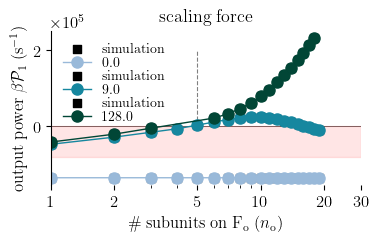

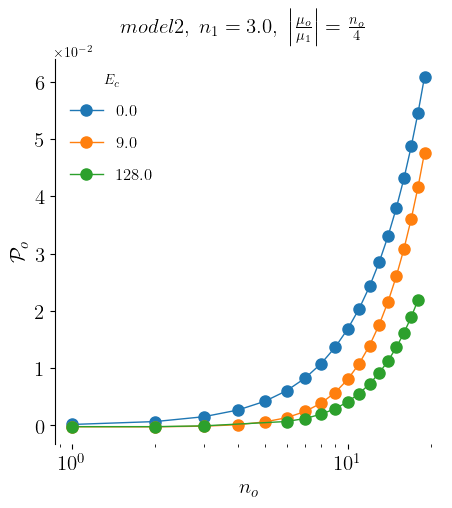

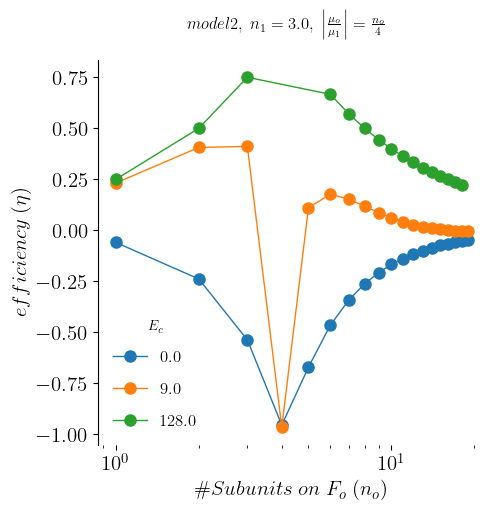

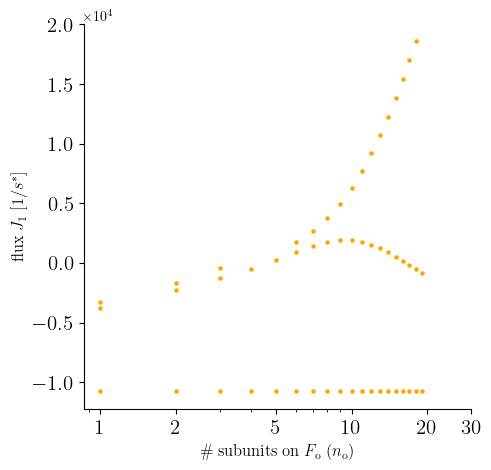

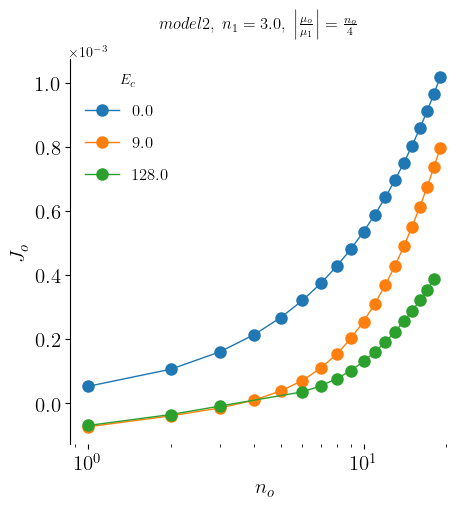

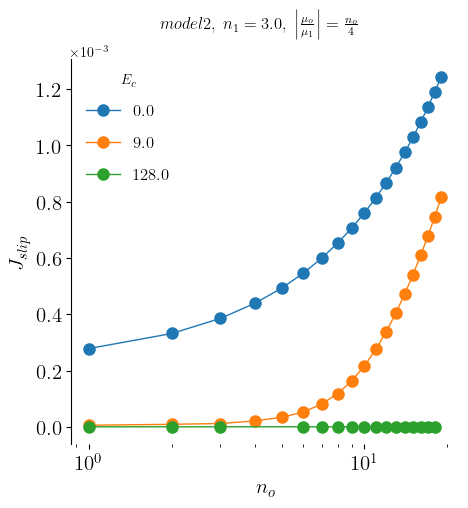

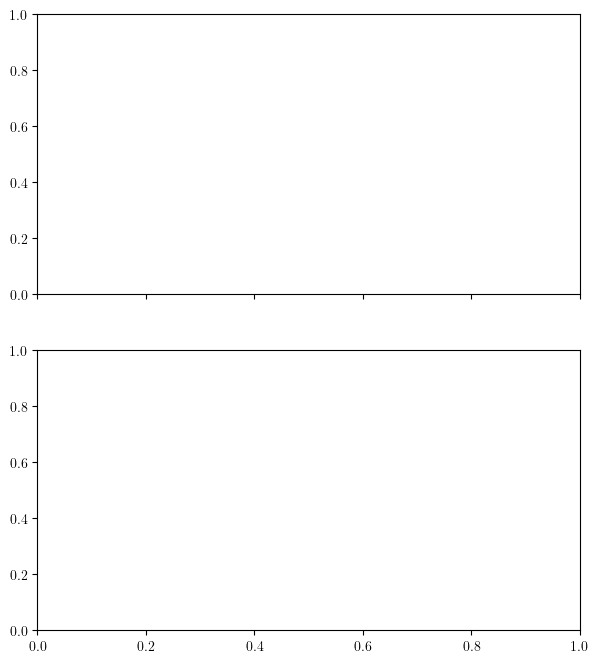

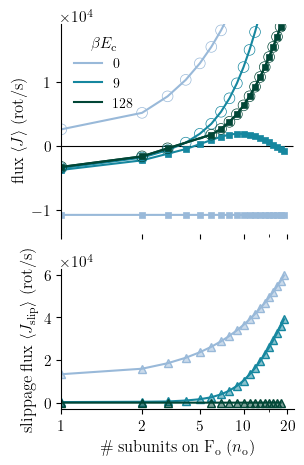

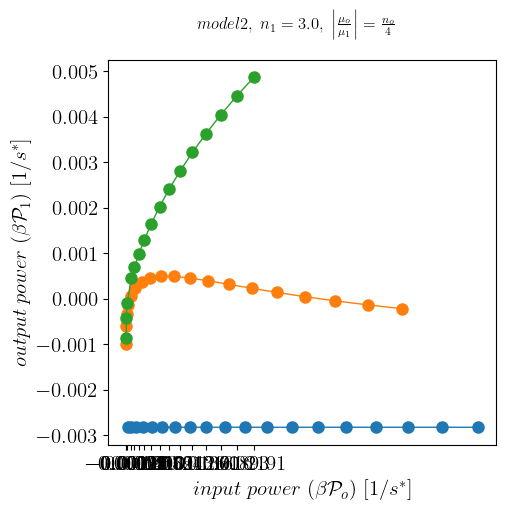

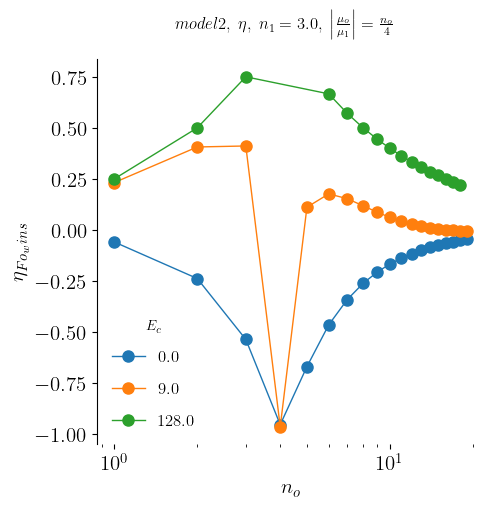

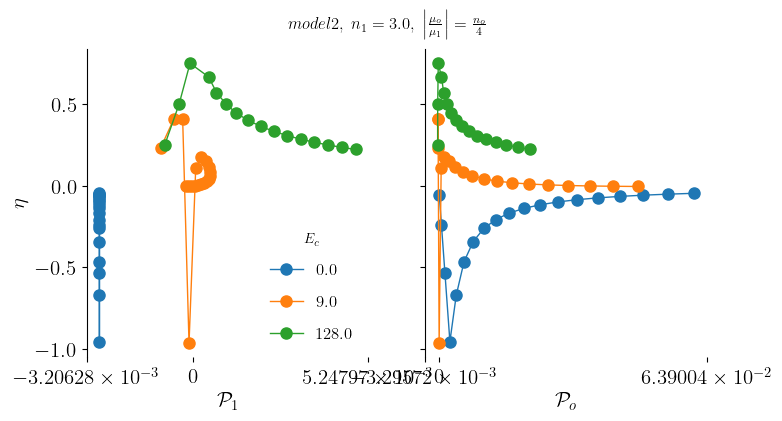

In [67]:
#A plot of P vs n0 for different Ec

Ecouple_array = [150.0]
model_array = ["model1", "model2","model3","model4"]
#model_array = ["model2"]

# target_dir ="/Users/sarealles/Desktop/model2/new_data_540_CM/f0_8/pfe/"
target_dir="/Users/sarealles/Desktop/model2/data_540_probably_previously_downloaded_somewhere/f0_4/pfe/"

# target_dir = "/Users/sarealles/Desktop/model1/Data_N_360/cluster/pfe/"
#target_dir = "/Users/sarealles/Desktop/model1/Data_N_100/pfe/"
# target_dir = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_2/f0_4/pfe/"
'''use this for paper orange stars'''
# target_dir = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_0/f0_4/pfe/"
# target_dir="/Users/sarealles/Desktop/model2/data_540_probably_previously_downloaded_somewhere/f0_4/pfe/"
'''model 2, f0=4???'''
# target_dir = "/Users/sarealles/Desktop/Data/Data_processed/pfe_old/"
# target_dir = "/Users/sarealles/Desktop/Data/Data_processed/pfe/"
'''model2, f0=4, only Ec=10 to compare with analytical'''
# target_dir = "/Users/sarealles/Desktop/model2/data_1000_E0_2_mu0_4_n0_to_50_Ec_10/pfe/"
# target_dir = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_0/f0_4/pfe/"
'''model4, f0=4.0'''
# target_dir = "/Users/sarealles/Desktop/Data/"
'''model4, f0=4.0'''
# target_dir = "/Users/sarealles/Desktop/model3/new/pfe/"
'''model 1'''
# target_dir = "/Users/sarealles/Desktop/Data/Data_processed/pfe/"
'''model1, f0=4.0,n1=5.0'''
# target_dir = "/Users/sarealles/Desktop/model1/test_n0_5_vs_n0_5/pfe/"
'''model 1, f0=4.0,n1=9.0'''
# target_dir = "/Users/sarealles/Desktop/model1/test_n1_9/pfe/"
########
'''model 1, f0=4.0,n1=7.0'''
# target_dir = "/Users/sarealles/Desktop/model1/test_n0_5_vs_n1_7/pfe/"
#######
# target_dir = "/Users/sarealles/Desktop/model3/pfe/"
# target_dir ="/Users/sarealles/Desktop/model1/new_data_540_CM/f0_4/pfe/"
# target_dir ="/Users/sarealles/Desktop/model1/new/pfe/"    
#individual plots for each model
########
'''model 3, barrierless coupled Ec=10'''
# target_dir = "/Users/sarealles/Desktop/model3/test/pfe/"
# target_dir = "/Users/sarealles/Desktop/model3/n1_5/pfe/"
# target_dir = "/Users/sarealles/Desktop/model3/N_1000_f0_8/pfe/"
Ec_analytic_list = [(10.0,4)]


Ec_array = [0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,32.0,40.0,50.0,64.0,70.0,80.0,90.0,128.0] 
# Ec_array = [8.0,9.0,10.0,11.0,12.0]

# Ec_array = np.array([9.0,10.0,11.0, 12.0])

Ec_array = [7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0]

Ec_array = [3.0,4.0,6.0,8.0,12.0]


n0_array = [12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,32.0,40.0] 
n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,31.0,32.0,33.0,34.0,35.0,36.0,37.0,38.0,39.0,40.0,41.0,42.0,43.0,44.0,45.0,46.0,47.0,48.0,49.0,50.0] 
# n0_array = [8.0,9.0,10.0]
# n0_array = [1.0,2.0,3.0,4.0,5.0,6.0]
'''slippage figure'''
Ec_array = [0.0,9.0,128.0]
Ec_analytic_list = [(x,4) for x in Ec_array]
# target_dir = "/Users/sarealles/Desktop/model4/new/pfe/"
# target_dir="/Users/sarealles/Desktop/BFM/change_gamma_f1_0/pfe/"
'''model 4'''
# target_dir = "/Users/sarealles/Desktop/model4/Thesis/pfe/"
'''BFM models'''
# target_dir = "/Users/sarealles/Desktop/BFM/change_gamma_f1_0/pfe/"
'''model 3, n1=5'''
# target_dir = "/Users/sarealles/Desktop/model3/n1_5/pfe/"


target_dir = "/Users/sarealles/Downloads/pfe_set1/"
x_lim = 20
n1_array = [3.0]
for model in ["model2"]:
    plot_P_n0_individual(target_dir, model,n0_array,n1_array,Ec_array,Ec_analytic_list,x_lim,f0=4.0,f1=-2.0,dt=0.001,N=1000,E0=2.0,E1=2.0,vs_n0=True)
    plt.show()  


In [ ]:
def plot_All_vs_Ec(target_dir,model,n0,n1_array,E0_array):
    timescale = 1.5 * 10**4 
    #individually plotting for each model P vs no for various Ec values in one single plot

    #fig for P vs n0
    fig, ax = plt.subplots(1, 1, figsize=(5,5))
    #fig6 for P0 vs n0
    fig6, ax6 = plt.subplots(1, 1, figsize=(5,5))
    #fig1 for eta vs n0
    fig1, ax1 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for j1 vs n0
    fig2, ax2 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for jo vs n0
    fig5, ax5 = plt.subplots(1, 1, figsize=(5,5))
    #fig3 for jslip vs n0
    fig3, ax3 = plt.subplots(1, 1, figsize=(5,5))
    # #fig4 for eta if assume fo always wins
    fig4, ax4 = plt.subplots(1, 1, figsize=(5,5))
    #fig7 P1 vs. eta
    fig7, ax7 = plt.subplots(1, 2, figsize=(8,4), sharey="row")
    
    # ax.axhline(0.0,color="black", lw=1.0)
    # ax3.axhline(0.0,color="black", lw=1.0)
    # ax6.axhline(0.0,color="black", lw=1.0)
    # ax4.axhline(0.0,color="black", lw=1.0)
    # ax2.axhline(0.0,color="black", lw=1.0)
    # ax5.axhline(0.0,color="black", lw=1.0)
    # ax1.axhline(1.0,color="black", lw=1.0)


    for n1 in n1_array:
        for i,E0 in enumerate(E0_array):
            # target_dir_temp = target_dir + f"/E0_{int(E0)}" + "/f0_8/pfe/"
            target_dir_temp = target_dir 
            print("tarhet dir", target_dir_temp)
            n0_exists = []
            P_at_E0 = []
            P0_at_E0 = []
            eta_at_E0 = []
            eta_at_inf = []
            eta_Fo_wins = []
            j1_at_E0 = []
            jo_at_E0 = []
            jslip_at_E0 = []
            

            params = set_params(model, n0,n1,E0,E0)
            n0n1_str = str(int(n0))+"_"+ str(int(n1))
            target_dir_temp += n0n1_str
        
            [
            E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
            m0, m1, phase,beta, gamma,__
            ] = params
            
        
            # input_file_name = ("/" + model +"_dt_{7}_N_{8}"+ "_flux_power_efficiency_"
            # + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
            #change the input name
            input_file_name = ("/"+ model + "_flux_power_efficiency_"
            + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")

            if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase)):
                print(f"{target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase)}doesnt exist")
                continue
            print(n0)        
            Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
            target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase),unpack=True, usecols=(0,1,2,3,4,5,6))



            # print(integrate_power_Y)
            # for j in range(len(Ec_list)):
            #     if Ec_list[j] == Ec:
            #         Ec_exists.append(int(n0))
            #         P0_at_Ec.append(2*pi*integrate_power_X[j])
            #         P_at_Ec.append(-2*pi*integrate_power_Y[j])
            #         eta_at_Ec.append(efficiency_mod[j])
            #         j1_at_Ec.append(integrate_flux_Y[j])
            #         jo_at_Ec.append(integrate_flux_X[j])
            #         eta_Fo_wins.append(efficiency[j])
            #         if model =="model3" or model=="model4":
            #             jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
            #         else:
            #             jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                        
                    
            eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))

            # print(fr"at {Ec}, n0 that maximizes J1 is: {n0_exists[argmax(j1_at_Ec)]}")
                
            if model =="model2" or model=="model4":
                x = str(psi_0/8)
                psi_0 = "\\frac{n_o}{2}"
                psi_0 = "2"
                f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
            else:
                # f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                f_o = "\\Delta \\mu_o"
                
            fig.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            ax.plot(Ec_list,-2*pi*array(integrate_power_Y), label = fr"${E0}$",marker ="o", lw=1.0,markersize=4)
            ax.tick_params(labelsize=15, axis='both')
            ax.set_xlabel(r"$ E_c$", fontsize=15)
            ax.set_ylabel(r"$output \ power\ (\beta\mathcal{P}_{1})\ [1/s^*]$", fontsize=15)
            
            print(f"maximum P1 for E0 = {E0}is at Ec = {Ec_list[argmax(-2*pi*array(integrate_power_Y))]}" )
            #ax.legend(loc='upper right', prop={'size':12})
            # ax.plot([6,9,12,15,18,21,24,27,30],[1.0, 0.989, 0.961, 0.916, 0.854, 0.791, 0.81, 0.83, 0.836])
            #############################♯
            # deg=4
            # fit_coeffs = np.polyfit(n0_exists, P_at_Ec, deg)
            # fit_curve = np.polyval(fit_coeffs, n0_exists)
            # equation = " + ".join([f"${coef:.6f}*x^{deg}$" for coef, deg in zip(fit_coeffs, range(len(fit_coeffs)-1, -1, -1))])
            # print(f"Fitted Polynomial Equation Ec = {Ec}: y = {equation}")
            # ax.plot(n0_exists, fit_curve)
            # print(f"Fitted Polynomial Equation: y = {equation}")
            ############################# 
            fig1.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            ax1.plot(Ec_list,efficiency_mod, label = fr"${E0}$",marker ="o", lw=1.0,markersize=8)

    
            ax1.tick_params(labelsize=15, axis='both')
            ax1.set_xlabel(r"$E_c$", fontsize=15)
            ax1.set_ylabel(r"$\eta$", fontsize=15)
            #ax1.legend(loc='upper right', prop={'size':12})
            
            fig7.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            # ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
            # ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
            # ax7[1].set_title(r"$\mathcal{P}_{o}$")
            # ax7[0].set_title(r"$\mathcal{P}_{1}$")
            ax7[0].tick_params(labelsize=15, axis='both')
            ax7[1].tick_params(labelsize=15, axis='both')
            ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
            ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
            ax7[0].set_ylabel(r"$\eta$", fontsize=15)
            
            fig2.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            # ax2.plot(n0_exists,j1_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
            ax2.tick_params(labelsize=15, axis='both')
            ax2.set_xlabel(r"$n_o$", fontsize=15)
            ax2.set_ylabel(r"$J_{1}$", fontsize=15)
            
            fig5.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            # ax5.plot(n0_exists,jo_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
            ax5.tick_params(labelsize=15, axis='both')
            ax5.set_xlabel(r"$n_o$", fontsize=15)
            ax5.set_xticks(n0_exists)
            ax5.set_ylabel(r"$J_{o}$", fontsize=15)
            
            fig3.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            # ax3.plot(n0_exists,jslip_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
            ax3.tick_params(labelsize=15, axis='both')
            ax3.set_xlabel(r"$n_o$", fontsize=15)
            ax3.set_xticks(n0_exists)
            ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

            ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['top'].set_visible(False)
            
            fig4.suptitle(fr"${model},\ \eta ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            # ax4.plot(n0_exists,eta_Fo_wins, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
            ax4.tick_params(labelsize=15, axis='both')
            ax4.set_xlabel(r"$n_o$", fontsize=15)
            ax4.set_xticks(n0_exists)
            ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


            fig6.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=15)
            ax6.plot(Ec_list,2*pi*array(integrate_power_X), label = fr"${E0}$",marker ="o", lw=1.0,markersize=8)
            ax6.tick_params(labelsize=15, axis='both')
            ax6.set_xlabel(r"$E_c$", fontsize=15)
            ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
            
            ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['top'].set_visible(False)
            
            ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax2.spines['right'].set_visible(False)
            ax2.spines['bottom'].set_visible(False)
            ax2.spines['top'].set_visible(False)
            
            ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax5.spines['right'].set_visible(False)
            ax5.spines['bottom'].set_visible(False)
            ax5.spines['top'].set_visible(False)
            
            ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
            ax7[0].spines['right'].set_visible(False)
            ax7[0].spines['bottom'].set_visible(False)
            ax7[0].spines['top'].set_visible(False)
            ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
            ax7[1].spines['right'].set_visible(False)
            ax7[1].spines['bottom'].set_visible(False)
            ax7[1].spines['top'].set_visible(False)
            
            ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax6.spines['right'].set_visible(False)
            ax6.spines['bottom'].set_visible(False)
            ax6.spines['top'].set_visible(False)
            
            ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax4.spines['right'].set_visible(False)
            ax4.spines['bottom'].set_visible(False)
            ax4.spines['top'].set_visible(False)
            
            ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax3.spines['right'].set_visible(False)
            ax3.spines['bottom'].set_visible(False)
            ax3.spines['top'].set_visible(False)
            
            ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax1.spines['right'].set_visible(False)
            ax1.spines['bottom'].set_visible(False)
            ax1.spines['top'].set_visible(False)
            
            ax.set_xscale("log")
            ax1.set_xscale("log")
            ax2.set_xscale("log")
            ax3.set_xscale("log")
            ax4.set_xscale("log")
            ax5.set_xscale("log")
            ax6.set_xscale("log")
            ax7[0].set_xscale("symlog")
            ax7[1].set_xscale("symlog")
            
        
            #ax.set_yscale("log")
        # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
    

    # ax.legend(prop={'size': 12}, title='$E_c$', frameon=False, ncol=2, labelspacing=0.05,
        # bbox_to_anchor=(0.31, 0.6), loc='best')
    ax.legend(prop={'size': 12}, title='$E_c$', frameon=False, loc='best')
    # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    ax1.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    ax2.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    ax3.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    ax4.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    ax6.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    ax5.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        # ax7[0].legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        # fig.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig1.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_eta_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig2.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")


    plt.show()
        

In [ ]:
def plot_fig_5_10(target_dir, params,model_array,n0_array,n1_array,E_array_full,T=False):
    
    #ax4 for all p 
    #ax5 for all eta
    #ax6 for j/j
    plt.clf()
    fig4, ax4 = subplots(2, 2, figsize=(8,6),sharex='col', sharey="row")
    fig5, ax5 = subplots(2, 2, figsize=(8,6),sharex='col', sharey="row")
    fig6, ax6 = subplots(2, 2, figsize=(8,6),sharex='col', sharey="row")

    
    
    
    fig4.text(0.5, 0.02, r"$E_{\mathrm{couple}}$", ha='center', fontsize=16)
    fig4.text(0.02, 0.5, r"$\mathcal{P}_{1}$", ha='center', fontsize=16, rotation=90)
    fig5.text(0.5, 0.02, r"$E_{\mathrm{couple}}$", ha='center', fontsize=16)
    fig5.text(0.02, 0.5, r"$\mathcal{\eta}$", ha='center', fontsize=16, rotation=90)
    fig6.text(0.5, 0.02, r"$E_{\mathrm{couple}}$", ha='center', fontsize=16)
    fig6.text(0.01, 0.5, r"$\frac{\langle J_{1} \rangle}{\langle J_{0} \rangle}$", ha='center', fontsize=16, rotation=90)
    ax5[0,0].axhline(0.0, color = "black", lw=1.0)
    ax5[1,0].axhline(0.0, color = "black", lw=1.0)
    ax5[0,1].axhline(0.0, color = "black", lw=1.0)
    ax5[1,1].axhline(0.0, color = "black", lw=1.0)
    
    ax5[0,0].axhline(1.0, color = "black", lw=1.0)
    ax5[1,0].axhline(1.0, color = "black", lw=1.0)
    ax5[0,1].axhline(1.0, color = "black", lw=1.0)
    ax5[1,1].axhline(1.0, color = "black", lw=1.0)
    
    ax4[0,0].axhline(0.0, color = "black", lw=1.0)
    ax4[1,0].axhline(0.0, color = "black", lw=1.0)
    ax4[0,1].axhline(0.0, color = "black", lw=1.0)
    ax4[1,1].axhline(0.0, color = "black", lw=1.0)
    
    ax6[0,0].axhline(0.0, color = "black", lw=1.0)
    ax6[1,0].axhline(0.0, color = "black", lw=1.0)
    ax6[0,1].axhline(0.0, color = "black", lw=1.0)
    ax6[1,1].axhline(0.0, color = "black", lw=1.0)
    

    fig4.suptitle(r"$\mathcal{P}$", fontsize=16)
    fig5.suptitle(r"$\mathcal{\eta}$", fontsize=16)
    
    for j,model in enumerate(model_array):
    
        input_file_name = (
            "/" + model + "_flux_power_efficiency_"
            + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat"
            )

        [
            E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
            m0, m1, phase,beta, gamma,__
            ] = params

        for i,n1 in enumerate(n1_array):
            #p1,p0 plot
            fig, ax = subplots(1, 2, figsize=(10,5),sharey='row')
            #eff
            fig2, ax2 = subplots(1, 1, figsize=(5,5))
            #eff,p1
            fig3, ax3 = subplots(2, 1, figsize=(5,6),sharex='col')
            fig2.subplots_adjust(left=0.2,bottom=0.25, right=0.8,top=0.75)
            #fig3.subplots_adjust(left=0.2,bottom=0.25, right=0.8,top=0.75)
            #fig.suptitle(r"$n_{0} = {0}, n_{1} = {1}$".format(n0,n1), fontsize=16)
            fig.suptitle(r"$model \ {0}$".format(model[-1]), fontsize=16)
            fig2.suptitle(r"$model \ {0}$".format(model[-1]), fontsize=16)
            fig3.suptitle(r"$model \ {0}$".format(model[-1]), fontsize=16)
            #fig2.suptitle(fr"$n_o = {n0},\ n_1 = {n1}$", fontsize=16)


            ax[0].axhline(0.0, color = "black", lw=1.0)
            ax[1].axhline(0.0, color = "black", lw=1.0)
            ax2.axhline(0.0, color = "black", lw=1.0)
            ax2.axhline(1.0, color = "black", lw=1.0)
            ax3[1].axhline(0.0, color = "black", lw=1.0)
            ax3[1].axhline(1.0, color = "black", lw=1.0)
            ax3[0].axhline(0.0, color = "black", lw=1.0)
            
            #ax2[1].axhline(0.0, color = "black", lw=1.0)
            colors = ["crimson","navy" ,"salmon", "cornflowerblue"]
            markers = ["o"]
            
            for ii,n0 in enumerate(n0_array):
                n0n1_str = str((int(n0)))+"_"+str((int(n1)))
                integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir + n0n1_str + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase),unpack=True, usecols=(1,2,3,4,5,6))



                
            
                
                ax[0].plot(
                    Ecouple_array, -2*pi*integrate_power_Y, marker = "o", lw=1.0, markersize= 4,
                    label= "${0}$".format(n0)
                    )

                ax[1].plot(
                    Ecouple_array, 2*pi*integrate_power_X, marker ="o", lw=1.0, markersize= 4,
                    label="${0}$".format(n0)
                    )

                ########
                ax2.plot(
                    Ecouple_array, efficiency_mod, marker ="o", lw=1.0, markersize= 4,
                    label="${0}$".format(n0)
                    )

                #################################
                ax3[0].plot(
                    Ecouple_array, -2*pi*integrate_power_Y,marker ="o",lw=1.0, markersize= 4,
                    label= "${0}$".format(n0)
                    )
                ax3[1].plot(
                    Ecouple_array, efficiency_mod/0.5, marker ="o", lw=1.0, markersize= 4,
                    label="${0}$".format(n0)
                    )
                #################################
                if model=="model1":
                    ax4[0,0].plot(
                        Ecouple_array, -2*pi*integrate_power_Y,marker ="o",lw=1.0, markersize= 4,
                        label= "${0}$".format(n0)
                        )
                    
                    ax5[0,0].plot(
                        Ecouple_array, efficiency_mod, marker ="o", lw=1.0, markersize= 4,
                        label="${0}$".format(n0)
                        )
                    ax6[0,0].plot(
                        Ecouple_array,integrate_flux_Y/integrate_flux_X , marker ="^", lw=1.0, markersize= 4,
                        label="${0}$".format(n0)
                        )
                    ax4[0,0].set_title(fr"$model \ {model[-1]}, \Delta \mu_0 = {psi_0}, \Delta \mu_1 = {psi_1}$", fontsize=8)
                    ax5[0,0].set_title(r"$model \ {0}$".format(model[-1]), fontsize=15)
                    ax6[0,0].set_title(r"$model \ {0}$".format(model[-1]), fontsize=15)
                elif model=="model2":
                    ax4[1,0].plot(
                        Ecouple_array, -2*pi*integrate_power_Y,marker ="^",lw=1.0, markersize= 4,
                        label= "${0}$".format(n0)
                        )
                    
                    ax5[1,0].plot(
                        Ecouple_array, efficiency_mod, marker ="^", lw=1.0, markersize= 4,
                        label="${0}$".format(n0)
                        )
                    ax6[1,0].plot(
                        Ecouple_array,integrate_flux_Y/integrate_flux_X , marker ="^", lw=1.0, markersize= 4,
                        label="${0}$".format(n0)
                        )
                    ax4[1,0].set_title(fr"$model \ {model[-1]}, \Delta \mu_0 = {psi_0/8}*n_o, \Delta \mu_1 = {psi_1}$", fontsize=8)
                    ax5[1,0].set_title(r"$model \ {0}$".format(model[-1]), fontsize=15)
                    ax6[1,0].set_title(r"$model \ {0}$".format(model[-1]), fontsize=15)
                    
                elif model=="model3":
                    ax4[0,1].plot(
                        Ecouple_array, -2*pi*integrate_power_Y,marker ="D",lw=1.0, markersize= 4,
                        label= "${0}$".format(n0)
                        )
                    
                    ax5[0,1].plot(
                        Ecouple_array, efficiency_mod, marker ="D", lw=1.0, markersize= 4,
                        label="${0}$".format(n0)
                        )
                    ax6[0,1].plot(
                        Ecouple_array,integrate_flux_Y/integrate_flux_X , marker ="^", lw=1.0, markersize= 4,
                        label="${0}$".format(n0)
                        )
                    ax4[0,1].set_title(fr"$model \ {model[-1]}, \Delta \mu_0 = {psi_0}, \Delta \mu_1 = {psi_1}$", fontsize=8)
                    ax5[0,1].set_title(r"$model \ {0}$".format(model[-1]), fontsize=15)
                    ax6[0,1].set_title(r"$model \ {0}$".format(model[-1]), fontsize=15)
                    
                elif model=="model4":
                    ax4[1,1].plot(
                        Ecouple_array, -2*pi*integrate_power_Y,marker ="s",lw=1.0, markersize= 4,
                        label= "${0}$".format(n0)
                        )
                    
                    ax5[1,1].plot(
                        Ecouple_array, efficiency_mod, marker ="s", lw=1.0, markersize= 4,
                        label="${0}$".format(n0)
                        )
                    ax6[1,1].plot(
                        Ecouple_array,integrate_flux_Y/integrate_flux_X, marker ="^", lw=1.0, markersize= 4,
                        label="${0}$".format(n0)
                        )
                    ax4[1,1].set_title(fr"$model \ {model[-1]}, \Delta \mu_0 = {psi_0/8}*n_o, \Delta \mu_1 = {psi_1}$", fontsize=8)
                    ax5[1,1].set_title(r"$model \ {0}$".format(model[-1]), fontsize=15)
                    ax6[1,1].set_title(r"$model \ {0}$".format(model[-1]), fontsize=15)
                
                
                # ax4[1,0].set_xlabel(r"$E_{\mathrm{couple}}$", fontsize=15)
                # ax4[1,1].set_xlabel(r"$E_{\mathrm{couple}}$", fontsize=15)
                
                # ax4[0,0].set_ylabel(r"$\mathcal{P}_{1}$", fontsize=15)
                # ax4[1,0].set_ylabel(r"$\mathcal{P}_{1}$", fontsize=15)
                ax4[0,0].tick_params(labelsize=15, axis='both')
                ax4[1,0].tick_params(labelsize=15, axis='both')
                ax4[0,1].tick_params(labelsize=15, axis='both')
                ax4[1,1].tick_params(labelsize=15, axis='both')
                
                
                
                # ax5[1,0].set_xlabel(r"$E_{\mathrm{couple}}$", fontsize=15)
                # ax5[1,1].set_xlabel(r"$E_{\mathrm{couple}}$", fontsize=15)
                # ax5[0,0].set_ylabel(r"$\mathrm{\eta}$", fontsize=15)
                # ax5[1,0].set_ylabel(r"$\mathrm{\eta}$", fontsize=15)
                ax5[0,0].tick_params(labelsize=15, axis='both')
                ax5[1,0].tick_params(labelsize=15, axis='both')
                ax5[0,1].tick_params(labelsize=15, axis='both')
                ax5[1,1].tick_params(labelsize=15, axis='both')
                
                
                ax6[0,0].tick_params(labelsize=15, axis='both')
                ax6[1,0].tick_params(labelsize=15, axis='both')
                ax6[0,1].tick_params(labelsize=15, axis='both')
                ax6[1,1].tick_params(labelsize=15, axis='both')
                #################################

                ax[0].set_xlabel(r"$E_{\mathrm{couple}}$", fontsize=15)
                ax[0].set_ylabel(r"$\mathcal{P}$", fontsize=15)
                ax[0].set_title(r'$\mathcal{P}_{1} = -2\pi\tau_1\langle J_{1} \rangle$', fontsize=15)
                ax[0].tick_params(labelsize=15, axis='both')
                #ax[0].grid(True)
                #ax[0].legend(loc='upper right', prop={'size':12})

                ax[1].set_xlabel(r"$E_{\mathrm{couple}}$", fontsize=15)
                ax[1].set_title(r'$\mathcal{P}_{o} = 2\pi\tau_o\langle J_{o} \rangle$', fontsize=15)
                ax[1].tick_params(labelsize=15, axis='both')
     
                
                
                ax3[1].set_xlabel(r"$E_{\mathrm{couple}}$", fontsize=15)
                ax3[0].set_ylabel(r"$\mathcal{P}_{1}$", fontsize=15)
                #ax3[0].set_title(r'$\mathcal{P}_{1} = -2\pi\tau_1<J_{1}>$', fontsize=15)
                ax3[0].tick_params(labelsize=15, axis='both')


                ax3[1].set_ylabel(r"$\mathrm{\eta}/\mathrm{\eta_max}$", fontsize=15)
            
                ax3[1].tick_params(labelsize=15, axis='both')
                
                

                ax2.set_xlabel(r"$E_{\mathrm{couple}}$", fontsize=15)
                ax2.set_ylabel(r"$\mathrm{\eta}$", fontsize=15)
                #ax2.set_title(r'$\mathcal{\eta}_{mod}$', fontsize=15)
                ax2.tick_params(labelsize=15, axis='both')
                #ax[3].grid(True)

                #ax2[1].legend(loc='lower right', prop={'size':6})



                ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                #ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                
                ax3[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax4[0,0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax4[1,0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                
                ax5[0,0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax5[1,0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                
                ax6[0,0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax6[1,0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                #ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                #ax3[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax[1,1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax.spines['right'].set_visible(False)
                # ax.spines['top'].set_visible(False)
                # ax.yaxis.set_ticks_position('left')
                # ax.xaxis.set_ticks_position('bottom')
                # ax.ticklabel_format(style="sci", axis="y", scilimits=(0,0))
                # ax.yaxis.offsetText.set_fontsize(22)
                ax[0].set_xscale("log")
                ax[1].set_xscale("log")
                #ax2[0].set_xscale("log")
                ax3[0].set_xscale("log")
                ax3[1].set_xscale("log")
                ax2.set_xscale("log")
                ax4[0,0].set_xscale("log")
                ax4[1,0].set_xscale("log")
                ax4[1,1].set_xscale("log")
                ax4[0,1].set_xscale("log")
                
                ax5[0,0].set_xscale("log")
                ax5[1,0].set_xscale("log")
                ax5[1,1].set_xscale("log")
                ax5[0,1].set_xscale("log")
                
                ax6[0,0].set_xscale("log")
                ax6[1,0].set_xscale("log")
                ax6[1,1].set_xscale("log")
                ax6[0,1].set_xscale("log")





                # extra = Rectangle((0, 0), 0.5, 0.5, fc="w", fill=False, edgecolor='none', linewidth=0)
                # legend_handle = [extra, extra, extra, extra, p1, p3, extra, p2, p4,]
                # label_row_1 = [" ","$constant\ \Delta \mu$", "$unit-based\ \Delta \mu$"]
                # label_j_1 = ["$spring-like\ coupling$"]
                # label_j_2 = ['$gear-like\ coupling$']
                # label_empty = [""]
                # legend_labels = concatenate([label_row_1, label_j_1, label_empty * 2, label_j_2, label_empty * 2])
                # leg0 = ax[0].legend(legend_handle, legend_labels, loc=9, ncol=3, shadow=False, handletextpad=-2, prop={'size':9,'family':'sans-serif'},labelspacing=0.8,bbox_to_anchor=(0.5, 0.8))
                # leg3 = ax2.legend(legend_handle, legend_labels, loc=9, ncol=3, shadow=False, handletextpad=-2, prop={'size':7}, bbox_to_anchor=(0.5, 1.3))




                # #ax[0].text((ax[0].get_xlim()[0]+ax[0].get_xlim()[-1])/3,0.00005,"helllooooo azizam chetoru khoobi",fontdict={'family': 'sans-serif'})

                # ax2.add_artist(leg3)
                # ax[0].add_artist(leg0)




                # ph, = ax[0].axhline(y=0.0, xmin= 1, xmax= 8, color="black", lw=1.0, label = "y=0")
                # ps1, = ax[0].axhspan(xmin = 0, xmax = max[n0], ymin=0, ymax= 420, color='green', alpha=0.1, label='Over y=0')
                # ps2, = ax[0].axhspan(xmin = 0, xmax = 8,ymin=-100, ymax=0, color='red', alpha=0.1, label='Below y=0')
                # leg1 = ax[0].legend(handles=[ps1, ps2, ph],prop={'size':10}, bbox_to_anchor=(0.7, 0.78))
                # ax[0].add_artist(leg1)

                ax[0].spines['right'].set_visible(False)
                ax[0].spines['top'].set_visible(False)
                ax[0].spines['bottom'].set_visible(False)
                ax[1].spines['right'].set_visible(False)
                ax[1].spines['top'].set_visible(False)
                ax[1].spines['bottom'].set_visible(False)
                ax2.spines['right'].set_visible(False)
                ax2.spines['top'].set_visible(False)
                ax2.spines['bottom'].set_visible(False)
                ax3[0].spines['right'].set_visible(False)
                ax3[0].spines['top'].set_visible(False)
                ax3[0].spines['bottom'].set_visible(False)
                ax3[1].spines['right'].set_visible(False)
                ax3[1].spines['top'].set_visible(False)
                ax3[1].spines['bottom'].set_visible(False)
                
                ax4[0,0].spines['right'].set_visible(False)
                ax4[0,0].spines['top'].set_visible(False)
                ax4[0,0].spines['bottom'].set_visible(False)
                ax4[0,1].spines['right'].set_visible(False)
                ax4[0,1].spines['top'].set_visible(False)
                ax4[0,1].spines['bottom'].set_visible(False)
                ax4[1,0].spines['right'].set_visible(False)
                ax4[1,0].spines['top'].set_visible(False)
                ax4[1,0].spines['bottom'].set_visible(False)
                ax4[1,1].spines['right'].set_visible(False)
                ax4[1,1].spines['top'].set_visible(False)
                ax4[1,1].spines['bottom'].set_visible(False)
                
                ax5[0,0].spines['right'].set_visible(False)
                ax5[0,0].spines['top'].set_visible(False)
                ax5[0,0].spines['bottom'].set_visible(False)
                ax5[0,1].spines['right'].set_visible(False)
                ax5[0,1].spines['top'].set_visible(False)
                ax5[0,1].spines['bottom'].set_visible(False)
                ax5[1,0].spines['right'].set_visible(False)
                ax5[1,0].spines['top'].set_visible(False)
                ax5[1,0].spines['bottom'].set_visible(False)
                ax5[1,1].spines['right'].set_visible(False)
                ax5[1,1].spines['top'].set_visible(False)
                ax5[1,1].spines['bottom'].set_visible(False)
                
                ax6[0,0].spines['right'].set_visible(False)
                ax6[0,0].spines['top'].set_visible(False)
                ax6[0,0].spines['bottom'].set_visible(False)
                ax6[0,1].spines['right'].set_visible(False)
                ax6[0,1].spines['top'].set_visible(False)
                ax6[0,1].spines['bottom'].set_visible(False)
                ax6[1,0].spines['right'].set_visible(False)
                ax6[1,0].spines['top'].set_visible(False)
                ax6[1,0].spines['bottom'].set_visible(False)
                ax6[1,1].spines['right'].set_visible(False)
                ax6[1,1].spines['top'].set_visible(False)
                ax6[1,1].spines['bottom'].set_visible(False)
            
                
                # plt.savefig(fr"Full_no_{n0}_n1_{n1}.pdf")
                
                #plt.close(fig)
                    
                
                # plt.savefig(fr"Full_eff_no_{n0}_n1_{n1}.pdf")
                #plt.show()
                #plt.close(fig2)
            ax[0].legend(title='$n_o$', frameon= False, labelspacing=1)
            ax3[1].legend(title='$n_o$', frameon= False, labelspacing=1)
            ax2.legend(title='$n_o$', frameon= False, labelspacing=1)
            ax4[0,0].legend(title='$n_o$', frameon= False, labelspacing=1)
            ax5[0,0].legend(title='$n_o$', frameon= False, labelspacing=1)
            ax6[0,0].legend(title='$n_o$', frameon= False, labelspacing=1)
            
            # fig.tight_layout()
            # plt.show(fig)
            # fig2.tight_layout()
            # plt.show(fig2)
            # fig3.tight_layout()
            # plt.show(fig3)
        fig.savefig(fr"/Users/sarealles/Desktop/Data/{model}_P0_P1_vs_Ec_n1_{n1}_f0_{psi_0}.png", dpi=300)
        fig.savefig(fr"/Users/sarealles/Desktop/Data/{model}_P0_P1_vs_Ec_n1_{n1}_f0_{psi_0}.pdf")

        if T:
            
            fig, ax = subplots(1, 2, figsize=(10,8))
            plt.subplots_adjust(left=0.2,bottom=0.2, right=0.8,top=0.8, wspace=0.4,hspace=0.4)
            #fig.suptitle(r'$n_{o} = {0}, n_{1} = {1}$'.format(n0,n1), fontsize=16)
            fig.suptitle(fr"$n_o = {n0},\ n_1 = {n1}$", fontsize=16)
            # ax.axhline(0.0, ls='--', lw=3.0)
            
            ax[0].axhline(0.0, color = "black", lw=1.0)
            ax[1].axhline(0.0, color = "black", lw=1.0)

            ax[0].plot(
                Ecouple_array, integrate_flux_Y_model1
                , marker ="o", lw=1.0, color='pink', markersize= 20,
                label=r'model 1-$J_1$'
                )
            
            ax[0].plot(
                Ecouple_array, integrate_flux_X_model1, marker ="*", lw=1.0, color='pink', markersize= 20,  markeredgecolor="black",
                label=r'model 1-$J_o$'
                )
            ax[0].plot(
                Ecouple_array
                , integrate_flux_Y_model2, marker ="o", markersize=8,lw=1.0, color='red',
                label=r'model 2-$J_1$'
                )
            ax[0].plot(
                Ecouple_array
                , integrate_flux_X_model2, marker ="s", lw=1.0, color='red', markeredgecolor="black", markersize= 5,
                label=r'model 2-$J_o$'
                )
            
            ax[0].plot(
                Ecouple_array
                , integrate_flux_Y_model3, marker ="o", lw=1.0, color='orange', markersize= 20,
                label=r'model 3-$J_1$'
                )
            ax[0].plot(
                Ecouple_array
                , integrate_flux_X_model3, marker ="*", lw=1.0, color='orange', markeredgecolor="black", markersize= 20,
                label=r'model 3-$J_o$'
                )

            ax[0].plot(
                Ecouple_array
                , integrate_flux_Y_model4, marker ="o",markersize=8, lw=1.0, color='purple',
                label=r'model 4-$J_1$'
                )
            

            ax[0].plot(
                Ecouple_array
                , integrate_flux_X_model4, marker ="s", lw=1.0, color='purple', markeredgecolor="black", markersize= 5,
                label=r'model 4-$J_o$'
                )
            
            ##comparing the absolute values
            
            ax[1].plot(
                Ecouple_array, abs(integrate_flux_Y_model1
                ), marker ="o", lw=1.0, color='pink', markersize= 20,
                label=r'model 1-$|J_1|$'
                )
            ax[1].plot(
                Ecouple_array, abs(integrate_flux_X_model1), marker ="*", lw=1.0, color='pink', markersize= 20,  markeredgecolor="black",
                label=r'model 1-$|J_o|$'
                )
            
            ax[1].plot(
                Ecouple_array
                , abs(integrate_flux_Y_model2), marker ="o", markersize=8,lw=1.0, color='red',
                label=r'model 2-$|J_1|$'
                )
            ax[1].plot(
                Ecouple_array
                , abs(integrate_flux_X_model2), marker ="s", lw=1.0, color='red', markeredgecolor="black", markersize= 5,
                label=r'model 2-$|J_o|$'
                )
            ax[1].plot(
                Ecouple_array, abs(integrate_flux_Y_model3), marker ="o", lw=1.0, color='orange', markersize= 20,
                label=r'model 3-$|J_1|$'
                )
            ax[1].plot(
                Ecouple_array, abs(integrate_flux_X_model3), marker ="*", lw=1.0, color='orange', markeredgecolor="black", markersize= 20,
                label=r'model 3-$|J_o|$'
                )

            ax[1].plot(
                Ecouple_array
                , abs(integrate_flux_Y_model4), marker ="o",markersize=8, lw=1.0, color='purple',
                label=r'$model 4-|J_1|$'
                )
            

            ax[1].plot(
                Ecouple_array
                , abs(integrate_flux_X_model4), marker ="s", lw=1.0, color='purple', markeredgecolor="black", markersize= 5,
                label=r'model 4-$|J_0|$'
                )



            
            ax[0].set_xlabel(r"$E_{\mathrm{c}} [k_{B}T]$", fontsize=15)
            ax[0].set_ylabel(r"J $ [1/t^*]$", fontsize=15)
            ax[0].set_title(r'$<J_o>,<J_{1}>$', fontsize=15)
            ax[0].tick_params(labelsize=10, axis='both')
            #ax[0].grid(True)
            ax[0].legend(loc=0, prop={'size':10}, ncols = 2)
            
            ax[1].set_xlabel(r"$E_{\mathrm{c}} [k_{B}T]$", fontsize=15)
            ax[1].set_ylabel(r"|J| $ [1/t^*]$", fontsize=15)
            ax[1].set_title(r'$\left|\langleJ_o\rangle\right|,\left|\langleJ_{1}\rangle\right|$', fontsize=15)
            ax[1].tick_params(labelsize=10, axis='both')
            #ax[1].grid(True)
            
            ax[1].legend(loc=0, prop={'size':10}, ncols = 2)
            

            

            

            
            ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

            ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

            ax[0].set_xscale("log")
            ax[1].set_xscale("log")


            fig.tight_layout()
            # plt.savefig(fr"Flux_no_{n0}_n1_{n1}_f0_{psi_0}_f1_{psi_1}.pdf")
    # fig4.tight_layout()
    # plt.show(fig4)
    # fig5.tight_layout()
    # fig6.savefig(fr"Flux_j1_over_j0_{n0}_n1_{n1}_f0_{psi_0}_f1_{psi_1}.pdf")
    plt.show()

In [ ]:
# n0_array = [4.0,5.0,6.0,7.0,8.0]
# n0_array = [12.0,13.0]
n1_array = [3.0]
model_array = ["model2"]
# target_dir = "/Users/sarealles/Desktop/Data/Data_processed/pfe/"
target_dir = "/Users/sarealles/Desktop/model2/new_data_540_CM"
target_dir = "/Users/sarealles/Desktop/Data/Data_processed/pfe/"
target_dir = "/Users/sarealles/Desktop/Data/Data_processed/pfe_old/"
Ecouple_array = [1.0,2.0,4.0,8.0,16.0,32.0,64.0,128.0]
E0_array = [2.0]
n0= 9.0
plot_All_vs_Ec(target_dir,"model1",n0,n1_array,E0_array)
#print("now for f=8")
#plot_fig_5_10(target_dir, set_params_Fo_8("model1", n0_array,3.0) ,model_array,n0_array,n1_array, E_array_full_fo_8,T= False)


## changing N with fixed dt to see if the negative slip problem would be solved

### Temperory calculation code:

In [ ]:
'''temp calculate flux and power from reference file'''
#change the target_dir and params to evaluate different parameter data. 
# change N_array_full_fo_8 based on f0 (=4 or =8)

# n0_array = [1.0,2.0,6.0,12.0]
n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0]
n1_array = [3.0]
Ec_array_sorted = [2.0,4.0,8.0,16.0,32.0,64.0,128.0]
N_array_sorted = [1000,1000,1000,1000,1000,1000,1000,1000]
#model_array = ["model1","model2","model3","model4"]
model_array = ["model1"]
# target_dir = "/Volumes/Sara/model1/data_N_1000/moved_files/"
# target_dir_out = "/Users/sarealles/Desktop/model1/Data_N_1000/pfe/"
# /Users/sarealles/Desktop/model1/data_N_360/cluster/non-existing files.rtf
target_dir = "/Users/sarealles/Desktop/model1/data_N_360/cluster/"
target_dir_out = "'/Users/sarealles/Desktop/model1/data_N_360/cluster/pfe/" #be careful of the fo and f1 you're analyzing
psi_0 = 4.0
J0_end = []
J1_end = []
for n1 in n1_array:
    for n0 in n0_array:
        
        # n0n1_str = "n0"+"_"+str(n0)+"_"+"n1"+"_"+ str(n1)
        n0n1_str = str(int(n0))+"_"+str(int(n1))
        for model in model_array:
            df_file_path = target_dir + f'{int(n0)}_{int(n1)}.csv'
            
            if not os.path.exists(df_file_path):
                print(f"DataFrame file for n0={n0}, n1={n1} does not exist. Skipping...")
                continue

            df = pd.read_csv(df_file_path)
            # Filter the DataFrame based on n0, n1, model, and psi_0
            filtered_df = df[(df['n0'] == n0) & (df['n1'] == n1) & (df['Model'] == model) & (df['Psi_0'] == psi_0)]

            # Get the Ec and N values
            Ecouple_array = filtered_df['Ec'].values
            N_array = filtered_df['SqrtNumRows'].values
            dt_array = filtered_df['dt'].values
            
            # if len(Ecouple_array) == 0 or len(N_array) == 0:
            #     print(f"No data available for n0={n0}, n1={n1}, model={model}, and psi_0={psi_0}. Skipping...")
            #     continue
            sorted_indices = np.argsort(Ecouple_array)
            Ec_array_sorted = Ecouple_array[sorted_indices]
            N_array_sorted = N_array[sorted_indices]
            dt_array_sorted = dt_array[sorted_indices]
            print(Ec_array_sorted)
            print(N_array_sorted)
            print(dt_array_sorted)
            
        # n0n1_str = "n0"+"_"+str(n0)+"_"+"n1"+"_"+ str(n1)
        
            # print(Ec_array_sorted)
            # print(N_array_sorted)
            
            
            params = set_params_Fo_4(model, n0,n1)
            if not os.path.exists(target_dir_out + n0n1_str):
                os.makedirs(target_dir_out + n0n1_str)
            calculate_flux_power_and_efficiency(target_dir + n0n1_str ,target_dir_out + n0n1_str,Ec_array_sorted, params, N_array_sorted)
            #Ec_array = Ec_array_full.get(key,[])
        

### n0 which is maximizong j1 vs Ec

In [ ]:

from scipy.optimize import curve_fit

In [ ]:
def emma_E_star_prediction(psi_0,psi_1):
    Ec_star = 4*np.log(12)/3 + 4*pi*(psi_0 - psi_1)/9 
    return Ec_star

comparing two models' P1 in one plot

In [ ]:
def plot_P_n0(target_dir,params, model_array,n0_array,n1_array,Ec):
    
    colors = ["crimson","salmon",  "navy","cornflowerblue"]
    ms = [12,6,12,6]
    legend_saver = []
    #fig for P vs n0
    fig, ax = plt.subplots(1, 1, figsize=(5,5))
    #fig1 for eta vs n0
    fig1, ax1 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for j1 vs n0
    fig2, ax2 = plt.subplots(1, 1, figsize=(5,5))
    ax.axhline(0.0,color="black", lw=1.0)
    ax1.axhline(0.0,color="black", lw=1.0)
    ax2.axhline(0.0,color="black", lw=1.0)
    ax1.axhline(1.0,color="black", lw=1.0)
    
    
    
    for model in model_array:
        for n1 in n1_array:
            
            n0_exists = []
            P_at_Ec = []
            eta_at_Ec = []
            j1_at_Ec = []
            for n0 in n0_array:
                target_dir_temp = target_dir + str(int(n0))+"_" +str(int(n1))
            
                [
                E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                m0, m1, phase,beta, gamma,__
                ] = params
                
                input_file_name = ("/" + model + "_flux_power_efficiency_"
                + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                
                Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase),unpack=True, usecols=(0,1,2,3,4,5,6))
                for j in range(len(Ec_list)):
                    if Ec_list[j] == Ec:
                        n0_exists.append(int(n0))
                        P_at_Ec.append(-2*pi*integrate_power_Y[j])
                        eta_at_Ec.append(efficiency_mod[j])
                        j1_at_Ec.append(integrate_flux_Y[j])
                
            fig.suptitle(fr"$P_1, E_c = {int(Ec)},\ n_1 = {n1}, \ f_o = {psi_0}$", fontsize=16)
            p, = ax.plot(n0_exists,P_at_Ec, label = model,marker ="o", lw=1.0, color=colors[int(model[-1])-1], markersize=ms[int(model[-1])-1])
            legend_saver.append(p)
            ax.tick_params(labelsize=15, axis='both')
            ax.set_xlabel(r"$n_o$", fontsize=15)
            ax.set_xticks(n0_exists)
            ax.set_ylabel(r"$\mathcal{P}_{1}$", fontsize=15)
            #ax.legend(loc='upper right', prop={'size':12})

            fig1.suptitle(fr"$\eta , E_c = {int(Ec)},\ n_1 = {n1}, \ f_o = {psi_0}$", fontsize=16)
            ax1.plot(n0_exists,eta_at_Ec, label = model,marker ="o", lw=1.0, color=colors[int(model[-1])-1], markersize=ms[int(model[-1])-1])
            ax1.tick_params(labelsize=15, axis='both')
            ax1.set_xlabel(r"$n_o$", fontsize=15)
            ax1.set_ylabel(r"$\eta$", fontsize=15)
            #ax1.legend(loc='upper right', prop={'size':12})
            
            fig2.suptitle(fr"$J_1, E_c = {int(Ec)},\ n_1 = {n1}, \ f_o = {psi_0}$", fontsize=16)
            ax2.plot(n0_exists,j1_at_Ec, label = model,marker ="o", lw=1.0, color=colors[int(model[-1])-1], markersize=ms[int(model[-1])-1])
            ax2.tick_params(labelsize=15, axis='both')
            ax2.set_xlabel(r"$n_o$", fontsize=15)
            ax2.set_xticks(n0_exists)
            ax2.set_ylabel(r"$J_{1}$", fontsize=15)

            ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['top'].set_visible(False)
            
            ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax2.spines['right'].set_visible(False)
            ax2.spines['bottom'].set_visible(False)
            ax2.spines['top'].set_visible(False)

            
            ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax1.spines['right'].set_visible(False)
            ax1.spines['bottom'].set_visible(False)
            ax1.spines['top'].set_visible(False)
            
            ax.set_xscale("log")
            ax1.set_xscale("log")
            ax2.set_xscale("log")
           

    extra = Rectangle((0, 0), 1, 1, fc="w", fill=False, edgecolor='none', linewidth=0)
    legend_handle = [extra, extra, extra, extra, legend_saver[0], legend_saver[1], extra, legend_saver[2], legend_saver[3],]
    label_row_1 = [" ",r"$\Delta\mu_{2\pi}$", r"$\Delta\mu_{\frac{2\pi}{n}}$"]
    label_j_1 = [r"$spring$"]
    label_j_2 = [r"$gear$"]
    label_empty = [""]
    legend_labels = concatenate([label_row_1, label_j_1, label_empty * 2, label_j_2, label_empty * 2])
    leg = ax.legend(legend_handle, legend_labels, loc=9, ncol=3, shadow=False, handletextpad=-2, prop={'size':12}, bbox_to_anchor=(0.7, 0.9))
    ax.add_artist(leg)
    leg1 = ax1.legend(legend_handle, legend_labels, loc=9, ncol=3, shadow=False, handletextpad=-2, prop={'size':12}, bbox_to_anchor=(0.7, 0.9))
    ax1.add_artist(leg1)
    leg2 = ax2.legend(legend_handle, legend_labels, loc=9, ncol=3, shadow=False, handletextpad=-2, prop={'size':12}, bbox_to_anchor=(0.7, 0.9))
    ax2.add_artist(leg2)
    fig.savefig(fr"/Users/sarealles/Desktop/Data/P_vs_n0_Ec_{int(Ec)}_n1_{n1}_fo_{psi_0}.pdf")
    fig1.savefig(fr"/Users/sarealles/Desktop/Data/eta_vs_n0_Ec_{int(Ec)}_n1_{n1}_fo_{psi_0}.pdf")
    fig2.savefig(fr"/Users/sarealles/Desktop/Data/J1_vs_n0_Ec_{int(Ec)}_n1_{n1}_fo_{psi_0}.pdf")
    plt.show()
    
def plot_P_n0_two_models(target_dir,model_array,n0_array,n1_array,Ec_array,f0_array,f1_array,dt,N,vs_n0=True,drag=1000):
    timescale = 1.5 * 10**4 
    #individually plotting for each model P vs no for various Ec values in one single plot

    #fig1 for P1  vs n0
    fig1, ax1 = plt.subplots(1, 2, figsize=(12,6),sharey="row")
    #fig2 for P0  vs n0
    fig2, ax2 = plt.subplots(1, 2, figsize=(13,6),sharey="row")
    
    #fig3 for eta vs n0
    fig3, ax3 = plt.subplots(1, 2, figsize=(13,6),sharey="row")
    
    #fig4 for eta vs P1
    fig4, ax4 = plt.subplots(1, 2, figsize=(13,6),sharey="row")
    #fig5 for J0 vs no
    fig5, ax5 = plt.subplots(1, 2, figsize=(13,6),sharey="row")
    #fig6 for J1 vs no
    fig6, ax6 = plt.subplots(1, 2, figsize=(13,6),sharey="row")
    #fig7 for J_slip vs no
    fig7, ax7 = plt.subplots(1, 2, figsize=(13,6),sharey="row")
    
    '''the no barrier approx for model 3 vs model 3 at mu-4 and mu=8'''
    ########################################################################################


    # f0 = 4
    # f1 = -2
    # n1 = 5
    # n0 = array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])
    # k = n1/n0

    # def J1(k):
    #     return (f0 + f1/k)/(1000*(k + (1/k)))
    # # def J0(k):
    # #     return k*(f0 + f1/k)/(1000*(k + (1/k)))
    # # def k_star(mu0,mu1):
    # #     return (-mu1 + (mu1**2 + mu0**2)**0.5)/mu0
    # # def k_star_mu(mu):
    # #     return mu + (1 + (mu**2))**0.5
    # # def n0_star_mu(n1,mu):
    # #     return n1/(mu + (1 + (mu**2))**0.5)
        


    # for n1 in [5]:
    #     for f0 in [4]:    
    #         ax1[0].scatter(n0, 2*J1(n1/n0), color = "black",label=fr"$\infty, \ barrierless$")
    #         ax1[0].plot(n0, 2*J1(n1/n0), color = "black")
    #     for f0 in [8]:    
    #         ax1[1].scatter(n0, 2*J1(n1/n0), color = "black",label=fr"$\infty, \ barrierless$")
    #         ax1[1].plot(n0, 2*J1(n1/n0), color = "black")
            
    # for n1 in [5]:
    #     for f0 in [4]:    
    #         ax2[0].scatter(n0, f0*n1/n0*J1(n1/n0), color = "black",label=fr"$\infty, \ barrierless$")
    #         ax2[0].plot(n0, f0*n1/n0*J1(n1/n0), color = "black")
    #     for f0 in [8]:    
    #         ax2[1].scatter(n0, f0*n1/n0*J1(n1/n0), color = "black",label=fr"$\infty, \ barrierless$")
    #         ax2[1].plot(n0, f0*n1/n0*J1(n1/n0), color = "black")



    ########################################################################################
    
    # #fig2 for j1 vs n0
    # fig2, ax2 = plt.subplots(1, 1, figsize=(5,5))
    # #fig5 for jo vs n0
    # fig5, ax5 = plt.subplots(1, 1, figsize=(5,5))
    
    # #fig3 for jslip vs n0
    # fig3, ax3 = plt.subplots(1, 1, figsize=(5,5))
    # # #fig4 for eta if assume fo always wins
    # fig4, ax4 = plt.subplots(1, 1, figsize=(5,5))
    # #fig7 P1 vs. eta
    # fig7, ax7 = plt.subplots(1, 2, figsize=(8,4), sharey="row")
    
    ax1[0].axhline(0.0,color="black", lw=1.0)
    ax1[1].axhline(0.0,color="black", lw=1.0)
    ax2[0].axhline(0.0,color="black", lw=1.0)
    ax2[1].axhline(0.0,color="black", lw=1.0)
    
    ax3[0].axhline(0.0,color="black", lw=1.0)
    ax3[1].axhline(0.0,color="black", lw=1.0)
    # ax6.axhline(0.0,color="black", lw=1.0)
    # ax4.axhline(0.0,color="black", lw=1.0)
    # ax2.axhline(0.0,color="black", lw=1.0)
    # ax5.axhline(0.0,color="black", lw=1.0)
    # ax1.axhline(1.0,color="black", lw=1.0)
    
    
    Ecouple= []
    maximizing_n0 = []
    if vs_n0:
        for n1 in n1_array:
            index = -1
            for jj,model in enumerate(model_array):
                index +=1
                f0 = f0_array[jj]
                f1 = f1_array[jj]
                for i,Ec in enumerate(Ec_array):
                    
                    n0_exists = []
                    P_at_Ec = []
                    P0_at_Ec = []
                    eta_at_Ec = []
                    eta_at_inf = []
                    eta_Fo_wins = []
                    j1_at_Ec = []
                    jo_at_Ec = []
                    jslip_at_Ec = []
                    
                    for n0 in n0_array:
                        params = set_params(model, n0,n1,f0,f1)
                        n0n1_str = str(int(n0))+"_"+ str(int(n1))
                        '''uncomment the following line and comment the lines after for model1,2'''
                        
                        # if f0==8.0 and n1 == 3.0:
                        #     target_dir_temp = target_dir[jj] + f"/{model}/new/pfe/" + n0n1_str
                        # # elif f0==4.0 and n1 == 3.0: 
                        # #     target_dir_temp = target_dir[jj] + n0n1_str
                        # else:
                        #     target_dir_temp = target_dir[jj] + n0n1_str
                        #     print(target_dir_temp)
                            
                        # if not os.path.exists(target_dir_temp):
                        #     print(target_dir_temp)
                        #     continue
                        target_dir_temp = target_dir[jj] + n0n1_str
                        #     print(target_dir_temp)
                            
                        if not os.path.exists(target_dir_temp):
                            print(target_dir_temp)
                    
                        [
                        E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                        m0, m1, phase,beta, gamma,__
                        ] = params
                        
                    
                        # input_file_name = ("/" + model +"_dt_{7}_N_{8}"+ "_flux_power_efficiency_"
                        # + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                        #change the input name
                        input_file_name = ("/" + model + "_flux_power_efficiency_"
                        + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                        
                        if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                            continue

                        Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                        target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                        # Convert Ec_list to a list if it is a single value
                        if isinstance(Ec_list, float):
                            Ec_list = [Ec_list]
                            integrate_power_Y = [integrate_power_Y]
                            integrate_power_X = [integrate_power_X]
                            integrate_flux_X = [integrate_flux_X]
                            integrate_flux_Y = [integrate_flux_Y]
                            efficiency_mod = [efficiency_mod]
                            efficiency = [efficiency]

                        # print(integrate_power_Y)
                        for j in range(len(Ec_list)):
                            if Ec_list[j] == Ec:
                                j1_at_Ec.append(integrate_flux_Y[j])
                                jo_at_Ec.append(integrate_flux_X[j])
                                eta_Fo_wins.append(efficiency[j])
                                n0_exists.append(int(n0))
                                P0_at_Ec.append(2*pi*integrate_power_X[j])
                                
                                
                                if model=="BFM" and f1==-0.0:
                                    P_at_Ec.append(2*pi*drag*((j1_at_Ec[-1])**2))
                                    # eta_at_Ec.append(P_at_Ec[-1]/P0_at_Ec[-1])
                                else:
                                    P_at_Ec.append(-2*pi*integrate_power_Y[j])
                                    eta_at_Ec.append(efficiency_mod[j])
                                    
                                
                                if model =="model3" or model=="model4" or model=="BFM":
                                    jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                                else:
                                    jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                                    
                                
                        eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                    # print("J0: ",jo_at_Ec)
                    # print("J1: ",j1_at_Ec)
                    # print("eff is ",eta_at_Ec)
                    # print("n0: ",n0_exists)
                    if len(n0_exists)!=0:
                        Ecouple.append(Ec)
                        maximizing_n0.append(n0_exists[argmax(j1_at_Ec)])
                    # print(fr"at {int(Ec)}, n0 that maximizes J1 is: {n0_exists[argmax(j1_at_Ec)]}")
                        
                    if model =="model2" or model=="model4" or model=="BFM":
                        # n0_exists_eta = []
                        # if 4.0 in n0_exists:
                        #     index_4 = n0_exists.index(4.0)
                        #     n0_exists_eta = n0_exists.copy()
                        #     del n0_exists_eta[index_4]
                        #     del eta_at_Ec[index_4] 
                        # x = str(psi_0/8)
                        psi_0 = "\\frac{n_o}{2}"
                        psi_0 = "2"
                        f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                    else:
                        # n0_exists_eta = n0_exists
                        # f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                        f_o = "\\Delta \\mu_o"
                    '''infinite value for efficiency''' 
                    if model == "model2":
                        eta_at_inf[3]=np.nan                    
                        ax3[index].plot(n0_array,eta_at_inf, color = "black", linestyle = "dashed", lw=2.0,markersize=8)
                    # for i,e in enumerate(eta_at_Ec):
                    #     if e > 0.5:
                    #         print(fr"eta is {e} at Ec = {int(Ec)}, n0 = {n0_exists[i]}")
                        
                    elif model == "model1":
                        sara = "pretty"
                        # ax3[index].plot(n0_array,eta_at_inf, color = "black", linestyle ="dashed", lw=2.0,markersize=8)  
                    ######################
                    # '''figure 4'''
                    # if model=="model2" and 4 in n0_exists:
                    #     index_4 = n0_exists.index(4)
                    #     eta_at_Ec_no_stall = eta_at_Ec
                    #     eta_at_Ec_no_stall[index_4] = np.nan

                    ############
                    print("eta:", eta_at_Ec)
                    print("P1:", P_at_Ec)
                    print("P0:", P0_at_Ec)
                    ###########
                    ax7[index].plot(n0_exists,jslip_at_Ec, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                    ax7[index].tick_params(labelsize=15, axis='both')    
                    ax7[index].set_xlabel(r"$\# \mathrm{subunits \ on} \ F_o \ (n_o)$", fontsize=18)
                    ax7[index].set_xticks(n0_exists)
                    ax7[0].set_ylabel(r"$\mathrm{Slippage \ Flux} \ (\mathcal{J}_{slip})\ [1/s^*]$", fontsize=18)
                    ############
                    ax5[index].plot(n0_exists,jo_at_Ec, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                    ax5[index].tick_params(labelsize=15, axis='both')    
                    ax5[index].set_xlabel(r"$\# \mathrm{subunits \ on} \ F_o \ (n_o)$", fontsize=18)
                    ax5[index].set_xticks(n0_exists)
                    ax5[0].set_ylabel(r"$\mathrm{Input \ Flux} \ (\mathcal{J}_{o})\ [1/s^*]$", fontsize=18)
                    ############
                    ax6[index].plot(n0_exists,j1_at_Ec, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                    ax6[index].tick_params(labelsize=15, axis='both')    
                    ax6[index].set_xlabel(r"$\# \mathrm{subunits \ on} \ F_o \ (n_o)$", fontsize=18)
                    ax6[index].set_xticks(n0_exists)
                    ax6[0].set_ylabel(r"$\mathrm{Output \ Flux} \ (\mathcal{J}_{1})\ [1/s^*]$", fontsize=18)      
                        
                    ######################
                    if len(eta_at_Ec)>0:
                        ax4[index].plot(P_at_Ec,eta_at_Ec, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                    ax4[index].tick_params(labelsize=15, axis='both')
                    ax4[0].set_ylabel(r"$\mathrm{Efficiency} \ (\eta)$", fontsize=18)
                    ax4[0].set_ylabel(r"$\mathrm{Output \ Power} \ (\beta \mathcal{P}_{1})\ [1/s^*]$", fontsize=18)
                    ####################  
                    # fig1.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                    ax1[index].plot(n0_exists,P_at_Ec, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                    ax1[index].tick_params(labelsize=15, axis='both')
                    ax1[index].set_xlabel(r"$\# \mathrm{subunits \ on } \ F_o\ (n_o)$", fontsize=18)
                    ax1[index].set_xticks(n0_exists)
                    ax1[0].set_ylabel(r"$\mathrm{Output \ Power} \ (\beta \mathcal{P}_{1})\ [1/s^*]$", fontsize=18)
                    # ax1[1].set_title(r"$\mu_o \propto n_o $", fontsize=24)
                    # ax1[0].set_title(r"$\mu_o = const. $",fontsize=24)
                    if model_array[-1] != model_array[0]:
                        ax1[1].set_title(fr"$model \ {model_array[-1][-1]}$", fontsize=24)
                        ax1[0].set_title(fr"$model \ {model_array[0][-1]}$",fontsize=24)
                        ax2[1].set_title(fr"$model \ {model_array[-1][-1]}$", fontsize=24)
                        ax2[0].set_title(fr"$model \ {model_array[0][-1]}$",fontsize=24)
                        ax3[1].set_title(fr"$model \ {model_array[-1][-1]}$", fontsize=24)
                        ax3[0].set_title(fr"$model \ {model_array[0][-1]}$",fontsize=24)
                        ax4[1].set_title(fr"$model \ {model_array[-1][-1]}$", fontsize=24)
                        ax4[0].set_title(fr"$model \ {model_array[0][-1]}$",fontsize=24)
                        ax5[0].set_title(fr"$model \ {model_array[0][-1]}$",fontsize=24)
                        ax5[1].set_title(fr"$model \ {model_array[-1][-1]}$", fontsize=24)
                        ax6[1].set_title(fr"$model \ {model_array[-1][-1]}$", fontsize=24)
                        ax6[0].set_title(fr"$model \ {model_array[0][-1]}$",fontsize=24)
                        ax7[1].set_title(fr"$model \ {model_array[-1][-1]}$", fontsize=24)
                        ax7[0].set_title(fr"$model \ {model_array[0][-1]}$",fontsize=24)
                    elif f0_array[-1] != f0_array[0]:
                        ax1[1].set_title(fr"$\mu_o =  \ {f0_array[-1]}$", fontsize=24)
                        ax1[0].set_title(fr"$\mu_o =  \ {f0_array[0]}$",fontsize=24)
                        ax2[1].set_title(fr"$\mu_o =  \ {f0_array[-1]}$", fontsize=24)
                        ax2[0].set_title(fr"$\mu_o =  \ {f0_array[0]}$",fontsize=24)
                        ax3[1].set_title(fr"$\mu_o =  \ {f0_array[-1]}$", fontsize=24)
                        ax3[0].set_title(fr"$\mu_o =  \ {f0_array[0]}$",fontsize=24)
                        ax4[1].set_title(fr"$\mu_o =  \ {f0_array[-1]}$", fontsize=24)
                        ax4[0].set_title(fr"$\mu_o =  \ {f0_array[0]}$",fontsize=24)
                        ax5[1].set_title(fr"$\mu_o =  \ {f0_array[-1]}$", fontsize=24)
                        ax5[0].set_title(fr"$\mu_o =  \ {f0_array[0]}$",fontsize=24)
                        ax6[1].set_title(fr"$\mu_o =  \ {f0_array[-1]}$", fontsize=24)
                        ax6[0].set_title(fr"$\mu_o =  \ {f0_array[0]}$",fontsize=24)
                        ax7[1].set_title(fr"$\mu_o =  \ {f0_array[-1]}$", fontsize=24)
                        ax7[0].set_title(fr"$\mu_o =  \ {f0_array[0]}$",fontsize=24)
                    if model_array[0] == "model1" and model_array[1] == "model2":
                        ax1[0].set_title(r"$\mathrm{Constant \ Force}$", fontsize=24)
                        ax1[1].set_title(r"$\mathrm{Scaling \ Force}$", fontsize=24)
                        ax2[0].set_title(r"$\mathrm{Constant \ Force}$", fontsize=24)
                        ax2[1].set_title(r"$\mathrm{Scaling \ Force}$", fontsize=24)
                        ax3[0].set_title(r"$\mathrm{Constant \ Force}$", fontsize=24)
                        ax3[1].set_title(r"$\mathrm{Scaling \ Force}$", fontsize=24)
                        ax4[0].set_title(r"$\mathrm{Constant \ Force}$", fontsize=24)
                        ax4[1].set_title(r"$\mathrm{Scaling \ Force}$", fontsize=24)

                    if model_array[0] == "model3" and model_array[1] == "model4":
                        ax1[0].set_title(r"Gear, Constant force", fontsize=24)
                        ax1[1].set_title(r"Gear, Scaling force", fontsize=24)
                        ax2[0].set_title(r"Gear, Constant force", fontsize=24)
                        ax2[1].set_title(r"Gear, Scaling force", fontsize=24)
                        ax3[0].set_title(r"Gear, Constant force", fontsize=24)
                        ax3[1].set_title(r"Gear, Scaling force", fontsize=24)
                        ax4[0].set_title(r"Gear, Constant force", fontsize=24)
                        ax4[1].set_title(r"Gear, Scaling force", fontsize=24)
                        ax5[0].set_title(r"Gear, Constant force", fontsize=24)
                        ax5[1].set_title(r"Gear, Scaling force", fontsize=24)
                        ax6[0].set_title(r"Gear, Constant force", fontsize=24)
                        ax6[1].set_title(r"Gear, Scaling force", fontsize=24)
                        ax7[0].set_title(r"Gear, Constant force", fontsize=24)
                        ax7[1].set_title(r"Gear, Scaling force", fontsize=24)
                        
                        
                    #ax.legend(loc='upper right', prop={'size':12})

                    # fig3.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                    if model =="model2":
                        n0_exists_no_stall = []
                        eta_at_Ec_no_stall = []
                        stall_point = int(-8*f1/f0)
                        print("stall point is ", stall_point)
                        for ii,n0 in enumerate(n0_exists):
                            if int(n0) != stall_point:
                                eta_at_Ec_no_stall.append(eta_at_Ec[ii])
                                n0_exists_no_stall.append(n0)
                            else:
                                eta_at_Ec_no_stall.append(nan)
                                n0_exists_no_stall.append(nan)
                                
                        eta_at_Ec_no_stall = array(eta_at_Ec_no_stall)
                        n0_exists_no_stall = array(n0_exists_no_stall)
                    elif model =="model4":
                        n0_exists_no_stall = []
                        eta_at_Ec_no_stall = []
                        stall_point = int(-f0*n1/f1)
                        for ii,n0 in enumerate(n0_exists):
                            if int(n0) != stall_point:
                                eta_at_Ec_no_stall.append(eta_at_Ec[ii])
                                n0_exists_no_stall.append(n0)
                        eta_at_Ec_no_stall = array(eta_at_Ec_no_stall)
                        n0_exists_no_stall = array(n0_exists_no_stall)
                    else:
                        n0_exists_no_stall = n0_exists
                        eta_at_Ec_no_stall = eta_at_Ec
                    if len(eta_at_Ec)>0:
                        ax3[index].plot(n0_exists_no_stall,eta_at_Ec_no_stall, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                    ax3[index].tick_params(labelsize=15, axis='both')
                    ax3[index].set_xlabel(r"$n_o$", fontsize=18)
                    ax3[0].set_ylabel(r"$\mathrm{Efficiency} \ (\eta)$", fontsize=18)
                    # ax3[1].set_title(r"$\mu_o \propto n_o $", fontsize=24)
                    # ax3[0].set_title(r"$\mu_o = const. $",fontsize=24)

                    #ax1.legend(loc='upper right', prop={'size':12})
                    
                    # fig7.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                    # ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                    # ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                    # # ax7[1].set_title(r"$\mathcal{P}_{o}$")
                    # # ax7[0].set_title(r"$\mathcal{P}_{1}$")
                    # ax7[0].tick_params(labelsize=15, axis='both')
                    # ax7[1].tick_params(labelsize=15, axis='both')
                    # ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
                    # ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
                    # ax7[0].set_ylabel(r"$\eta$", fontsize=15)
                    
                    # fig2.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                    # ax2.plot(n0_exists,j1_at_Ec, label = fr"${int(Ec)}$",marker ="o",lw=1.0, markersize=8)
                    # ax2.tick_params(labelsize=15, axis='both')
                    # ax2.set_xlabel(r"$n_o$", fontsize=15)
                    # ax2.set_xticks(n0_exists)
                    # ax2.set_ylabel(r"$J_{1}$", fontsize=15)
                    
                    # fig5.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                    # ax5.plot(n0_exists,jo_at_Ec, label = fr"${int(Ec)}$",marker ="o",lw=1.0, markersize=8)
                    # ax5.tick_params(labelsize=15, axis='both')
                    # ax5.set_xlabel(r"$n_o$", fontsize=15)
                    # ax5.set_xticks(n0_exists)
                    # ax5.set_ylabel(r"$J_{o}$", fontsize=15)
                    
                    # fig3.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                    # ax3.plot(n0_exists,jslip_at_Ec, label = fr"${int(Ec)}$",marker ="o",lw=1.0, markersize=8)
                    # ax3.tick_params(labelsize=15, axis='both')
                    # ax3.set_xlabel(r"$n_o$", fontsize=15)
                    # ax3.set_xticks(n0_exists)
                    # ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

                    ax1[index].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    # ax1[index].ticklabel_format(style='plain', axis='x')
                    ax1[index].spines['right'].set_visible(False)
                    ax1[index].spines['bottom'].set_visible(False)
                    ax1[index].spines['top'].set_visible(False)
                    
                    ax4[index].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    ax4[index].spines['right'].set_visible(False)
                    ax4[index].spines['bottom'].set_visible(False)
                    ax4[index].spines['top'].set_visible(False)
                    
                    ax5[index].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    ax5[index].spines['right'].set_visible(False)
                    ax5[index].spines['bottom'].set_visible(False)
                    ax5[index].spines['top'].set_visible(False)
                    
                    ax6[index].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    ax6[index].spines['right'].set_visible(False)
                    ax6[index].spines['bottom'].set_visible(False)
                    ax6[index].spines['top'].set_visible(False)
                    
                    ax7[index].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    ax7[index].spines['right'].set_visible(False)
                    ax7[index].spines['bottom'].set_visible(False)
                    ax7[index].spines['top'].set_visible(False)
                    
                    # fig4.suptitle(fr"${model},\ \eta ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                    # ax4.plot(n0_exists,eta_Fo_wins, label = fr"${int(Ec)}$",marker ="o",lw=1.0, markersize=8)
                    # ax4.tick_params(labelsize=15, axis='both')
                    # ax4.set_xlabel(r"$n_o$", fontsize=15)
                    # ax4.set_xticks(n0_exists)
                    # ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


                    # fig2.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=15)
                    ax2[index].plot(n0_exists,P0_at_Ec, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                    ax2[index].tick_params(labelsize=15, axis='both')
                    ax2[index].set_xlabel(r"$\# \mathrm{subunits  on} \ F_o \ (n_o)$", fontsize=18)
                    ax2[index].set_xticks(n0_exists)
                    ax2[0].set_ylabel(r"$\mathrm{Input \ Power} \ (\beta \mathcal{P}_{o})\ [1/s^*]$", fontsize=18)                    # ax2[1].set_title(r"$\mu_o \propto n_o $", fontsize=24)
                    # ax2[0].set_title(r"$\mu_o = const. $",fontsize=24)
                    
                    
                
                    ax2[index].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    ax2[index].spines['right'].set_visible(False)
                    ax2[index].spines['bottom'].set_visible(False)
                    ax2[index].spines['top'].set_visible(False)
                    
                    # ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    # ax5.spines['right'].set_visible(False)
                    # ax5.spines['bottom'].set_visible(False)
                    # ax5.spines['top'].set_visible(False)
                    
                    # ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    # # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                    # ax7[0].spines['right'].set_visible(False)
                    # ax7[0].spines['bottom'].set_visible(False)
                    # ax7[0].spines['top'].set_visible(False)
                    # ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    # # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                    # ax7[1].spines['right'].set_visible(False)
                    # ax7[1].spines['bottom'].set_visible(False)
                    # ax7[1].spines['top'].set_visible(False)
                    
                    # ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    # ax6.spines['right'].set_visible(False)
                    # ax6.spines['bottom'].set_visible(False)
                    # ax6.spines['top'].set_visible(False)
                    
                    # ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    # ax4.spines['right'].set_visible(False)
                    # ax4.spines['bottom'].set_visible(False)
                    # # ax4.spines['top'].set_visible(False)
                    
                    # ax3[index].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    ax3[index].set_xlabel(r"$\# \mathrm{subunits \ on} \ F_o \ (n_o)$", fontsize=18)
                    ax3[index].set_xticks(n0_exists)
                    ax3[index].spines['right'].set_visible(False)
                    ax3[index].spines['bottom'].set_visible(False)
                    ax3[index].spines['top'].set_visible(False)
                    
                    ax1[index].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                    ax1[index].spines['right'].set_visible(False)
                    ax1[index].spines['bottom'].set_visible(False)
                    ax1[index].spines['top'].set_visible(False)
                    

                    ax1[index].set_xscale("log")
                    ax1[index].set_xticks([1, 5, 10,15,20])
                    ax1[index].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
                    ax2[index].set_xscale("log")
                    ax2[index].set_xticks([1, 5, 10])
                    ax2[index].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
                    ax3[index].set_xscale("log")
                    ax3[index].set_xticks([1, 5, 10])
                    ax3[index].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
                    ax5[index].set_xscale("log")
                    ax5[index].set_xticks([1, 5, 10])
                    ax5[index].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
                    ax6[index].set_xscale("log")
                    ax6[index].set_xticks([1, 5, 10])
                    ax6[index].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
                    ax7[index].set_xscale("log")
                    ax7[index].set_xticks([1, 5, 10])
                    ax7[index].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
                    # ax4[index].set_xscale("symlog")
                    # ax1[index].axvspan(xmin=0, xmax=30,ymax=0,facecolor='red', alpha=0.5)


                    # ax4.set_xscale("log")
                    # ax5.set_xscale("log")
                    # ax6.set_xscale("log")
                    ax7[0].set_xscale("symlog")
                    ax7[1].set_xscale("symlog")
                    
                
                    #ax.set_yscale("log")
                # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
        
        ax2[0].legend(fontsize=15)
        # ax1[0].legend(fontsize=20)
        ax3[0].legend(fontsize=14)
        ax4[0].legend(fontsize=15)
        # ax5[0].legend(fontsize=15)
        # ax6[0].legend(fontsize=15)
        # ax7[0].legend(fontsize=15)
            
        # ax1[1].legend(prop={'size': 16}, title=r'$\beta E_c$', frameon=False, ncol=1, labelspacing=0.05, bbox_to_anchor=(0.41, 0.8), loc='center')
        ax1[1].legend(prop={'size': 16}, title=r'$\beta E_c$', frameon=False, ncol=1, labelspacing=0.05, loc='best')
        ax2[0].legend(prop={'size': 16}, title=r'$\beta E_c$', frameon=False, ncol=1, labelspacing=0.05,
            bbox_to_anchor=(0.41, 0.7), loc='center')
        ax2[0].legend(prop={'size': 16}, title=r'$\beta E_c$', frameon=False, ncol=1, labelspacing=0.05, loc='best')

        ax3[0].legend(prop={'size': 15}, title=r'$\beta E_c$', frameon=False, ncol=1, labelspacing=0.05,
            bbox_to_anchor=(0.11, 0.15), loc='center')
        # ax3[0].legend(prop={'size': 16}, title=r'$ \beta E_c$', frameon=False, ncol=1, labelspacing=0.05, loc='best')
        ax4[0].legend(prop={'size': 16}, title=r'$ \beta E_c$', frameon=False, ncol=1, labelspacing=0.05, loc='best')
        ax5[1].legend(prop={'size': 16}, title=r'$ \beta E_c$', frameon=False, ncol=1, labelspacing=0.05, loc='best')
        ax6[1].legend(prop={'size': 16}, title=r'$ \beta E_c$', frameon=False, ncol=1, labelspacing=0.05, loc='best')
        ax7[1].legend(prop={'size': 16}, title=r'$ \beta E_c$', frameon=False, ncol=1, labelspacing=0.05, loc='best')


        ax1[0].legend_.get_title().set_fontsize('20')
        ax2[0].legend_.get_title().set_fontsize('20')
        ax3[0].legend_.get_title().set_fontsize('20')
        ax4[0].legend_.get_title().set_fontsize('20')
        ax5[1].legend_.get_title().set_fontsize('20')
        ax6[1].legend_.get_title().set_fontsize('20')
        ax7[1].legend_.get_title().set_fontsize('20')
        ax1[0].set_xlim(0, 20.9)
        ax1[1].set_xlim(0, 20.9)
        ax2[0].set_xlim(0, 14.9)
        ax2[1].set_xlim(0, 14.9)
        ax3[0].set_xlim(0, 14.9)
        ax3[1].set_xlim(0, 14.9)
        ax5[0].set_xlim(0, 14.9)
        ax5[1].set_xlim(0, 14.9)
        ax6[0].set_xlim(0, 14.9)
        ax6[1].set_xlim(0, 14.9)
        ax7[0].set_xlim(0, 14.9)
        ax7[1].set_xlim(0, 14.9)
        
        ax3[0].set_ylim(-0.7, 0.85)
        # ax3[1].set_ylim(0, 14.9)
        
        n0_array.append(0)
        n0_array.append(21)
        n0_array.sort()
        '''the dud region'''
        
        y = -0.0025*np.ones(len(n0_array))
        ax1[0].fill_between(n0_array,y , where=(y < 0), color='red', alpha=0.15)
        ax1[1].fill_between(n0_array,y , where=(y < 0), color='red', alpha=0.15)
        ######################
        y=-1*np.ones(len(n0_array))
        ax3[0].fill_between(n0_array,y , where=(y < 0), color='red', alpha=0.2)
        ax3[1].fill_between(n0_array,y , where=(y < 0), color='red', alpha=0.2)
        #####################
        # x = np.linspace(-0.002,0,100)
        # y=-1*np.ones(100)
        # ax4[0].fill_between(x,y , where=(y < 0), color='red', alpha=0.2)
        # x = np.linspace(-0.0017,0,100)
        # y=-1*np.ones(100)
        # ax4[1].fill_between(x,y , where=(y < 0), color='red', alpha=0.2)
        # ax4[0].set_xlim(-0.002,0.005)
        # ax4[1].set_xlim(-0.0017,0.00055)
        
       

        # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        
        # ax3.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        # ax4.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        # ax6.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        # ax5.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        # ax7[0].legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        
        # fig1.savefig(fr"/Users/sarealles/Desktop/research/Paper/compare_model1_model2_P_vs_n0_n1_{n1}.pdf", bbox_inches='tight')
        
        # ax4[0].set_ylim(0, 1)
        # ax1[0].set_title("", fontsize=24)
        # fig1.savefig(fr"/Users/sarealles/Desktop/research/GP-Mar2025/proposal_model3_4_P1_vs_n0_n1_{n1}_fo_8.pdf",bbox_inches='tight')

        
        # fig1.savefig(fr"/Users/sarealles/Desktop/research/GP-Mar2025/model3_4_P1_vs_n0_n1_{n1}_fo_8.pdf",bbox_inches='tight')
        # fig2.savefig(fr"/Users/sarealles/Desktop/research/GP-Mar2025/model3_4_P0_vs_n0_n1_{n1}_fo_8.pdf",bbox_inches='tight')
        # fig3.savefig(fr"/Users/sarealles/Desktop/research/Paper/model1_2_eta_vs_n0_n1_{n1}_fo_4.pdf", bbox_inches='tight')
        # fig4.savefig(fr"/Users/sarealles/Desktop/research/GP-Mar2025/model3_4_eta_vs_P1_n1_{n1}_fo_8.pdf", bbox_inches='tight')
        # fig6.savefig(fr"/Users/sarealles/Desktop/research/GP-Mar2025/model3_4_J1_vs_n0_n1_{n1}_fo_8.pdf", bbox_inches='tight')
        # fig5.savefig(fr"/Users/sarealles/Desktop/research/GP-Mar2025/model3_4_J0_vs_n0_n1_{n1}_fo_8.pdf", bbox_inches='tight')

        print("Ec is :", Ecouple)
        print("j1 maximizing n0 is:", maximizing_n0)
        plt.show()
        
    
    else:
        for n0 in n0_array:
            for i,Ec in enumerate(Ec_array):
                n1_exists = []
                P_at_Ec = []
                P0_at_Ec = []
                eta_at_Ec = []
                eta_at_inf = []
                eta_Fo_wins = []
                j1_at_Ec = []
                jo_at_Ec = []
                jslip_at_Ec = []
                
                for n1 in n1_array:
                    params = set_params_Fo_4(model, n0,n1)
                    n0n1_str = str(int(n0))+"_"+ str(int(n1))
                    target_dir_temp = target_dir + n0n1_str
                
                    [
                    E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                    m0, m1, phase,beta, gamma,__
                    ] = params
                    
                
                    # input_file_name = ("/" + model +"_dt_{7}_N_{8}"+ "_flux_power_efficiency_"
                    # + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    #change the input name
                    input_file_name = ("/" + model + "_flux_power_efficiency_"
                    + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    
                    if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                        continue

                    Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                    # Convert Ec_list to a list if it is a single value
                    if isinstance(Ec_list, float):
                        Ec_list = [Ec_list]
                        integrate_power_Y = [integrate_power_Y]
                        integrate_power_X = [integrate_power_X]
                        integrate_flux_X = [integrate_flux_X]
                        integrate_flux_Y = [integrate_flux_Y]
                        efficiency_mod = [efficiency_mod]
                        efficiency = [efficiency]

                    # print(integrate_power_Y)
                    for j in range(len(Ec_list)):
                        if Ec_list[j] == Ec:
                            n1_exists.append(int(n1))
                            P0_at_Ec.append(2*pi*integrate_power_X[j])
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            eta_at_Ec.append(efficiency_mod[j])
                            j1_at_Ec.append(integrate_flux_Y[j])
                            jo_at_Ec.append(integrate_flux_X[j])
                            eta_Fo_wins.append(efficiency[j])
                            if model =="model3" or model=="model4" or model=="BFM":
                                jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                            else:
                                jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                                
                            
                    eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                print("J0: ",jo_at_Ec)
                print("J1: ",j1_at_Ec)
                print("eff is ",eta_at_Ec)
                print("n1: ",n1_exists)
                    
                if model =="model2" or model=="model4":
                    x = str(psi_0/8)
                    psi_0 = "\\frac{n_o}{4}"
                    f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                else:
                    psi_0 = 2
                    f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                    
                fig.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax.plot(n1_exists,P_at_Ec, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                ax.tick_params(labelsize=15, axis='both')
                ax.set_xlabel(r"$n_1$", fontsize=15)
                ax.set_xticks(n1_exists)
                ax.set_ylabel(r"$\mathcal{P}_{1}$", fontsize=15)
                #ax.legend(loc='upper right', prop={'size':12})

                fig1.suptitle(fr"${model} ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax1.plot(n1_exists,eta_at_Ec, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                for i,e in enumerate(eta_at_Ec):
                    if e > 0.5:
                        print(fr"eta is {e} at Ec = {int(Ec)}, n1 = {n1_exists[i]}")
                    
                        
                ax1.tick_params(labelsize=15, axis='both')
                ax1.set_xlabel(r"$n_1$", fontsize=15)
                ax1.set_ylabel(r"$\eta$", fontsize=15)
                #ax1.legend(loc='upper right', prop={'size':12})
                
                fig7.suptitle(fr"${model} ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                # ax7[1].set_title(r"$\mathcal{P}_{o}$")
                # ax7[0].set_title(r"$\mathcal{P}_{1}$")
                ax7[0].tick_params(labelsize=15, axis='both')
                ax7[1].tick_params(labelsize=15, axis='both')
                ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
                ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
                ax7[0].set_ylabel(r"$\eta$", fontsize=15)
                
                fig2.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax2.plot(n1_exists,j1_at_Ec, label = fr"${int(Ec)}$",marker ="o",lw=1.0, markersize=8)
                ax2.tick_params(labelsize=15, axis='both')
                ax2.set_xlabel(r"$n_1$", fontsize=15)
                ax2.set_xticks(n1_exists)
                ax2.set_ylabel(r"$J_{1}$", fontsize=15)
                
                fig5.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax5.plot(n1_exists,jo_at_Ec, label = fr"${int(Ec)}$",marker ="o",lw=1.0, markersize=8)
                ax5.tick_params(labelsize=15, axis='both')
                ax5.set_xlabel(r"$n_1$", fontsize=15)
                ax5.set_xticks(n1_exists)
                ax5.set_ylabel(r"$J_{o}$", fontsize=15)
                
                fig3.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax3.plot(n1_exists,jslip_at_Ec, label = fr"${int(Ec)}$",marker ="o",lw=1.0, markersize=8)
                ax3.tick_params(labelsize=15, axis='both')
                ax3.set_xlabel(r"$n_1$", fontsize=15)
                ax3.set_xticks(n1_exists)
                ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                fig4.suptitle(fr"${model},\ \eta ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax4.plot(n1_exists,eta_Fo_wins, label = fr"${int(Ec)}$",marker ="o",lw=1.0, markersize=8)
                ax4.tick_params(labelsize=15, axis='both')
                ax4.set_xlabel(r"$n_1$", fontsize=15)
                ax4.set_xticks(n1_exists)
                ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


                fig6.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=15)
                ax6.plot(n1_exists,P0_at_Ec, label = fr"${int(Ec)}$",marker ="o", lw=1.0,markersize=8)
                ax6.tick_params(labelsize=15, axis='both')
                ax6.set_xlabel(r"$n_1$", fontsize=15)
                ax6.set_xticks(n1_exists)
                ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
                
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax2.spines['right'].set_visible(False)
                ax2.spines['bottom'].set_visible(False)
                ax2.spines['top'].set_visible(False)
                
                ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax5.spines['right'].set_visible(False)
                ax5.spines['bottom'].set_visible(False)
                ax5.spines['top'].set_visible(False)
                
                ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[0].spines['right'].set_visible(False)
                ax7[0].spines['bottom'].set_visible(False)
                ax7[0].spines['top'].set_visible(False)
                ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[1].spines['right'].set_visible(False)
                ax7[1].spines['bottom'].set_visible(False)
                ax7[1].spines['top'].set_visible(False)
                
                ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax6.spines['right'].set_visible(False)
                ax6.spines['bottom'].set_visible(False)
                ax6.spines['top'].set_visible(False)
                
                ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax4.spines['right'].set_visible(False)
                ax4.spines['bottom'].set_visible(False)
                ax4.spines['top'].set_visible(False)
                
                ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax3.spines['right'].set_visible(False)
                ax3.spines['bottom'].set_visible(False)
                ax3.spines['top'].set_visible(False)
                
                ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax1.spines['right'].set_visible(False)
                ax1.spines['bottom'].set_visible(False)
                ax1.spines['top'].set_visible(False)
                
                # ax.set_xscale("log")
                # ax1.set_xscale("log")
                # ax2.set_xscale("log")
                # ax3.set_xscale("log")
                # ax4.set_xscale("log")
                # ax5.set_xscale("log")
                # ax6.set_xscale("log")
                # ax7[0].set_xscale("symlog")
                # ax7[1].set_xscale("symlog")
                
            
                #ax.set_yscale("log")
            # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
        
        ax.legend(prop={'size': 12}, title='$\beta E_c$', frameon=False, ncol=1, labelspacing=1,
            bbox_to_anchor=(0.31, 0.6), loc='center')
        # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax1.legend(prop={'size':12},title='$\beta E_c$', frameon= False, labelspacing=1)
        ax2.legend(prop={'size':12},title='$\beta E_c$', frameon= False, labelspacing=1)
        ax3.legend(prop={'size':12},title='$\beta E_c$', frameon= False, labelspacing=1)
        ax4.legend(prop={'size':12},title='$\beta E_c$', frameon= False, labelspacing=1)
        ax6.legend(prop={'size':12},title='$\beta E_c$', frameon= False, labelspacing=1)
        ax5.legend(prop={'size':12},title='$\beta E_c$', frameon= False, labelspacing=1)
        ax7[0].legend(prop={'size':12},title='$\beta E_c$', frameon= False, labelspacing=1)
        # fig.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_P_vs_n0_Ec_{int(Ec)}_n1_{n1}_fo_{psi_0}.pdf")
        # fig1.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_eta_vs_n0_Ec_{int(Ec)}_n1_{n1}_fo_{psi_0}.pdf")
        # fig2.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_J1_vs_n0_Ec_{int(Ec)}_n1_{n1}_fo_{psi_0}.pdf")
        plt.show()

In [ ]:

import os

#model_array = ["model2"]
target_dir = "/Users/sarealles/Desktop/Data_processed/pfe_old/"
target_dir = "/Users/sarealles/Desktop/Data/"
# target_dir = "/Users/sarealles/Desktop/model1/Data_N_1000/pfe/"
# target_dir = "/Users/sarealles/Desktop/dt_dx_cluster/dt_0.0001/N_100/pfe/"

#individual plots for each model
Ec_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,32.0,40.0,50.0,60.0,64.0,70.0,80.0,90.0,100.0,120.0,128.0,130.0,140.0,150.0] 

# Ec_array = [0.0,6.0,9.0,12.0,16.0,32.0,64.0] 

# n0_array = [8.0]
# n1_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0]
n1_array = [3.0]
n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0]
model_array = ["BFM","model3"]



'''for n1=3, both model 3 use the following'''

'''use this for f0=8'''
target_dir_1 = "/Users/sarealles/Desktop/"
'''use this for f0=4'''
target_dir_0 = "/Users/sarealles/Desktop/Data/"
target_dir = [target_dir_0,target_dir_1]
f0_array = [4.0,8.0]

#######################
'''for n1=5, both model 3 use the following'''

'''use this for f0=8'''
target_dir_1 = "/Users/sarealles/Desktop/model3/n1_5/pfe/"
'''use this for f0=4'''
target_dir_0 = "/Users/sarealles/Desktop/model3/n1_5/pfe/"
target_dir = [target_dir_0,target_dir_1]
n1_array = [5.0]
f0_array = [4.0,8.0]

#######################
'''for n1=3 model 1and model 2 use the following'''
target_dir_0 = "/Users/sarealles/Desktop/model1/new_data_540_CM/f0_8/pfe/"
target_dir_0 = "/Users/sarealles/Desktop/model1/data_N_1000/pfe/"
target_dir_1 = "/Users/sarealles/Desktop/model2/new_data_540_CM/E0_2/f0_8/pfe/"
# 
# target_dir_0 = "/Users/sarealles/Desktop/Data/Data_processed/pfe_old/"
target_dir = [target_dir_0,target_dir_1]
n1_array = [3.0]
f0_array = [8.0,8.0]

f1_array = [-2.0,-2.0]
model_array = ["model1","model2"]

#######################
'''for n1=3, model 4 and BFM, psi0=8'''
# target_dir_0 = "/Users/sarealles/Desktop/model4/new/pfe/"
# # target_dir_0 = "/Users/sarealles/Desktop/BFM/change_gamma/pfe/"
# target_dir_1 = "/Users/sarealles/Desktop/BFM/change_gamma_f1_0/pfe/"
# target_dir = [target_dir_0,target_dir_1]
# f0_array = [8.0,8.0]
# f1_array = [-2.0,-0.0]
# model_array = ["model4","BFM"]
###################
'''for n1=3, model 4 and model 4 psi0=4,8'''
# target_dir_1 = "/Users/sarealles/Desktop/model4/new/pfe/"
# target_dir_0 = "/Users/sarealles/Desktop/Data/"
# # target_dir_1 = "/Users/sarealles/Desktop/BFM/change_gamma_f1_0/pfe/"
# target_dir = [target_dir_0,target_dir_1]
# f0_array = [4.0,8.0]
# f1_array = [-2.0,-2.0]
# model_array = ["model4","model4"]
###################
'''for n1=3m n1=7, model 1m psi0=4.0'''
target_dir_1 = "/Users/sarealles/Desktop/model1/test_n0_5_vs_n1_7/pfe/"
target_dir_0 = "/Users/sarealles/Desktop/model1/test_n0_5_vs_n1_7/pfe/"
target_dir = [target_dir_0,target_dir_1]
model_array = ["model1","model1"]
n1_array = [7.0,7.0]
f0_array = [4.0,4.0]
##################
'''for n1=3, model 3 and model4, psi0=8'''
# target_dir_0 = "/Users/sarealles/Desktop/model3/pfe/"
# target_dir_1 = "/Users/sarealles/Desktop/model4/new/pfe/"

# target_dir = [target_dir_0,target_dir_1]
# f0_array = [8.0,8.0]
# f1_array = [-2.0,-2.0]
# model_array = ["model3","model4"]
###################
Ec_array = [8.0,16.0,32.0,64.0] 
n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0]
# n0_array = [4.0,5.0,6.0,7.0]
####################

'''change the params in the function'''
plot_P_n0_two_models(target_dir, model_array,n0_array,n1_array,Ec_array,f0_array,f1_array,dt=0.001,N=1000,drag=1000)

plt.show()  


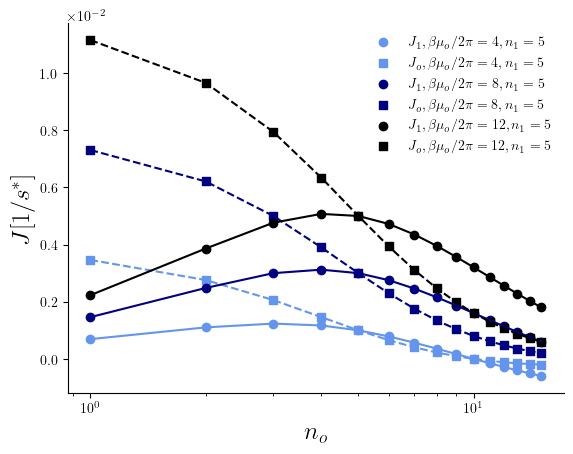

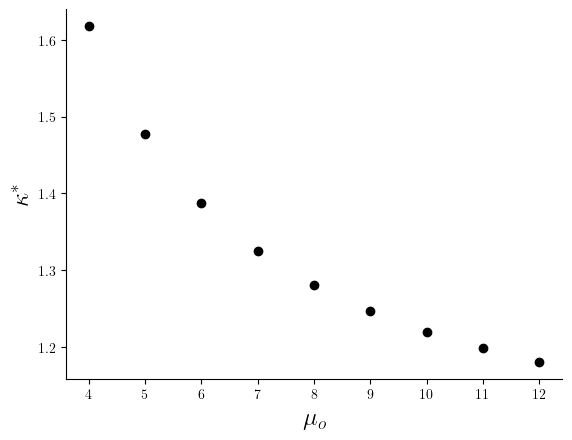

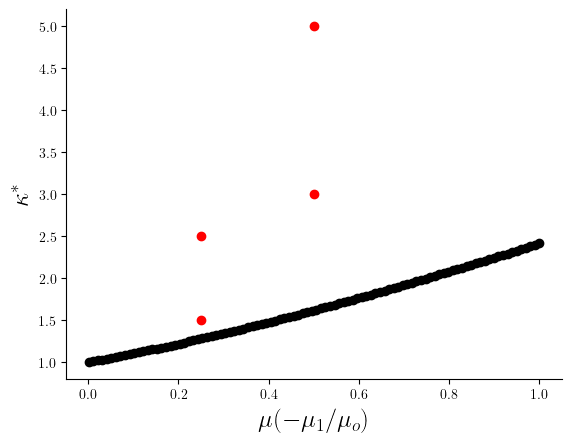

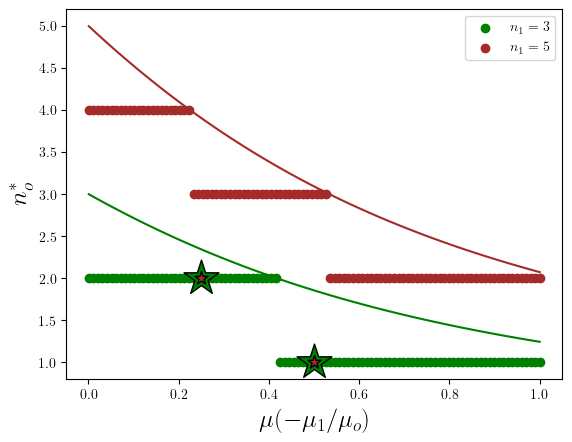

In [ ]:
from scipy.optimize import curve_fit

f0 = 4
f1 = -2
n1 = 5
n0 = array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])
k = n1/n0

def J1(k):
    return (f0 + f1/k)/(1000*(k + (1/k)))
def J0(k):
    return k*(f0 + f1/k)/(1000*(k + (1/k)))
def k_star(mu0,mu1):
    return (-mu1 + (mu1**2 + mu0**2)**0.5)/mu0
def k_star_mu(mu):
    return mu + (1 + (mu**2))**0.5
def n0_star_mu(n1,mu):
    return n1/(mu + (1 + (mu**2))**0.5)
    


# how J1 changes with n0
fig,ax = plt.subplots()

# how k* changes with mu0
fig1,ax1 = plt.subplots()

# how k* changes with mu1/mu0
fig2,ax2 = plt.subplots()

# how n0* changes with mu1/mu0
fig3,ax3 = plt.subplots()

colors = ["cornflowerblue", "navy", "black","darkorange", "red"]
i = 0
for n1 in [5]:
    for f0 in [4,8,12]:    
        ax.scatter(n0, J1(n1/n0), color = colors[i],label=fr"$J_1, \beta \mu_o/2 \pi= {f0}, n_1 = {n1}$")
        ax.plot(n0, J1(n1/n0), color = colors[i])
        ax.scatter(n0, J0(n1/n0), color = colors[i], marker = "s",label=fr"$J_o, \beta \mu_o/2 \pi= {f0}, n_1 = {n1}$")
        ax.plot(n0, J0(n1/n0), color = colors[i],linestyle="--")
        i+=1
ax.set_xlabel(r"$n_o$",fontsize=18)
ax.set_ylabel(r"$J[1/s^*]$",fontsize=18)
ax.legend(frameon=False)
ax.set_xscale("log")

ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# fig.savefig("/Users/sarealles/Desktop/research/Jan2025/J1_vs_n0_analytical_no_barrier.pdf")


##################
mu0 = array([4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0])
mu1 = -2.0
ax1.scatter(mu0, k_star(mu0,mu1),color = "black")
ax1.set_xlabel(r"$\mu_o$",fontsize=18)
ax1.set_ylabel(r"$\kappa^*$",fontsize=18)
# ax.legend(frameon=False)
# ax1.set_xscale("log")

# ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
###############
mu = np.linspace(0.001,1,100)
ax2.scatter(mu, k_star_mu(mu),color = "black")
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.set_xlabel(r"$\mu (-\mu_1/ \mu_o)$",fontsize=18)
ax2.set_ylabel(r"$\kappa^*$",fontsize=18)
ax2.scatter([0.25,0.5,0.25,0.5],[1.5,3,2.5,5],color = "red")
# ax2.set_xscale("symlog")
##################
ax3.plot(mu, array(n0_star_mu(3,mu)),color = "green")
ax3.scatter(mu, np.floor(array(n0_star_mu(3,mu))),color = "green",label = r"$n_1 = 3$")
ax3.scatter([0.25,0.5], [2,1], color="green", marker= "*", s= 700, edgecolor='black')
ax3.plot(mu, array(n0_star_mu(5,mu)),color = "brown")
ax3.scatter(mu, np.floor(array(n0_star_mu(5,mu))),color = "brown",label = r"$n_1 = 5$")
# ax3.plot(mu, array(n0_star_mu(10,mu)),color = "black")

# ax3.plot(mu, array(n0_star_mu(20,mu)),color = "pink")

ax3.scatter([0.25,0.5], [2,1], color="brown", marker= "*", s= 100, edgecolor='black')

ax3.set_xlabel(r"$\mu (-\mu_1/ \mu_o)$",fontsize=18)
ax3.set_ylabel(r"$n_o^*$",fontsize=18)
ax3.legend()


In [ ]:
f0 = 4
f1 = -2
n1 = 5
n0 = array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])
k = n1/n0
k = array([0.25,0.3,0.5,0.75,1,1.25,1.5,2,2.0,3,3.0,4,5,6,7,8,9,10,11,12,13,14,15])
k = array([0.05,0.1,0.15,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2,2.2,2.4,2.6,2.8,3,4,5,6,7,8,9,10,15,20,25,30,35,40])

def J1(k):
    y = (k*f0 + f1)/(1000*(k**2 + 1))
    return y, argmax(y)


fig,ax = plt.subplots()

colors = ["cornflowerblue", "navy", "black","darkorange", "red"]
i = 0
for n1 in [5]:
    for f0 in [4,8,12]:
        y, indexmax = J1(k)     
        ax.scatter(k, y, color = colors[i],label=fr"$\beta \mu_o/2 \pi= {f0}$")
        ax.plot(k, y, color = colors[i])
        i+=1
        print(f"at f0= {f0}, k* is {k[indexmax]}, giving n0 = {n1/k[indexmax]}")
ax.set_xlabel(r"$\kappa$",fontsize=18)
ax.set_ylabel(r"$J_1[1/s^*]$",fontsize=18)
ax.legend(frameon=False)
ax.set_xscale("log")

ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# fig.savefig("/Users/sarealles/Desktop/research/Jan2025/J1_vs_n0_analytical_no_barrier.pdf")


Individual compare

In [ ]:
model_array = ["model2"]
#model_array = ["model2"]
target_dir = "/Users/sarealles/Desktop/Data_processed/pfe_old/"
target_dir = "/Users/sarealles/Desktop/Data/"

# target_dir = "/Users/sarealles/Desktop/model1/Data_N_1000/pfe/"
# target_dir = "/Users/sarealles/Desktop/dt_dx_cluster/dt_0.0001/N_100/pfe/"

    
#individual plots for each model
Ec_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,32.0,40.0,50.0,60.0,64.0,70.0,80.0,90.0,100.0,120.0,128.0,130.0,140.0,150.0] 
Ec_array = [0.0,2.0,5.0,8.0,10.0,11.0,32.0,128.0] 
Ec_array = [12.0,16.0,32.0,64.0] 
f0 = 4
# n0_array = [8.0]
# n1_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0]
n1_array = [3.0]
n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0,16.0,17.0,18.0,19.0,20.0]
for model in ["model3"]:
    #change the input file name in the function if you want to include dt, N
    '''change the params in the function'''
    plot_P_n0_individual(target_dir, model,n0_array,n1_array,Ec_array,f0,dt=0.001,N=1000,E0=2.0,E1=2.0)
    plt.show()  


In [ ]:

A = np.array([[1, 0, 3],
              [0, 0, 0],
              [0, 0, 2]])

# Create x and y coordinates
x = np.linspace(0, 3, A.shape[1])
y = np.linspace(0, 3, A.shape[0])
X, Y = np.meshgrid(x, y)

# Create the contour plot
plt.contourf(X, Y, A, cmap='viridis')
plt.colorbar()
plt.title("Matrix Contour Plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

In [ ]:
arange(0, 121, 30)

### prob against ref for two arbitrary variables

In [ ]:
def plot_probability_against_ref_two_arbit(target_dir_array, model_array, n0_array,n1_array,Ec_array,f0_array,N_array,x_array,x11_array,a_array,partial,E0_array=[2.0,2.0]):
    
    E0 = E0_array[0];E1 = E0_array[0];psi_1=-2.0;phase=0.0
    if "BFM" in model_array or "CS" in model_array:
        psi_1 = -0.0
    colormapp = cm.get_cmap("GnBu")
    if "model1" in model_array:
        colormapp = cm.get_cmap("cool")
    
    
    
    fig_tot, ax_tot = subplots(1, int(len(Ec_array)), figsize=(int(len(Ec_array)) * 7, 5), sharey=True)
    for idx, ax in enumerate(ax_tot):
        ax.set_title(rf"$n_{{\rm o}} = {int(n0_array[idx])}$", fontsize=30)
    prob_data = [
        loadtxt(
            target_dir_array[0]+"/"+f"{model_array[0]}"+ f"_t_reference_E0_{E0}_Ecouple_{Ec_array[0]}_E1_{E1}_psi0_{f0_array[0]}_psi1_{psi_1}_n0_{n0_array[0]}_n1_{n1_array[0]}_phase_{phase}_outfile.dat",
            usecols=(0,),
        ).reshape((N_array[0], N_array[0])),
        loadtxt(
            target_dir_array[1]+"/"+f"{model_array[1]}"+ f"_t_reference_E0_{E0}_Ecouple_{Ec_array[1]}_E1_{E1}_psi0_{f0_array[1]}_psi1_{psi_1}_n0_{n0_array[1]}_n1_{n1_array[1]}_phase_{phase}_outfile.dat",
            usecols=(0,),
        ).reshape((N_array[1], N_array[1]))
    ]
    vmin, vmax = min(prob.min() for prob in prob_data), max(prob.max() for prob in prob_data)
    print(f"Vmin = {vmin}, Vmax = {vmax}")

    for w,Ec in enumerate(Ec_array):
        n0 = n0_array[w]
        [
            __, __,__, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
            m0, m1, phase,beta, gamma,__
            ] = set_params(model_array[w], n0_array[w],n1_array[w],f0_array[w])
        # if Ec >= 8.0:
        #     x = 20
        # if Ec >= 16.0:
        #     x = 20

        # ax_tot[w].set_title(rf"$model {model_array[w][-1]}, n_o = {n0_array[w]}, n_1 = {n1_array[w]}, E_c = {Ec}, \mu_o = {f0_array[w]}$")
        ax_tot[w].spines['top'].set_visible(False)
        ax_tot[w].spines['right'].set_visible(False)
        ax_tot[w].spines['left'].set_visible(False)
        ax_tot[w].spines['bottom'].set_visible(False)
        ax_tot[w].set_xlim([0.0,360.005])
        ax_tot[0].set_ylim([0.0,360.005])
        ax_tot[w].set_xticks(arange(0, 361, 60), labels=[r"$0$", r"$\pi/3$", r"$2\pi/3$", r"$\pi$", r"$4\pi/3$",r"$5\pi/3$",r"$2\pi$"])
        ax_tot[0].set_yticks(arange(0, 361, 60), labels=[r"$0$", r"$\pi/3$", r"$2\pi/3$", r"$\pi$", r"$4\pi/3$",r"$5\pi/3$",r"$2\pi$"])
        ax_tot[0].set_ylabel(r"$\theta_{1}$", fontsize=25)
        ax_tot[w].set_xlabel(r"$\theta_{\rm o}$", fontsize=25)
        ax_tot[w].tick_params(axis='both', which='major', labelsize=18)
        fig_model1, ax_model1 = subplots()
        # fig_model1.suptitle(fr"$ model {model_array[w][-1]}, n_o = {n0_array[w]},\ n_1 = {n1_array[w]},\ Ec = {Ec_array[w]},\ f_o = {f0_array[w]}$", fontsize=16)

        
        N1 = N_array[w]
        dx1 = (2*pi)/N1
        

        
        positions1 = arange(0.0, 2*pi, dx1)

        
        if "BFM" in model_array or "CS" in model_array:
            psi_1 = -0.0
        data1 = loadtxt(target_dir_array[w]+"/"+f"{model_array[w]}"+"_t_reference_E0_{0}_Ecouple_{1}_E1_{2}_psi0_{3}_psi1_{4}_n0_{5}_n1_{6}_phase_{7}_outfile.dat".format( E0,Ec_array[w],E1, f0_array[w], psi_1,n0_array[w],n1_array[w],phase),usecols=(0,3,4,5,6,7,8))

        
        prob1 = data1[:,0].reshape((N1,N1))
        P = data1[:,0]
        
        drift_at_pos1 = data1[:,1:3].T.reshape((2,N1,N1))
        diffusion_at_pos1 = data1[:,3:].T.reshape((4,N1,N1))
        

        
        flux_array1 = empty((2,N1,N1))

        calc_flux(positions1, prob1, drift_at_pos1,diffusion_at_pos1, flux_array1, N1, dx1)
        flux_array1 = asarray(flux_array1) / (dx1 * dx1)



        # select fewer arrows to draw
        M1 = N1//x_array[w]
        M11 = N1//x11_array[w]
        M111 = M1
        a = a_array[w]
        # number of arrows in a row/ column, preferably a number such that N/M is an integer.
        fluxX1 = empty((M1, M1))
        fluxY1 = empty((M1, M1))
        

        

        for k in range(M1):
            # print(fr"N1 is {N1}, M1 is {M1}")
            # print(flux_array1[0, ...][int(N1 / M1) * k, ::int(N1 / M1)])
            fluxX1[k] = flux_array1[0, ...][int(N1 / M1) * k, ::int(N1 / M1)]
            fluxY1[k] = flux_array1[1, ...][int(N1 / M1) * k, ::int(N1 / M1)]
       
        t_m1 = ax_model1.contourf(positions1 * (180/pi), positions1 * (180/pi), prob1.T, 10,cmap=colormapp)
        ''''first'''
        
        # Calculate the magnitude considering absolute values
        magnitudes = np.sqrt((np.abs(fluxX1.T))**2 + (np.abs(fluxY1.T))**2)

        # Find the smallest non-zero magnitude
        threshold = np.min(magnitudes[magnitudes > 0])

        # Zero out vectors with the smallest magnitude
        fluxX1_adjusted = np.where(magnitudes < a*threshold, nan, fluxX1.T)
        fluxY1_adjusted = np.where(magnitudes < a*threshold, nan, fluxY1.T)

        # Plot the quiver with the adjusted flux values
        # stretch_factor = 2  # Increase for stronger effect
        # fluxX1_scaled = ((fluxX1_adjusted - np.min(fluxX1_adjusted)) / 
        #         (np.max(fluxX1_adjusted) - np.min(fluxX1_adjusted)))
        # fluxY1_scaled = ((fluxY1_adjusted - np.min(fluxY1_adjusted)) / 
        #         (np.max(fluxY1_adjusted) - np.min(fluxY1_adjusted)))
        # ax_model1.quiver(
        #     positions1[::int(N1 / M1)] * (180 / np.pi),
        #     positions1[::int(N1 / M1)] * (180 / np.pi),
        #     np.sign(fluxX1_scaled - 0.5) * np.abs(fluxX1_scaled - 0.5) ** stretch_factor * 2,
        #     np.sign(fluxY1_scaled - 0.5) * np.abs(fluxY1_scaled - 0.5) ** stretch_factor * 2,
        #     scale_units='xy')
        '''second strategy'''
        ax_model1.quiver(
            positions1[::int(N1 / M1)] * (180 / np.pi),
            positions1[::int(N1 / M1)] * (180 / np.pi),
            fluxX1_adjusted,
            fluxY1_adjusted,
            scale_units='xy')
        ######################

        '''initial apprach
        '''
        # ax_model1.quiver(positions1[::int(N1 / M1)] * (180/pi), positions1[::int(N1 / M1)] * (180/pi), fluxX1.T, fluxY1.T,scale_units='xy')
        s = fluxY1.sum(axis=None)
        print(fr"fluxY1 is {s}")
        
        tot = ax_tot[w].contourf(positions1 * (180/pi), positions1 * (180/pi), prob1.T, 10,cmap=colormapp,vmin=vmin, vmax=vmax)
        # ax_tot[w].quiver(positions1[::int(N1 / M1)] * (180/pi), positions1[::int(N1 / M1)] * (180/pi), fluxX1.T, fluxY1.T,scale_units='xy')
        '''scaled axis length'''
        ax_tot[w].quiver(positions1[::int(N1 / M1)] * (180/pi), positions1[::int(N1 / M1)] * (180/pi), fluxX1_adjusted, fluxY1_adjusted,scale_units='xy', scale=0.000009)

        
        ax_model1.plot(linspace(0,360,1000), linspace(0,360,1000), color='red')
        
        
        ax_model1.set_xlim([0.0,361.0])
        ax_model1.set_xticks(arange(0, 361, 60), labels=[r"$0$", r"$\pi/3$", r"$2\pi/3$", r"$\pi$", r"$4\pi/3$",r"$5\pi/3$",r"$2\pi$"])
        ax_model1.set_yticks(arange(0, 361, 60), labels=[r"$0$", r"$\pi/3$", r"$2\pi/3$", r"$\pi$", r"$4\pi/3$",r"$5\pi/3$",r"$2\pi$"])
        ax_model1.set_ylabel(r"$\theta_{1}$", fontsize=20)

        ax_model1.set_xlabel(r"$\theta_{\rm o}$", fontsize=20)
        
        ax_model1.spines['top'].set_visible(False)
        ax_model1.spines['right'].set_visible(False)
        ax_model1.spines['left'].set_visible(False)
        ax_model1.spines['bottom'].set_visible(False)
       
        sfmt=ticker.ScalarFormatter()
        sfmt.set_powerlimits((0, 0))
        cbar1=fig_model1.colorbar(t_m1, ax=ax_model1, format=sfmt)
        cbar1.ax.tick_params(labelsize=10, axis='y')
        cbar1.ax.yaxis.offsetText.set_fontsize(10)
        # fig_model1.savefig(fr"/Users/sarealles/Desktop/research/CM-Aug2025/Prob_mod{model_array[w][-1]}_Ec_var_n0_{n0_array[w]}_fo_4_scaled.pdf")
        
        if partial:
            fig_model_p, ax_model_p = subplots()
            # fig_model_p.suptitle(fr"$ {model}, n_o = {n0},\ n_1 = {n1},\ Ec = {Ec},\ f_o = {psi_0}$", fontsize=16)
            
            # Define positions for the landscape
            positions1 = arange(0.0, (2 * pi / 3)+ dx1, dx1)
            
            # Initialize flux arrays
            fluxX1 = empty((M111, M111))
            fluxY1 = empty((M111, M111))

            # Fill the flux arrays
            for k in range(M111):
                fluxX1[k] = flux_array1[0, ...][int(N1 / M111) * k, ::int(N1 / M111)]
                fluxY1[k] = flux_array1[1, ...][int(N1 / M111) * k, ::int(N1 / M111)]
            
            # Take a subset of the flux arrays
            fX1 = fluxX1[0:(len(fluxX1) // 3)+1, 0:(len(fluxX1) // 3)+1]
            fY1 = fluxY1[0:(len(fluxX1) // 3)+1, 0:(len(fluxX1) // 3)+1]
            
            # Calculate the magnitude considering absolute values
            magnitudes = np.sqrt((np.abs(fX1.T))**2 + (np.abs(fY1.T))**2)

            # Find the smallest non-zero magnitude
            threshold = np.min(magnitudes[magnitudes > 0])

            # Zero out vectors with the smallest magnitude
            fluxX1_adjusted = np.where(magnitudes < a*threshold, nan, fX1.T)
            fluxY1_adjusted = np.where(magnitudes < a*threshold, nan, fY1.T)
            
            if True:
                l = len(fX1[0,:])
                fX1_mod_over = zeros((l,l))
                fY1_mod_over = zeros((l,l))
                fX1_mod_under = zeros((l,l))
                fY1_mod_under = zeros((l,l))

                for i in range(l):
                    for j in range(l):
                        if j<i:
                            fX1_mod_under[i,j]=fX1[i,j]
                            fY1_mod_under[i,j]=fY1[i,j]
                        elif j>i:
                            fX1_mod_over[i,j]=fX1[i,j]
                            fY1_mod_over[i,j]=fY1[i,j]
                # print(f"sum of flux array under the x=y: fX={trapz(trapz(fX1_mod_under, dx=x11*dx1, axis=1), dx=x11*dx1)}, fY={trapz(trapz(fY1_mod_under, dx=x11*dx1, axis=1), dx=x11*dx1)}")
                # print(f"sum of flux array over the x=y: fX={trapz(trapz(fX1_mod_over, dx=x11*dx1, axis=1), dx=x11*dx1)}, fY={trapz(trapz(fY1_mod_over, dx=x11*dx1, axis=1), dx=x11*dx1)}")
                            

            # Verify dimensions are compatible
            xcoordinate = positions1[::int(N1 / M111)] * (180 / pi)
            print(f"Length of xcoordinate: {len(xcoordinate)}")
            
            if len(fX1) != len(xcoordinate):
                print(f"Mismatch in dimensions: fX1 is {len(fX1)}, but xcoordinate is {len(xcoordinate)}")

            # Plot the contour
            t_m1 = ax_model_p.contourf(positions1 * (180 / pi), positions1 * (180 / pi), prob1[0:int(N1 / 3) +2, 0:int(N1 / 3)+2].T, levels=10, cmap=cm.get_cmap("cool"))
            
            # Plot quiver arrows, ensure dimensions match
            if fluxX1_adjusted.shape == fluxY1_adjusted.shape == (len(xcoordinate), len(xcoordinate)):
                ax_model_p.quiver(xcoordinate, xcoordinate, fluxX1_adjusted, fluxY1_adjusted, scale_units='xy')
            else:
                print(f"Quiver dimension mismatch: fX1 shape {fluxX1_adjusted.shape}, fY1 shape {fluxY1_adjusted.shape}, xcoordinate shape {xcoordinate.shape}")
            
            # Sum fluxY1 for debugging
            # s = fluxY1.sum(axis=None)
            # print(fr"fluxY1 sum is {s}")
            
            # Plot diagonal line
            ax_model_p.plot(linspace(0, 120, 120), linspace(0, 120, 120), color='red', linestyle='--')
            
            # Set axis limits and labels
            
            ax_model_p.set_xticks(arange(0, 121, 30), labels=[r"$0$", r"$\pi/6$", r"$\pi/3$", r"$\pi/2$", r"$2\pi/3$"], fontsize=16)
            ax_model_p.set_yticks(arange(0, 121, 30), labels=[r"$0$", r"$\pi/6$", r"$\pi/3$", r"$\pi/2$", r"$2\pi/3$"], fontsize=16)
            ax_model_p.set_ylabel(r"$\theta_{1}$", fontsize=30)
            ax_model_p.set_xlabel(r"$\theta_{\rm o}$", fontsize=30)
            ax_model_p.set_xlim([0.0, 120.0])
            
            ax_model_p.spines['top'].set_visible(False)
            ax_model_p.spines['right'].set_visible(False)
            ax_model_p.spines['left'].set_visible(False)
            ax_model_p.spines['bottom'].set_visible(False)
            # Set colorbar
            sfmt = ticker.ScalarFormatter()
            sfmt.set_powerlimits((0, 0))
            cbar11 = fig_model_p.colorbar(t_m1, ax=ax_model_p, format=sfmt)
            cbar11.ax.tick_params(labelsize=14, axis='y')
            cbar11.ax.yaxis.offsetText.set_fontsize(15)
            cbar11.set_label(r"$P_{\rm ss}(\theta_{\rm o}, \theta_{1})$", fontsize=16)
            ax_model_p.set_title(fr"$n_{{\rm o}} = {int(n0)}$", fontsize=30)
            n1 = n1_array[w]
            # fig_model_p.savefig(fr"/Users/sarealles/Desktop/research/CM-Aug2025/partial_Flux_ref_{model_array[0]}_N_{N1}_no_{n0}_n1_{n1}_EC_{Ec}_fo_{psi_0}.pdf", bbox_inches='tight', dpi=300)

        ax_tot[w].set_xlim([0.0,360])
        ax_tot[w].set_ylim([0.0,360])
        
    # cbar = fig_tot.colorbar(tot, ax=ax_tot, format=ticker.ScalarFormatter())
    cbar = fig_tot.colorbar(
    plt.cm.ScalarMappable(cmap=colormapp, norm=plt.Normalize(vmin=vmin, vmax=vmax)),
    ax=ax_tot.ravel().tolist(),
    orientation='vertical',  # Or 'horizontal', depending on your preference
    format=ticker.ScalarFormatter())
    cbar.ax.tick_params(labelsize=15)
    cbar.set_label(r"$P_{\rm ss}(\theta_{\rm o}, \theta_{1})$", fontsize=20)
    cbar.ax.yaxis.offsetText.set_fontsize(20)
    cbar.ax.tick_params(labelsize=15, axis='y')
    cbar.ax.yaxis.offsetText.set_fontsize(15)
    # fig_tot.savefig(fr"/Users/sarealles/Desktop/research/CM-Aug2025/Prob_mod3_mod3_mod3_Ec_4_n1_3_n0_2_4_15.pdf", bbox_inches='tight', dpi=300)



/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_41505/2911320590.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormapp = cm.get_cmap("GnBu")


Vmin = 1.323105792600168e-10, Vmax = 1.368251561452983e-05
fluxY1 is 0.1044311701319157
Length of xcoordinate: 14


/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_41505/2911320590.py:226: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  t_m1 = ax_model_p.contourf(positions1 * (180 / pi), positions1 * (180 / pi), prob1[0:int(N1 / 3) +2, 0:int(N1 / 3)+2].T, levels=10, cmap=cm.get_cmap("cool"))


fluxY1 is 0.07849114886823844
Length of xcoordinate: 14


/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_41505/2911320590.py:226: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  t_m1 = ax_model_p.contourf(positions1 * (180 / pi), positions1 * (180 / pi), prob1[0:int(N1 / 3) +2, 0:int(N1 / 3)+2].T, levels=10, cmap=cm.get_cmap("cool"))


fluxY1 is 0.04890763863254083
Length of xcoordinate: 14


/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_41505/2911320590.py:226: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  t_m1 = ax_model_p.contourf(positions1 * (180 / pi), positions1 * (180 / pi), prob1[0:int(N1 / 3) +2, 0:int(N1 / 3)+2].T, levels=10, cmap=cm.get_cmap("cool"))


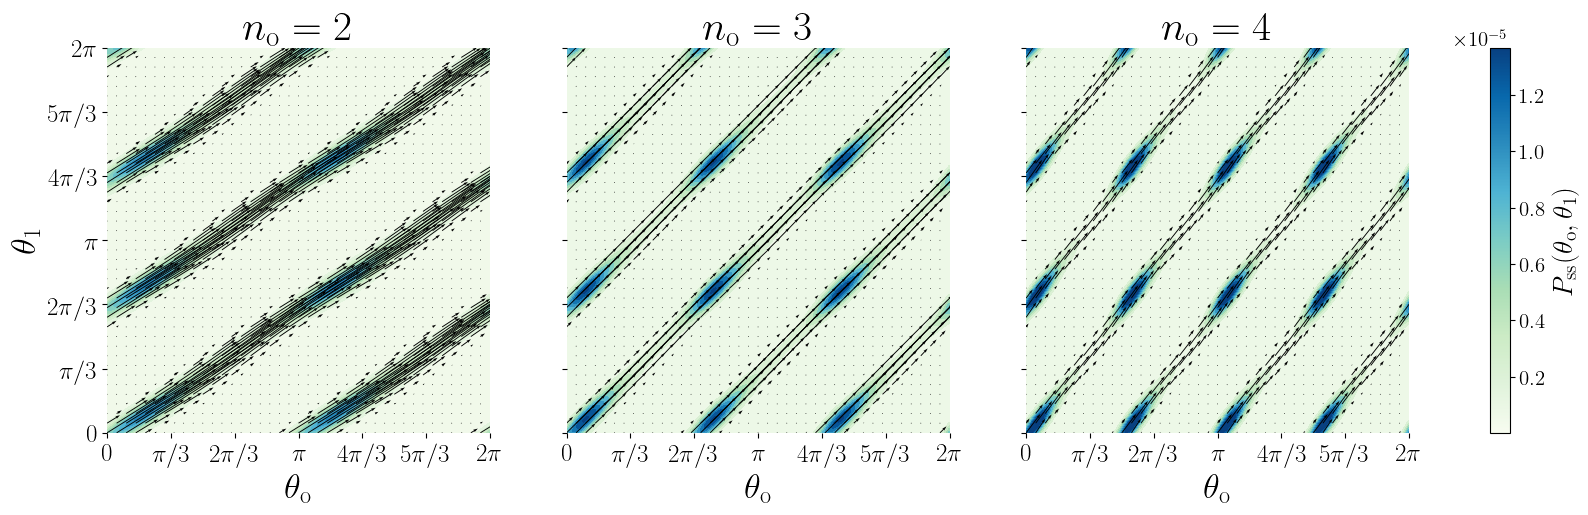

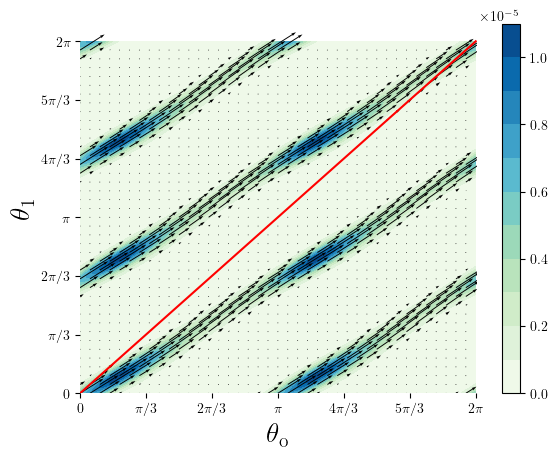

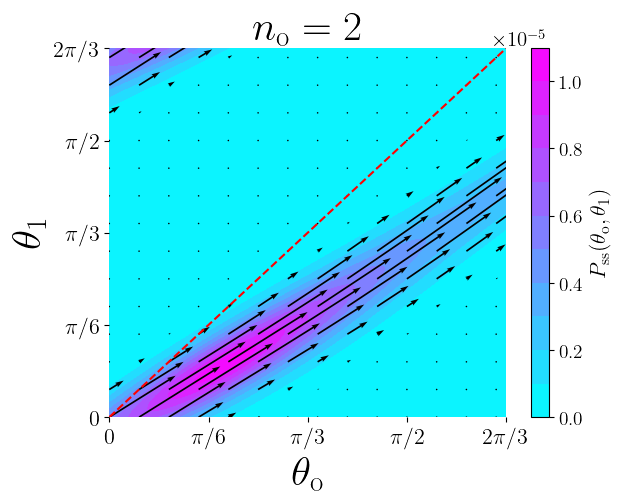

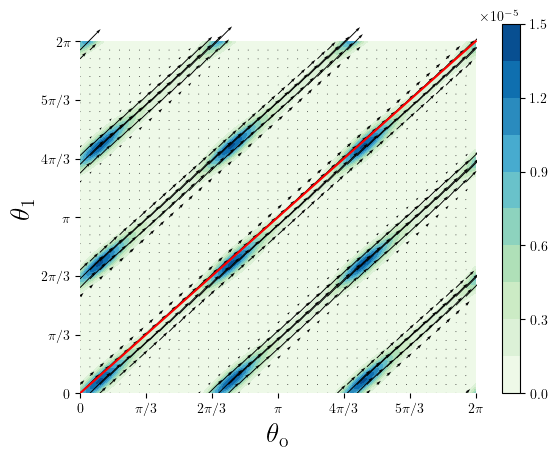

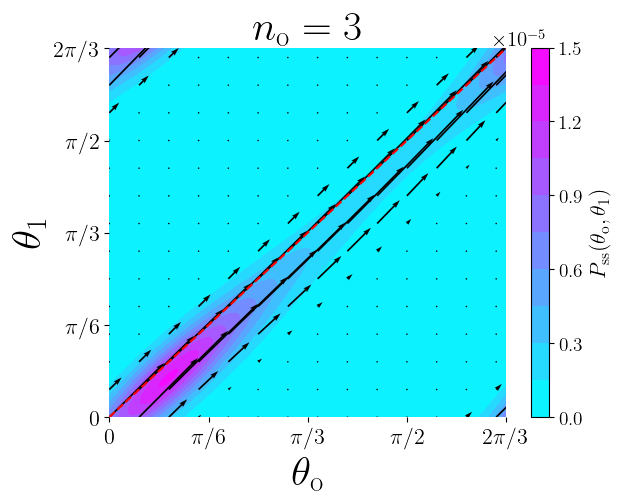

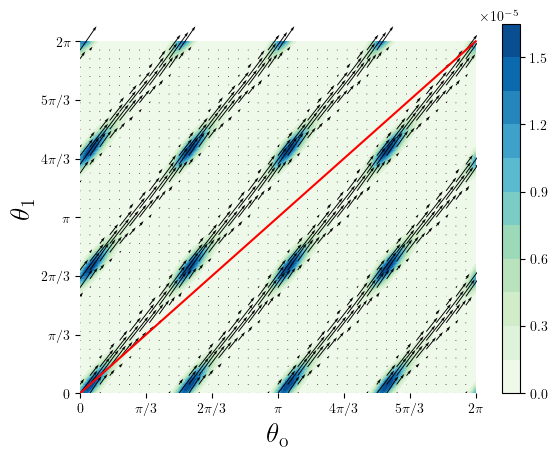

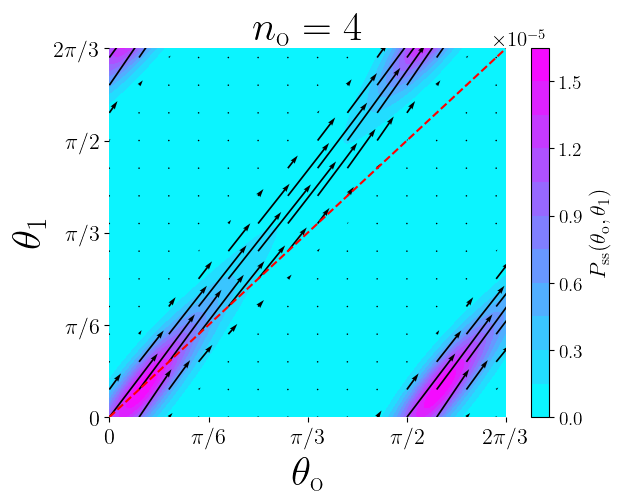

In [ ]:
# flux on probability two comaprison
target_dir = "/Volumes/Sara/Data/fo_4_f1_-2"
target_dir = "/Users/sarealles/Desktop/model1/data_N_100"
target_dir = "/Volumes/Backup2/model1/data_N_1000/sep2024"
target_dir = "/Users/sarealles/Desktop/sep2024"
target_dir = "/Users/sarealles/Desktop/model3/cluster"
# target_dir = "/Users/sarealles/Desktop/model1/cluster"
'''model1,3'''
target_dir_array = ["/Users/sarealles/Desktop/model1/cluster","/Users/sarealles/Desktop/model3/cluster"]
model_array = ["model1","model3"]
n0_array = [3.0,3.0]
n1_array = [3.0,3.0]
f0_array = [8.0,8.0]
N_array = [500,1000]
x_array = [25,50]
x1_array = [100,200]
Ec_array=[8.0,5.0]

#####################
'''model3,4,f0=8,Ec=2,n0=2,10'''
target_dir_array = ["/Users/sarealles/Desktop/research/GP-Mar2025","/Users/sarealles/Desktop/research/GP-Mar2025"]
model_array = ["model4","model4"]
n0_array = [3.0,6.0]
n1_array = [3.0,3.0]
f0_array = [8.0,8.0]
N_array = [2000,2000]
a_array = [2,2]
x_array = [100,100]
x1_array = [50,50]
Ec_array=[4.0,4.0]
#################
#####################
'''Thesis, model3,3,f0=4,barrierless,Ec=100,n0=3,6'''
# t = "/Users/sarealles/Desktop/model3/n1_5"
t = "/Users/sarealles/Desktop/model3/test"
target_dir_array = [t,t,t]
model_array = ["model3","model3","model3"]
n0_array = [2.0,3.0,4.0]
n1_array = [3.0,3.0,3.0]
f0_array = [8.0,8.0,8.0]
N_array = [1000,1000,1000]
# a_array = [5,2,0]
a_array = [0,0,0]
# x_array = [100,50,25]
x_array = [25,25,25]
x1_array = [1,1,1]
Ec_array=[12.0,12.0,12.0]
E0_array=[2.0,2.0,2.0]
##################
'''BFM, Ec=8, n0=2,6,15'''
# target_dir_array = ["/Users/sarealles/Desktop/model3/test","/Users/sarealles/Desktop/model3/test"]
# t = "/Users/sarealles/Desktop/BFM/change_gamma_f1_0_n1_5"
# target_dir_array = [t,t,t]
# model_array = ["BFM","BFM","BFM"]
# n1_array = [2.0,6.0,31.0]
# n0_array = [5.0,5.0,5.0]
# f0_array = [8.0,8.0,8.0]
# N_array = [2000,2000,2000]
# a_array = [0,0,0]
# x_array = [200,200,10]
# x1_array = [5,5,5]
# Ec_array=[8.0,8.0,8.0]
# E0_array=[2.0,2.0,2.0]
################
'''model1,1'''
# target_dir_array = ["/Users/sarealles/Desktop/model1/Data_N_540","/Users/sarealles/Desktop/model1/Data_N_540"]
# model_array = ["model1","model1"]
# n0_array = [3.0,6.0]
# n1_array = [3.0,3.0]
# f0_array = [4.0,4.0]
# N_array = [540,540]
# a_array = [10,10]
# x_array = [15,12]
# x1_array = [10,10]
# E0_array=[2.0,2.0]
# Ec_array=[12.0,12.0]
##############
'''CS,f0=8'''
# t = "/Users/sarealles/Desktop/CS/gamma0_1000_gamma1_1500_fo_8_f1_0_n1_3"
# target_dir_array = [t,t,t]
# model_array = ["CS","CS","CS"]
# n0_array = [2.0,3.0,9.0]
# n1_array = [3.0,3.0,3.0]
# f0_array = [8.0,8.0,8.0]
# N_array = [1000,1000,1000]
# a_array = [0,0,0]
# x_array = [25,25,25]
# x1_array = [1,1,1]
# Ec_array=[12.0,12.0,12.0]
# E0_array=[2.0,2.0,2.0]

####################################
partial=True

plot_probability_against_ref_two_arbit(target_dir_array, model_array, n0_array,n1_array,Ec_array,f0_array,N_array,x_array,x1_array,a_array,partial,E0_array)


In [ ]:
def plot_probability_against_ref(target_dir, params,model, n0,n1,Ec_list,N,x,x11,partial_landscape=True):
    
    [
            E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
            m0, m1, phase,beta, gamma,__
            ] = params
    
    
    fig_tot, ax_tot = subplots(1,int(len(Ec_list)), figsize=(24,4))
    prob_data = [
        loadtxt(
            target_dir+"/"+f"{model}"+ f"_t_reference_E0_{E0}_Ecouple_{Ec}_E1_{E1}_psi0_{psi_0}_psi1_{psi_1}_n0_{n0}_n1_{n1}_phase_{phase}_outfile.dat",
            usecols=(0,),
        ).reshape((N, N))
        for Ec in Ec_list
    ]
    vmin, vmax = min(prob.min() for prob in prob_data), max(prob.max() for prob in prob_data)

    
    for w,Ec in enumerate(Ec_list):
        # if Ec >= 8.0:
        #     x = 20
        # if Ec >= 16.0:
        #     x = 20

        ax_tot[w].set_title(rf"$E_c = {Ec}$")
        ax_tot[w].spines['top'].set_visible(False)
        ax_tot[w].spines['right'].set_visible(False)
        ax_tot[w].spines['left'].set_visible(False)
        ax_tot[w].spines['bottom'].set_visible(False)
        ax_tot[w].set_xticks(arange(0, 361, 60), labels=['$0$', r"$\frac{\pi}{3}$", r"$\frac{2\pi}{3}$", r"$\pi$", r"$\frac{4\pi}{3}$",r"$\frac{5\pi}{3}$", r"$2\pi$"])
        ax_tot[w].set_yticks(arange(0, 361, 60), labels=['$0$', r"$\frac{\pi}{3}$", r"$\frac{2\pi}{3}$", r"$\pi$", r"$\frac{4\pi}{3}$",r"$\frac{5\pi}{3}$", r"$2\pi$"])
        ax_tot[0].set_ylabel(r"$\theta_{1}$", fontsize=20)
        ax_tot[w].set_xlabel(r"$\theta_{0}$", fontsize=20)
        
        fig_model1, ax_model1 = subplots()
        fig_model1.suptitle(fr"$ model {model[-1]}, n_o = {n0},\ n_1 = {n1},\ Ec = {Ec},\ f_o = {psi_0}$", fontsize=16)

        
        N1 = N
        dx1 = (2*pi)/N1
        

        
        positions1 = arange(0.0, 2*pi, dx1)

        
        
        data1 = loadtxt(target_dir+"/"+f"{model}"+"_t_reference_E0_{0}_Ecouple_{1}_E1_{2}_psi0_{3}_psi1_{4}_n0_{5}_n1_{6}_phase_{7}_outfile.dat".format( E0,Ec,E1, psi_0, psi_1,n0,n1,phase),usecols=(0,3,4,5,6,7,8))

        
        prob1 = data1[:,0].reshape((N1,N1))
        P = data1[:,0]
        if not ( P >= 0.0).all():
            print(f"N = {N}, n0 = {n0}, Ec = {Ec} has negative prob")
            # check the normalization
        if not abs(P.sum(axis=None) - 1.0).__abs__() <= finfo('float32').eps :
            print(f"N = {N}, n0 = {n0}, Ec = {Ec} is not normalized, P sum is {P.sum(axis=None)}")

        
        drift_at_pos1 = data1[:,1:3].T.reshape((2,N1,N1))
        diffusion_at_pos1 = data1[:,3:].T.reshape((4,N1,N1))
        

        
        flux_array1 = empty((2,N1,N1))

        calc_flux(positions1, prob1, drift_at_pos1,diffusion_at_pos1, flux_array1, N1, dx1)
        flux_array1 = asarray(flux_array1) / (dx1 * dx1)



        # select fewer arrows to draw
        M1 = N//x
        M11 = N//x11
        # number of arrows in a row/ column, preferably a number such that N/M is an integer.
        fluxX1 = empty((M1, M1))
        fluxY1 = empty((M1, M1))
        

        

        for k in range(M1):
            # print(fr"N1 is {N1}, M1 is {M1}")
            # print(flux_array1[0, ...][int(N1 / M1) * k, ::int(N1 / M1)])
            fluxX1[k] = flux_array1[0, ...][int(N1 / M1) * k, ::int(N1 / M1)]
            fluxY1[k] = flux_array1[1, ...][int(N1 / M1) * k, ::int(N1 / M1)]
       
        t_m1 = ax_model1.contourf(positions1 * (180/pi), positions1 * (180/pi), prob1.T, 10,cmap=cm.get_cmap("cool"))
        ax_model1.quiver(positions1[::int(N1 / M1)] * (180/pi), positions1[::int(N1 / M1)] * (180/pi), fluxX1.T, fluxY1.T,scale_units='xy')
        s = fluxY1.sum(axis=None)
        print(fr"fluxY1 is {s}")
        
        tot = ax_tot[w].contourf(positions1 * (180/pi), positions1 * (180/pi), prob1.T, 10,cmap=cm.get_cmap("cool"),vmin=vmin, vmax=vmax)
        ax_tot[w].quiver(positions1[::int(N1 / M1)] * (180/pi), positions1[::int(N1 / M1)] * (180/pi), fluxX1.T, fluxY1.T,scale_units='xy')
        
        
        ax_model1.plot(linspace(0,360,1000), linspace(0,360,1000), color='red')
        
        
        ax_model1.set_xlim([0.0,360.0])
        ax_model1.set_xticks(arange(0, 361, 60), labels=['0', r"$\frac{\pi}{3}$", r"$\frac{2\pi}{3}$", r"$\pi$", r"$\frac{4\pi}{3}$",r"$\frac{5\pi}{3}$", r"$2\pi$"])
        ax_model1.set_yticks(arange(0, 361, 60), labels=['0', r"$\frac{\pi}{3}$", r"$\frac{2\pi}{3}$", r"$\pi$", r"$\frac{4\pi}{3}$",r"$\frac{5\pi}{3}$", r"$2\pi$"])
        ax_model1.set_ylabel(r"$\theta_{1}$", fontsize=20)

        ax_model1.set_xlabel(r"$\theta_{0}$", fontsize=20)
        
        ax_model1.spines['top'].set_visible(False)
        ax_model1.spines['right'].set_visible(False)
        ax_model1.spines['left'].set_visible(False)
        ax_model1.spines['bottom'].set_visible(False)
       
        sfmt=ticker.ScalarFormatter()
        sfmt.set_powerlimits((0, 0))
        cbar1=fig_model1.colorbar(t_m1, ax=ax_model1, format=sfmt)
        cbar1.ax.tick_params(labelsize=10, axis='y')
        cbar1.ax.yaxis.offsetText.set_fontsize(10)
        
        
        # fig_model1.savefig(fr"/Users/sarealles/Desktop/research/nov24/Flux_ref_model3_N_{N}_no_{n0}_n1_{n1}_EC_{Ec}_fo_{psi_0}.pdf")
        if partial_landscape:
            fig_model11, ax_model11 = subplots()
            fig_model11.suptitle(fr"$ model 3, n_o = {n0},\ n_1 = {n1},\ Ec = {Ec},\ f_o = {psi_0}$", fontsize=16)
            
            # Define positions for the landscape
            positions1 = arange(0.0, 2 * pi / 3, dx1)
            
            # Initialize flux arrays
            fluxX1 = empty((M11, M11))
            fluxY1 = empty((M11, M11))

            # Fill the flux arrays
            for k in range(M11):
                fluxX1[k] = flux_array1[0, ...][int(N1 / M11) * k, ::int(N1 / M11)]
                fluxY1[k] = flux_array1[1, ...][int(N1 / M11) * k, ::int(N1 / M11)]
            
            # Take a subset of the flux arrays
            fX1 = fluxX1[0:len(fluxX1) // 3 + 1,0:len(fluxX1) // 3 + 1]
            fY1 = fluxY1[0:len(fluxX1) // 3 + 1,0:len(fluxX1) // 3 + 1]
            if True:
                l = len(fX1[0,:])
                fX1_mod_over = zeros((l,l))
                fY1_mod_over = zeros((l,l))
                fX1_mod_under = zeros((l,l))
                fY1_mod_under = zeros((l,l))

                for i in range(l):
                    for j in range(l):
                        if j<i:
                            fX1_mod_under[i,j]=fX1[i,j]
                            fY1_mod_under[i,j]=fY1[i,j]
                        elif j>i:
                            fX1_mod_over[i,j]=fX1[i,j]
                            fY1_mod_over[i,j]=fY1[i,j]
                print(f"sum of flux array under the x=y: fX={trapz(trapz(fX1_mod_under, dx=x11*dx1, axis=1), dx=x11*dx1)}, fY={trapz(trapz(fY1_mod_under, dx=x11*dx1, axis=1), dx=x11*dx1)}")
                print(f"sum of flux array over the x=y: fX={trapz(trapz(fX1_mod_over, dx=x11*dx1, axis=1), dx=x11*dx1)}, fY={trapz(trapz(fY1_mod_over, dx=x11*dx1, axis=1), dx=x11*dx1)}")
                            

            # Verify dimensions are compatible
            xcoordinate = positions1[::int(N1 / M11)] * (180 / pi)
            
            if len(fX1) != len(xcoordinate):
                print(f"Mismatch in dimensions: fX1 is {len(fX1)}, but xcoordinate is {len(xcoordinate)}")

            # Plot the contour
            t_m1 = ax_model11.contourf(positions1 * (180 / pi), positions1 * (180 / pi), prob1[0:int(N1 / 3) + 1, 0:int(N1 / 3) + 1].T, 10, cmap=cm.get_cmap("cool"))
            
            # Plot quiver arrows, ensure dimensions match
            if fX1.T.shape == fY1.T.shape == (len(xcoordinate), len(xcoordinate)):
                ax_model11.quiver(xcoordinate, xcoordinate, fX1.T, fY1.T, scale_units='xy')
            else:
                print(f"Quiver dimension mismatch: fX1 shape {fX1.T.shape}, fY1 shape {fY1.T.shape}, xcoordinate shape {xcoordinate.shape}")
            
            # Sum fluxY1 for debugging
            s = fluxY1.sum(axis=None)
            print(fr"fluxY1 sum is {s}")
            
            # Plot diagonal line
            ax_model11.plot(linspace(0, 120, 120), linspace(0, 120, 120), color='red', linestyle='--')
            
            # Set axis limits and labels
            ax_model11.set_xlim([0.0, 120.0])
            ax_model11.set_xticks(arange(0, 121, 30), labels=[r"$0$", r"$\frac{\pi}{6}$", r"$\frac{\pi}{3}$",r"$\frac{\pi}{2}$",r"$\frac{2\pi}{3}$"])
            ax_model11.set_yticks(arange(0, 121, 30), labels=[r"$0$", r"$\frac{\pi}{6}$", r"$\frac{\pi}{3}$",r"$\frac{\pi}{2}$",r"$\frac{2\pi}{3}$"])
            ax_model11.set_ylabel(r"$\theta_{1}$", fontsize=20)
            ax_model11.set_xlabel(r"$\theta_{0}$", fontsize=20)

            ax_model11.spines['top'].set_visible(False)
            ax_model11.spines['right'].set_visible(False)
            ax_model11.spines['left'].set_visible(False)
            ax_model11.spines['bottom'].set_visible(False)
            # Set colorbar
            sfmt = ticker.ScalarFormatter()
            sfmt.set_powerlimits((0, 0))
            cbar11 = fig_model11.colorbar(t_m1, ax=ax_model11, format=sfmt)
            cbar11.ax.tick_params(labelsize=10, axis='y')
            cbar11.ax.yaxis.offsetText.set_fontsize(10)
            # fig_model11.savefig(fr"/Users/sarealles/Desktop/research/nov24/partial_Flux_ref_model3_N_{N}_no_{n0}_n1_{n1}_EC_{Ec}_fo_{psi_0}.pdf")
    cbar = fig_tot.colorbar(tot, ax=ax_tot, format=ticker.ScalarFormatter())
    cbar.ax.tick_params(labelsize=10, axis='y')
    cbar.ax.yaxis.offsetText.set_fontsize(10)
    # fig_tot.savefig(fr"/Users/sarealles/Desktop/research/nov24/Several_Ec_less_nodes_{model}_N_{N}_no_{n0}_n1_{n1}_fo_{psi_0}.pdf")

sum of flux array under the x=y: fX=0.0001192989340088691, fY=0.0001149354621500131
sum of flux array over the x=y: fX=1.7861999688240934e-05, fY=0.0001149354621500131


sum of flux array under the x=y: fX=0.00011534298390685422, fY=0.00011022145204472281
sum of flux array over the x=y: fX=1.5186227600387369e-05, fY=0.00011022145204472281

In [ ]:
#flux on probability
#n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0]
n0_array = [6.0]
n1_array = [3.0]
model_array = ["model1"]

target_dir = "/Volumes/Sara/Data/fo_4_f1_-2/"
# target_dir ="/Users/sarealles/Desktop/Data_processed/"
Ec_list = [2.0]
# Ec_list = [0.0]

target_dir = "/Volumes/Sara/Data/fo_4_f1_-2"
target_dir = "/Users/sarealles/Desktop/model1/data_N_100"
target_dir = "/Volumes/Backup2/model1/data_N_1000/sep2024"
target_dir = "/Users/sarealles/Desktop/sep2024"
target_dir = "/Users/sarealles/Desktop/model3/cluster"
# target_dir = "/Users/sarealles/Desktop/model1/cluster"

# target_dir = "/Users/sarealles/Desktop/model1/new_data_540_CM/new_set"
# for n1 in [3.0]:
#     for n0 in [4.0]:
#         # n0n1_str = str(int(n0))+"_" +str(int(n1))
#         plot_probability_against_ref(target_dir,set_params_Fo_4("model1", n0,n1), model_array,n0,n1,Ec_list,N=25)
#         plt.show() 

# target_dir = "/Users/sarealles/Desktop/model1/Data_N_50"
# for n1 in [3.0]:
#     for n0 in [4.0]:
#         # n0n1_str = str(int(n0))+"_" +str(int(n1))
#         plot_probability_against_ref(target_dir,set_params_Fo_4("model1", n0,n1), model_array,n0,n1,Ec_list,50)
#         plt.show() 
        
# target_dir = "/Users/sarealles/Desktop/model1/Data_N_100"
# for n1 in [3.0]:
#     for n0 in [4.0]:
#         # n0n1_str = str(int(n0))+"_" +str(int(n1))
#         plot_probability_against_ref(target_dir,set_params_Fo_4("model1", n0,n1), model_array,n0,n1,Ec_list,N=100)
#         plt.show() 

target_dir = "/Users/sarealles/Desktop/model1/Data_N_540"
Ec_list = [16.0,16.0,16.0]

model = "model1"
for n1 in [3.0]:
    for n0 in [3.0,6.0,9.0]:
        # n0n1_str = str(int(n0))+"_" +str(int(n1))
        plot_probability_against_ref(target_dir,set_params("model1", n0,n1,f0=4.0,E0=2.0,E1=2.0), model,n0,n1,Ec_list,N=540,x=10,x11=10,partial_landscape=True)
        # plot_probability_against_ref(target_dir,set_params_Fo_4("model1", n0,n1,E0=2.0,E1=2.0), model_array,n0,n1,Ec_list,N=1000,x=20,x11=10,partial_landscape=True)
        plt.show() 
        




## EMMA

In [ ]:

# ###Emma's
# def plot_P_n0_individual_emma(target_dir,model,n0_array,n1_array,Ec_array):
#     timescale = 1.5 * 10**4 
#     #individually plotting for each model P vs no for various Ec values in one single plot

#     #fig for P vs n0
#     fig, ax = plt.subplots(1, 1, figsize=(5,5))
#     #fig6 for P0 vs n0
#     fig6, ax6 = plt.subplots(1, 1, figsize=(5,5))
#     #fig1 for eta vs n0
#     fig1, ax1 = plt.subplots(1, 1, figsize=(5,5))
#     #fig2 for j1 vs n0
#     fig2, ax2 = plt.subplots(1, 1, figsize=(5,5))
#     #fig2 for jo vs n0
#     fig5, ax5 = plt.subplots(1, 1, figsize=(5,5))
#     #fig3 for jslip vs n0
#     fig3, ax3 = plt.subplots(1, 1, figsize=(5,5))
#     # #fig4 for eta if assume fo always wins
#     fig4, ax4 = plt.subplots(1, 1, figsize=(5,5))
#     #fig7 P1 vs. eta
#     fig7, ax7 = plt.subplots(1, 2, figsize=(8,4), sharey="row")
    
#     ax.axhline(0.0,color="black", lw=1.0)
#     ax3.axhline(0.0,color="black", lw=1.0)
#     ax6.axhline(0.0,color="black", lw=1.0)
#     ax4.axhline(0.0,color="black", lw=1.0)
#     ax2.axhline(0.0,color="black", lw=1.0)
#     ax5.axhline(0.0,color="black", lw=1.0)
#     ax1.axhline(1.0,color="black", lw=1.0)
    
#     index = int(model[-1])-1
#     for n1 in n1_array:
#         for i,Ec in enumerate(Ec_array):
#             n0_exists = []
#             P_at_Ec = []
#             P0_at_Ec = []
#             eta_at_Ec = []
#             eta_at_inf = []
#             eta_Fo_wins = []
#             j1_at_Ec = []
#             jo_at_Ec = []
#             jslip_at_Ec = []
            
#             for n0 in n0_array:
#                 params = set_params_Fo_4(model, n0,n1)
#                 n0n1_str = str(int(n0))+"_"+ str(int(n1))
#                 target_dir_temp = target_dir 
            
#                 [
#                 E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
#                 m0, m1, phase,beta, gamma,__
#                 ] = params
                
#                 input_file_name = ("/flux_power_efficiency_"
#                 + "E0_{0}_E1_{1}_psi1_{2}_psi2_{3}_n1_{4}_n2_{5}_Ecouple_{6}_outfile.dat")
                
#                 if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, Ec)):
#                     print("not found")
#                     continue

#                 Ec_val,flux_X, flux_Y,power_X, power_Y, efficiency_mod_val= loadtxt(
#                 target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,Ec),unpack=True, usecols=(0,1,2,3,4,5))
#                 print("ec_val", Ec_val)
#                 print("Ec = {Ec}")

#                 # Convert Ec_list to a list if it is a single value
                
#                 # Ec_list.append(Ec_val)
#                 # integrate_power_Y.append(power_Y)
#                 # integrate_power_X.append(power_X)
#                 # integrate_flux_X.append(flux_X)
#                 # integrate_flux_Y.append(flux_Y)
#                 # efficiency_mod.append(efficiency_mod_val)
                

#                 # print(integrate_power_Y)
                
#                 if Ec_val == Ec:
#                     print("Ec found")
#                     n0_exists.append(int(n0))
#                     P0_at_Ec.append(2*pi*power_X)
#                     P_at_Ec.append(-2*pi*power_Y)
#                     eta_at_Ec.append(efficiency_mod_val)
#                     j1_at_Ec.append(flux_Y)
#                     jo_at_Ec.append(flux_X)
#                     # eta_Fo_wins.append(efficiency[j])
#                     if model =="model3" or model=="model4":
#                         jslip_at_Ec.append(n0*flux_X-n1*flux_Y)
#                     else:
#                         jslip_at_Ec.append(flux_X-flux_Y)
                            
                        
#                 eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                
#             if model =="model2" or model=="model4":
#                 x = str(psi_0/8)
#                 psi_0 = "\\frac{n_o}{4}"
#                 f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
#             else:
#                 psi_0 = 2
#                 f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
#             print("n0 list and P", n0_exists,P_at_Ec)    
#             fig.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
#             ax.plot(n0_exists,P_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
#             ax.tick_params(labelsize=15, axis='both')
#             ax.set_xlabel(r"$n_o$", fontsize=15)
#             ax.set_xticks(n0_exists)
#             ax.set_ylabel(r"$\mathcal{P}_{1}$", fontsize=15)
#             #ax.legend(loc='upper right', prop={'size':12})

#             fig1.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
#             ax1.plot(n0_exists,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
#             ax1.tick_params(labelsize=15, axis='both')
#             ax1.set_xlabel(r"$n_o$", fontsize=15)
#             ax1.set_ylabel(r"$\eta$", fontsize=15)
#             #ax1.legend(loc='upper right', prop={'size':12})
            
#             fig7.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
#             ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
#             ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
#             # ax7[1].set_title(r"$\mathcal{P}_{o}$")
#             # ax7[0].set_title(r"$\mathcal{P}_{1}$")
#             ax7[0].tick_params(labelsize=15, axis='both')
#             ax7[1].tick_params(labelsize=15, axis='both')
#             ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
#             ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
#             ax7[0].set_ylabel(r"$\eta$", fontsize=15)
            
#             fig2.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
#             ax2.plot(n0_exists,j1_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
#             ax2.tick_params(labelsize=15, axis='both')
#             ax2.set_xlabel(r"$n_o$", fontsize=15)
#             ax2.set_xticks(n0_exists)
#             ax2.set_ylabel(r"$J_{1}$", fontsize=15)
            
#             fig5.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
#             ax5.plot(n0_exists,jo_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
#             ax5.tick_params(labelsize=15, axis='both')
#             ax5.set_xlabel(r"$n_o$", fontsize=15)
#             ax5.set_xticks(n0_exists)
#             ax5.set_ylabel(r"$J_{o}$", fontsize=15)
            
#             fig3.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
#             ax3.plot(n0_exists,jslip_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
#             ax3.tick_params(labelsize=15, axis='both')
#             ax3.set_xlabel(r"$n_o$", fontsize=15)
#             ax3.set_xticks(n0_exists)
#             ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

#             ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#             ax.spines['right'].set_visible(False)
#             ax.spines['bottom'].set_visible(False)
#             ax.spines['top'].set_visible(False)
            
#             # fig4.suptitle(fr"${model},\ \eta ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
#             # ax4.plot(n0_exists,eta_Fo_wins, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
#             # ax4.tick_params(labelsize=15, axis='both')
#             # ax4.set_xlabel(r"$n_o$", fontsize=15)
#             # ax4.set_xticks(n0_exists)
#             # ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


#             fig6.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=15)
#             ax6.plot(n0_exists,P0_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
#             ax6.tick_params(labelsize=15, axis='both')
#             ax6.set_xlabel(r"$n_o$", fontsize=15)
#             ax6.set_xticks(n0_exists)
#             ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
            
#             ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#             ax.spines['right'].set_visible(False)
#             ax.spines['bottom'].set_visible(False)
#             ax.spines['top'].set_visible(False)
            
#             ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#             ax2.spines['right'].set_visible(False)
#             ax2.spines['bottom'].set_visible(False)
#             ax2.spines['top'].set_visible(False)
            
#             ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#             ax5.spines['right'].set_visible(False)
#             ax5.spines['bottom'].set_visible(False)
#             ax5.spines['top'].set_visible(False)
            
#             ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#             # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
#             ax7[0].spines['right'].set_visible(False)
#             ax7[0].spines['bottom'].set_visible(False)
#             ax7[0].spines['top'].set_visible(False)
#             ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#             # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
#             ax7[1].spines['right'].set_visible(False)
#             ax7[1].spines['bottom'].set_visible(False)
#             ax7[1].spines['top'].set_visible(False)
            
#             ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#             ax6.spines['right'].set_visible(False)
#             ax6.spines['bottom'].set_visible(False)
#             ax6.spines['top'].set_visible(False)
            
#             ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#             ax4.spines['right'].set_visible(False)
#             ax4.spines['bottom'].set_visible(False)
#             ax4.spines['top'].set_visible(False)
            
#             ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#             ax3.spines['right'].set_visible(False)
#             ax3.spines['bottom'].set_visible(False)
#             ax3.spines['top'].set_visible(False)
            
#             ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
#             ax1.spines['right'].set_visible(False)
#             ax1.spines['bottom'].set_visible(False)
#             ax1.spines['top'].set_visible(False)
            
#             ax.set_xscale("log")
#             ax1.set_xscale("log")
#             ax2.set_xscale("log")
#             ax3.set_xscale("log")
#             ax4.set_xscale("log")
#             ax5.set_xscale("log")
#             ax6.set_xscale("log")
#             ax7[0].set_xscale("symlog")
#             ax7[1].set_xscale("symlog")
            
           
#             #ax.set_yscale("log")
#         # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
    
#     ax.legend(prop={'size': 12}, title='$E_c$', frameon=False, ncol=2, labelspacing=0.05,
#           bbox_to_anchor=(0.31, 0.8), loc='center')
#     # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
#     ax1.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
#     ax2.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
#     ax3.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
#     ax4.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
#     ax6.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
#     ax5.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
#     ax7[0].legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
#     # fig.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
#     # fig1.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_eta_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
#     # fig2.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
#     plt.show()

In [ ]:
def plot_P_n0_individual_emma(target_dir,model,n0_array,n1_array,Ec_array):
    '''wrong timescale used in paper'''
    timescale = 1.5 * 10**4 
    '''timescale used in thesis'''
    timescale = 4.8 * 10**7 
    #individually plotting for each model P vs no for various Ec values in one single plot

    #fig for P vs n0
    fig, ax = plt.subplots(1, 1, figsize=(5,5))
    #fig6 for P0 vs n0
    fig6, ax6 = plt.subplots(1, 1, figsize=(5,5))
    #fig1 for eta vs n0
    fig1, ax1 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for j1 vs n0
    fig2, ax2 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for jo vs n0
    fig5, ax5 = plt.subplots(1, 1, figsize=(5,5))
    #fig3 for jslip vs n0
    fig3, ax3 = plt.subplots(1, 1, figsize=(5,5))
    # #fig4 for eta if assume fo always wins
    fig4, ax4 = plt.subplots(1, 1, figsize=(5,5))
    #fig7 P1 vs. eta
    fig7, ax7 = plt.subplots(1, 2, figsize=(8,4), sharey="row")
    
    ax.axhline(0.0,color="black", lw=1.0)
    ax3.axhline(0.0,color="black", lw=1.0)
    ax6.axhline(0.0,color="black", lw=1.0)
    ax4.axhline(0.0,color="black", lw=1.0)
    ax2.axhline(0.0,color="black", lw=1.0)
    ax5.axhline(0.0,color="black", lw=1.0)
    ax1.axhline(1.0,color="black", lw=1.0)
    
    index = int(model[-1])-1
    for n1 in n1_array:
        for i,Ec in enumerate(Ec_array):
            n0_exists = []
            P_at_Ec = []
            P0_at_Ec = []
            eta_at_Ec = []
            eta_at_inf = []
            eta_Fo_wins = []
            j1_at_Ec = []
            jo_at_Ec = []
            jslip_at_Ec = []
        
        
            params = set_params_Fo_4(model, 3.0,n1)
            n0n1_str = str(int(n0))+"_"+ str(int(n1))
            target_dir_temp = target_dir
        
            [
            E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
            m0, m1, phase,beta, gamma,__
            ] = params
            
            # "/flux_power_efficiency_E0_2.0_E1_2.0_psi1_4.0_psi2_-2.0_n2_3.0_Ecouple_0.0_outfile
            input_file_name = ("flux_power_efficiency_"
            + "E0_{0}_E1_{1}_psi1_{2}_psi2_{3}_n2_{4}_Ecouple_{5}_outfile.dat")
            
            if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1,n1, Ec)):
                print(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n1, Ec),"file not found")
                continue

            n0_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency_mod= loadtxt(
            target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n1,Ec),unpack=True, usecols=(0,1,2,3,4,5))

            # Convert Ec_list to a list if it is a single value
            if isinstance(n0_list, float):
                print("single value")
                n0_list = [n0_list]
                integrate_power_Y = [integrate_power_Y]
                integrate_power_X = [integrate_power_X]
                integrate_flux_X = [integrate_flux_X]
                integrate_flux_Y = [integrate_flux_Y]
                efficiency_mod = [efficiency_mod]
                efficiency = [efficiency]

            # print(integrate_power_Y)
            for i in range(len(n0_array)):
                for j in range(len(n0_list)):
                    if int(n0_list[j]) == int(n0_array[i]):
                        n0_exists.append(int(n0_list[j]))
                        P0_at_Ec.append(2*pi*integrate_power_X[j])
                        P_at_Ec.append(-2*pi*integrate_power_Y[j])
                        eta_at_Ec.append(efficiency_mod[j])
                        j1_at_Ec.append(integrate_flux_Y[j])
                        jo_at_Ec.append(integrate_flux_X[j])
                        # eta_Fo_wins.append(efficiency[j])
                        if model =="model3" or model=="model4":
                            jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                        else:
                            jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                            
                    
            # eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
            print("J0 is :", jo_at_Ec)
            print("J1 is :", j1_at_Ec)
            if model =="model2" or model=="model4":
                x = str(psi_0/8)
                psi_0 = "\\frac{n_o}{4}"
                f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
            else:
                psi_0 = 2
                f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                
            fig.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            ax.plot(n0_exists,P_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
            ax.tick_params(labelsize=15, axis='both')
            ax.set_xlabel(r"$n_o$", fontsize=15)
            ax.set_xticks(n0_exists)
            ax.set_ylabel(r"$\mathcal{P}_{1}$", fontsize=15)
            #ax.legend(loc='upper right', prop={'size':12})

            fig1.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            ax1.plot(n0_exists,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
            for i, txt in enumerate(n0_exists):
                if eta_at_Ec[i] > 0.5:
                    print(fr"eta is greater than 0.5 at {txt}")
            ax1.tick_params(labelsize=15, axis='both')
            ax1.set_xlabel(r"$n_o$", fontsize=15)
            ax1.set_ylabel(r"$\eta$", fontsize=15)
            #ax1.legend(loc='upper right', prop={'size':12})
            
            fig7.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
            ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
            # ax7[1].set_title(r"$\mathcal{P}_{o}$")
            # ax7[0].set_title(r"$\mathcal{P}_{1}$")
            ax7[0].tick_params(labelsize=15, axis='both')
            ax7[1].tick_params(labelsize=15, axis='both')
            ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
            ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
            ax7[0].set_ylabel(r"$\eta$", fontsize=15)
            
            fig2.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            ax2.plot(n0_exists,j1_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
            ax2.tick_params(labelsize=15, axis='both')
            ax2.set_xlabel(r"$n_o$", fontsize=15)
            ax2.set_xticks(n0_exists)
            ax2.set_ylabel(r"$J_{1}$", fontsize=15)
            
            fig5.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            ax5.plot(n0_exists,jo_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
            ax5.tick_params(labelsize=15, axis='both')
            ax5.set_xlabel(r"$n_o$", fontsize=15)
            ax5.set_xticks(n0_exists)
            ax5.set_ylabel(r"$J_{o}$", fontsize=15)
            
            fig3.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            ax3.plot(n0_exists,jslip_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
            ax3.tick_params(labelsize=15, axis='both')
            ax3.set_xlabel(r"$n_o$", fontsize=15)
            ax3.set_xticks(n0_exists)
            ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

            ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['top'].set_visible(False)
            
            fig4.suptitle(fr"${model},\ \eta ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
            # ax4.plot(n0_exists,eta_Fo_wins, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
            ax4.tick_params(labelsize=15, axis='both')
            ax4.set_xlabel(r"$n_o$", fontsize=15)
            ax4.set_xticks(n0_exists)
            ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


            fig6.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=15)
            ax6.plot(n0_exists,P0_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
            ax6.tick_params(labelsize=15, axis='both')
            ax6.set_xlabel(r"$n_o$", fontsize=15)
            ax6.set_xticks(n0_exists)
            ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
            
            ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['top'].set_visible(False)
            
            ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax2.spines['right'].set_visible(False)
            ax2.spines['bottom'].set_visible(False)
            ax2.spines['top'].set_visible(False)
            
            ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax5.spines['right'].set_visible(False)
            ax5.spines['bottom'].set_visible(False)
            ax5.spines['top'].set_visible(False)
            
            ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
            ax7[0].spines['right'].set_visible(False)
            ax7[0].spines['bottom'].set_visible(False)
            ax7[0].spines['top'].set_visible(False)
            ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
            ax7[1].spines['right'].set_visible(False)
            ax7[1].spines['bottom'].set_visible(False)
            ax7[1].spines['top'].set_visible(False)
            
            ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax6.spines['right'].set_visible(False)
            ax6.spines['bottom'].set_visible(False)
            ax6.spines['top'].set_visible(False)
            
            ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax4.spines['right'].set_visible(False)
            ax4.spines['bottom'].set_visible(False)
            ax4.spines['top'].set_visible(False)
            
            ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax3.spines['right'].set_visible(False)
            ax3.spines['bottom'].set_visible(False)
            ax3.spines['top'].set_visible(False)
            
            ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax1.spines['right'].set_visible(False)
            ax1.spines['bottom'].set_visible(False)
            ax1.spines['top'].set_visible(False)
            
            ax.set_xscale("log")
            ax1.set_xscale("log")
            ax2.set_xscale("log")
            ax3.set_xscale("log")
            ax4.set_xscale("log")
            ax5.set_xscale("log")
            ax6.set_xscale("log")
            ax7[0].set_xscale("symlog")
            ax7[1].set_xscale("symlog")
            
           
            #ax.set_yscale("log")
        # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
    
    ax.legend(prop={'size': 12}, title='$E_c$', frameon=False, ncol=2, labelspacing=0.05,
          bbox_to_anchor=(0.31, 0.8), loc='center')
    # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    ax1.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    ax2.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    ax3.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    ax4.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    ax6.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    ax5.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    ax7[0].legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
    # fig.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
    # fig1.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_eta_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
    # fig2.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
    plt.show()
        

In [ ]:
#Emma's temp A plot of P vs n0 for different Ec


model_array = ["model1"]
#model_array = ["model2"]
target_dir = "/Users/sarealles/Desktop/model1/data_N_360_Emma/"


    
#individual plots for each model
Ec_array = [128.0] 
n1_array = [3.0]
n0_array = [1.0,2.0,6.0,12.0]
for model in ["model1"]:
    plot_P_n0_individual_emma(target_dir, model,n0_array,n1_array,Ec_array)
    plt.show()  


# Comparing different N plots for Ec=16,128


## $E_c=0$

#### Does normalizing P help? (tested for N = 100)

In [ ]:
J0_100_laptop_norm=array([0.000513261073252998, 0.0004394161207566945, 0.0004141673229038262, 0.0004045906834515559, 0.0004015152835220226])
J1_100_laptop_norm=array([-0.0002206571264202179, -0.0002199487944646351, -0.0002198110897012188, -0.0002198855995381271, -0.0002200383104213917])
eff_100_laptop_norm=array([-0.2149560310717846, -0.2502739249596411, -0.2653650801807234, -0.2717383376976046, -0.2740098813814181])
n0_array_100_laptop_norm=[3, 6, 9, 12, 15]


J0_100_laptop=array([0.0005132610732535232, 0.0004394161207558399, 0.0004141673229030153, 0.0004045906834507497, 0.000401515283521219])
J1_100_laptop=array([-0.0002206571264204439, -0.0002199487944642075, -0.0002198110897007883, -0.000219885599537689, -0.0002200383104209516])
eff_100_laptop=array([-0.2149560310717848, -0.2502739249596413, -0.2653650801807233, -0.2717383376976047, -0.2740098813814184])
n0_array_100_laptop=[3, 6, 9, 12, 15]

fig,ax = plt.subplots(1,4,figsize=(20,4))
fig.suptitle(r"$E_c = 0.0$", fontsize=25)
# ax[2].axhline(0.0,color="black", lw=1.0)

ax[0].plot(n0_array_100_laptop,J0_100_laptop, label = fr"$100$",marker ="o", color="r",lw=1.0,markersize=8)
ax[0].plot(n0_array_100_laptop_norm,J0_100_laptop_norm, label = fr"$100-N$",marker ="o", color="pink",lw=1.0,markersize=8)

ax[1].plot(n0_array_100_laptop,J1_100_laptop, label = fr"$100$",marker ="^", color="r",lw=1.0,markersize=8)
ax[1].plot(n0_array_100_laptop_norm,J1_100_laptop_norm, label = fr"$100-N$",marker ="^", color="pink",lw=1.0,markersize=8)

ax[2].plot(n0_array_100_laptop,J0_100_laptop-J1_100_laptop, label = fr"$100$",marker ="d", color="r",lw=1.0,markersize=8)
ax[2].plot(n0_array_100_laptop_norm,J0_100_laptop_norm-J1_100_laptop_norm, label = fr"$100-N$",marker ="d", color="pink",lw=1.0,markersize=8)

ax[3].plot(n0_array_100_laptop,eff_100_laptop, label = fr"$100$",marker ="s", color="r",lw=1.0,markersize=8)
ax[3].plot(n0_array_100_laptop_norm,eff_100_laptop_norm, label = fr"$100-N$",marker ="s", color="pink",lw=1.0,markersize=8)


ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax[0].set_ylabel(r"$J_o$", size=20)
ax[1].set_ylabel(r"$J_1$", size=20)
ax[2].set_ylabel("$J_{slip}$", size=20)
ax[3].set_ylabel("$\eta$", size=20)
ax[0].set_xlabel(r"$n_o$", size=20)
ax[1].set_xlabel(r"$n_o$", size=20)
ax[2].set_xlabel(r"$n_o$", size=20)
ax[3].set_xlabel(r"$n_o$", size=20)

ax[0].legend(prop={'size': 20}, title='$N$', frameon=False, ncol=1, labelspacing=0.05,
          bbox_to_anchor=(0.3, 0.97), title_fontsize='large')
ax[0].set_xscale("log")
ax[1].set_xscale("log")
ax[2].set_xscale("log")
ax[3].set_xscale("log")



ax[0].set_xlim(0, 15.5)
ax[1].set_xlim(0, 15.5)
ax[2].set_xlim(0, 15.5)
ax[3].set_xlim(0, 15.5)
# ax[1].set_xlim(9.5, 31.5)
# ax[2].set_xlim(9.5, 31.5)
# ax[3].set_xlim(9.5, 31.5)

In [ ]:
J0_360_cluster_full=array([0.0004649511569162263, 0.0004362174235179879, 0.0004277409753487441, 0.0004215301115427494, 0.0004168784316294101, 0.0004133249663052049, 0.0004105627465838087, 0.0004083827810693083, 0.0004066396407899257, 0.0004052300137540544, 0.0004040790879857317, 0.0004031317294215746, 0.0004023466506336289, 0.0004016924815018272, 0.0004011450728550616, 0.0004006856143516913, 0.000400299299604284, 0.0003999743652328148, 0.0003997013894013575, 0.0003994727730404719, 0.000399282351437254, 0.0003991251000371612, 0.0003989969091458923, 0.0003988944095827451, 0.0003988148364156964])
J1_360_cluster_full=array([-0.0002240845664021367, -0.0002239857291023202, -0.0002239567444429468, -0.0002239359810504842, -0.0002239210123767263, -0.0002239102199883465, -0.0002239025094641189, -0.0002238971267868323, -0.0002238935418953639, -0.0002238913745813864, -0.000223890346740502, -0.0002238902511038177, -0.0002238909304040039, -0.0002238922632518669, -0.0002238941544007611, -0.0002238965279298919, -0.0002238993223995303, -0.0002239024873606385, -0.0002239059808080114, -0.0002239097672994369, -0.0002239138165524896, -0.000223918102385538, -0.000223922601912411, -0.000223927294923666, -0.0002239321634078141])
eff_360_cluster_full=array([-0.2409764585686489, -0.2567363395252871, -0.2617901456136523, -0.2656227573291331, -0.2685687185848271, -0.2708646201437153, -0.2726775764814958, -0.2741265513210188, -0.2752972404023808, -0.2762522110680485, -0.2770377797284175, -0.2776886992064134, -0.2782313833747753, -0.2786861511756332, -0.2790688077099437, -0.2793917723901271, -0.2796648940191326, -0.2798960468757923, -0.2800915717898315, -0.2802566062202591, -0.2803953339616577, -0.2805111760256243, -0.2806069380233397, -0.2806849250631268, -0.2807470321570523])
n0_array_360_cluster_full=[5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]

###this set is not normalized


J0_100_laptop=array([0.0006001169557263771, 0.0005571876078303831, 0.0005132610732535232, 0.0004794501703716066, 0.00045574843529632, 0.0004394161207558399, 0.0004280439629935671, 0.0004199814107752407, 0.0004141673229030153, 0.0004099268195070968, 0.0004068278420883052, 0.0004045906834507497, 0.0004030324670216315, 0.0004020330510070496, 0.000401515283521219])
J1_100_laptop=array([-0.0002213165453462726, -0.0002210428022273897, -0.0002206571264204439, -0.0002203269021277505, -0.0002200956099306794, -0.0002199487944642075, -0.0002198637142442897, -0.000219822106899531, -0.0002198110897007883, -0.0002198218000228447, -0.0002198480883874147, -0.000219885599537689, -0.0002199311778180499, -0.0002199824617694664, -0.0002200383104209516])
eff_100_laptop=array([-0.1843945111319115, -0.1983558133032624, -0.2149560310717848, -0.2297703867296388, -0.2414661169243257, -0.2502739249596413, -0.2568237532269483, -0.2617045674637872, -0.2653650801807233, -0.2681232229293539, -0.2701979383452509, -0.2717383376976047, -0.272845484934897, -0.2735875336846485, -0.2740098813814184])
n0_array_100_laptop=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
###this set is normalized
# J0_100_laptop_norm=array([0.000513261073252998, 0.0004394161207566945, 0.0004141673229038262, 0.0004045906834515559, 0.0004015152835220226])
# J1_100_laptop_norm=array([-0.0002206571264202179, -0.0002199487944646351, -0.0002198110897012188, -0.0002198855995381271, -0.0002200383104213917])
# eff_100_laptop_norm=array([-0.2149560310717846, -0.2502739249596411, -0.2653650801807234, -0.2717383376976046, -0.2740098813814181])
# n0_array_100_laptop_norm=[3, 6, 9, 12, 15]




# J0_1000_cluster_full= array([0.0002642211244477635, 0.0002326771800574025, 0.0002320412017415838, 0.000202031821761673, 0.0001966363926689302, 0.0001923765449481521, 0.0001889740261330202, 0.0001876277121055679, 0.0001865920748843897, 0.0001857693384792346, 0.0001851085125940969, 0.0001845698899128061, 0.000184126088235936, 0.0001837563596386761, 0.0001834453771751101, 0.0001831815138716084, 0.0001829558345926232, 0.0001827613847146947, 0.0001825926910580282, 0.0001824454021209774, 0.0001823160254442182, 0.0001822017333871691, 0.0001821002178011526, 0.0001820095801150291, 0.0001819282473776309, 0.0001818549075345246, 0.0001817279717312582, 0.0001816726550435115])
# J1_1000_cluster_full= array([-4.945768269995559e-06, -3.173913791255501e-06, 4.096605788048463e-07, 1.911908012935825e-06, 2.53505030233396e-06, 2.571182637042858e-06, 2.11581428079757e-06, 1.843642879519103e-06, 1.590802621530877e-06, 1.365507712966407e-06, 1.168865617711067e-06, 9.9898259435204e-07, 8.529162902414113e-07, 7.275509951513049e-07, 6.199739541362048e-07, 5.276076676277543e-07, 4.482345543371327e-07, 3.799747490281159e-07, 3.212466373855769e-07, 2.707238579376948e-07, 2.272948050464944e-07, 1.900269022830469e-07, 1.581361438174777e-07, 1.309616165160143e-07, 1.079444143659422e-07, 8.861028690345164e-08, 5.943463798872398e-08, 4.895203943687786e-08])
# eff_1000_cluster_full=  array([-0.009359146208185443, -0.006820423452081725, 0.0008827324107316748, 0.004731700175409023, 0.006446035415738466, 0.006682682230663371, 0.005598161620656356, 0.004913034590758603, 0.004262781853185672, 0.003675277427763044, 0.003157244367994404, 0.002706244758622266, 0.002316120160953235, 0.001979662082395143, 0.001689805335199046, 0.001440122576990912, 0.001224980212670423, 0.001039537836784524, 0.0008796809870212284, 0.000741931160748521, 0.0006233538837101242, 0.0005214739145188307, 0.0004342008640268544, 0.0003597657234120514, 0.0002966675486679113, 0.0002436290779962296, 0.0001635263889826953, 0.0001347259427269162])
# n0_array_1000_cluster_full=  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]

J0_540_cluster_full=array([0.0006145110598204276, 0.0005705275233653542, 0.0005254403472957636, 0.0004906360230237122, 0.000466146576451651, 0.0004491874736069399, 0.0004372948266138152, 0.0004287713798484357, 0.0004225173948061934, 0.0004178247736057528, 0.0004142315075024428, 0.0004114300044168491, 0.0004092109125812868, 0.0004074286075878988, 0.0004059796836485087, 0.0004047892947022063, 0.0004038023038592912, 0.0004029774323879442, 0.0004022833164689251, 0.0004016958009362322, 0.0004011960501303949, 0.0004007692081234169, 0.000400403434496243, 0.0004000892008688639, 0.0003998187711286688, 0.0003995858128394085, 0.0003993851035199663, 0.0003990637972369537, 0.0003989365303017804])
J1_540_cluster_full=array([-0.0002249065294864246, -0.0002248463121628608, -0.0002247616995442964, -0.0002246870757286216, -0.0002246313410366038, -0.0002245916262215629, -0.0002245634185294953, -0.0002245431470780917, -0.0002245283514136439, -0.000224517392668585, -0.0002245091787224069, -0.0002245029720202918, -0.0002244982653804687, -0.0002244947032275746, -0.0002244920314642102, -0.0002244900651648517, -0.000224488667414819, -0.0002244877352048133, -0.0002244871898637426, -0.0002244869704587615, -0.0002244870291692383, -0.0002244873279944048, -0.0002244878363779154, -0.0002244885294704232, -0.0002244893868436845, -0.0002244903915279032, -0.0002244915292832013, -0.0002244941574854747, -0.0002244956286984233])
eff_540_cluster_full=array([-0.1829963235748327, -0.1970512402596866, -0.2138793687057505, -0.2289753148820084, -0.2409449649362626, -0.2499976506670032, -0.2567643210741803, -0.2618448404339213, -0.2657030860429237, -0.268674103178517, -0.270994811664686, -0.2728325226772132, -0.2743063032756656, -0.275501890449779, -0.276481854272506, -0.2772924927893704, -0.27796853221155, -0.2785363610494944, -0.2790162811550294, -0.2794240939730386, -0.2797722324238692, -0.2800705785825666, -0.2803270614553404, -0.2805480990025561, -0.2807389285525064, -0.280903856336517, -0.2810464477826704, -0.2812760253370915, -0.2813676006664529])
n0_array_540_cluster_full=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]




fig,ax = plt.subplots(1,4,figsize=(20,4))
fig.suptitle(r"$E_c = 0.0$", fontsize=25)
# ax[2].axhline(0.0,color="black", lw=1.0)

ax[0].plot(n0_array_100_laptop,J0_100_laptop, label = fr"$100$",marker ="o", color="r",lw=1.0,markersize=8)
# ax[0].plot(n0_array_1000_cluster_full[4:],J0_1000_cluster_full[4:], label = fr"$1000$",marker ="o", color="purple",lw=1.0,markersize=8)
ax[0].plot(n0_array_540_cluster_full,J0_540_cluster_full, label = fr"$540$",marker ="o", color="g",lw=1.0,markersize=8)
#ax[0].plot(n0_array_360_emma,J0_360_emma, label = fr"$360_emma$",marker ="o", color="blue",lw=1.0,markersize=8)
ax[0].plot(n0_array_360_cluster_full,J0_360_cluster_full, label = fr"$360$",marker ="o", color="cornflowerblue",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100,J0_100, label = fr"$100$",marker ="o", color="r",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100_ext,J0_100_ext, label = fr"$100-ext$",marker ="o", color="pink",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100_laptop_ext,J0_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)
# ax[1].plot(n0_array_1000_cluster_full[4:],J1_1000_cluster_full[4:], label = "1000",marker ="^", color="purple",lw=1.0,markersize=8)
ax[1].plot(n0_array_100_laptop,J1_100_laptop, label = fr"$100$",marker ="^", color="r",lw=1.0,markersize=8)
ax[1].plot(n0_array_540_cluster_full,J1_540_cluster_full, label = "540",marker ="^", color="g",lw=1.0,markersize=8)
#ax[1].plot(n0_array_360_emma,J1_360_emma, label = "360_emma",marker ="^", color="blue",lw=1.0,markersize=8)
ax[1].plot(n0_array_360_cluster_full,J1_360_cluster_full, label = fr"$360-cluster$",marker ="^", color="cornflowerblue",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100,J1_100, label = "100",marker ="^", color="r",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100_ext,J1_100_ext, label = fr"$100-ext$",marker ="^", color="pink",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100_laptop_ext,J1_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)


ax[2].plot(n0_array_100_laptop,J0_100_laptop-J1_100_laptop, label = fr"$100$",marker ="d", color="r",lw=1.0,markersize=8)
# ax[2].plot(n0_array_1000_cluster_full[4:],J0_1000_cluster_full[4:]-J1_1000_cluster_full[4:], label = "1000",marker ="d", color="purple",lw=1.0,markersize=8)
ax[2].plot(n0_array_540_cluster_full,J0_540_cluster_full-J1_540_cluster_full, label = "540",marker ="d", color="g",lw=1.0,markersize=8)
#ax[2].plot(n0_array_360_emma,J0_360_emma-J1_360_emma, label = "360_emma",marker ="d", color="blue",lw=1.0,markersize=8)
ax[2].plot(n0_array_360_cluster_full,J0_360_cluster_full-J1_360_cluster_full, label = fr"$360-cluster$",marker ="d", color="cornflowerblue",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100,J0_100-J1_100, label = "100",marker ="d", color="r",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100_ext,J0_100_ext-J1_100_ext, label = "100-ext",marker ="d", color="pink",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100_laptop_ext,J0_100_laptop_ext-J1_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)

ax[3].plot(n0_array_100_laptop,eff_100_laptop, label = fr"$100$",marker ="s", color="r",lw=1.0,markersize=8)
# ax[3].plot(n0_array_1000_cluster_full[4:],eff_1000_cluster_full[4:], label = "1000",marker ="s", color="purple",lw=1.0,markersize=8)
ax[3].plot(n0_array_540_cluster_full,eff_540_cluster_full, label = "540",marker ="s", color="g",lw=1.0,markersize=8)
ax[3].plot(n0_array_360_cluster_full,eff_360_cluster_full, label = fr"$360-cluster$",marker ="s", color="cornflowerblue",lw=1.0,markersize=8)

ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax[0].set_ylabel(r"$J_o$", size=20)
ax[1].set_ylabel(r"$J_1$", size=20)
ax[2].set_ylabel("$J_{slip}$", size=20)
ax[3].set_ylabel("$\eta$", size=20)
ax[0].set_xlabel(r"$n_o$", size=20)
ax[1].set_xlabel(r"$n_o$", size=20)
ax[2].set_xlabel(r"$n_o$", size=20)
ax[3].set_xlabel(r"$n_o$", size=20)

ax[0].legend(prop={'size': 24}, title='$N$', frameon=False, ncol=1, labelspacing=0.05,
          bbox_to_anchor=(0.44, 0.53), title_fontsize='large')
ax[0].set_xscale("log")
ax[1].set_xscale("log")
ax[2].set_xscale("log")
ax[3].set_xscale("log")



ax[0].set_xlim(0, 30.5)
ax[1].set_xlim(0, 30.5)
ax[2].set_xlim(0, 30.5)
ax[3].set_xlim(0, 30.5)
# ax[1].set_xlim(9.5, 31.5)
# ax[2].set_xlim(9.5, 31.5)
# ax[3].set_xlim(9.5, 31.5)

# Ec=8

In [ ]:

eff_360_cluster_full=  array([0.00632369229430481, 0.006598494941682524, 0.005624459869787954, 0.005006555929968558, 0.004431362273243213, 0.003926939756812038, 0.003499528134867278, 0.003146647046637336, 0.00286212023375567, 0.002638768972888595, 0.002469587651333786, 0.002348226828379716, 0.002269142578367936, 0.002227591971161258, 0.002219563876049484, 0.002241687981137577, 0.00229114244658047, 0.002365569011960856, 0.002462998684901946, 0.002581788417296979, 0.002720567966288642, 0.002878195689781639, 0.003246358863582347, 0.003455455359822332])

J0_1000_cluster_full= array([0.0002642211244477635, 0.0002326771800574025, 0.0002320412017415838, 0.000202031821761673, 0.0001966363926689302, 0.0001923765449481521, 0.0001889740261330202, 0.0001876277121055679, 0.0001865920748843897, 0.0001857693384792346, 0.0001851085125940969, 0.0001845698899128061, 0.000184126088235936, 0.0001837563596386761, 0.0001834453771751101, 0.0001831815138716084, 0.0001829558345926232, 0.0001827613847146947, 0.0001825926910580282, 0.0001824454021209774, 0.0001823160254442182, 0.0001822017333871691, 0.0001821002178011526, 0.0001820095801150291, 0.0001819282473776309, 0.0001818549075345246, 0.0001817279717312582, 0.0001816726550435115])
J1_1000_cluster_full= array([-4.945768269995559e-06, -3.173913791255501e-06, 4.096605788048463e-07, 1.911908012935825e-06, 2.53505030233396e-06, 2.571182637042858e-06, 2.11581428079757e-06, 1.843642879519103e-06, 1.590802621530877e-06, 1.365507712966407e-06, 1.168865617711067e-06, 9.9898259435204e-07, 8.529162902414113e-07, 7.275509951513049e-07, 6.199739541362048e-07, 5.276076676277543e-07, 4.482345543371327e-07, 3.799747490281159e-07, 3.212466373855769e-07, 2.707238579376948e-07, 2.272948050464944e-07, 1.900269022830469e-07, 1.581361438174777e-07, 1.309616165160143e-07, 1.079444143659422e-07, 8.861028690345164e-08, 5.943463798872398e-08, 4.895203943687786e-08])
eff_1000_cluster_full=  array([-0.009359146208185443, -0.006820423452081725, 0.0008827324107316748, 0.004731700175409023, 0.006446035415738466, 0.006682682230663371, 0.005598161620656356, 0.004913034590758603, 0.004262781853185672, 0.003675277427763044, 0.003157244367994404, 0.002706244758622266, 0.002316120160953235, 0.001979662082395143, 0.001689805335199046, 0.001440122576990912, 0.001224980212670423, 0.001039537836784524, 0.0008796809870212284, 0.000741931160748521, 0.0006233538837101242, 0.0005214739145188307, 0.0004342008640268544, 0.0003597657234120514, 0.0002966675486679113, 0.0002436290779962296, 0.0001635263889826953, 0.0001347259427269162])
n0_array_1000_cluster_full=  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]

J0_540_cluster_full =  array([0.0002636463288142669, 0.0002321161981157736, 0.0002314837860891084, 0.0002015530394474218, 0.0001961650615155789, 0.0001919134888867715, 0.0001902858354006391, 0.0001885158914097658, 0.0001871709623766385, 0.0001861357577206971, 0.0001853125990196619, 0.0001846505079778406, 0.0001841097679118618, 0.0001836629624969926, 0.0001832892933905406, 0.0001829733717032418, 0.0001827035006164739, 0.0001824706698291964, 0.000182267846266833, 0.0001820894766614702, 0.0001819311291664824, 0.0001817892318973341, 0.0001816608797253434, 0.0001815436898386842, 0.0001814356926044874, 0.0001813352482900688, 0.0001812409829299505, 0.0001810665339551901, 0.0001809845343409211])
J1_540_cluster_full =  array([-4.928493444684114e-06, -3.195152590537885e-06, 3.820794488125957e-07, 1.889695499208578e-06, 2.502174132998778e-06, 2.544333253197551e-06, 2.36347469590768e-06, 2.105692730892082e-06, 1.843487925106491e-06, 1.601511327296321e-06, 1.387987099021218e-06, 1.203955055181118e-06, 1.047527100371494e-06, 9.157692440844558e-07, 8.05579861771447e-07, 7.140624590328625e-07, 6.386561003541348e-07, 5.771591534612459e-07, 5.277066821059219e-07, 4.887308964330009e-07, 4.589182040138636e-07, 4.371688267650848e-07, 4.225612108979929e-07, 4.143217065730937e-07, 4.117992194573743e-07, 4.144442415158598e-07, 4.217916018128326e-07, 4.490719643548999e-07, 4.683811939661321e-07])
eff_540_cluster_full = array([-0.009346789441085163, -0.006882657514802618, 0.0008252833929921909, 0.004687836770880187, 0.006377726272117171, 0.006628854667684931, 0.006210327455355465, 0.005584921024814462, 0.00492460983717361, 0.004301998033337158, 0.003744988485305174, 0.003260091370356809, 0.00284484390006122, 0.002493070000707004, 0.00219756388076354, 0.001951274254788768, 0.001747793824965576, 0.001581512124665026, 0.001447613204726685, 0.001342007526721657, 0.001261241564641515, 0.001202405726132274, 0.001163049555679989, 0.001141107429680566, 0.001134835195727055, 0.001142756980300111, 0.001163620928870858, 0.001240074448175043, 0.001293981266608784])
n0_array_540_cluster_full =   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]


J0_360_cluster_full = array([0.0001956463269203035, 0.000191401712927783, 0.0001880033637213915, 0.0001866557017994884, 0.0001856156717115611, 0.0001847854892228678, 0.0001841140220016716, 0.0001835613778173769, 0.0001830999531020266, 0.0001827087602710652, 0.0001823722286626305, 0.0001820784934823067, 0.0001818183952933372, 0.0001815847747144694, 0.0001813719780593676, 0.000181175501188626, 0.0001809917295404473, 0.0001808177457355336, 0.0001806511853344366, 0.0001804901273454326, 0.0001803330101067215, 0.000180178565893502, 0.0001798737972573929, 0.0001797219942313109])
J1_360_cluster_full= array([2.474414339909926e-06, 2.525926469166693e-06, 2.114834749272229e-06, 1.869004421413343e-06, 1.645060569890618e-06, 1.451282968222484e-06, 1.288624400036846e-06, 1.155205734771458e-06, 1.048108161146049e-06, 9.642524153564546e-07, 9.007684077029077e-07, 8.551232065322273e-07, 8.251437245812872e-07, 8.089935724781559e-07, 8.05133381256424e-07, 8.122778869822397e-07, 8.293556680602624e-07, 8.554737122491911e-07, 8.898872638093903e-07, 9.319746404337893e-07, 9.81216421121505e-07, 1.037178343491429e-06, 1.167869792105503e-06, 1.242042656489083e-06])
n0_array_360_cluster_full=[5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]


fig,ax = plt.subplots(1,4,figsize=(20,4))
fig.suptitle(r"$E_c = 8.0$", fontsize=25)
# ax[2].axhline(0.0,color="black", lw=1.0)

ax[0].plot(n0_array_1000_cluster_full,J0_1000_cluster_full, label = fr"$1000$",marker ="o", color="purple",lw=1.0,markersize=8)
ax[0].plot(n0_array_540_cluster_full,J0_540_cluster_full, label = fr"$540$",marker ="o", color="g",lw=1.0,markersize=8)
#ax[0].plot(n0_array_360_emma,J0_360_emma, label = fr"$360_emma$",marker ="o", color="blue",lw=1.0,markersize=8)
ax[0].plot(n0_array_360_cluster_full,J0_360_cluster_full, label = fr"$360$",marker ="o", color="cornflowerblue",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100,J0_100, label = fr"$100$",marker ="o", color="r",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100_ext,J0_100_ext, label = fr"$100-ext$",marker ="o", color="pink",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100_laptop_ext,J0_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)
ax[1].plot(n0_array_1000_cluster_full,J1_1000_cluster_full, label = "1000",marker ="^", color="purple",lw=1.0,markersize=8)
ax[1].plot(n0_array_540_cluster_full,J1_540_cluster_full, label = "540",marker ="^", color="g",lw=1.0,markersize=8)
#ax[1].plot(n0_array_360_emma,J1_360_emma, label = "360_emma",marker ="^", color="blue",lw=1.0,markersize=8)
ax[1].plot(n0_array_360_cluster_full,J1_360_cluster_full, label = fr"$360-cluster$",marker ="^", color="cornflowerblue",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100,J1_100, label = "100",marker ="^", color="r",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100_ext,J1_100_ext, label = fr"$100-ext$",marker ="^", color="pink",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100_laptop_ext,J1_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)

ax[2].plot(n0_array_1000_cluster_full,J0_1000_cluster_full-J1_1000_cluster_full, label = "1000",marker ="d", color="purple",lw=1.0,markersize=8)
ax[2].plot(n0_array_540_cluster_full,J0_540_cluster_full-J1_540_cluster_full, label = "540",marker ="d", color="g",lw=1.0,markersize=8)
#ax[2].plot(n0_array_360_emma,J0_360_emma-J1_360_emma, label = "360_emma",marker ="d", color="blue",lw=1.0,markersize=8)
ax[2].plot(n0_array_360_cluster_full,J0_360_cluster_full-J1_360_cluster_full, label = fr"$360-cluster$",marker ="d", color="cornflowerblue",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100,J0_100-J1_100, label = "100",marker ="d", color="r",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100_ext,J0_100_ext-J1_100_ext, label = "100-ext",marker ="d", color="pink",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100_laptop_ext,J0_100_laptop_ext-J1_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)

ax[3].plot(n0_array_1000_cluster_full,eff_1000_cluster_full, label = "1000",marker ="s", color="purple",lw=1.0,markersize=8)
ax[3].plot(n0_array_540_cluster_full,eff_540_cluster_full, label = "540",marker ="s", color="g",lw=1.0,markersize=8)
ax[3].plot(n0_array_360_cluster_full,eff_360_cluster_full, label = fr"$360-cluster$",marker ="s", color="cornflowerblue",lw=1.0,markersize=8)

ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax[0].set_ylabel(r"$J_o$", size=20)
ax[1].set_ylabel(r"$J_1$", size=20)
ax[2].set_ylabel("$J_{slip}$", size=20)
ax[3].set_ylabel("$\eta$", size=20)
ax[0].set_xlabel(r"$n_o$", size=20)
ax[1].set_xlabel(r"$n_o$", size=20)
ax[2].set_xlabel(r"$n_o$", size=20)
ax[3].set_xlabel(r"$n_o$", size=20)

ax[0].legend(prop={'size': 25}, title='$N$', frameon=False, ncol=1, labelspacing=0.05,
          bbox_to_anchor=(0.4, 0.92), title_fontsize='large')
ax[0].set_xscale("log")
ax[1].set_xscale("log")
ax[2].set_xscale("log")
ax[3].set_xscale("log")



ax[0].set_xlim(0, 30.5)
ax[1].set_xlim(0, 30.5)
ax[2].set_xlim(0, 30.5)
ax[3].set_xlim(0, 30.5)
# ax[1].set_xlim(9.5, 31.5)
# ax[2].set_xlim(9.5, 31.5)
# ax[3].set_xlim(9.5, 31.5)

### $n_0 = 8$

In [ ]:
J0_540_cluster_full=array([0.0001945687885350007, 0.0001936063069648529, 0.0001885158914097658, 0.0001872652525051954, 0.0001871677279477763, 0.0001873402934680474, 0.0001875684757443195, 0.0001879549608059589, 0.000188096320990537, 0.0001882077449355928, 0.0001882943463680877, 0.0001883606517222238, 0.0001884103581218063, 0.0001884463989409194])
J1_540_cluster_full=array([1.291689953220957e-05, -3.03217492112667e-06, 2.105692730892082e-06, 7.526253159888163e-06, 1.059475714101247e-05, 1.245874528745624e-05, 1.368501716884472e-05, 1.516074668365516e-05, 1.562941840930425e-05, 1.599268985159521e-05, 1.628093298910891e-05, 1.651434382541519e-05, 1.670675171383724e-05, 1.686786543287481e-05])
eff_540_cluster_full=array([0.03319365770190311, -0.00783077516601029, 0.005584921024814462, 0.02009516730734486, 0.02830284167356198, 0.0332516434580615, 0.03648005645548668, 0.04033079685326003, 0.04154631607624733, 0.04248680057525826, 0.04323266551318034, 0.04383703197674471, 0.04433607546947183, 0.04475507499127942])
n1_array_540_cluster_full=[1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15]




# eff_360_cluster_full=  array([0.00632369229430481, 0.006598494941682524, 0.005624459869787954, 0.005006555929968558, 0.004431362273243213, 0.003926939756812038, 0.003499528134867278, 0.003146647046637336, 0.00286212023375567, 0.002638768972888595, 0.002469587651333786, 0.002348226828379716, 0.002269142578367936, 0.002227591971161258, 0.002219563876049484, 0.002241687981137577, 0.00229114244658047, 0.002365569011960856, 0.002462998684901946, 0.002581788417296979, 0.002720567966288642, 0.002878195689781639, 0.003246358863582347, 0.003455455359822332])

# J0_1000_cluster_full= array([0.0002642211244477635, 0.0002326771800574025, 0.0002320412017415838, 0.000202031821761673, 0.0001966363926689302, 0.0001923765449481521, 0.0001889740261330202, 0.0001876277121055679, 0.0001865920748843897, 0.0001857693384792346, 0.0001851085125940969, 0.0001845698899128061, 0.000184126088235936, 0.0001837563596386761, 0.0001834453771751101, 0.0001831815138716084, 0.0001829558345926232, 0.0001827613847146947, 0.0001825926910580282, 0.0001824454021209774, 0.0001823160254442182, 0.0001822017333871691, 0.0001821002178011526, 0.0001820095801150291, 0.0001819282473776309, 0.0001818549075345246, 0.0001817279717312582, 0.0001816726550435115])
# J1_1000_cluster_full= array([-4.945768269995559e-06, -3.173913791255501e-06, 4.096605788048463e-07, 1.911908012935825e-06, 2.53505030233396e-06, 2.571182637042858e-06, 2.11581428079757e-06, 1.843642879519103e-06, 1.590802621530877e-06, 1.365507712966407e-06, 1.168865617711067e-06, 9.9898259435204e-07, 8.529162902414113e-07, 7.275509951513049e-07, 6.199739541362048e-07, 5.276076676277543e-07, 4.482345543371327e-07, 3.799747490281159e-07, 3.212466373855769e-07, 2.707238579376948e-07, 2.272948050464944e-07, 1.900269022830469e-07, 1.581361438174777e-07, 1.309616165160143e-07, 1.079444143659422e-07, 8.861028690345164e-08, 5.943463798872398e-08, 4.895203943687786e-08])
# eff_1000_cluster_full=  array([-0.009359146208185443, -0.006820423452081725, 0.0008827324107316748, 0.004731700175409023, 0.006446035415738466, 0.006682682230663371, 0.005598161620656356, 0.004913034590758603, 0.004262781853185672, 0.003675277427763044, 0.003157244367994404, 0.002706244758622266, 0.002316120160953235, 0.001979662082395143, 0.001689805335199046, 0.001440122576990912, 0.001224980212670423, 0.001039537836784524, 0.0008796809870212284, 0.000741931160748521, 0.0006233538837101242, 0.0005214739145188307, 0.0004342008640268544, 0.0003597657234120514, 0.0002966675486679113, 0.0002436290779962296, 0.0001635263889826953, 0.0001347259427269162])
# n0_array_1000_cluster_full=  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]

# J0_540_cluster_full =  array([0.0002636463288142669, 0.0002321161981157736, 0.0002314837860891084, 0.0002015530394474218, 0.0001961650615155789, 0.0001919134888867715, 0.0001902858354006391, 0.0001885158914097658, 0.0001871709623766385, 0.0001861357577206971, 0.0001853125990196619, 0.0001846505079778406, 0.0001841097679118618, 0.0001836629624969926, 0.0001832892933905406, 0.0001829733717032418, 0.0001827035006164739, 0.0001824706698291964, 0.000182267846266833, 0.0001820894766614702, 0.0001819311291664824, 0.0001817892318973341, 0.0001816608797253434, 0.0001815436898386842, 0.0001814356926044874, 0.0001813352482900688, 0.0001812409829299505, 0.0001810665339551901, 0.0001809845343409211])
# J1_540_cluster_full =  array([-4.928493444684114e-06, -3.195152590537885e-06, 3.820794488125957e-07, 1.889695499208578e-06, 2.502174132998778e-06, 2.544333253197551e-06, 2.36347469590768e-06, 2.105692730892082e-06, 1.843487925106491e-06, 1.601511327296321e-06, 1.387987099021218e-06, 1.203955055181118e-06, 1.047527100371494e-06, 9.157692440844558e-07, 8.05579861771447e-07, 7.140624590328625e-07, 6.386561003541348e-07, 5.771591534612459e-07, 5.277066821059219e-07, 4.887308964330009e-07, 4.589182040138636e-07, 4.371688267650848e-07, 4.225612108979929e-07, 4.143217065730937e-07, 4.117992194573743e-07, 4.144442415158598e-07, 4.217916018128326e-07, 4.490719643548999e-07, 4.683811939661321e-07])
# eff_540_cluster_full = array([-0.009346789441085163, -0.006882657514802618, 0.0008252833929921909, 0.004687836770880187, 0.006377726272117171, 0.006628854667684931, 0.006210327455355465, 0.005584921024814462, 0.00492460983717361, 0.004301998033337158, 0.003744988485305174, 0.003260091370356809, 0.00284484390006122, 0.002493070000707004, 0.00219756388076354, 0.001951274254788768, 0.001747793824965576, 0.001581512124665026, 0.001447613204726685, 0.001342007526721657, 0.001261241564641515, 0.001202405726132274, 0.001163049555679989, 0.001141107429680566, 0.001134835195727055, 0.001142756980300111, 0.001163620928870858, 0.001240074448175043, 0.001293981266608784])
# n0_array_540_cluster_full =   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]


# J0_360_cluster_full = array([0.0001956463269203035, 0.000191401712927783, 0.0001880033637213915, 0.0001866557017994884, 0.0001856156717115611, 0.0001847854892228678, 0.0001841140220016716, 0.0001835613778173769, 0.0001830999531020266, 0.0001827087602710652, 0.0001823722286626305, 0.0001820784934823067, 0.0001818183952933372, 0.0001815847747144694, 0.0001813719780593676, 0.000181175501188626, 0.0001809917295404473, 0.0001808177457355336, 0.0001806511853344366, 0.0001804901273454326, 0.0001803330101067215, 0.000180178565893502, 0.0001798737972573929, 0.0001797219942313109])
# J1_360_cluster_full= array([2.474414339909926e-06, 2.525926469166693e-06, 2.114834749272229e-06, 1.869004421413343e-06, 1.645060569890618e-06, 1.451282968222484e-06, 1.288624400036846e-06, 1.155205734771458e-06, 1.048108161146049e-06, 9.642524153564546e-07, 9.007684077029077e-07, 8.551232065322273e-07, 8.251437245812872e-07, 8.089935724781559e-07, 8.05133381256424e-07, 8.122778869822397e-07, 8.293556680602624e-07, 8.554737122491911e-07, 8.898872638093903e-07, 9.319746404337893e-07, 9.81216421121505e-07, 1.037178343491429e-06, 1.167869792105503e-06, 1.242042656489083e-06])
# n0_array_360_cluster_full=[5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]


fig,ax = plt.subplots(1,4,figsize=(20,4))
fig.suptitle(r"$E_c = 8.0$", fontsize=25)
# ax[2].axhline(0.0,color="black", lw=1.0)

# ax[0].plot(n0_array_1000_cluster_full[4:],J0_1000_cluster_full[4:], label = fr"$1000$",marker ="o", color="purple",lw=1.0,markersize=8)
ax[0].plot(n1_array_540_cluster_full,J0_540_cluster_full, label = fr"$500$",marker ="o", color="g",lw=1.0,markersize=8)
#ax[0].plot(n0_array_360_emma,J0_360_emma, label = fr"$360_emma$",marker ="o", color="blue",lw=1.0,markersize=8)
# ax[0].plot(n0_array_360_cluster_full,J0_360_cluster_full, label = fr"$360$",marker ="o", color="cornflowerblue",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100,J0_100, label = fr"$100$",marker ="o", color="r",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100_ext,J0_100_ext, label = fr"$100-ext$",marker ="o", color="pink",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100_laptop_ext,J0_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)
# ax[1].plot(n0_array_1000_cluster_full[4:],J1_1000_cluster_full[4:], label = "1000",marker ="^", color="purple",lw=1.0,markersize=8)
ax[1].plot(n1_array_540_cluster_full,J1_540_cluster_full, label = "500",marker ="^", color="g",lw=1.0,markersize=8)
#ax[1].plot(n0_array_360_emma,J1_360_emma, label = "360_emma",marker ="^", color="blue",lw=1.0,markersize=8)
# ax[1].plot(n0_array_360_cluster_full,J1_360_cluster_full, label = fr"$360-cluster$",marker ="^", color="cornflowerblue",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100,J1_100, label = "100",marker ="^", color="r",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100_ext,J1_100_ext, label = fr"$100-ext$",marker ="^", color="pink",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100_laptop_ext,J1_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)

# ax[2].plot(n0_array_1000_cluster_full[4:],J0_1000_cluster_full[4:]-J1_1000_cluster_full[4:], label = "1000",marker ="d", color="purple",lw=1.0,markersize=8)
ax[2].plot(n1_array_540_cluster_full,J0_540_cluster_full-J1_540_cluster_full, label = "500",marker ="d", color="g",lw=1.0,markersize=8)
#ax[2].plot(n0_array_360_emma,J0_360_emma-J1_360_emma, label = "360_emma",marker ="d", color="blue",lw=1.0,markersize=8)
# ax[2].plot(n0_array_360_cluster_full,J0_360_cluster_full-J1_360_cluster_full, label = fr"$360-cluster$",marker ="d", color="cornflowerblue",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100,J0_100-J1_100, label = "100",marker ="d", color="r",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100_ext,J0_100_ext-J1_100_ext, label = "100-ext",marker ="d", color="pink",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100_laptop_ext,J0_100_laptop_ext-J1_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)

# ax[3].plot(n0_array_1000_cluster_full[4:],eff_1000_cluster_full[4:], label = "1000",marker ="s", color="purple",lw=1.0,markersize=8)
ax[3].plot(n1_array_540_cluster_full,eff_540_cluster_full, label = "500",marker ="s", color="g",lw=1.0,markersize=8)
# ax[3].plot(n0_array_360_cluster_full,eff_360_cluster_full, label = fr"$360-cluster$",marker ="s", color="cornflowerblue",lw=1.0,markersize=8)

ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax[0].set_ylabel(r"$J_o$", size=20)
ax[1].set_ylabel(r"$J_1$", size=20)
ax[2].set_ylabel("$J_{slip}$", size=20)
ax[3].set_ylabel("$\eta$", size=20)
ax[0].set_xlabel(r"$n_1$", size=20)
ax[1].set_xlabel(r"$n_1$", size=20)
ax[2].set_xlabel(r"$n_1$", size=20)
ax[3].set_xlabel(r"$n_1$", size=20)

ax[0].legend(prop={'size': 25}, title='$N$', frameon=False, ncol=1, labelspacing=0.05,
          bbox_to_anchor=(0.41, 0.5), title_fontsize='large')
ax[0].set_xscale("log")
ax[1].set_xscale("log")
ax[2].set_xscale("log")
ax[3].set_xscale("log")



ax[0].set_xlim(0, 15.5)
ax[1].set_xlim(0, 15.5)
ax[2].set_xlim(0, 15.5)
ax[3].set_xlim(0, 15.5)
# ax[1].set_xlim(9.5, 31.5)
# ax[2].set_xlim(9.5, 31.5)
# ax[3].set_xlim(9.5, 31.5)



# Ec=16

In [ ]:
Ec_array = [16.0] 
n1_array = [3.0]
n0_array_100 = [1.0,3.0,4.0,6.0,8.0,12.0]
n0_array_360_emma = [1.0,2.0,6.0,12.0]
n0_array_540 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]

J0_100_ext = array([8.853466456207279e-05, 8.502523281389461e-05, 8.321403790392633e-05, 8.094197498252901e-05, 7.754406370383373e-05, 3.69350433745314e-05])
J1_100_ext = array([8.57957043462124e-05, 8.76056916363433e-05, 8.778886069794001e-05, 8.704341137918805e-05, 8.407275377799429e-05, 4.2557231589652e-05])
n0_array_100_ext = array([2, 6, 8, 12, 14, 16])


J0_100_laptop_ext=array([0.0001062997267235915, 9.075620318426853e-05, 9.026354996474046e-05, 8.897977910357796e-05])
J1_100_laptop_ext=array([0.0001049267767771744, 8.925251042604913e-05, 9.006929371425468e-05, 9.161103462460826e-05])
n0_array_100_laptop_ext = array([1, 2 ,6, 12])

                    
J0_100 = array([1.062997267235917e-04, 8.027558123626246e-05, 9.059666461827000e-05, 9.026354996474046e-05, 9.046165802350824e-05, 8.897977910357796e-05])
J1_100 = array([1.049267767771747e-04, 7.931501177075174e-05, 8.960394394783358e-05, 9.006929371425472e-05, 9.103286165190029e-05, 9.161103462460826e-05] )                   


J0_360_emma = array([0.000108118236064532, 9.20868712851147e-05, 9.254570546820447e-05, 9.411743463754783e-05])
J1_360_emma = array([0.0001065291865495454, 9.086846922436745e-05, 9.195680150174319e-05, 9.369158485511878e-05])



n0_array_360_cluster_full= [5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]
J0_360_cluster_full= array([9.199845649292767e-05, 9.269588984729731e-05, 9.377478770070043e-05, 9.431649324745606e-05, 9.414555404111289e-05, 9.425037788028898e-05, 9.430467789655987e-05, 9.437171333969922e-05, 9.440193159636217e-05, 9.441744251039401e-05, 9.441979116608583e-05, 9.441147221657646e-05, 9.439336107157322e-05, 9.436627006116108e-05, 9.433080842756224e-05, 9.428741912878032e-05, 9.42364478129621e-05, 9.417817306226452e-05, 9.411283300433251e-05, 9.404064233014476e-05, 9.396180510789703e-05, 9.387652364500531e-05, 9.368746306425105e-05, 9.358412497397493e-05])
J1_360_cluster_full= array([9.108861006932498e-05, 9.184360186283745e-05, 9.299196378117863e-05, 9.355635079564363e-05, 9.341178664423645e-05, 9.354114221616925e-05, 9.36218656599498e-05, 9.37174956938178e-05, 9.377944456962891e-05, 9.383017762133896e-05, 9.387166241980654e-05, 9.390674774735083e-05, 9.393661780674638e-05, 9.396234549204932e-05, 9.398475751134594e-05, 9.400447328690198e-05, 9.402197475839031e-05, 9.403763732030468e-05, 9.405175717017074e-05, 9.406456922968612e-05, 9.407626109249158e-05, 9.408698327131693e-05, 9.410597988271939e-05, 9.411443094031836e-05])
eff_360_cluster_full= array([0.4950550995185847, 0.4954027735972767, 0.4958260426991297, 0.4959702570269546, 0.4961030162053324, 0.4962374916680942, 0.496379754155149, 0.4965338255355898, 0.4967029963465427, 0.4968900614471187, 0.4970973842479957, 0.497326996087574, 0.4975806388307303, 0.4978598043090505, 0.4981657587696705, 0.4984995567569206, 0.4988620482862561, 0.4992538836898709, 0.4996755180339807, 0.5001272157385812, 0.5006090559055518, 0.5011209385378792, 0.5022335796315742, 0.5028333115605392])


J0_1000_cluster_full= array([0.0001085495257757729, 9.270469713366004e-05, 8.214346740978562e-05, 9.093970205706142e-05, 9.242844480650615e-05, 9.313544024417696e-05, 9.425048410874662e-05, 9.480838508002297e-05, 9.465179956293653e-05, 9.477466846852679e-05, 9.484951668013702e-05, 9.493988537102276e-05, 9.499676517002695e-05, 9.504255771077812e-05, 9.50791445933196e-05, 9.510928520013346e-05, 9.513411832398413e-05, 9.515467918497182e-05, 9.517176629211754e-05, 9.518597680734679e-05, 9.519777489988947e-05, 9.520752151735645e-05, 9.521550087280711e-05, 9.5221937844756e-05, 9.522701152728828e-05, 9.523086520230896e-05, 9.52353501297201e-05, 9.523614838688574e-05])
J1_1000_cluster_full=  array([0.0001070176141122127, 9.128845512922502e-05, 8.119881290576822e-05, 8.996637982230711e-05, 9.15364332070034e-05, 9.22942231856101e-05, 9.346522391910333e-05, 9.403753792715984e-05, 9.389620823503511e-05, 9.402896929553514e-05, 9.411199341688111e-05, 9.420892064199483e-05, 9.42715379800905e-05, 9.432237665371993e-05, 9.4363526072639e-05, 9.439789008171451e-05, 9.442672475767946e-05, 9.445115583086417e-05, 9.447205448642144e-05, 9.449007787276798e-05, 9.45057406789018e-05, 9.451944731209586e-05, 9.453152009734015e-05, 9.454221793240144e-05, 9.455175076150228e-05, 9.456029023540146e-05, 9.457493075200371e-05, 9.458124716702896e-05])
eff_1000_cluster_full=  array([0.4929437201470389, 0.4923615412798711, 0.4942499718248753, 0.4946485296700028, 0.4951745828820872, 0.4954839046427363, 0.4958341848475958, 0.4959347100353387, 0.4960085738919364, 0.4960659362620758, 0.4961121401085096, 0.4961503812324433, 0.4961828848138227, 0.4962112706433588, 0.4962367219239219, 0.4962601174169167, 0.4962821247583564, 0.496303264536576, 0.4963239528225817, 0.496344530161269, 0.4963652815324969, 0.4963864503859858, 0.4964082488187472, 0.4964308649469898, 0.4964544683543256, 0.4964792141419542, 0.4965326983267409, 0.496561698310203])
n0_array_1000_cluster_full=[1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]


J0_540 = array([0.000108330956738515, 9.252343252363322e-05, 8.197727843487541e-05, 9.074588440299031e-05, 9.222514146114392e-05, 9.292860692361967e-05, 9.369029935443219e-05, 9.403138434249127e-05, 9.458429122623088e-05, 9.442408536676939e-05, 9.454221299123938e-05, 9.461181097397221e-05, 9.469632605230031e-05, 9.47466015939812e-05, 9.478494278159958e-05, 9.481312088745181e-05, 9.483380341796737e-05, 9.484803009063097e-05, 9.485674267245457e-05, 9.48606491534108e-05, 9.486025950621315e-05, 9.48559543195728e-05, 9.484801498002332e-05, 9.483665060987328e-05, 9.48220158804372e-05, 9.480422497162652e-05, 9.478336192089812e-05, 9.473265036553846e-05, 9.470288157461655e-05])
J1_540 = array([0.0001068309147538759, 9.111045745053179e-05, 8.102430958832617e-05, 8.9760550183534e-05, 9.132190268680356e-05, 9.207783565172355e-05, 9.28724510348463e-05, 9.323900843711471e-05, 9.38075159335086e-05, 9.366454979539978e-05, 9.37955298407671e-05, 9.387727729032644e-05, 9.397333957936768e-05, 9.403538510196658e-05, 9.408589912572321e-05, 9.412692050995433e-05, 9.416132771672134e-05, 9.41903476788411e-05, 9.421508486489605e-05, 9.423639315478206e-05, 9.425491558464972e-05, 9.427115511783186e-05, 9.428550625893119e-05, 9.429828285453061e-05, 9.430973641487531e-05, 9.432007034554631e-05, 9.432945041748514e-05, 9.43458695503793e-05, 9.435311435553772e-05])
eff_540 =  array([0.493076577417017, 0.4923642312300696, 0.4941876037803188, 0.4945709151112541, 0.4951030773169325, 0.4954224468650683, 0.4956353628645589, 0.495786641285156, 0.4958937404792496, 0.4959780623321933, 0.4960510594852404, 0.4961181713145315, 0.4961826054765138, 0.4962467440517687, 0.4963124751919348, 0.4963813005464083, 0.4964544514877138, 0.4965329674682678, 0.496617753311569, 0.4967096156087906, 0.4968092859712039, 0.4969174354634042, 0.4970346837453024, 0.4971616049708601, 0.4972987314137687, 0.4974465556454625, 0.497605531739886, 0.4979585664833259, 0.4981533443689184])


fig,ax = plt.subplots(1,4,figsize=(20,4))
fig.suptitle(r"$E_c = 16.0$", fontsize=25)
ax[2].axhline(0.0,color="red", lw=2.0)
ax[3].axhline(0.5,color="red", lw=2.0)

# ax[2].fill_between(n0_array_360_cluster_full, y1=0, y2=J0_360_cluster_full[-1]-J1_360_cluster_full[-1],  interpolate=True, color='red', alpha=0.3)

ax[0].plot(n0_array_1000_cluster_full,J0_1000_cluster_full, label = fr"$1000$",marker ="o", color="purple",lw=1.0,markersize=8)
ax[0].plot(n0_array_540,J0_540, label = fr"$540$",marker ="o", color="g",lw=1.0,markersize=8)
#ax[0].plot(n0_array_360_emma,J0_360_emma, label = fr"$360_emma$",marker ="o", color="blue",lw=1.0,markersize=8)
ax[0].plot(n0_array_360_cluster_full,J0_360_cluster_full, label = fr"$360$",marker ="o", color="cornflowerblue",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100,J0_100, label = fr"$100$",marker ="o", color="r",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100_ext,J0_100_ext, label = fr"$100-ext$",marker ="o", color="pink",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100_laptop_ext,J0_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)
ax[1].plot(n0_array_1000_cluster_full,J1_1000_cluster_full, label = "1000",marker ="^", color="purple",lw=1.0,markersize=8)
ax[1].plot(n0_array_540,J1_540, label = "540",marker ="^", color="g",lw=1.0,markersize=8)
#ax[1].plot(n0_array_360_emma,J1_360_emma, label = "360_emma",marker ="^", color="blue",lw=1.0,markersize=8)
ax[1].plot(n0_array_360_cluster_full,J1_360_cluster_full, label = fr"$360-cluster$",marker ="^", color="cornflowerblue",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100,J1_100, label = "100",marker ="^", color="r",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100_ext,J1_100_ext, label = fr"$100-ext$",marker ="^", color="pink",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100_laptop_ext,J1_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)

ax[2].plot(n0_array_1000_cluster_full,J0_1000_cluster_full-J1_1000_cluster_full, label = "1000",marker ="d", color="purple",lw=1.0,markersize=8)
ax[2].plot(n0_array_540,J0_540-J1_540, label = "540",marker ="d", color="g",lw=1.0,markersize=8)
#ax[2].plot(n0_array_360_emma,J0_360_emma-J1_360_emma, label = "360_emma",marker ="d", color="blue",lw=1.0,markersize=8)
ax[2].plot(n0_array_360_cluster_full,J0_360_cluster_full-J1_360_cluster_full, label = fr"$360-cluster$",marker ="d", color="cornflowerblue",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100,J0_100-J1_100, label = "100",marker ="d", color="r",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100_ext,J0_100_ext-J1_100_ext, label = "100-ext",marker ="d", color="pink",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100_laptop_ext,J0_100_laptop_ext-J1_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)
ax[3].plot(n0_array_1000_cluster_full,eff_1000_cluster_full, label = "1000",marker ="s", color="purple",lw=1.0,markersize=8)
ax[3].plot(n0_array_540,eff_540, label = "540",marker ="s", color="g",lw=1.0,markersize=8)
ax[3].plot(n0_array_360_cluster_full,eff_360_cluster_full, label = fr"$360-cluster$",marker ="s", color="cornflowerblue",lw=1.0,markersize=8)


ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax[0].set_xscale("log")
ax[1].set_xscale("log")
ax[2].set_xscale("log")
ax[3].set_xscale("log")

ax[0].set_ylabel(r"$J_o$", size=20)
ax[1].set_ylabel(r"$J_1$", size=20)
ax[2].set_ylabel("$J_{slip}$", size=20)
ax[3].set_ylabel("$\eta$", size=20)
ax[0].set_xlabel(r"$n_o$", size=20)
ax[1].set_xlabel(r"$n_o$", size=20)
ax[2].set_xlabel(r"$n_o$", size=20)
ax[3].set_xlabel(r"$n_o$", size=20)

# ax[0].legend(prop={'size': 16}, title='$N$', frameon=False, ncol=1, labelspacing=0.05,
#           bbox_to_anchor=(0.51, 0.3), title_fontsize='large')


# ax[0].set_ylabel(r"$J_o$", size=14)
# ax[1].set_ylabel(r"$J_1$", size=14)
# ax[0].set_xlim(9.5, 31.5)
# ax[0].set_ylim(9.25*10**-5, 9.54*10**-5)
# ax[1].set_xlim(9.5, 31.5)
# ax[1].set_ylim(9.25*10**-5, 9.54*10**-5)
# ax[1].set_ylim(7.8*10**-5, 8.7*10**-5)

# ax[3].fill_between((-1,33), 0.5, 0.51, interpolate=True, color='red', alpha=0.15)
# ax[3].set_xlim(9.5, 31.5)
# ax[3].set_ylim(0.4955, 0.5034)

# ax[2].fill_between((-1,33), -6*10**-6, 0, interpolate=True, color='red', alpha=0.15)
# ax[2].set_xlim(9.5, 31.5)
# ax[2].set_ylim(-0.0000006, 0.0000008)

ax[0].set_xlim(0, 30.5)
ax[1].set_xlim(0, 30.5)
ax[2].set_xlim(0, 30.5)
ax[3].set_xlim(0, 30.5)
# ax[2].fill_between(n0_array_360_cluster_full, 0, y2=ax[2].get_ylim()[0], interpolate=True, color='red', alpha=0.3)


### $n_0 = 8$

In [ ]:
J0_540_cluster_full=array([0.000108991960930506, 9.720001832201044e-05, 9.403138434249127e-05, 9.294729712507565e-05, 9.494561525760645e-05, 9.565457332661579e-05, 9.615514862099209e-05, 9.673119006061225e-05, 9.690027347952189e-05, 9.702659423050615e-05, 9.712418379576021e-05, 9.720157331746878e-05, 9.726430562672096e-05, 9.731618066758102e-05])
J1_540_cluster_full=array([0.0001080234461953576, 9.626908392490869e-05, 9.323900843711471e-05, 9.219032393062277e-05, 9.418435266034711e-05, 9.491823405645671e-05, 9.544723697245472e-05, 9.605308097554391e-05, 9.622374075256885e-05, 9.634785932340333e-05, 9.644153830746422e-05, 9.651381942627669e-05, 9.657019949732219e-05, 9.661434230182325e-05])
eff_540_cluster_full=array([0.4955569441687269, 0.4952112437159338, 0.495786641285156, 0.4959279440184568, 0.4959910597493424, 0.4961510503651257, 0.4963189092904026, 0.4964948788253125, 0.4965091289082068, 0.4965023254063193, 0.4964857079791192, 0.4964622286053651, 0.4964318558338215, 0.4963940304636741])
n1_array_540_cluster_full=[1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15]



# eff_360_cluster_full=  array([0.00632369229430481, 0.006598494941682524, 0.005624459869787954, 0.005006555929968558, 0.004431362273243213, 0.003926939756812038, 0.003499528134867278, 0.003146647046637336, 0.00286212023375567, 0.002638768972888595, 0.002469587651333786, 0.002348226828379716, 0.002269142578367936, 0.002227591971161258, 0.002219563876049484, 0.002241687981137577, 0.00229114244658047, 0.002365569011960856, 0.002462998684901946, 0.002581788417296979, 0.002720567966288642, 0.002878195689781639, 0.003246358863582347, 0.003455455359822332])

# J0_1000_cluster_full= array([0.0002642211244477635, 0.0002326771800574025, 0.0002320412017415838, 0.000202031821761673, 0.0001966363926689302, 0.0001923765449481521, 0.0001889740261330202, 0.0001876277121055679, 0.0001865920748843897, 0.0001857693384792346, 0.0001851085125940969, 0.0001845698899128061, 0.000184126088235936, 0.0001837563596386761, 0.0001834453771751101, 0.0001831815138716084, 0.0001829558345926232, 0.0001827613847146947, 0.0001825926910580282, 0.0001824454021209774, 0.0001823160254442182, 0.0001822017333871691, 0.0001821002178011526, 0.0001820095801150291, 0.0001819282473776309, 0.0001818549075345246, 0.0001817279717312582, 0.0001816726550435115])
# J1_1000_cluster_full= array([-4.945768269995559e-06, -3.173913791255501e-06, 4.096605788048463e-07, 1.911908012935825e-06, 2.53505030233396e-06, 2.571182637042858e-06, 2.11581428079757e-06, 1.843642879519103e-06, 1.590802621530877e-06, 1.365507712966407e-06, 1.168865617711067e-06, 9.9898259435204e-07, 8.529162902414113e-07, 7.275509951513049e-07, 6.199739541362048e-07, 5.276076676277543e-07, 4.482345543371327e-07, 3.799747490281159e-07, 3.212466373855769e-07, 2.707238579376948e-07, 2.272948050464944e-07, 1.900269022830469e-07, 1.581361438174777e-07, 1.309616165160143e-07, 1.079444143659422e-07, 8.861028690345164e-08, 5.943463798872398e-08, 4.895203943687786e-08])
# eff_1000_cluster_full=  array([-0.009359146208185443, -0.006820423452081725, 0.0008827324107316748, 0.004731700175409023, 0.006446035415738466, 0.006682682230663371, 0.005598161620656356, 0.004913034590758603, 0.004262781853185672, 0.003675277427763044, 0.003157244367994404, 0.002706244758622266, 0.002316120160953235, 0.001979662082395143, 0.001689805335199046, 0.001440122576990912, 0.001224980212670423, 0.001039537836784524, 0.0008796809870212284, 0.000741931160748521, 0.0006233538837101242, 0.0005214739145188307, 0.0004342008640268544, 0.0003597657234120514, 0.0002966675486679113, 0.0002436290779962296, 0.0001635263889826953, 0.0001347259427269162])
# n0_array_1000_cluster_full=  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]

# J0_540_cluster_full =  array([0.0002636463288142669, 0.0002321161981157736, 0.0002314837860891084, 0.0002015530394474218, 0.0001961650615155789, 0.0001919134888867715, 0.0001902858354006391, 0.0001885158914097658, 0.0001871709623766385, 0.0001861357577206971, 0.0001853125990196619, 0.0001846505079778406, 0.0001841097679118618, 0.0001836629624969926, 0.0001832892933905406, 0.0001829733717032418, 0.0001827035006164739, 0.0001824706698291964, 0.000182267846266833, 0.0001820894766614702, 0.0001819311291664824, 0.0001817892318973341, 0.0001816608797253434, 0.0001815436898386842, 0.0001814356926044874, 0.0001813352482900688, 0.0001812409829299505, 0.0001810665339551901, 0.0001809845343409211])
# J1_540_cluster_full =  array([-4.928493444684114e-06, -3.195152590537885e-06, 3.820794488125957e-07, 1.889695499208578e-06, 2.502174132998778e-06, 2.544333253197551e-06, 2.36347469590768e-06, 2.105692730892082e-06, 1.843487925106491e-06, 1.601511327296321e-06, 1.387987099021218e-06, 1.203955055181118e-06, 1.047527100371494e-06, 9.157692440844558e-07, 8.05579861771447e-07, 7.140624590328625e-07, 6.386561003541348e-07, 5.771591534612459e-07, 5.277066821059219e-07, 4.887308964330009e-07, 4.589182040138636e-07, 4.371688267650848e-07, 4.225612108979929e-07, 4.143217065730937e-07, 4.117992194573743e-07, 4.144442415158598e-07, 4.217916018128326e-07, 4.490719643548999e-07, 4.683811939661321e-07])
# eff_540_cluster_full = array([-0.009346789441085163, -0.006882657514802618, 0.0008252833929921909, 0.004687836770880187, 0.006377726272117171, 0.006628854667684931, 0.006210327455355465, 0.005584921024814462, 0.00492460983717361, 0.004301998033337158, 0.003744988485305174, 0.003260091370356809, 0.00284484390006122, 0.002493070000707004, 0.00219756388076354, 0.001951274254788768, 0.001747793824965576, 0.001581512124665026, 0.001447613204726685, 0.001342007526721657, 0.001261241564641515, 0.001202405726132274, 0.001163049555679989, 0.001141107429680566, 0.001134835195727055, 0.001142756980300111, 0.001163620928870858, 0.001240074448175043, 0.001293981266608784])
# n0_array_540_cluster_full =   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]


# J0_360_cluster_full = array([0.0001956463269203035, 0.000191401712927783, 0.0001880033637213915, 0.0001866557017994884, 0.0001856156717115611, 0.0001847854892228678, 0.0001841140220016716, 0.0001835613778173769, 0.0001830999531020266, 0.0001827087602710652, 0.0001823722286626305, 0.0001820784934823067, 0.0001818183952933372, 0.0001815847747144694, 0.0001813719780593676, 0.000181175501188626, 0.0001809917295404473, 0.0001808177457355336, 0.0001806511853344366, 0.0001804901273454326, 0.0001803330101067215, 0.000180178565893502, 0.0001798737972573929, 0.0001797219942313109])
# J1_360_cluster_full= array([2.474414339909926e-06, 2.525926469166693e-06, 2.114834749272229e-06, 1.869004421413343e-06, 1.645060569890618e-06, 1.451282968222484e-06, 1.288624400036846e-06, 1.155205734771458e-06, 1.048108161146049e-06, 9.642524153564546e-07, 9.007684077029077e-07, 8.551232065322273e-07, 8.251437245812872e-07, 8.089935724781559e-07, 8.05133381256424e-07, 8.122778869822397e-07, 8.293556680602624e-07, 8.554737122491911e-07, 8.898872638093903e-07, 9.319746404337893e-07, 9.81216421121505e-07, 1.037178343491429e-06, 1.167869792105503e-06, 1.242042656489083e-06])
# n0_array_360_cluster_full=[5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]


fig,ax = plt.subplots(1,4,figsize=(20,4))
fig.suptitle(r"$E_c = 16.0$", fontsize=25)
# ax[2].axhline(0.0,color="red", lw=2.0)
# ax[3].axhline(0.5,color="red", lw=2.0)
# ax[2].axhline(0.0,color="black", lw=1.0)

# ax[0].plot(n0_array_1000_cluster_full[4:],J0_1000_cluster_full[4:], label = fr"$1000$",marker ="o", color="purple",lw=1.0,markersize=8)
ax[0].plot(n1_array_540_cluster_full,J0_540_cluster_full, label = fr"$500$",marker ="o", color="g",lw=1.0,markersize=8)
#ax[0].plot(n0_array_360_emma,J0_360_emma, label = fr"$360_emma$",marker ="o", color="blue",lw=1.0,markersize=8)
# ax[0].plot(n0_array_360_cluster_full,J0_360_cluster_full, label = fr"$360$",marker ="o", color="cornflowerblue",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100,J0_100, label = fr"$100$",marker ="o", color="r",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100_ext,J0_100_ext, label = fr"$100-ext$",marker ="o", color="pink",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100_laptop_ext,J0_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)
# ax[1].plot(n0_array_1000_cluster_full[4:],J1_1000_cluster_full[4:], label = "1000",marker ="^", color="purple",lw=1.0,markersize=8)
ax[1].plot(n1_array_540_cluster_full,J1_540_cluster_full, label = "500",marker ="^", color="g",lw=1.0,markersize=8)
#ax[1].plot(n0_array_360_emma,J1_360_emma, label = "360_emma",marker ="^", color="blue",lw=1.0,markersize=8)
# ax[1].plot(n0_array_360_cluster_full,J1_360_cluster_full, label = fr"$360-cluster$",marker ="^", color="cornflowerblue",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100,J1_100, label = "100",marker ="^", color="r",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100_ext,J1_100_ext, label = fr"$100-ext$",marker ="^", color="pink",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100_laptop_ext,J1_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)

# ax[2].plot(n0_array_1000_cluster_full[4:],J0_1000_cluster_full[4:]-J1_1000_cluster_full[4:], label = "1000",marker ="d", color="purple",lw=1.0,markersize=8)
ax[2].plot(n1_array_540_cluster_full,J0_540_cluster_full-J1_540_cluster_full, label = "500",marker ="d", color="g",lw=1.0,markersize=8)
#ax[2].plot(n0_array_360_emma,J0_360_emma-J1_360_emma, label = "360_emma",marker ="d", color="blue",lw=1.0,markersize=8)
# ax[2].plot(n0_array_360_cluster_full,J0_360_cluster_full-J1_360_cluster_full, label = fr"$360-cluster$",marker ="d", color="cornflowerblue",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100,J0_100-J1_100, label = "100",marker ="d", color="r",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100_ext,J0_100_ext-J1_100_ext, label = "100-ext",marker ="d", color="pink",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100_laptop_ext,J0_100_laptop_ext-J1_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)

# ax[3].plot(n0_array_1000_cluster_full[4:],eff_1000_cluster_full[4:], label = "1000",marker ="s", color="purple",lw=1.0,markersize=8)
ax[3].plot(n1_array_540_cluster_full,eff_540_cluster_full, label = "500",marker ="s", color="g",lw=1.0,markersize=8)
# ax[3].plot(n0_array_360_cluster_full,eff_360_cluster_full, label = fr"$360-cluster$",marker ="s", color="cornflowerblue",lw=1.0,markersize=8)

ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax[0].set_ylabel(r"$J_o$", size=20)
ax[1].set_ylabel(r"$J_1$", size=20)
ax[2].set_ylabel("$J_{slip}$", size=20)
ax[3].set_ylabel("$\eta$", size=20)
ax[0].set_xlabel(r"$n_1$", size=20)
ax[1].set_xlabel(r"$n_1$", size=20)
ax[2].set_xlabel(r"$n_1$", size=20)
ax[3].set_xlabel(r"$n_1$", size=20)

ax[0].legend(prop={'size': 25}, title='$N$', frameon=False, ncol=1, labelspacing=0.05,
          bbox_to_anchor=(0.41, 0.5), title_fontsize='large')
ax[0].set_xscale("log")
ax[1].set_xscale("log")
ax[2].set_xscale("log")
ax[3].set_xscale("log")



ax[0].set_xlim(0, 15.5)
ax[1].set_xlim(0, 15.5)
ax[2].set_xlim(0, 15.5)
ax[3].set_xlim(0, 15.5)
# ax[1].set_xlim(9.5, 31.5)
# ax[2].set_xlim(9.5, 31.5)
# ax[3].set_xlim(9.5, 31.5)



# Ec=128

In [ ]:
Ec_array = [128.0] 
n1_array = [3.0]
# n0_array_100 = [1.0,3.0,4.0,6.0,8.0,12.0]
n0_array_360 = [1.0,2.0,6.0,12.0]
n0_array_540 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]
J0_540 = array([0.0001011585148005158, 8.303958289239657e-05, 4.463889297951976e-05, 7.406133046145427e-05, 7.501430963359488e-05, 8.065650328193546e-05, 7.708115202186827e-05, 7.794799658282943e-05, 7.777355023247745e-05, 7.968258459483504e-05, 8.049700697677407e-05, 8.1415630928973e-05, 8.192254546255787e-05, 8.252392833890798e-05, 8.303541821867255e-05, 8.351469552772266e-05, 8.39148128150048e-05, 8.42618050004977e-05, 8.45555626065172e-05, 8.480811165836005e-05, 8.502233352591987e-05, 8.520333755260021e-05, 8.535450194975895e-05, 8.547941773648424e-05, 8.558092769802906e-05, 8.56615380964922e-05, 8.572331780540529e-05, 8.579720400656673e-05, 8.58120886108924e-05])
J1_540 =  array([0.0001011787688678723, 8.304865489422362e-05, 4.463840050949332e-05, 7.405062756977784e-05, 7.499222317274893e-05, 8.062054623155693e-05, 7.703680726663281e-05, 7.789560465286625e-05, 7.771639884391453e-05, 7.9621860078415e-05, 8.043669811807417e-05, 8.13590811271268e-05, 8.18733191513927e-05, 8.248486010142403e-05, 8.300911848072742e-05, 8.35035328073883e-05, 8.392107647733393e-05, 8.428777862213037e-05, 8.460360961698896e-05, 8.488074673217668e-05, 8.51222688979164e-05, 8.533351008627722e-05, 8.551807782071884e-05, 8.567978549726569e-05, 8.582168202832087e-05, 8.594646002720995e-05, 8.605635322869333e-05, 8.623886052236491e-05, 8.631448396905869e-05])
eff_540 =  array([0.5001001105413443, 0.5000546245628353, 0.4999944838458845, 0.4999277430501873, 0.4998527850155935, 0.4997770976367966, 0.4997123502044775, 0.4996639302338739, 0.4996325782454827, 0.4996189599224924, 0.4996253968876302, 0.4996527091837222, 0.4996995557762077, 0.4997632914581847, 0.499841635421912, 0.4999331691251233, 0.5000373215533647, 0.5001541245267207, 0.5002841150185194, 0.5004282318778022, 0.5005877007125784, 0.5007638933955881, 0.5009582146648585, 0.5011720234302435, 0.5014065886919414, 0.501663068029416, 0.5019425019458769, 0.5025738397941522, 0.502927299441716])


J0_360 = array([0.0001008256056977408, 8.240654172948919e-05, 7.998213625009498e-05, 8.056899717926797e-05])
J1_360 = array([0.0001008145812453705, 8.242415988825292e-05, 8.039500591887577e-05, 8.135988028364942e-05])


J0_1000_cluster_full=  array([4.471551581056765e-05, 7.418671407514012e-05, 7.514087741367758e-05, 8.079161366531333e-05, 7.808589444987722e-05, 7.79163747076612e-05, 7.983790559685651e-05, 8.066425671135616e-05, 8.15975863839107e-05, 8.212071210187833e-05, 8.274087392876351e-05, 8.327311193819436e-05, 8.377523654937414e-05, 8.420015059533362e-05, 8.457401971868809e-05, 8.48968260979705e-05, 8.518073965405459e-05, 8.542879484310988e-05, 8.564627202645556e-05, 8.58367234139058e-05, 8.600391170755629e-05, 8.615084393736806e-05, 8.628018011491511e-05, 8.639413085331332e-05, 8.658319455179257e-05, 8.666130050898963e-05])
J1_1000_cluster_full=  array([4.471551155144403e-05, 7.418046442684792e-05, 7.512741469845028e-05, 8.076924054034292e-05, 7.805078350566151e-05, 7.787617549952213e-05, 7.979271122591484e-05, 8.061591318087383e-05, 8.154727453712892e-05, 8.206977713548597e-05, 8.269012581198234e-05, 8.322325619324422e-05, 8.372676437259441e-05, 8.415345174098168e-05, 8.452938664296546e-05, 8.485451237538342e-05, 8.514098910432431e-05, 8.539187268313163e-05, 8.561248053043541e-05, 8.580641149416231e-05, 8.597747773514687e-05, 8.612873513533725e-05, 8.626288963157203e-05, 8.638219397128492e-05, 8.6583720367794e-05, 8.666900243586285e-05])
eff_1000_cluster_full=  array([0.4999999523753272, 0.4999578789250197, 0.4999104168350791, 0.4998615380733507, 0.4997751774218438, 0.4997420362004142, 0.4997169616950508, 0.4997003410652172, 0.4996917075062425, 0.4996898774676408, 0.4996933310323453, 0.4997006492024271, 0.4997107010449851, 0.4997226913846248, 0.4997361301031269, 0.4997507932597018, 0.4997666693791829, 0.4997839009666117, 0.4998027264046606, 0.4998234326839497, 0.499846321103979, 0.4998716855168193, 0.4998998003752423, 0.4999309161287318, 0.5000030364784076, 0.5000444369449107])
n0_array_1000_cluster_full=  [3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]



J0_360_cluster_full=array([7.487073391964433e-05, 8.049966298012016e-05, 7.777254792809652e-05, 7.758270619113033e-05, 7.946400263137825e-05, 8.024981162529717e-05, 8.113346169184828e-05, 8.16006905368288e-05, 8.215585136846931e-05, 8.261538225332901e-05, 8.303655828259028e-05, 8.337255560590303e-05, 8.364911501966052e-05, 8.386598858761406e-05, 8.403503286285178e-05, 8.415900847437485e-05, 8.424292390050307e-05, 8.429010333109137e-05, 8.430413199714889e-05, 8.428790025623145e-05, 8.424401457301466e-05, 8.417469484806656e-05, 8.396741501176991e-05, 8.383276320121866e-05])
J1_360_cluster_full=array([7.484264323672911e-05, 8.045774746403247e-05, 7.772583150143484e-05, 7.754226234771327e-05, 7.943479157168798e-05, 8.023984659938362e-05, 8.11513737185087e-05, 8.165519822642948e-05, 8.2255268842211e-05, 8.276751447961485e-05, 8.324915962561038e-05, 8.365339352949125e-05, 8.400622299843669e-05, 8.430768121269972e-05, 8.457001958866439e-05, 8.479638887260411e-05, 8.499218620725283e-05, 8.516106104303871e-05, 8.530685000185146e-05, 8.543260268532502e-05, 8.55409940869726e-05, 8.56342236686386e-05, 8.578238062333073e-05, 8.58402047960463e-05])
eff_360_cluster_full=  array([0.499812405452407, 0.49973965408962, 0.4996996599191731, 0.4997393501374042, 0.4998161994190893, 0.4999379124653894, 0.5001103861852244, 0.500333990369702, 0.5006050541263081, 0.5009207257906242, 0.5012801671180577, 0.5016842348273197, 0.5021345592161509, 0.502633323904745, 0.5031831172523352, 0.5037867627588752, 0.5044470340775131, 0.5051664292575738, 0.5059470276304872, 0.5067904315187217, 0.5076977546745106, 0.5086696412930659, 0.5108075591662934, 0.5119728941178361])
n0_array_360_cluster_full=  [5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]

fig,ax = plt.subplots(1,4,figsize=(20,4))
fig.suptitle(r"$E_c = 128.0$", fontsize=25)
ax[2].axhline(0.0,color="red", lw=2.0)
ax[3].axhline(0.5,color="red", lw=2.0)

ax[0].plot(n0_array_1000_cluster_full,J0_1000_cluster_full, label = fr"$1000$",marker ="o", color="purple",lw=1.0,markersize=8)

# ax[0].plot(n0_array_100,J0_100, label = fr"$100$",marker ="o", color="r",lw=1.0,markersize=8)
ax[0].plot(n0_array_540,J0_540, label = fr"$540$",marker ="o", color="g",lw=1.0,markersize=8)
#ax[0].plot(n0_array_360,J0_360, label = fr"$360$",marker ="o", color="blue",lw=1.0,markersize=8)
ax[0].plot(n0_array_360_cluster_full,J0_360_cluster_full, label = fr"$360$",marker ="o", color="cornflowerblue",lw=1.0,markersize=8)

ax[1].plot(n0_array_1000_cluster_full,J1_1000_cluster_full, label = "1000",marker ="^", color="purple",lw=1.0,markersize=8)
# ax[1].plot(n0_array_100,J1_100, label = "100",marker ="^", color="r",lw=1.0,markersize=8)
ax[1].plot(n0_array_540,J1_540, label = "540",marker ="^", color="g",lw=1.0,markersize=8)
#ax[1].plot(n0_array_360,J1_360, label = "360",marker ="^", color="blue",lw=1.0,markersize=8)
ax[1].plot(n0_array_360_cluster_full,J1_360_cluster_full, label = fr"$360-cluster$",marker ="^", color="cornflowerblue",lw=1.0,markersize=8)

ax[2].plot(n0_array_1000_cluster_full,J0_1000_cluster_full-J1_1000_cluster_full, label = "1000",marker ="d", color="purple",lw=1.0,markersize=8)
# ax[2].plot(n0_array_100,J0_100-J1_100, label = "100",marker ="d", color="r",lw=1.0,markersize=8)
ax[2].plot(n0_array_540,J0_540-J1_540, label = "540",marker ="d", color="g",lw=1.0,markersize=8)
#ax[2].plot(n0_array_360,J0_360-J1_360, label = "360",marker ="d", color="blue",lw=1.0,markersize=8)
ax[2].plot(n0_array_360_cluster_full,J0_360_cluster_full-J1_360_cluster_full, label = fr"$360-cluster$",marker ="d", color="cornflowerblue",lw=1.0,markersize=8)

ax[3].plot(n0_array_1000_cluster_full,eff_1000_cluster_full, label = "1000",marker ="s", color="purple",lw=1.0,markersize=8)
ax[3].plot(n0_array_540,eff_540, label = "540",marker ="s", color="g",lw=1.0,markersize=8)
ax[3].plot(n0_array_360_cluster_full,eff_360_cluster_full, label = fr"$360-cluster$",marker ="s", color="cornflowerblue",lw=1.0,markersize=8)

ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax[0].set_ylabel(r"$J_o$", size=20)
ax[1].set_ylabel(r"$J_1$", size=20)
ax[2].set_ylabel("$J_{slip}$", size=20)
ax[3].set_ylabel("$\eta$", size=20)
ax[0].set_xlabel(r"$n_o$", size=20)
ax[1].set_xlabel(r"$n_o$", size=20)
ax[2].set_xlabel(r"$n_o$", size=20)
ax[3].set_xlabel(r"$n_o$", size=20)

# ax[0].legend(prop={'size': 16}, title='$N$', frameon=False, ncol=1, labelspacing=0.05,
#           bbox_to_anchor=(0.51, 0.3), title_fontsize='large')
ax[0].set_xscale("log")
ax[1].set_xscale("log")
ax[2].set_xscale("log")
ax[3].set_xscale("log")


# ax[0].set_xlim(9.5, 31.5)
# ax[0].set_ylim(7.8*10**-5, 8.7*10**-5)
# ax[1].set_xlim(9.5, 31.5)
# ax[1].set_ylim(7.8*10**-5, 8.7*10**-5)

# ax[2].fill_between((-1,33), -6*10**-6, 0, interpolate=True, color='red', alpha=0.15)
# ax[2].set_xlim(9.5, 31.5)
# # ax[2].set_ylim(-0.0000021, 0.0000002)
# ax[2].set_ylim(-0.0000006, 0.0000001)

# ax[3].fill_between((-1,33), 0.5, 10, interpolate=True, color='red', alpha=0.15)
# ax[3].set_xlim(9.5, 31.5)
# # ax[2].set_ylim(-0.0000021, 0.0000002)
# ax[3].set_ylim(0.4995, 0.503)
# ax[2].set_yscale("symlog")


ax[0].set_xlim(0, 15.5)
ax[1].set_xlim(0, 15.5)
ax[2].set_xlim(0, 15.5)
ax[3].set_xlim(0, 15.5)
ax[2].axhline(0.0,color="red", lw=2.0)
ax[3].axhline(0.5,color="red", lw=2.0)
ax[1].axvline(15,color="yellow")

### $n_o = 8$

In [ ]:
J0_540_cluster_full=array([9.819847344351756e-05, 8.461090284685808e-05, 7.794799658282943e-05, 8.088212029372877e-05, 7.382563096974594e-05, 7.331149584076805e-05, 7.285560358788998e-05, 7.505792744176282e-05, 7.705346376905899e-05, 7.86128698749498e-05, 7.968583518967246e-05, 8.075793495613249e-05, 8.155022881656973e-05, 8.22178113345607e-05])
J1_540_cluster_full=array( [9.808924549314703e-05, 8.453311662277043e-05, 7.789560465286625e-05, 8.084460167397219e-05, 7.38105286462616e-05, 7.331436105594668e-05, 7.287322798942212e-05, 7.508440052828913e-05, 7.707309620381678e-05, 7.86223138525056e-05, 7.968261146057632e-05, 8.074009712824717e-05, 8.151620901013485e-05, 8.216674624918923e-05])
eff_540_cluster_full=array([0.4994438408941593, 0.4995403297833351, 0.4996639302338739, 0.4997680660471046, 0.4998977162586627, 0.5000195413771453, 0.50012095433065, 0.5001763510359838, 0.5001273948878965, 0.5000600663579057, 0.4999797722575884, 0.499889559905816, 0.4997914180810492, 0.4996894524158295])
n1_array_540_cluster_full=[1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15]



# eff_360_cluster_full=  array([0.00632369229430481, 0.006598494941682524, 0.005624459869787954, 0.005006555929968558, 0.004431362273243213, 0.003926939756812038, 0.003499528134867278, 0.003146647046637336, 0.00286212023375567, 0.002638768972888595, 0.002469587651333786, 0.002348226828379716, 0.002269142578367936, 0.002227591971161258, 0.002219563876049484, 0.002241687981137577, 0.00229114244658047, 0.002365569011960856, 0.002462998684901946, 0.002581788417296979, 0.002720567966288642, 0.002878195689781639, 0.003246358863582347, 0.003455455359822332])

# J0_1000_cluster_full= array([0.0002642211244477635, 0.0002326771800574025, 0.0002320412017415838, 0.000202031821761673, 0.0001966363926689302, 0.0001923765449481521, 0.0001889740261330202, 0.0001876277121055679, 0.0001865920748843897, 0.0001857693384792346, 0.0001851085125940969, 0.0001845698899128061, 0.000184126088235936, 0.0001837563596386761, 0.0001834453771751101, 0.0001831815138716084, 0.0001829558345926232, 0.0001827613847146947, 0.0001825926910580282, 0.0001824454021209774, 0.0001823160254442182, 0.0001822017333871691, 0.0001821002178011526, 0.0001820095801150291, 0.0001819282473776309, 0.0001818549075345246, 0.0001817279717312582, 0.0001816726550435115])
# J1_1000_cluster_full= array([-4.945768269995559e-06, -3.173913791255501e-06, 4.096605788048463e-07, 1.911908012935825e-06, 2.53505030233396e-06, 2.571182637042858e-06, 2.11581428079757e-06, 1.843642879519103e-06, 1.590802621530877e-06, 1.365507712966407e-06, 1.168865617711067e-06, 9.9898259435204e-07, 8.529162902414113e-07, 7.275509951513049e-07, 6.199739541362048e-07, 5.276076676277543e-07, 4.482345543371327e-07, 3.799747490281159e-07, 3.212466373855769e-07, 2.707238579376948e-07, 2.272948050464944e-07, 1.900269022830469e-07, 1.581361438174777e-07, 1.309616165160143e-07, 1.079444143659422e-07, 8.861028690345164e-08, 5.943463798872398e-08, 4.895203943687786e-08])
# eff_1000_cluster_full=  array([-0.009359146208185443, -0.006820423452081725, 0.0008827324107316748, 0.004731700175409023, 0.006446035415738466, 0.006682682230663371, 0.005598161620656356, 0.004913034590758603, 0.004262781853185672, 0.003675277427763044, 0.003157244367994404, 0.002706244758622266, 0.002316120160953235, 0.001979662082395143, 0.001689805335199046, 0.001440122576990912, 0.001224980212670423, 0.001039537836784524, 0.0008796809870212284, 0.000741931160748521, 0.0006233538837101242, 0.0005214739145188307, 0.0004342008640268544, 0.0003597657234120514, 0.0002966675486679113, 0.0002436290779962296, 0.0001635263889826953, 0.0001347259427269162])
# n0_array_1000_cluster_full=  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]

# J0_540_cluster_full =  array([0.0002636463288142669, 0.0002321161981157736, 0.0002314837860891084, 0.0002015530394474218, 0.0001961650615155789, 0.0001919134888867715, 0.0001902858354006391, 0.0001885158914097658, 0.0001871709623766385, 0.0001861357577206971, 0.0001853125990196619, 0.0001846505079778406, 0.0001841097679118618, 0.0001836629624969926, 0.0001832892933905406, 0.0001829733717032418, 0.0001827035006164739, 0.0001824706698291964, 0.000182267846266833, 0.0001820894766614702, 0.0001819311291664824, 0.0001817892318973341, 0.0001816608797253434, 0.0001815436898386842, 0.0001814356926044874, 0.0001813352482900688, 0.0001812409829299505, 0.0001810665339551901, 0.0001809845343409211])
# J1_540_cluster_full =  array([-4.928493444684114e-06, -3.195152590537885e-06, 3.820794488125957e-07, 1.889695499208578e-06, 2.502174132998778e-06, 2.544333253197551e-06, 2.36347469590768e-06, 2.105692730892082e-06, 1.843487925106491e-06, 1.601511327296321e-06, 1.387987099021218e-06, 1.203955055181118e-06, 1.047527100371494e-06, 9.157692440844558e-07, 8.05579861771447e-07, 7.140624590328625e-07, 6.386561003541348e-07, 5.771591534612459e-07, 5.277066821059219e-07, 4.887308964330009e-07, 4.589182040138636e-07, 4.371688267650848e-07, 4.225612108979929e-07, 4.143217065730937e-07, 4.117992194573743e-07, 4.144442415158598e-07, 4.217916018128326e-07, 4.490719643548999e-07, 4.683811939661321e-07])
# eff_540_cluster_full = array([-0.009346789441085163, -0.006882657514802618, 0.0008252833929921909, 0.004687836770880187, 0.006377726272117171, 0.006628854667684931, 0.006210327455355465, 0.005584921024814462, 0.00492460983717361, 0.004301998033337158, 0.003744988485305174, 0.003260091370356809, 0.00284484390006122, 0.002493070000707004, 0.00219756388076354, 0.001951274254788768, 0.001747793824965576, 0.001581512124665026, 0.001447613204726685, 0.001342007526721657, 0.001261241564641515, 0.001202405726132274, 0.001163049555679989, 0.001141107429680566, 0.001134835195727055, 0.001142756980300111, 0.001163620928870858, 0.001240074448175043, 0.001293981266608784])
# n0_array_540_cluster_full =   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]


# J0_360_cluster_full = array([0.0001956463269203035, 0.000191401712927783, 0.0001880033637213915, 0.0001866557017994884, 0.0001856156717115611, 0.0001847854892228678, 0.0001841140220016716, 0.0001835613778173769, 0.0001830999531020266, 0.0001827087602710652, 0.0001823722286626305, 0.0001820784934823067, 0.0001818183952933372, 0.0001815847747144694, 0.0001813719780593676, 0.000181175501188626, 0.0001809917295404473, 0.0001808177457355336, 0.0001806511853344366, 0.0001804901273454326, 0.0001803330101067215, 0.000180178565893502, 0.0001798737972573929, 0.0001797219942313109])
# J1_360_cluster_full= array([2.474414339909926e-06, 2.525926469166693e-06, 2.114834749272229e-06, 1.869004421413343e-06, 1.645060569890618e-06, 1.451282968222484e-06, 1.288624400036846e-06, 1.155205734771458e-06, 1.048108161146049e-06, 9.642524153564546e-07, 9.007684077029077e-07, 8.551232065322273e-07, 8.251437245812872e-07, 8.089935724781559e-07, 8.05133381256424e-07, 8.122778869822397e-07, 8.293556680602624e-07, 8.554737122491911e-07, 8.898872638093903e-07, 9.319746404337893e-07, 9.81216421121505e-07, 1.037178343491429e-06, 1.167869792105503e-06, 1.242042656489083e-06])
# n0_array_360_cluster_full=[5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30]


fig,ax = plt.subplots(1,4,figsize=(20,4))
fig.suptitle(r"$E_c = 128.0$", fontsize=25)
ax[2].axhline(0.0,color="red", lw=2.0)
ax[3].axhline(0.5,color="red", lw=2.0)
# ax[2].axhline(0.0,color="black", lw=1.0)

# ax[0].plot(n0_array_1000_cluster_full[4:],J0_1000_cluster_full[4:], label = fr"$1000$",marker ="o", color="purple",lw=1.0,markersize=8)
ax[0].plot(n1_array_540_cluster_full,J0_540_cluster_full, label = fr"$500$",marker ="o", color="g",lw=1.0,markersize=8)
#ax[0].plot(n0_array_360_emma,J0_360_emma, label = fr"$360_emma$",marker ="o", color="blue",lw=1.0,markersize=8)
# ax[0].plot(n0_array_360_cluster_full,J0_360_cluster_full, label = fr"$360$",marker ="o", color="cornflowerblue",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100,J0_100, label = fr"$100$",marker ="o", color="r",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100_ext,J0_100_ext, label = fr"$100-ext$",marker ="o", color="pink",lw=1.0,markersize=8)
#ax[0].plot(n0_array_100_laptop_ext,J0_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)
# ax[1].plot(n0_array_1000_cluster_full[4:],J1_1000_cluster_full[4:], label = "1000",marker ="^", color="purple",lw=1.0,markersize=8)
ax[1].plot(n1_array_540_cluster_full,J1_540_cluster_full, label = "500",marker ="^", color="g",lw=1.0,markersize=8)
#ax[1].plot(n0_array_360_emma,J1_360_emma, label = "360_emma",marker ="^", color="blue",lw=1.0,markersize=8)
# ax[1].plot(n0_array_360_cluster_full,J1_360_cluster_full, label = fr"$360-cluster$",marker ="^", color="cornflowerblue",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100,J1_100, label = "100",marker ="^", color="r",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100_ext,J1_100_ext, label = fr"$100-ext$",marker ="^", color="pink",lw=1.0,markersize=8)
#ax[1].plot(n0_array_100_laptop_ext,J1_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)

# ax[2].plot(n0_array_1000_cluster_full[4:],J0_1000_cluster_full[4:]-J1_1000_cluster_full[4:], label = "1000",marker ="d", color="purple",lw=1.0,markersize=8)
ax[2].plot(n1_array_540_cluster_full,J0_540_cluster_full-J1_540_cluster_full, label = "500",marker ="d", color="g",lw=1.0,markersize=8)
#ax[2].plot(n0_array_360_emma,J0_360_emma-J1_360_emma, label = "360_emma",marker ="d", color="blue",lw=1.0,markersize=8)
# ax[2].plot(n0_array_360_cluster_full,J0_360_cluster_full-J1_360_cluster_full, label = fr"$360-cluster$",marker ="d", color="cornflowerblue",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100,J0_100-J1_100, label = "100",marker ="d", color="r",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100_ext,J0_100_ext-J1_100_ext, label = "100-ext",marker ="d", color="pink",lw=1.0,markersize=8)
#ax[2].plot(n0_array_100_laptop_ext,J0_100_laptop_ext-J1_100_laptop_ext, label = fr"$100-laptop-ext$",marker ="o", color="purple",lw=1.0,markersize=8)

# ax[3].plot(n0_array_1000_cluster_full[4:],eff_1000_cluster_full[4:], label = "1000",marker ="s", color="purple",lw=1.0,markersize=8)
ax[3].plot(n1_array_540_cluster_full,eff_540_cluster_full, label = "500",marker ="s", color="g",lw=1.0,markersize=8)
# ax[3].plot(n0_array_360_cluster_full,eff_360_cluster_full, label = fr"$360-cluster$",marker ="s", color="cornflowerblue",lw=1.0,markersize=8)

ax[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax[0].set_ylabel(r"$J_o$", size=20)
ax[1].set_ylabel(r"$J_1$", size=20)
ax[2].set_ylabel("$J_{slip}$", size=20)
ax[3].set_ylabel("$\eta$", size=20)
ax[0].set_xlabel(r"$n_1$", size=20)
ax[1].set_xlabel(r"$n_1$", size=20)
ax[2].set_xlabel(r"$n_1$", size=20)
ax[3].set_xlabel(r"$n_1$", size=20)

ax[0].legend(prop={'size': 25}, title='$N$', frameon=False, ncol=1, labelspacing=0.05,
          bbox_to_anchor=(0.41, 0.5), title_fontsize='large')
ax[0].set_xscale("log")
ax[1].set_xscale("log")
ax[2].set_xscale("log")
ax[3].set_xscale("log")



ax[0].set_xlim(0, 15.5)
ax[1].set_xlim(0, 15.5)
ax[2].set_xlim(0, 15.5)
ax[3].set_xlim(0, 15.5)
# ax[1].set_xlim(9.5, 31.5)
# ax[2].set_xlim(9.5, 31.5)
# ax[3].set_xlim(9.5, 31.5)



# Stability

Checking the stability for model 1 for dt=0.01,0.001,0.0001 and N =100,1000

A 3*3 plot 

In [ ]:
fig,ax = plt.subplots(2,3,figsize=(16,8),sharex=True)

#fig.suptitle(r"$E_c = 128.0$", fontsize=15)
#ax[2].axhline(0.0,color="black", lw=1.0)

#ax[0,:].set_title(r"$E_c = 2.0$", fontsize=15)
#ax[1,:].subtitle(r"$E_c = 16.0$", fontsize=15)
J0_0001_2 = array([0.0005757708057394183, 0.0005313563523810857, 0.0004895206358261741, 0.000456455378617276, 0.0004345776932039855, 0.0004196042116340101, 0.0004017858191770559, 0.0003964327439761893, 0.0003925144198516556, 0.0003896399295786727, 0.0003875565915913406, 0.0003860994521483761, 0.0003851603999226993, 0.0003846705142951697, 0.0003845840717830974])
J1_0001_2 = array([-0.0002066923722781272, -0.0002052571467505814, -0.0002045370847653407, -0.0002034039927753643, -0.0002031985986259969, -0.0002031939431458739, -0.0002033894666460995, -0.0002035123235040959, -0.000203634278549121, -0.000203751632186191, -0.0002038632682255916, -0.0002039691285882261, -0.0002040695315592355, -0.000204165521169688, -0.0002042566632908847])
n0_0001_2 = array([1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16])

J0_001_2 = array([0.0005757708057880545, 0.0005313563524613117, 0.0004895206358416788, 0.0004564553786767916, 0.0004345776932488408, 0.0004196042116388789, 0.000401785819193074, 0.0003964327439853396, 0.000392514419849928, 0.0003896399295684693, 0.0003875565915771209, 0.000386099452132968, 0.0003851603999117487, 0.000384670514288511, 0.0003845840717838946])
J1_001_2 = array([-0.0002066923722929397, -0.0002052571467761382, -0.0002045370847788137, -0.0002034039927999966, -0.0002031985986440861, -0.0002031939431527969, -0.000203389466659771, -0.0002035123235102544, -0.0002036342785451066, -0.0002037516321744371, -0.0002038632682104787, -0.0002039691285733647, -0.0002040695315504764, -0.0002041655211656036, -0.0002042566632944972])
n0_001_2 = [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]

J0_01_2 = array( [0.000575770805793011, 0.0005313563524613992, 0.0004895206358403195, 0.0004564553786827517, 0.0004345776932545126, 0.0004196042116368104, 0.0004017858191928461, 0.0003964327439863148, 0.0003925144198515982, 0.0003896399295699468, 0.0003875565915779105, 0.0003860994521329377, 0.0003851603999117592, 0.0003846705142871184, 0.0003845840717821411])
J1_01_2 = array([-0.0002066923722946739, -0.0002052571467763581, -0.0002045370847780821, -0.0002034039928024317, -0.0002031985986463451, -0.0002031939431511722, -0.0002033894666598051, -0.0002035123235113602, -0.0002036342785467086, -0.0002037516321757193, -0.0002038632682110261, -0.0002039691285730667, -0.0002040695315505751, -0.000204165521164088, -0.0002042566632929338])
n0_01_2 = [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]



J0_0001_16 = array([0.0001062997267616418, 9.075620319529449e-05, 8.027558122876038e-05, 8.863453812108817e-05, 8.982169562187161e-05, 9.0263549969333e-05, 9.046165802198762e-05, 9.053852520362147e-05, 8.988447866741764e-05, 8.946512665272231e-05, 8.897977908992828e-05, 8.850605468912639e-05, 8.800112001173116e-05, 8.750122042579741e-05, 8.701354409974084e-05])
J1_0001_16 = array([0.0001049267768113707, 8.925251043298523e-05, 7.931501175593923e-05, 8.779236708639149e-05, 8.928260606903582e-05, 9.006929370598787e-05, 9.10328616555717e-05, 9.156503776843163e-05, 9.141332572287779e-05, 9.153614233969122e-05, 9.161103461210684e-05, 9.170376056359026e-05, 9.175738704457408e-05, 9.1794658358914e-05, 9.181518224752687e-05])
n0_0001_16 = [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]


J0_001_16 = array([0.0001062997267235917, 9.075620318426853e-05, 8.027558123626246e-05, 8.863453813600251e-05, 8.982169564441931e-05, 9.026354996474046e-05, 9.046165802350805e-05, 9.053852520285859e-05, 8.988447867581361e-05, 8.946512664693676e-05, 8.897977910357796e-05, 8.850605468366994e-05, 8.800112004203337e-05, 8.750122042724411e-05, 8.701354409909704e-05])
J1_001_16 = array([0.0001049267767771747, 8.925251042604913e-05, 7.931501177075174e-05, 8.779236709819738e-05, 8.928260609698211e-05, 9.006929371425472e-05, 9.103286165189998e-05, 9.156503776343762e-05, 9.141332572857642e-05, 9.153614232569001e-05, 9.161103462460826e-05, 9.170376055414298e-05, 9.17573870732535e-05, 9.17946583660776e-05, 9.181518224983662e-05])
n0_001_16 = [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]


J0_01_16 = array([0.0001062997267283236, 9.075620318194025e-05, 8.027558123666405e-05, 8.863453813911605e-05, 8.982169564319174e-05, 9.026354996428477e-05, 9.04616580234513e-05, 9.053852520097768e-05, 8.98844786755759e-05, 8.946512664705105e-05, 8.897977910278084e-05, 8.850605468463544e-05, 8.800112003931991e-05, 8.750122042774115e-05, 8.701354409958062e-05])
J1_01_16 = array([0.0001049267767817455, 8.925251042306988e-05, 7.931501177033343e-05, 8.779236710140543e-05, 8.92826060948859e-05, 9.006929371508102e-05, 9.103286165239533e-05, 9.156503776223352e-05, 9.141332572867218e-05, 9.153614232640434e-05, 9.161103462400944e-05, 9.170376055581871e-05, 9.175738707061545e-05, 9.179465836644515e-05, 9.181518225052813e-05])
n0_01_16 = [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]

ax[0,0].plot(n0_01_2,J0_01_2, label = "$dt = 0.01$",marker ="o", color="g",lw=1.0,markersize=8)
ax[0,1].plot(n0_01_2,J1_01_2, label = "0.01-2",marker ="o", color="g",lw=1.0,markersize=8)
ax[0,2].plot(n0_01_2,J0_01_2-J1_01_2, label = "0.01-2",marker ="o", color="g",lw=1.0,markersize=8)

ax[0,0].plot(n0_001_2,J0_001_2, label = "$dt = 0.001$",marker ="o", color="r",lw=1.0,markersize=8)
ax[0,1].plot(n0_001_2,J1_001_2, label = "0.001-2",marker ="o", color="r",lw=1.0,markersize=8)
ax[0,2].plot(n0_001_2,J0_001_2-J1_001_2, label = "0.001-2",marker ="o", color="r",lw=1.0,markersize=8)

ax[0,0].plot(n0_0001_2,J0_0001_2, label = "$dt = 0.0001$",marker ="o", color="b",lw=1.0,markersize=8)
ax[0,1].plot(n0_0001_2,J1_0001_2, label = "0.0001-2",marker ="o", color="b",lw=1.0,markersize=8)
ax[0,2].plot(n0_0001_2,J0_0001_2-J1_0001_2, label = "0.0001-2",marker ="o", color="b",lw=1.0,markersize=8)

ax[1,0].plot(n0_01_16,J0_01_16, label = "0.01-16",marker ="o", color="g",lw=1.0,markersize=8)
ax[1,1].plot(n0_01_16,J1_01_16, label = "0.01-16",marker ="o", color="g",lw=1.0,markersize=8)
ax[1,2].plot(n0_01_16,J0_01_16-J1_01_16, label = "0.01-16",marker ="o", color="g",lw=1.0,markersize=8)

ax[1,0].plot(n0_001_16,J0_001_16, label = "0.001-16",marker ="o", color="r",lw=1.0,markersize=8)
ax[1,1].plot(n0_001_16,J1_001_16, label = "0.001-16",marker ="o", color="r",lw=1.0,markersize=8)
ax[1,2].plot(n0_001_16,J0_001_16-J1_001_16, label = "0.001-16",marker ="o", color="r",lw=1.0,markersize=8)

ax[1,0].plot(n0_0001_16,J0_0001_16, label = "0.0001-16",marker ="o", color="b",lw=1.0,markersize=8)
ax[1,1].plot(n0_0001_16,J1_0001_16, label = "0.0001-16",marker ="o", color="b",lw=1.0,markersize=8)
ax[1,2].plot(n0_0001_16,J0_0001_16-J1_001_16, label = "0.0001-16",marker ="o", color="b",lw=1.0,markersize=8)


for i in range(2):
    for j in range(3):
        ax[i, j].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        
        ax[i, j].set_xscale("log")
        ax[i, 0].set_ylabel(r"$J_o$", size=14)
        ax[i, 1].set_ylabel(r"$J_1$", size=14)
        ax[i, 2].set_ylabel(r"$J_{slip}$", size=14)

ax[1, 0].set_xlabel(r"$n_o$", size=14)
ax[1, 1].set_xlabel(r"$n_o$", size=14)
ax[1, 2].set_xlabel(r"$n_o$", size=14)

ax[0,0].legend(prop={'size': 20}, title='$N = 100$', frameon=False, ncol=1, labelspacing=0.05, loc="best")

fig.text(0.5, 0.9, r"$E_c = 2$", ha='center', fontsize=16)
fig.text(0.5, 0.48, r"$E_c = 16$", ha='center', fontsize=16)


dt=0.01 N=100, Ec = [0.0,2.0,4.0,8.0,16.0,32.0] 

In [ ]:
J0:  [0.0006001169557256519, 0.0005571876078283408, 0.0005132610732541282, 0.0004794501703726092, 0.0004557484352972791, 0.0004394161207567396, 0.0004199814107760717, 0.0004141673229038967, 0.0004099268195079554, 0.0004068278420882085, 0.0004045906834515958, 0.0004030324670224746, 0.0004020330510070544, 0.0004015152835220625, 0.0004014279154463757]
J1:  [-0.0002213165453467388, -0.000221042802227152, -0.0002206571264203388, -0.0002203269021275598, -0.0002200956099305032, -0.0002199487944640196, -0.0002198221068993342, -0.0002198110897012464, -0.0002198218000226666, -0.0002198480883873611, -0.0002198855995375041, -0.0002199311778178736, -0.0002199824617694406, -0.0002200383104207735, -0.0002200963754439899]
n0:  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]
J0_01_2:  [0.000575770805793011, 0.0005313563524613992, 0.0004895206358403195, 0.0004564553786827517, 0.0004345776932545126, 0.0004196042116368104, 0.0004017858191928461, 0.0003964327439863148, 0.0003925144198515982, 0.0003896399295699468, 0.0003875565915779105, 0.0003860994521329377, 0.0003851603999117592, 0.0003846705142871184, 0.0003845840717821411]
J1_01_2:  [-0.0002066923722946739, -0.0002052571467763581, -0.0002045370847780821, -0.0002034039928024317, -0.0002031985986463451, -0.0002031939431511722, -0.0002033894666598051, -0.0002035123235113602, -0.0002036342785467086, -0.0002037516321757193, -0.0002038632682110261, -0.0002039691285730667, -0.0002040695315505751, -0.000204165521164088, -0.0002042566632929338]
n0_01_2:  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]
J0:  [0.0005023138023044358, 0.0004554675735137292, 0.0004244690813829041, 0.0003904507612053822, 0.0003736278261386601, 0.0003622637650132251, 0.0003486676603218214, 0.0003445013157292668, 0.0003414018096842336, 0.0003390848044776988, 0.0003373676292946453, 0.0003361315818319576, 0.0003352994916204141, 0.0003348234462483954, 0.000334671605929348]
J1:  [-0.0001621150691815953, -0.0001580520036444324, -0.0001582018102869719, -0.0001540618926554713, -0.0001539919932643457, -0.0001542952042598368, -0.0001551107863696215, -0.0001554723174196497, -0.0001557819623641688, -0.0001560417163558907, -0.0001562571956346785, -0.0001564344572987586, -0.000156578984456839, -0.000156695880713693, -0.0001567883044129348]
n0:  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]
J0:  [0.0002581016093253301, 0.0002266742097088494, 0.000226112721377796, 0.0001966925436973994, 0.0001911941721881392, 0.0001867983923058725, 0.0001828077429606995, 0.0001810732069033721, 0.0001795921538865111, 0.000178277660347148, 0.0001770916045810108, 0.0001760070432560833, 0.0001750084340926274, 0.0001740875009180027, 0.00017323598953278]
J1:  [-4.764970516819954e-06, -3.314434564934661e-06, 2.300413437656212e-07, 1.897845285176883e-06, 2.520389302309095e-06, 2.746869993355836e-06, 2.904035568443831e-06, 2.99864070696605e-06, 3.158195862003631e-06, 3.394952098698669e-06, 3.711079798362315e-06, 4.1076690418743e-06, 4.585458285135856e-06, 5.145971475216048e-06, 5.791572708366974e-06]
n0:  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]
J0_0.01_16 = array([0.0001062997267283236, 9.075620318194025e-05, 8.027558123666405e-05, 8.863453813911605e-05, 8.982169564319174e-05, 9.026354996428477e-05, 9.04616580234513e-05, 9.053852520097768e-05, 8.98844786755759e-05, 8.946512664705105e-05, 8.897977910278084e-05, 8.850605468463544e-05, 8.800112003931991e-05, 8.750122042774115e-05, 8.701354409958062e-05]
J1_0.01_16 = array([0.0001049267767817455, 8.925251042306988e-05, 7.931501177033343e-05, 8.779236710140543e-05, 8.92826060948859e-05, 9.006929371508102e-05, 9.103286165239533e-05, 9.156503776223352e-05, 9.141332572867218e-05, 9.153614232640434e-05, 9.161103462400944e-05, 9.170376055581871e-05, 9.175738707061545e-05, 9.179465836644515e-05, 9.181518225052813e-05]
n0:  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]
J0:  [0.000102478331830725, 8.501111596775026e-05, 5.424052531106375e-05, 8.002103212022748e-05, 8.179680201633257e-05, 9.092536095973534e-05, 8.396501636818898e-05, 8.33609895269589e-05, 8.3743868391427e-05, 8.333916859405545e-05, 8.283739591586946e-05]
J1:  [0.0001026187624670936, 8.492745790405736e-05, 5.425043140641445e-05, 8.022727193293148e-05, 8.224031700564664e-05, 9.184018441506727e-05, 8.593739694825866e-05, 8.587781078489752e-05, 8.686397083924797e-05, 8.710055251332131e-05, 8.728438341542857e-05]
n0:  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12]

dt=0.001 N=100, Ec = [0.0,2.0,4.0,8.0,16.0,32.0] 

In [ ]:
J0:  [0.0006001169557263771, 0.0005571876078303831, 0.0005132610732535234, 0.0004794501703716065, 0.0004557484352963202, 0.0004394161207558399, 0.0004199814107752407, 0.0004141673229030153, 0.0004099268195070967, 0.0004068278420883052, 0.0004045906834507497, 0.0004030324670216315, 0.0004020330510070496, 0.000401515283521219, 0.0004014279154455493]
J1:  [-0.0002213165453462725, -0.0002210428022273896, -0.0002206571264204439, -0.0002203269021277505, -0.0002200956099306794, -0.0002199487944642074, -0.0002198221068995311, -0.0002198110897007884, -0.0002198218000228447, -0.0002198480883874147, -0.0002198855995376891, -0.0002199311778180499, -0.0002199824617694664, -0.0002200383104209516, -0.0002200963754441772]
n0:  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]
J0_001_2:  [0.0005757708057880545, 0.0005313563524613117, 0.0004895206358416788, 0.0004564553786767916, 0.0004345776932488408, 0.0004196042116388789, 0.000401785819193074, 0.0003964327439853396, 0.000392514419849928, 0.0003896399295684693, 0.0003875565915771209, 0.000386099452132968, 0.0003851603999117487, 0.000384670514288511, 0.0003845840717838946]
J1_001_2:  [-0.0002066923722929397, -0.0002052571467761382, -0.0002045370847788137, -0.0002034039927999966, -0.0002031985986440861, -0.0002031939431527969, -0.000203389466659771, -0.0002035123235102544, -0.0002036342785451066, -0.0002037516321744371, -0.0002038632682104787, -0.0002039691285733647, -0.0002040695315504764, -0.0002041655211656036, -0.0002042566632944972]
n0_001_2:  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]
J0:  [0.0005023138023042248, 0.0004554675735160004, 0.0004244690813791952, 0.0003904507612124325, 0.0003736278261332622, 0.0003622637650127029, 0.0003486676603231202, 0.0003445013157272183, 0.0003414018096842397, 0.0003390848044800442, 0.0003373676292982778, 0.0003361315818353174, 0.0003352994916190549, 0.0003348234462501392, 0.0003346716059283213]
J1:  [-0.000162115069181704, -0.0001580520036451757, -0.000158201810284145, -0.0001540618926578578, -0.0001539919932624294, -0.0001542952042591019, -0.0001551107863695904, -0.0001554723174182391, -0.0001557819623648954, -0.0001560417163584522, -0.0001562571956382638, -0.0001564344573018659, -0.0001565789844561665, -0.0001566958807145534, -0.0001567883044126427]
n0:  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]
J0:  [0.0002581016093132776, 0.0002266742096945141, 0.000226112721379744, 0.0001966925436973638, 0.0001911941721878625, 0.0001867983923046081, 0.0001828077429591311, 0.0001810732069048889, 0.0001795921538852628, 0.000178277660346123, 0.0001770916045829337, 0.0001760070432580432, 0.0001750084340925309, 0.0001740875009181301, 0.0001732359895322949]
J1:  [-4.764970514895878e-06, -3.314434566521165e-06, 2.300413425502311e-07, 1.897845284386435e-06, 2.520389302490172e-06, 2.746869995900016e-06, 2.904035568913295e-06, 2.998640704662149e-06, 3.15819586228915e-06, 3.394952098271029e-06, 3.711079796332877e-06, 4.107669041423155e-06, 4.58545828530697e-06, 5.14597147529949e-06, 5.791572708397229e-06]
n0:  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]
J0:  [0.0001062997267235917, 9.075620318426853e-05, 8.027558123626246e-05, 8.863453813600251e-05, 8.982169564441931e-05, 9.026354996474046e-05, 9.046165802350805e-05, 9.053852520285859e-05, 8.988447867581361e-05, 8.946512664693676e-05, 8.897977910357796e-05, 8.850605468366994e-05, 8.800112004203337e-05, 8.750122042724411e-05, 8.701354409909704e-05]
J1:  [0.0001049267767771747, 8.925251042604913e-05, 7.931501177075174e-05, 8.779236709819738e-05, 8.928260609698211e-05, 9.006929371425472e-05, 9.103286165189998e-05, 9.156503776343762e-05, 9.141332572857642e-05, 9.153614232569001e-05, 9.161103462460826e-05, 9.170376055414298e-05, 9.17573870732535e-05, 9.17946583660776e-05, 9.181518224983662e-05]
n0:  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16]
J0:  [0.0001024783318357128, 8.501111596785761e-05, 5.424052530979283e-05, 8.002103212620575e-05, 8.179680201641056e-05, 9.09253609605766e-05, 8.39650163668834e-05, 8.336098952672216e-05, 8.37438683924764e-05, 8.333916859535749e-05, 8.283739591503297e-05]
J1:  [0.0001026187624723383, 8.492745790403024e-05, 5.425043140503277e-05, 8.02272719385317e-05, 8.224031700575305e-05, 9.18401844152423e-05, 8.593739694693047e-05, 8.587781078504212e-05, 8.686397084039942e-05, 8.710055251440948e-05, 8.72843834137243e-05]
n0:  [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12]

dt=0.0001 N=100, Ec = [0.0,2.0,4.0,8.0,16.0,32.0] 

# different $\mu_0$ 

In [ ]:
'''needs huge editing'''

def plot_P_n0_individual_force(target_dir,model,n0_array,n1_array,f0_array,Ec,dt,N,vs_n0=True):
    timescale = 1.5 * 10**4 
    #individually plotting for each model P vs no for various Ec values in one single plot

    #fig for P vs n0
    fig, ax = plt.subplots(1, 1, figsize=(5,5))
    #fig6 for P0 vs n0
    fig6, ax6 = plt.subplots(1, 1, figsize=(5,5))
    #fig1 for eta vs n0
    fig1, ax1 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for j1 vs n0
    fig2, ax2 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for jo vs n0
    fig5, ax5 = plt.subplots(1, 1, figsize=(5,5))
    #fig3 for jslip vs n0
    fig3, ax3 = plt.subplots(1, 1, figsize=(5,5))
    # #fig4 for eta if assume fo always wins
    fig4, ax4 = plt.subplots(1, 1, figsize=(5,5))
    #fig7 P1 vs. eta
    fig7, ax7 = plt.subplots(1, 2, figsize=(8,4), sharey="row")
    
    # ax.axhline(0.0,color="black", lw=1.0)
    # ax3.axhline(0.0,color="black", lw=1.0)
    # ax6.axhline(0.0,color="black", lw=1.0)
    # ax4.axhline(0.0,color="black", lw=1.0)
    # ax2.axhline(0.0,color="black", lw=1.0)
    # ax5.axhline(0.0,color="black", lw=1.0)
    # ax1.axhline(1.0,color="black", lw=1.0)
    
    index = int(model[-1])-1
    
    if vs_n0:
        for n1 in n1_array:
            for i,psi_0 in enumerate(f0_array):
                n0_exists = []
                P_at_Ec = []
                P0_at_Ec = []
                eta_at_Ec = []
                eta_at_inf = []
                eta_Fo_wins = []
                j1_at_Ec = []
                jo_at_Ec = []
                jslip_at_Ec = []
                
                for n0 in n0_array:
                    # params = set_params_Fo_4(model, n0,n1)
                    n0n1_str = str(int(n0))+"_"+ str(int(n1))
                    target_dir_temp = target_dir + n0n1_str
                
                    # [
                    # E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                    # m0, m1, phase,beta, gamma,__
                    # ] = params
                    
                    E0 = 2.0
                    E1 = 2.0
                    psi_1 = -2.0
                    phase=0.0
                    # input_file_name = ("/" + model +"_dt_{7}_N_{8}"+ "_flux_power_efficiency_"
                    # + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    #change the input name
                    input_file_name = ("/" + model + "_flux_power_efficiency_"
                    + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    
                    if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                        continue
                    # print("fo is:", psi_0)
                    Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                    # Convert Ec_list to a list if it is a single value
                    if isinstance(Ec_list, float):
                        Ec_list = [Ec_list]
                        integrate_power_Y = [integrate_power_Y]
                        integrate_power_X = [integrate_power_X]
                        integrate_flux_X = [integrate_flux_X]
                        integrate_flux_Y = [integrate_flux_Y]
                        efficiency_mod = [efficiency_mod]
                        efficiency = [efficiency]

                    # print(integrate_power_Y)
                    for j in range(len(Ec_list)):
                        if Ec_list[j] == Ec:
                            n0_exists.append(int(n0))
                            P0_at_Ec.append(2*pi*integrate_power_X[j])
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            eta_at_Ec.append(efficiency_mod[j])
                            j1_at_Ec.append(integrate_flux_Y[j])
                            jo_at_Ec.append(integrate_flux_X[j])
                            eta_Fo_wins.append(efficiency[j])
                            if model =="model3" or model=="model4":
                                jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                            else:
                                jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                                
                            
                    eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                print("J0: ",jo_at_Ec)
                print("J1: ",j1_at_Ec)
                print("P0: ",P0_at_Ec)
                print("P1: ",P_at_Ec)
                print("eff is ",eta_at_Ec)
                print("n0: ",n0_exists)
                    
                if model =="model2" or model=="model4":
                    x=1
                    x = str(psi_0/8)
                    # psi_0 = "\\frac{n_o}{4}"
                    f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                else:
                    f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                    
                fig.suptitle(fr"${model},\ n_1 = {n1}, \ E_c = {Ec}$", fontsize=12)
                ax.plot(n0_exists,P_at_Ec, label = fr"${psi_0}$",marker ="o", lw=1.0,markersize=8)
                ax.tick_params(labelsize=15, axis='both')
                ax.set_xlabel(r"$n_o$", fontsize=15)
                ax.set_xticks(n0_exists)
                ax.set_ylabel(r"$\mathcal{P}_{1}$", fontsize=15)
                #ax.legend(loc='upper right', prop={'size':12})

                fig1.suptitle(fr"${model} ,\ n_1 = {n1}, \ E_c = {Ec}$", fontsize=12)
                ax1.plot(n0_exists,eta_at_Ec, label = fr"${psi_0}$",marker ="o", lw=1.0,markersize=8)
                for i,e in enumerate(eta_at_Ec):
                    if e > 0.5:
                        print(fr"eta is {e} at Ec = {Ec}, n0 = {n0_exists[i]}")
                    
                        
                ax1.tick_params(labelsize=15, axis='both')
                ax1.set_xlabel(r"$n_o$", fontsize=15)
                ax1.set_ylabel(r"$\eta$", fontsize=15)
                #ax1.legend(loc='upper right', prop={'size':12})
                
                fig7.suptitle(fr"${model} ,\ n_1 = {n1}, \ E_c = {Ec}$", fontsize=12)
                ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${psi_0}$",marker ="o", lw=1.0,markersize=8)
                ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${psi_0}$",marker ="o", lw=1.0,markersize=8)
                # ax7[1].set_title(r"$\mathcal{P}_{o}$")
                # ax7[0].set_title(r"$\mathcal{P}_{1}$")
                ax7[0].tick_params(labelsize=15, axis='both')
                ax7[1].tick_params(labelsize=15, axis='both')
                ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
                ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
                ax7[0].set_ylabel(r"$\eta$", fontsize=15)
                
                fig2.suptitle(fr"${model},\ n_1 = {n1}, \ E_c = {Ec}$", fontsize=12)
                ax2.plot(n0_exists,j1_at_Ec, label = fr"${psi_0}$",marker ="o",lw=1.0, markersize=8)
                ax2.tick_params(labelsize=15, axis='both')
                ax2.set_xlabel(r"$n_o$", fontsize=15)
                ax2.set_xticks(n0_exists)
                ax2.set_ylabel(r"$J_{1}$", fontsize=15)
                
                fig5.suptitle(fr"${model},\ n_1 = {n1}, \ E_c = {Ec}$", fontsize=12)
                ax5.plot(n0_exists,jo_at_Ec, label = fr"${psi_0}$",marker ="o",lw=1.0, markersize=8)
                ax5.tick_params(labelsize=15, axis='both')
                ax5.set_xlabel(r"$n_o$", fontsize=15)
                ax5.set_xticks(n0_exists)
                ax5.set_ylabel(r"$J_{o}$", fontsize=15)
                
                fig3.suptitle(fr"${model},\ n_1 = {n1}, \ E_c = {Ec}$", fontsize=12)
                ax3.plot(n0_exists,jslip_at_Ec, label = fr"${psi_0}$",marker ="o",lw=1.0, markersize=8)
                ax3.tick_params(labelsize=15, axis='both')
                ax3.set_xlabel(r"$n_o$", fontsize=15)
                ax3.set_xticks(n0_exists)
                ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                fig4.suptitle(fr"${model},\ \eta ,\ n_1 = {n1}, \ E_c = {Ec}$", fontsize=12)
                ax4.plot(n0_exists,eta_Fo_wins, label = fr"${psi_0}$",marker ="o",lw=1.0, markersize=8)
                ax4.tick_params(labelsize=15, axis='both')
                ax4.set_xlabel(r"$n_o$", fontsize=15)
                ax4.set_xticks(n0_exists)
                ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


                fig6.suptitle(fr"${model},\ n_1 = {n1}, \ E_c = {Ec}$", fontsize=15)
                ax6.plot(n0_exists,P0_at_Ec, label = fr"${psi_0}$",marker ="o", lw=1.0,markersize=8)
                ax6.tick_params(labelsize=15, axis='both')
                ax6.set_xlabel(r"$n_o$", fontsize=15)
                ax6.set_xticks(n0_exists)
                ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
                
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax2.spines['right'].set_visible(False)
                ax2.spines['bottom'].set_visible(False)
                ax2.spines['top'].set_visible(False)
                
                ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax5.spines['right'].set_visible(False)
                ax5.spines['bottom'].set_visible(False)
                ax5.spines['top'].set_visible(False)
                
                ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[0].spines['right'].set_visible(False)
                ax7[0].spines['bottom'].set_visible(False)
                ax7[0].spines['top'].set_visible(False)
                ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[1].spines['right'].set_visible(False)
                ax7[1].spines['bottom'].set_visible(False)
                ax7[1].spines['top'].set_visible(False)
                
                ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax6.spines['right'].set_visible(False)
                ax6.spines['bottom'].set_visible(False)
                ax6.spines['top'].set_visible(False)
                
                ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax4.spines['right'].set_visible(False)
                ax4.spines['bottom'].set_visible(False)
                ax4.spines['top'].set_visible(False)
                
                ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax3.spines['right'].set_visible(False)
                ax3.spines['bottom'].set_visible(False)
                ax3.spines['top'].set_visible(False)
                
                ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax1.spines['right'].set_visible(False)
                ax1.spines['bottom'].set_visible(False)
                ax1.spines['top'].set_visible(False)
                
                # ax.set_xscale("log")
                # ax1.set_xscale("log")
                # ax2.set_xscale("log")
                # ax3.set_xscale("log")
                # ax4.set_xscale("log")
                # ax5.set_xscale("log")
                # ax6.set_xscale("log")
                # ax7[0].set_xscale("symlog")
                # ax7[1].set_xscale("symlog")
                
            
                #ax.set_yscale("log")
            # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
        
        ax.legend(prop={'size': 12}, title='$\mu_o$', frameon=False, ncol=1, labelspacing=0.05,
            bbox_to_anchor=(0.31, 0.6), loc='center')
        # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax1.legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        ax2.legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        ax3.legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        ax4.legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        ax6.legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        ax5.legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        ax7[0].legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        # fig.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig1.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_eta_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig2.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        plt.show()
    
    else:
        for n0 in n0_array:
            for i,Ec in enumerate(Ec_array):
                n1_exists = []
                P_at_Ec = []
                P0_at_Ec = []
                eta_at_Ec = []
                eta_at_inf = []
                eta_Fo_wins = []
                j1_at_Ec = []
                jo_at_Ec = []
                jslip_at_Ec = []
                
                for n1 in n1_array:
                    params = set_params_Fo_4(model, n0,n1)
                    n0n1_str = str(int(n0))+"_"+ str(int(n1))
                    target_dir_temp = target_dir + n0n1_str
                
                    [
                    E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                    m0, m1, phase,beta, gamma,__
                    ] = params
                    
                
                    # input_file_name = ("/" + model +"_dt_{7}_N_{8}"+ "_flux_power_efficiency_"
                    # + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    #change the input name
                    input_file_name = ("/" + model + "_flux_power_efficiency_"
                    + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    
                    if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                        continue

                    Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                    # Convert Ec_list to a list if it is a single value
                    if isinstance(Ec_list, float):
                        Ec_list = [Ec_list]
                        integrate_power_Y = [integrate_power_Y]
                        integrate_power_X = [integrate_power_X]
                        integrate_flux_X = [integrate_flux_X]
                        integrate_flux_Y = [integrate_flux_Y]
                        efficiency_mod = [efficiency_mod]
                        efficiency = [efficiency]

                    # print(integrate_power_Y)
                    for j in range(len(Ec_list)):
                        if Ec_list[j] == Ec:
                            n1_exists.append(int(n1))
                            P0_at_Ec.append(2*pi*integrate_power_X[j])
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            eta_at_Ec.append(efficiency_mod[j])
                            j1_at_Ec.append(integrate_flux_Y[j])
                            jo_at_Ec.append(integrate_flux_X[j])
                            eta_Fo_wins.append(efficiency[j])
                            if model =="model3" or model=="model4":
                                jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                            else:
                                jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                                
                            
                    eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                print("J0: ",jo_at_Ec)
                print("J1: ",j1_at_Ec)
                print("eff is ",eta_at_Ec)
                print("n1: ",n1_exists)
                    
                if model =="model2" or model=="model4":
                    x = str(psi_0/8)
                    psi_0 = "\\frac{n_o}{4}"
                    f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                else:
                    psi_0 = 2
                    f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                    
                fig.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax.plot(n1_exists,P_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax.tick_params(labelsize=15, axis='both')
                ax.set_xlabel(r"$n_1$", fontsize=15)
                ax.set_xticks(n1_exists)
                ax.set_ylabel(r"$\mathcal{P}_{1}$", fontsize=15)
                #ax.legend(loc='upper right', prop={'size':12})

                fig1.suptitle(fr"${model} ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax1.plot(n1_exists,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                for i,e in enumerate(eta_at_Ec):
                    if e > 0.5:
                        print(fr"eta is {e} at Ec = {Ec}, n1 = {n1_exists[i]}")
                    
                        
                ax1.tick_params(labelsize=15, axis='both')
                ax1.set_xlabel(r"$n_1$", fontsize=15)
                ax1.set_ylabel(r"$\eta$", fontsize=15)
                #ax1.legend(loc='upper right', prop={'size':12})
                
                fig7.suptitle(fr"${model} ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                # ax7[1].set_title(r"$\mathcal{P}_{o}$")
                # ax7[0].set_title(r"$\mathcal{P}_{1}$")
                ax7[0].tick_params(labelsize=15, axis='both')
                ax7[1].tick_params(labelsize=15, axis='both')
                ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
                ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
                ax7[0].set_ylabel(r"$\eta$", fontsize=15)
                
                fig2.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax2.plot(n1_exists,j1_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax2.tick_params(labelsize=15, axis='both')
                ax2.set_xlabel(r"$n_1$", fontsize=15)
                ax2.set_xticks(n1_exists)
                ax2.set_ylabel(r"$J_{1}$", fontsize=15)
                
                fig5.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax5.plot(n1_exists,jo_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax5.tick_params(labelsize=15, axis='both')
                ax5.set_xlabel(r"$n_1$", fontsize=15)
                ax5.set_xticks(n1_exists)
                ax5.set_ylabel(r"$J_{o}$", fontsize=15)
                
                fig3.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax3.plot(n1_exists,jslip_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax3.tick_params(labelsize=15, axis='both')
                ax3.set_xlabel(r"$n_1$", fontsize=15)
                ax3.set_xticks(n1_exists)
                ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                fig4.suptitle(fr"${model},\ \eta ,\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=12)
                ax4.plot(n1_exists,eta_Fo_wins, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax4.tick_params(labelsize=15, axis='both')
                ax4.set_xlabel(r"$n_1$", fontsize=15)
                ax4.set_xticks(n1_exists)
                ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


                fig6.suptitle(fr"${model},\ n_0 = {n0}, \ {f_o} = {psi_0}$", fontsize=15)
                ax6.plot(n1_exists,P0_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax6.tick_params(labelsize=15, axis='both')
                ax6.set_xlabel(r"$n_1$", fontsize=15)
                ax6.set_xticks(n1_exists)
                ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
                
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax2.spines['right'].set_visible(False)
                ax2.spines['bottom'].set_visible(False)
                ax2.spines['top'].set_visible(False)
                
                ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax5.spines['right'].set_visible(False)
                ax5.spines['bottom'].set_visible(False)
                ax5.spines['top'].set_visible(False)
                
                ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[0].spines['right'].set_visible(False)
                ax7[0].spines['bottom'].set_visible(False)
                ax7[0].spines['top'].set_visible(False)
                ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[1].spines['right'].set_visible(False)
                ax7[1].spines['bottom'].set_visible(False)
                ax7[1].spines['top'].set_visible(False)
                
                ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax6.spines['right'].set_visible(False)
                ax6.spines['bottom'].set_visible(False)
                ax6.spines['top'].set_visible(False)
                
                ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax4.spines['right'].set_visible(False)
                ax4.spines['bottom'].set_visible(False)
                ax4.spines['top'].set_visible(False)
                
                ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax3.spines['right'].set_visible(False)
                ax3.spines['bottom'].set_visible(False)
                ax3.spines['top'].set_visible(False)
                
                ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax1.spines['right'].set_visible(False)
                ax1.spines['bottom'].set_visible(False)
                ax1.spines['top'].set_visible(False)
                
                ax.set_xscale("log")
                ax1.set_xscale("log")
                ax2.set_xscale("log")
                ax3.set_xscale("log")
                ax4.set_xscale("log")
                ax5.set_xscale("log")
                ax6.set_xscale("log")
                ax7[0].set_xscale("symlog")
                ax7[1].set_xscale("symlog")
                
            
                #ax.set_yscale("log")
            # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
        
        ax.legend(prop={'size': 12}, title='$\mu_o$', frameon=False, ncol=1, labelspacing=1,
            bbox_to_anchor=(0.31, 0.6), loc='center')
        # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax1.legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        ax2.legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        ax3.legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        ax4.legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        ax6.legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        ax5.legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        ax7[0].legend(prop={'size':12},title='$\mu_o$', frameon= False, labelspacing=1)
        # fig.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig1.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_eta_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig2.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        plt.show()

In [ ]:
model_array = ["model1"]
#model_array = ["model2"]
target_dir = "/Users/sarealles/Desktop/Data_processed/pfe/"
# target_dir = "/Users/sarealles/Desktop/model1/Data_N_1000/pfe/"
# target_dir = "/Users/sarealles/Desktop/dt_dx_cluster/dt_0.0001/N_100/pfe/"
 
#individual plots for each model
# Ec_array = [0.0,2.0,4.0,8.0,16.0,32.0] 
Ec = 12.0
f0_array=[4.0,8.0]
# n1_array = [3.0]
n1_array = [3.0]
n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0]
# n0_array = [1.0,2.0,3.0,4.0]
# n0_array = [6.0,7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,29.0,30.0]
for model in ["model2"]:
    #change the input file name in the function if you want to include dt, N
    plot_P_n0_individual_force(target_dir, model,n0_array,n1_array,f0_array,Ec,dt=0.001,N=1000,vs_n0=True)
    plt.show()  

# Time analysis

In [ ]:
'''calculate flux and power from reference file
be careful of the fo and f1 you're analyzing
#change the target_dir and params to evaluate different parameter data. 66,4 
# change N_array_full_fo_8 based on f0 (=4 or =8)
#chenge the input file name in the function if youre working with dt,N specific files'''
# n0_array = [3.0,6.0,9.0,12.0,15.0]
n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0]
# n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0]
n1_array = [3.0]
#model_array = ["model1","model2","model3","model4"]
model_array = ["model4"]



target_dir = "/Users/sarealles/Desktop/model4/N_1000/"
target_dir_out = "/Users/sarealles/Desktop/model4/N_1000/pfe/"



E0=0.0
Ecouple=0.0
E1=0.0
psi_0 = 4.0
psi_1= -0.0
dt=0.001
psi_0_n=4.0
psi_1_n=-0.0
m0=m1=1.0
phase=0.0
beta=1.0
gamma=1000.0
J0_end = []
J1_end = []
for n1 in [3.0]:
    for n0 in [2.0,3.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0]:
        for model in model_array:
            if model == "model4":
                psi_0_n = n0*psi_0/8
                psi_1_n = n1*psi_1/3
            params = [E0, Ecouple, E1,  psi_0, psi_1, psi_0_n, psi_1_n, n0, n1,m0, m1, phase,beta, gamma, model]
            calculate_flux_power_and_efficiency(target_dir ,target_dir_out,[0.0], params,[1000],dt)
            #Ec_array = Ec_array_full.get(key,[])
        

$E_1,E_0,E_c = 0, \mu_{0,1} = 0$

model1 n0 = 1.0 n1= 3.0 f0= 0.00, <j0>=['5.47e-19']
model1 n0 = 1.0 n1= 3.0 f1= -0.00, <j1>=['5.47e-19']

$E_1,E_0,E_c = 0, \mu_{0} = 4.0, \mu_{1} = -2.0$

model1 n0 = 1.0 n1= 3.0 f0= 4.00, <j0>=['6.34e-04']
model1 n0 = 1.0 n1= 3.0 f1= -2.00, <j1>=['-3.17e-04']

$E_1=0,E_0=0,E_c = 128, \mu_{0,1} = 0$

model1 n0 = 1.0 n1= 3.0 f0= 0.00, <j0>=['5.47e-19']
model1 n0 = 1.0 n1= 3.0 f1= -0.00, <j1>=['5.47e-19']

In [ ]:
def total_time(N,n0,E_b,mu,zeta,a,b,c):
    #time it takes to jump one Energy barrier
    t_E = exp(-E_b)*np.ones(len(n0))
    #time it takes to diffuse half the trap
    t_d = (zeta*((2*pi/(n0))**2))/2
    
    t_f = (zeta*2*pi/mu)/n0
    
    T = a*n0*t_d +b*n0*t_E - c*n0*t_f
    return t_d, t_E, t_f, T

n0 = array(range(1,15))
plt.xlabel(fr"$n_o$",size=20)
plt.ylabel(r"$\tau_{tot}$",size=20)
a=1;b=1;c=1

for a in [10**-8,10**-7,10**-6]:
    for b in [10**-2]:
        for c in [1]:
            t_d,t_E,t_f,T = total_time(1000,n0,2,4,1000,a,b,c)
            plt.plot(n0,T, label = fr"$a={a},b={b},c={c}, total$")
            plt.plot(n0,t_E, label = fr"$a={a},b={b},c={c}, T_E$")
            # plt.plot(n0,t_f, label = fr"$a={a},b={b},c={c}, T_F$")
            plt.plot(n0,t_d, label = fr"$a={a},b={b},c={c}, T_D$")
            # plt.plot(n0, [total_time(1000,n0,2,4,1000,a,b,c) for n0 in n0], label = fr"$a={a},b={b},c={c}, total$")
# plt.plot(n0, 100/n0 + n0, label = "E_b = 2")
# plt.plot(n0,np.ones(len(n0))*(5.47e-19),label='zero')
plt.legend()
print(t_E)
    

In [ ]:
plt.plot(n0,np.ones(len(n0))*(5.47e-19),label='zero')

In [ ]:
import random
# Parameters
zeta = 1000.0       # Friction coefficient
k_B = 1.0        # Boltzmann constant
T = 1.0          # Temperature
total_time = 100 # Total simulation time
N = 1000000     # Number of time steps
dt = total_time / N  # Time step size

# Initialize arrays
time = np.linspace(0, total_time, N)
theta = np.zeros(N)
var = np.sqrt(2 * zeta * k_B * T*dt)
# Initialize theta at t = 0
theta[0] = 0.0
nrun = 100
# Simulation using Euler-Maruyama method
theta_array=[]

for j in range(nrun):
    theta = 0
    for i in range(1, N):
        eta = np.random.normal(0,var)  # Correct sampling of eta
        theta = (theta + (eta / zeta) * dt) % (2 * np.pi)  # Making theta 2π-periodic
    theta_array.append((theta)**2)
# Plotting the result
# plt.plot(time, theta)
theta_array = array(theta_array)
print(np.mean(theta_array))
plt.hist(theta_array,bins=np.linspace(0,4*pi*pi,200))
print("simulation D is: ",np.mean(theta_array)/(2*total_time))
print("analytic D is: ",0.001)
plt.xlabel('Time')
plt.ylabel('Theta')
plt.title('Simulation of $\zeta \dot{\\theta} = \eta$ with $2\pi$-periodicity')
plt.show()

print(np.random.normal(0,var))


In [ ]:
def individual_flux(target_dir, params,model_array, n0,n1,Ec_list,N):
    
    [
            E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
            m0, m1, phase,beta, gamma,__
            ] = params
    
    
    
    
    for w,Ec in enumerate(Ec_list):
        '''uncomment these to get the plots'''
        # fig_model1, ax_model1 = subplots()
        # fig_model1.suptitle(fr"$ model 1, n_o = {n0},\ n_1 = {n1},\ Ec = {Ec},\ f_o = {psi_0}$,\ f_1 = {psi_1}", fontsize=16)

        
        N1 = N
        dx1 = (2*pi)/N1
        
        positions1 = arange(0.0, 2*pi, dx1)
        data1 = loadtxt(target_dir+"/"+model+"_t_reference_E0_{0}_Ecouple_{1}_E1_{2}_psi0_{3}_psi1_{4}_n0_{5}_n1_{6}_phase_{7}_outfile.dat".format( E0,Ec,E1, psi_0, psi_1,n0,n1,phase),usecols=(0,3,4,5,6,7,8))
        
        
        prob1 = data1[:,0].reshape((N1,N1))
        prob_sum_0 = np.sum(prob1,axis=1)
        prob_sum_1 = np.sum(prob1,axis=0)
        P = data1[:,0]
        # print("prob sum is: ", abs(P.sum(axis=None)))
        if not ( P >= 0.0).all():
            print(f"N = {N}, n0 = {n0}, Ec = {Ec} has negative prob")
            # check the normalization
        if not abs(P.sum(axis=None) - 1.0).__abs__() <= finfo('float32').eps :
            print(f"N = {N}, n0 = {n0}, Ec = {Ec} is not normalized, P sum is {P.sum(axis=None)}")

        
        drift_at_pos1 = data1[:,1:3].T.reshape((2,N1,N1))
        print("sum drift is:", np.sum(data1[:,1]))
        diffusion_at_pos1 = data1[:,3:].T.reshape((4,N1,N1))

        
        flux_array1 = empty((2,N1,N1))

        


        calc_flux(positions1, prob1, drift_at_pos1,diffusion_at_pos1, flux_array1, N1, dx1)
        flux_array1 = asarray(flux_array1) / (dx1 * dx1)
        
        integrate_flux_X = (1./(2*pi))*trapz(trapz(flux_array1[0,...], dx=dx1, axis=1), dx=dx1)
        integrate_flux_Y = (1./(2*pi))*trapz(trapz(flux_array1[1,...], dx=dx1, axis=0), dx=dx1) 
        



        # select fewer arrows to draw
        M1 = N//10
      # number of arrows in a row/ column, preferably a number such that N/M is an integer.
        fluxX1 = empty((M1, M1))
        fluxY1 = empty((M1, M1))

        

        for k in range(M1):
            # print(fr"N1 is {N1}, M1 is {M1}")
            # print(flux_array1[0, ...][int(N1 / M1) * k, ::int(N1 / M1)])
            fluxX1[k] = flux_array1[0, ...][int(N1 / M1) * k, ::int(N1 / M1)]
            fluxY1[k] = flux_array1[1, ...][int(N1 / M1) * k, ::int(N1 / M1)]

        '''uncomment these to get the plots'''
        # t_m1 = ax_model1.contourf(positions1 * (180/pi), positions1 * (180/pi), prob1.T, 10,cmap=cm.get_cmap("cool"))
        # ax_model1.quiver(positions1[::int(N1 / M1)] * (180/pi), positions1[::int(N1 / M1)] * (180/pi), fluxX1.T, fluxY1.T,scale_units='xy')
        
        
        Y1 = flux_array1[1, ...].sum(axis=None)
        X1 = flux_array1[0, ...].sum(axis=None)
        print(fr"n0={n0}, n1={n1}, Ec={Ec}, E0={E0}, E1={E1}, psi_0={psi_0}, psi_1={psi_1}: J0 = {X1}, J1={Y1}")


        '''uncomment these to get the plots'''
        # ax_model1.set_xlim([0.0,360.0])
        # ax_model1.set_xticks(arange(0, 361, 60), labels=['0', r"$\frac{\pi}{3}$", r"$\frac{2\pi}{3}$", r"$\pi$", r"$\frac{4\pi}{3}$",r"$\frac{5\pi}{3}$", r"$2\pi$"])
        # ax_model1.set_yticks(arange(0, 361, 60), labels=['0', r"$\frac{\pi}{3}$", r"$\frac{2\pi}{3}$", r"$\pi$", r"$\frac{4\pi}{3}$",r"$\frac{5\pi}{3}$", r"$2\pi$"])
        # ax_model1.set_ylabel(r"$\theta_{1}$", fontsize=20)

        # ax_model1.set_xlabel(r"$\theta_{0}$", fontsize=20)

        # sfmt=ticker.ScalarFormatter()
        # sfmt.set_powerlimits((0, 0))
        # cbar1=fig_model1.colorbar(t_m1, ax=ax_model1, format=sfmt)
        # cbar1.ax.tick_params(labelsize=10, axis='y')
        # cbar1.ax.yaxis.offsetText.set_fontsize(10)

        return X1,Y1,integrate_flux_X,integrate_flux_Y,prob_sum_0,prob_sum_1
        # fig_model1.savefig(fr"/Users/sarealles/Desktop/Data/Flux_ref_model1_N_{N}_no_{n0}_n1_{n1}_EC_{Ec}_fo_{psi_0}.pdf")
        

In [ ]:
model_array = ["model4"]
target_dir = "/Users/sarealles/Desktop/model4/N_1000/"


# E0=0.0
# Ec_list=[0.0]
# E1=0.0
# psi_0 = 0.0
# psi_1= -0.0
dt=0.001
psi_0_n=4.0
psi_1_n=-2.0
m0=m1=1.0
phase=0.0
beta=1.0
gamma=1000.0
J0_end = []
J1_end = []

X1_array=[]
Y1_array=[]
in_X1_array=[]
in_Y1_array=[]
N=1000
for n1 in [3.0]:
    for n0 in [2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0]:
        for Ec in [0.0]:
            for psi_0 in [4.0]:
                psi_0_n = psi_0
                for psi_1 in [-0.0]:
                    psi_1_n = psi_1 
                    for E0 in [1.0]:
                        for E1 in [1.0]:
                            for model in model_array:
                                if model == "model4":
                                    psi_0_n = n0*psi_0/8
                                    psi_1_n = n1*psi_1/3
                                params = [E0, Ec, E1,  psi_0, psi_1, psi_0_n, psi_1_n, n0, n1,m0, m1, phase,beta, gamma, model]
                                X1,Y1,in_X1,in_Y1,prob_gauss_0,prob_gauss_1 = individual_flux(target_dir, params,model_array, n0,n1,[Ec],N)
                                X1_array.append(X1);Y1_array.append(Y1);in_X1_array.append(in_X1)
                                in_Y1_array.append(in_Y1)
                                # print(X1,Y1)
# print("X1 is:", X1_array)
# print("Y1 is:", Y1_array)
print("in_X1 is:", in_X1_array)
print("in_Y1 is:", in_Y1_array)



In [ ]:
from scipy.optimize import curve_fit

In [ ]:
'''N=100'''
# in_X1 is: [-9.415618918122865e-11, -7.3032673456620235e-09, -1.0164755475847822e-07, -4.1614620508686786e-07, -1.0098961543688368e-06, -1.8321745717518756e-06, -2.773659880598525e-06]
# in_Y1 is: [1.3320523423282122e-20, 5.684923460603156e-21, 2.3109077828245387e-20, 5.342586452565916e-21, -8.50335402

'''N=200'''
'''this data is a bit sus'''
# in_X1 is: [-4.758096666281248e-10, -7.340152539192955e-09, -3.501961343281959e-08, -1.0216092625190685e-07, -2.2604924240710383e-07, -4.182479536018119e-07]
# in_Y1 is: [-2.1398016017218014e-20, -8.457377777935216e-21, -3.9268563072355485e-20, 9.488415062885721e-21, -1.1971449193704756e-20, -6.820053068489363e-21]

# n0=3.0, n1=3.0, Ec=0.0, psi_0=0.0, psi_1=-0.0: J0 = 2.2985086056692694e-17, J1=-1.3498220746483724e-16
# n0=6.0, n1=3.0, Ec=0.0, psi_0=0.0, psi_1=-0.0: J0 = 3.122502256758253e-17, J1=-5.943055323183704e-17
# n0=9.0, n1=3.0, Ec=0.0, psi_0=0.0, psi_1=-0.0: J0 = -2.8666305440516737e-16, J1=-2.5646243793863594e-16
# n0=12.0, n1=3.0, Ec=0.0, psi_0=0.0, psi_1=-0.0: J0 = -6.38378239159465e-16, J1=6.106793258493547e-17
# n0=15.0, n1=3.0, Ec=0.0, psi_0=0.0, psi_1=-0.0: J0 = 1.2871648191747909e-15, J1=-7.202249560320447e-17
# n0=18.0, n1=3.0, Ec=0.0, psi_0=0.0, psi_1=-0.0: J0 = 8.153200337090993e-17, J1=-5.106438135034897e-17

'''N=500'''
# in_X1 is: [-1.5266917246606386e-13, -2.441097220640927e-12, -1.2344494694468686e-11, 
#            -3.89548138914244e-11, -9.49170538175296e-11, 
#            -1.9634646100839536e-10, -9.842879722405024e-10, -3.068609796236577e-09, 
#            -7.362283653932743e-09, -1.494786756335023e-08]
# in_Y1 is: [-2.8009879598255054e-21, -1.554616752241064e-20, -3.48782781621254e-20, -3.2557251721831513e-20, -1.4406752700290857e-20, -1.4710077356778805e-20, -5.771180066342834e-21, -9.36851002905375e-21, 8.551213836144798e-21, -1.095961715407588e-20]

'''E1=0,Ec=0,mu0=mu1=0, changing n0(which doesnt affect F1), gives us a set pf data for J1 which is all due 
to diffusion. I average them now'''
J_diff = np.mean(abs(array([-3.48782781621254e-20, -1.4710077356778805e-20, -5.771180066342834e-21, -9.36851002905375e-21, 8.551213836144798e-21, -1.095961715407588e-20])))
print(J_diff)

J0_array_500=array([-1.2344494694468686e-11, -1.9634646100839536e-10, -9.842879722405024e-10, -3.068609796236577e-09, -7.362283653932743e-09, -1.494786756335023e-08])
n0_array_500=array([3.0,6.0,9.0,12.0,15.0,18.0])

J0_array_100=array([-9.415618918122865e-11, -7.3032673456620235e-09, -1.0164755475847822e-07, 
                    -4.1614620508686786e-07, -1.0098961543688368e-06, -1.8321745717518756e-06, -2.773659880598525e-06])
n0_array_100=array([1,3,6,9,12,15,18])


J0_array_200=array([2.2985086056692694e-17,3.122502256758253e-17,-2.8666305440516737e-16,-6.38378239159465e-16,1.2871648191747909e-15,8.153200337090993e-17])
n0_array_200=array([3,6,9,12,15,18])
n0 = array(range(3,20))

def exp_model(x, a, b, c):
    return a * np.exp(b * x) + c

def model_func(x, a,b):
    return a / x + b*x

# Fit the model to the data
params, params_covariance = curve_fit(model_func, n0_array_500, (2.1*10**-8)*abs(J0_array_500**-1))
params_e, params_covariance_e = curve_fit(exp_model, n0_array_500, (2.1*10**-8)*abs(J0_array_500**-1), maxfev=10000)

# Extract the parameters
a_fit,b_fit= params
a_fit_e,b_fit_e,c_fit_e= params_e


# Generate data for the fitted curve
x_fit = np.linspace(min(n0_array_500), max(n0_array_500), 1000)
y_fit = model_func(x_fit, a_fit,b_fit)
y_fit_e = exp_model(x_fit, a_fit_e,b_fit_e,c_fit_e)

# plt.plot(x_fit,y_fit,label="fit to 500")
# plt.plot(x_fit,y_fit_e,label="exp fit to 500")

# plt.scatter(n0_array_100,abs(J0_array_100)**-1, label="100")
# plt.scatter(n0_array_200,abs(J0_array_200)**-1,label="200")

plt.scatter(n0_array_500,(abs(J0_array_500)**-1),s=70,label="500")
plt.scatter(n0_array_100,(abs(J0_array_100)**-1),label="100")
# plt.scatter(n0_array_200,abs(J0_array_200)**-1,label="200")
# plt.plot(n0,1000*2*pi*pi/n0,label="T_d")
# plt.plot(n0,n0*exp(-1),label="t_e")
plt.legend()


$N=500, E_o=1, E_1=0, E_c=0, \mu_{o,1}=0$
\
compared to\
$N=500, E_o=0, E_1=0, E_c=0, \mu_{o,1}=0$
\
 gives the diffusion and peak crossing time.



### Model 1 time analysis

In [ ]:
import numpy as np
from numpy import array
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Green pink

<>:255: SyntaxWarning: invalid escape sequence '\p'
<>:255: SyntaxWarning: invalid escape sequence '\p'
/var/folders/9p/vl2cbtm92dv2z3ypp768dkvc0000gn/T/ipykernel_36011/3557223720.py:255: SyntaxWarning: invalid escape sequence '\p'
  '''L=2pi/n,t = \frac{2\pi}{\langle \dot x \rangle},'''


Mean diffusion value,Ec=0: 1.4039812767420244e-20
Mean diffusion value,Ec=128: 5.959579577974274e-20
J0 due to one peak waiting time: 7.122601452052099e+19
t: [22325.01652051 22324.99160022 22324.97221781 22324.9791401
 22324.97664807 22324.97221781 22324.88632532 22325.01029043
 22324.9968304  22325.01652051 22324.97038713 22324.95837325
 22324.9669749  22324.98804018 22324.97221781 22324.97135253
 22324.98064911 22324.9968304  22324.9900125  22324.99160022
 22324.97673849 22324.92919676 22325.00822945 22325.06220786
 22324.93677578 22324.9669749  22324.98315673 22324.98804018
 22324.98380709 22324.97221781]
tau_analytical_0: [22325.01652051 22324.99160022 22324.97221781 22324.9791401
 22324.97664807 22324.97221781 22324.88632532 22325.01029043
 22324.9968304  22325.01652051 22324.97038713 22324.95837325
 22324.9669749  22324.98804018 22324.97221781 22324.97135253
 22324.98064911 22324.9968304  22324.9900125  22324.99160022
 22324.97673849 22324.92919676 22325.00822945 22325.06220786


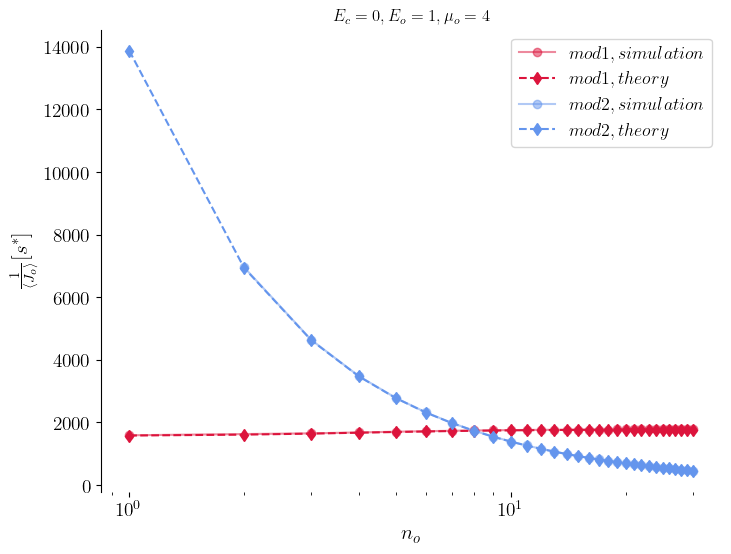

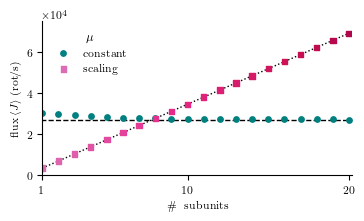

In [ ]:
# Data arrays
timescale = 1.5 * 10**4 
'''timescale used in thesis'''
timescale = 4.8 * 10**7 
J0_diff_one_peak = -1.5266917246606386e-13


'''1/J vs n'''
fig1, ax1 = plt.subplots(figsize=(8, 6))

'''J vs n'''
fig2, ax2 = plt.subplots(figsize=(4, 2))


J0_array_1000_1_0_0_0_0 = np.array([-1.5273796380648046e-13, -7.730237681802858e-13, -2.4421976401914644e-12, -5.959450916130454e-12, -1.2350058085464932e-11, -2.2863691767753977e-11, -3.897237059479796e-11, -6.236804597397837e-11, -9.495983224384636e-11, -1.388708875961964e-10, -1.9643495262411855e-10, -2.7019255406870545e-10, -3.62886883581855e-10, -4.774593596665343e-10, -6.170448842220019e-10, -7.849668026404288e-10, -9.847315815161466e-10, -1.2200232131862816e-09, -1.4946973612268905e-09, -1.8127752585391676e-09, -2.1784373745597383e-09, -2.5960168599487094e-09, -3.069992789125655e-09, -3.6049832100223344e-09, -4.205738018534464e-09, -4.8771316735148615e-09, -5.624155763175245e-09, -6.451911444219571e-09, -7.3656017642905625e-09])

# J0_array_500_1_0_0_0_0 = np.array([-1.5266917246606386e-13, -2.441097220640927e-12, -1.2344494694468686e-11, 
#            -3.89548138914244e-11, -9.49170538175296e-11, 
#            -1.9634646100839536e-10, -9.842879722405024e-10, -3.068609796236577e-09, 
#            -7.362283653932743e-09, -1.494786756335023e-08])
# n0_array_500_1_0_0_0_0 = np.array([1.0,2.0,3.0,4.0,5.0, 6.0, 9.0, 12.0, 15.0, 18.0])
J0_array_500_1_0_0_0_0 = np.array([-2.4384070085835294e-12, -1.2330889937981955e-11, -3.8911882863114455e-11, -9.481244827874896e-11, -1.961300724929074e-10, -3.6232365896041995e-10, -6.160871894108824e-10, -9.832032125837416e-10, -1.4923774913085488e-09, -2.175056294719806e-09, -3.0652279560210174e-09, -4.1992104332351676e-09, -5.615426699030249e-09, -7.354169860191959e-09, -9.45735994823067e-09, -1.1968294356073139e-08, -1.493139388178133e-08, -1.8391946341658468e-08, -2.239584965651205e-08, -2.6989356264533904e-08, -3.22188206380033e-08, -3.813045158643716e-08, -4.477007092347221e-08, -5.218287996105798e-08, -6.041323515889068e-08, -6.950443413905026e-08, -7.949851311615012e-08, -9.043605666632991e-08, -1.0235602060731205e-07])
# [-1.2330884945710954e-11, -1.2330889937969316e-11, -1.233089684600942e-11, -1.2330905932958306e-11, -1.2330917004959942e-11, -1.2330930069999683e-11, -1.2330945099719089e-11, -1.2330962132045968e-11, -1.2330981117220875e-11, -1.2331002067722113e-11, -1.2331024964710056e-11, -1.2331049780565614e-11, -1.2331076493264286e-11, -1.2331105115676166e-11, -1.2331135608832887e-11, -1.2331167974897723e-11, -1.2331202144561745e-11, -1.2331238152481526e-11, -1.2331275943772753e-11, -1.2331315506289936e-11, -1.2331356812230727e-11, -1.2331399858060587e-11, -1.2331444595218616e-11, -1.2331490977155521e-11, -1.2331539042110855e-11, -1.2331588711524389e-11, -1.233163995507242e-11, -1.2331692767733293e-11, -1.233174710121783e-11]
J0_array_100_1_0_0_0_0 = np.array([-9.364143883947353e-11, -1.4739455166699944e-09, -7.2633404025552465e-09, -5.1538382674350846e-08, -1.010918478055169e-07, -1.7572473711274333e-07, -2.7921929269165874e-07, -4.138711347006584e-07, -5.803807079798262e-07, -7.779273303078619e-07, -1.0043750543029619e-06, -1.2565560689787028e-06, -1.5305849143563789e-06, -1.8221580773763695e-06, -2.1268489078613594e-06, -2.4403176215491683e-06, -2.758496288182855e-06, -3.077581633798064e-06, -3.3956943204907566e-06, -3.7109189023132375e-06, -4.018446850156221e-06, -4.319878113449555e-06, -4.615162686462422e-06, -4.896937341648301e-06, -5.193496221888654e-06, -5.483284247391924e-06, -5.781654881595941e-06, -6.097175085732947e-06, -6.45258845305163e-06])


n0_array_100_1_0_0_0_0 = np.array([1.0,2.0,3.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       

n0_array_500_1_0_0_0_0 = np.array([2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       


J0_array_500_1_0_0_2_0 = array([0.00030878507369972217, 0.00029047129781414486, 0.00028673052940067956, 0.0002846199131107717, 0.00028334885409290626, 0.00028253704734787906, 0.0002819930670108206, 0.00028161444216718727, 0.0002813430135818793, 0.00028114402586915506, 0.00028099576435445666, 0.00028088413146905425, 0.00028079966550726456, 0.0002807358291371396, 0.0002806879885264339, 0.0002806527835107661, 0.0002806277272449709, 0.00028061094488812714, 0.0002806009989574574, 0.0002805967701076457, 0.00028059737418037424, 0.00028060210348881726, 0.0002806103846037618, 0.0002806217475707255, 0.00028063580317121346, 0.0002806522259253431, 0.0002806707412484705, 0.00028069111564769304, 0.00028071314916900346])
n0_array_500_1_0_0_2_0 = array([1.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       


# J0_array_500_1_0_0_4_0 = array([0.0006059100668231723, 0.0005816049293010457, 0.0005717643436016248, 0.0005674542616681615, 0.000565317761324798, 0.0005641693076453751])
# in_Y1 is: [3.725016539780665e-20, -1.8522350139327384e-20, 3.9546394099301076e-20, -7.442021194686911e-21, -3.315837665740365e-20, 1.4980085355511726e-20]
# n0_array_500_1_0_0_4_0 = np.array([3.0,6.0, 9.0, 12.0, 15.0, 18.0])

J0_array_500_1_0_0_4_0 = array([0.0006287104718506018, 0.0006052423080558835, 0.000594787054069692, 0.0005868201007582693, 0.0005809639566386184, 0.0005766771735713426, 0.0005735093995234508, 0.000571134216009439, 0.0005693250448146233, 0.0005679259365779138, 0.0005668288841123728, 0.0005659581370387869, 0.0005652597597282289, 0.0005646947383538815, 0.0005642344104083408, 0.0005638574023185707, 0.0005635475503571608, 0.0005632924689415213, 0.0005630825504810404, 0.0005629102568082022, 0.0005627696103603749, 0.0005626558240794415, 0.0005625650289231599, 0.000562494070937361, 0.0005624403584994333, 0.0005624017461612229, 0.0005623764454826658, 0.0005623629559703247, 0.0005623600111378955])
n0_array_500_1_0_0_4_0 = array([1.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       

J0_array_500_1_0_0_8_0 = array([0.0012472054047458453, 0.001235142676603911, 0.0012225848926468318, 0.0012104979575236745, 0.001199432222894664, 0.0011896172312590525, 0.0011810792941768765, 0.0011737356016889519, 0.001167455994845826, 0.0011620985316480022, 0.001157527659325817, 0.0011536221003795662, 0.001150277165451478, 0.0011474043082006947, 0.0011449294882871083, 0.0011427911610665791, 0.0011409382914779418, 0.0011393285633559433, 0.001137926839561285, 0.001136703872681168, 0.0011356352421335036, 0.001134700485639369, 0.001133882392818713, 0.0011331664317460657, 0.001132540283472751, 0.0011319934637394212, 0.0011315170149160082, 0.0011311032544671334])
n0_array_500_1_0_0_8_0 = array([3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       



J0_array_100 = np.array([-9.415618918122865e-11, -7.3032673456620235e-09, -1.0164755475847822e-07, 
                         -4.1614620508686786e-07, -1.0098961543688368e-06, -1.8321745717518756e-06, -2.773659880598525e-06])
n0_array_100 = np.array([1, 3, 6, 9, 12, 15, 18])

J0_array_200 = np.array([-4.758096666281248e-10, -7.340152539192955e-09, -3.501961343281959e-08, -1.0216092625190685e-07, -2.2604924240710383e-07, -4.182479536018119e-07])
n0_array_200 = np.array([3, 6, 9, 12, 15, 18])

# Mean of the diffusion data


# Function definitions
# def exp_model(x, a, b, c):
#     return a * np.exp(b * x) + c

# def model_func(x, a, b,c):
#     return c+ (a / x) + b*x

# Fit the model to the data
# try:
#     params, params_covariance = curve_fit(model_func, n0_array_500_1_0_0_0_0, np.abs(J0_array_500_1_0_0_0_0**-1))
#     params_e, params_covariance_e = curve_fit(exp_model, n0_array_500_1_0_0_0_0, (timescale) * np.abs(J0_array_500_1_0_0_0_0**-1), maxfev=100000)
# except RuntimeError as e:
#     print("Error:", e)
# else:
#     # Extract the parameters
#     a_fit, b_fit, c_fit = params
#     print(f"a = {a_fit}, b = {b_fit}, c = {c_fit}")
#     a_fit_e, b_fit_e, c_fit_e = params_e
#     # print("Exponential fit parameters: a =", a_fit_e, ", b =", b_fit_e, ", c =", c_fit_e)

#     # Generate data for the fitted curve
#     x_fit = np.linspace(1, max(n0_array_500_1_0_0_0_0), 1000)
#     y_fit = model_func(x_fit, a_fit, b_fit,c_fit)
#     y_fit_e = exp_model(x_fit, a_fit_e, b_fit_e, c_fit_e)
#     b,lnA =np.polyfit(n0_array_500_1_0_0_0_0,np.log((1) * np.abs(J0_array_500_1_0_0_0_0**-1)),1)

    # Plot the results
    # plt.plot(x_fit, 1000000*np.exp(-x_fit), label="exp", color="black")
    
    # plt.plot(x_fit, y_fit, label="Rational fit to 500", color="red")
    
    # plt.plot(x_fit, J0_diff/x_fit, label="Rational fit to 500", color="red")
    
# plt.plot(x_fit, y_fit_e, label="Exponential fit to 500", color="blue")
J0_diff = np.mean(np.abs(np.array([-3.48782781621254e-20, -1.4710077356778805e-20, -5.771180066342834e-21, -9.36851002905375e-21, 8.551213836144798e-21, -1.095961715407588e-20])))
print("Mean diffusion value,Ec=0:", J0_diff)
print("Mean diffusion value,Ec=128:", np.mean(np.abs(np.array([-5.959579577974274e-20, -5.959579577974274e-20]))))
t_tot_data_mu_0 = (J0_array_500_1_0_0_0_0**-1)
t_tot_data_mu_0_N_1000 = (J0_array_1000_1_0_0_0_0**-1)
t_tot_data_mu_0_N_100 = (J0_array_100_1_0_0_0_0**-1)
t_tot_data_mu_8 = ((J0_array_500_1_0_0_8_0)**-1)
t_tot_data_mu_4 = ((J0_array_500_1_0_0_4_0)**-1)
t_tot_data_mu_2 = ((J0_array_500_1_0_0_2_0)**-1)

T0_peak = np.abs(np.abs(J0_diff_one_peak**-1)-np.abs(J0_diff**-1))
print("J0 due to one peak waiting time:",T0_peak)
# plt.plot(x_fit, J0_diff/x_fit, label="Rational fit to 500", color="red")
eps = 2.22044604925031308084726e-16
dx = 0.001
Error = (n0_array_500_1_0_0_0_0-1)*eps
yerr = Error**-1


# ax2.plot(n0_array_500_1_0_0_4_0, J0_array_500_1_0_0_4_0, alpha=0.5,marker = "o",label=r"$mod1, simulation$", color="crimson")

# plt.plot(n0_array_100_1_0_0_0_0, t_tot_data_mu_0_N_100, marker = "o",label=r"$N=100, E_o=1, E_1=0, E_c=0, \mu_{o,1}=0$", color="pink")
# plt.plot(n0_array_500_1_0_0_0_0, t_tot_data_mu_0, marker = "o",label=r"$N=500, E_o=1, E_1=0, E_c=0, \mu_{o,1}=0$", color="red")
# plt.errorbar(n0_array_500_1_0_0_0_0, t_tot_data_mu_0_N_1000,yerr=yerr, marker = "o",label=r"$N=1000, E_o=1, E_1=0, E_c=0, \mu_{o,1}=0$", color="black")
# plt.plot(n0_array_500_1_0_0_0_0, t_tot_data_mu_0_N_1000, marker = "o",label=r"$N=1000, E_o=1, E_1=0, E_c=0, \mu_{o,1}=0$", color="black")
# plt.plot(n0_array_500_1_0_0_0_0, yerr*0.001, marker = "d",label=r"$Error [\times 10^{-3}],N=1000, E_o=1, E_1=0, E_c=0, \mu_{o,1}=0$", color="red")


# plt.plot(n0_array_500_1_0_0_2_0, t_tot_data_mu_2,marker = "o", label=r"$N=500, E_o=1, E_1=0, E_c=0, \mu_{o}=2$", color="green")
ax1.plot(n0_array_500_1_0_0_4_0, t_tot_data_mu_4,marker = "o", alpha = 0.5,label=r"$mod1, simulation$", color="crimson")
# plt.plot(n0_array_500_1_0_0_8_0, t_tot_data_mu_8,marker = "o", label=r"$N=500, E_o=1, E_1=0, E_c=0, \mu_{o}=8$", color="purple")



# plt.plot(x_fit, exp(lnA)*exp(b*x_fit), label=r"$exponential \ fit \propto e^{bn_o}$", color="purple")
scale_diff=10**-7
# plt.plot(n0_array_500_1_0_0_0_0, (scale_diff)*timescale*(J0_diff**-1)/n0_array_500_1_0_0_0_0,linewidth=12.0,alpha=0.7,label=r"$\tau_{diff}^{tot} [\times 10^{-7} ] \propto \frac{1}{n_{o}}$",color="brown")
scale_barr=10**-9
# plt.plot(n0_array_500_1_0_0_0_0, (scale_barr)*timescale*(T0_peak)*n0_array_500_1_0_0_0_0,label=r"$\tau_{peaks}^{tot} [\times 10^{-7} ] \propto n_o$")
# # print("T due to total peak waiting time:",timescale*(J0_peak**-1)*n0_array_500_1_0_0_0_0)


t_tot_ana = scale_diff*(timescale*(J0_diff**-1)/n0_array_500_1_0_0_0_0) + scale_barr*timescale*(T0_peak)*n0_array_500_1_0_0_0_0
# plt.plot(n0_array_500_1_0_0_0_0,t_tot_ana, linewidth=6.0,label=r"$\tau_{diff + peaks}^{tot} [scaled]$")
# plt.plot(n0_array_500_1_0_0_0_0[1:],t_tot_ana[1:]-t_tot_data[1:], linewidth=3.0,label=r"$\tau_{ana}^{tot} - \tau_{data}^{tot}$")
# print(f"t tot ana :{t_tot_ana[0]}, t toto data: {t_tot_data[0]}")


'''analytical aparameters'''
t_scale = (2.1 * 10**-8)**-1
# t_scale = 1
diff_t = 1000*2*pi*pi/n0_array_500_1_0_0_0_0
barr_t = n0_array_500_1_0_0_0_0*exp(1)

# plt.plot(n0_array_500_1_0_0_0_0[1:],diff_t[1:]*t_scale, linestyle="dotted",label = r"$\tau_{diff}^{tot} = \frac{\zeta\beta(2\pi)^2}{2n}$")
# plt.plot(n0_array_500_1_0_0_0_0,barr_t*t_scale, label = "anal-barr")

difference_t = diff_t*t_scale - t_tot_data_mu_0
# plt.plot(n0_array_500_1_0_0_0_0[1:],difference_t[1:], label = "diff")




###paper anlytical parameters
n_4 = array([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       

A_4 = 4*pi*pi*(10**-3)/(n_4**2)
s_4 = array([0.102433, 0.0558362, 0.0399559, 0.0310882, 0.0250177, 0.0204748,
0.0169293, 0.0141014, 0.0118176, 0.00995797, 0.00843415, 0.00717879,
0.00613945, 0.00527485, 0.00455225, 0.00394557, 0.00343392, 0.00300054,
0.00263186, 0.00231693, 0.00204684, 0.00181429, 0.00161331, 0.00143898,
0.00128726, 0.00115475, 0.00103866, 0.00093663, 0.000846696, 0.000767195
])
m_4 = array([3.96273, 0.522629, 0.164399, 0.0727214, 0.0382279, 0.0222126,
0.0137691, 0.008934, 0.00600111, 0.00414447, 0.00292919, 0.00211171,
0.00154898, 0.00115383, 0.000871426, 0.000666421, 0.000515481, 0.000402911,
0.000317963, 0.000253163, 0.000203235, 0.000164408, 0.000133951, 0.000109869,
0.0000906812, 0.0000752859, 0.0000628509, 0.0000527441, 0.000044481, 0.0000376874
])

n_0 = array([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       
A_0 = 4*pi*pi*(10**-3)/(n_0**2)
res_0 = array([0.0223964, 0.0895857, 0.201568, 0.358343, 0.559911, 0.806272, 
                1.09743, 1.43337, 1.81411, 2.23964, 2.70997, 3.22509, 3.785, 4.3897, 
                5.0392, 5.73349, 6.47257, 7.25644, 8.08511, 8.95857, 9.87683, 
                10.8399, 11.8477, 12.9003, 13.9978, 15.14, 16.327, 17.5588, 18.8354, 
                20.1568])
res_0 = A_0*res_0
tau_res_0_2 = 4*pi*pi/(2*res_0)
tau_res_0_1 = 4*pi*pi/(2*res_0*n_0)
print("t:",tau_res_0_2)

n_0_2pi = array([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       
A_0_2pi = 4*pi*pi*(10**-3)
res_0_2pi = A_0_2pi*array([0.0223964, 0.0223965, 0.0223963, 0.0224138, 0.0228725, 0.0227066, \
0.0226219, 0.0244215, 0.023137, 0.0233863, 0.0244398, 0.0202572, 
0.0229872, 0.0226174, 0.0229832, 0.0218705, 0.0271228, 0.0252647, 
0.0228534, 0.0230393, 0.0241078, 0.0249914, 0.0243191, 0.0110106, 
0.0231074, 0.0227251, 0.0237329, 0.0215475, 0.0243741, 0.0227766])
tau_res_0_2_2pi = 4*pi*pi/(2*res_0_2pi)
tau_res_0_1_2pi = 4*pi*pi/(2*res_0_2pi*n_0_2pi)




n_4_2pi = array([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       
A_4_2pi = 4*pi*pi*(10**-3)
res_4_2pi = A_4_2pi*array([0.025849, 0.0267094, 0.0270046, 0.0267184, 0.0261774, 0.0256004, \
0.0250915, 0.0246637, 0.0243163, 0.0240819, 0.0238356, 0.0234967,
0.0235029, 0.023297, 0.0231975, 0.0231339, 0.023505, 0.0227258, 
0.0227844, 0.0227147, 0.0228494, 0.0226437, 0.0226727, 0.0207182, 
0.0227813, 0.0224684, 0.0228295, 0.0221864, 0.0222343, 0.0224957])
tau_res_4_2_2pi = 4*pi*pi/(2*res_4_2pi)
tau_res_4_1_2pi = 4*pi*pi/(2*res_4_2pi*n_4_2pi)

res_4 = A_4*s_4/m_4
tau_res_4_2 = 4*pi*pi/(2*res_4)
tau_res_4_1 = 4*pi*pi/(2*res_4*n_4)


######f=0#######
# plt.plot(n_0_2pi,tau_res_0_1_2pi*(1), linestyle="dotted",marker = 'd',label = r"$calc-0-s1-2pi$")
# plt.plot(n_0_2pi,tau_res_0_2_2pi, linestyle="dotted",marker = 'd',label = r"$calc-0-s2-2pi$")

# plt.plot(n_0,tau_res_0_1*(1), linestyle="dotted",marker = 'd',label = r"$calc-0-s1$")
# plt.plot(n_0,tau_res_0_2, linestyle="dotted",marker = 'd',label = r"$calc-0-s2$")
print("tau_analytical_0:",tau_res_0_2)
#######f=4########

speed_f_2 = array([
0.00195009, 0.00187812, 0.00183441, 0.00181075, 0.00179739, 0.00178931,
0.00178412, 0.00178062, 0.00177815, 0.00177636, 0.00177501, 0.00177397,
0.00177315, 0.0017725, 0.00177198, 0.00177154, 0.00177118, 0.00177088,
0.00177062, 0.00177041, 0.00177022, 0.00177005, 0.00176991, 0.00176978,
0.00176967, 0.00176957, 0.00176948, 0.0017694, 0.00176933, 0.00176927
])

speed_f_4 = array([
0.00397053, 0.00390017, 0.00382231, 0.00375625, 0.00370588, 0.00366881, 
0.00364164, 0.00362151, 0.00360636, 0.00359477, 0.00358575, 0.00357862, 
0.0035729, 0.00356825, 0.00356442, 0.00356124, 0.00355857, 0.00355631, 
0.00355437, 0.00355271, 0.00355127, 0.00355001, 0.00354891, 0.00354794, 
0.00354708, 0.00354631, 0.00354562, 0.00354501, 0.00354446, 0.00354396
]
)

speed_f_8= array([
0.0079846, 0.00794106, 0.00787654, 0.00780035, 0.00772101, 0.00764461, 
0.00757462, 0.00751249, 0.00745837, 0.00741175, 0.0073718, 0.00733763, 
0.00730837, 0.00728328, 0.00726168, 0.00724301, 0.00722683, 0.00721272, 
0.00720038, 0.00718954, 0.00717997, 0.0071715, 0.00716396, 0.00715724, 
0.00715121, 0.0071458, 0.00714091, 0.0071365, 0.00713249, 0.00712885
])
ratio = (tau_res_4_2[0]/t_tot_data_mu_4[0])**-1
print(ratio)
ratio = 1


# #plt.plot(n_4, tau_res_4_1, linestyle="dashed", marker='d', label=r"$\tau = n \frac{\left(\frac{2\pi}{n}\right)^2}{2D}, L = \frac{2\pi}{n}$")

# plt.plot(n_4, tau_res_4_2*(ratio), linestyle="dashed", marker='^', label=r"$\tau_{diff} = \frac{(2\pi)^2}{2D}, L = \frac{2\pi}{n}$")

# Plotting the second set of data
'''L=2pi/n,t = \frac{2\pi}{\langle \dot x \rangle},'''
# ax2.plot(n_mod2_4, speed_mod2_f_4/(2*np.pi), color='green', linestyle='--')

ax1.plot(n_4_2pi, 2*pi/(speed_f_4), linestyle="dashed", marker='d', color="crimson",label=r"$mod1, theory$")
# ax2.plot(n_4_2pi, (speed_f_4)/(2*pi), marker='o', color='#d1007d',markersize=12,label=r"$Model 1$")
# ax2.plot(n_4_2pi, timescale*(speed_f_4)/(2*np.pi) , marker='', color='#d1007d',markersize=8)
ax2.scatter(n_4_2pi, timescale*(speed_f_4)/(2*np.pi), marker='o', c='teal',s=15,label=r"$\rm constant$")

# plt.plot(n_4_2pi, tau_res_4_1_2pi, linestyle="dotted", marker='d', label=r"$\tau = n \frac{\left(\frac{2\pi}{n}\right)^2}{2D}, L = 2\pi$")
# plt.plot(n_4_2pi, tau_res_4_2_2pi*(ratio), linestyle="dotted", marker='^', label=r"$\tau = \frac{(2\pi)^2}{2D} [\times 0.08], L = 2\pi$")
# plt.plot(n_4_2pi, 2*pi/(speed_f_2), linestyle="dashed", marker='d', label=r"$ t = \frac{2\pi}{\langle \dot x \rangle}, L = \frac{2\pi}{n_o}, E_o = 1,\mu_o = 2$")
# plt.plot(n_4_2pi, 2*pi/(speed_f_4), linestyle="dashed", marker='d',color="green", label=r"$ t = \frac{2\pi}{\langle \dot x \rangle}, L = \frac{2\pi}{n_o}, E_o = 1,\mu_o = 4$")
# plt.plot(n_4_2pi, 2*pi/(speed_f_8), linestyle="dashed", marker='d', label=r"$ t = \frac{2\pi}{\langle \dot x \rangle}, L = \frac{2\pi}{n_o}, E_o = 1,\mu_o = 8$")
# T_difference = tau_res_4_2 - 2*pi/(speed_f_4)
# plt.plot(n_4, T_difference, linestyle="dashed", marker='d', label=r"$-T_diff$")


#######model2#########################################################


J0_array_mod2_1000_1_0_0_4_2 = np.array([0.0001437526603280887, 0.0002156294796582678, 0.0002875068857424579, 0.0003593850739057029, 0.0004312642393552016, 0.0005031445771930882, 0.0005750262824260954, 0.0006469095499769611, 0.0007187945746943363, 0.0007906815513646061, 0.0008625706747216542, 0.000934462139459094, 0.0010063561402401102, 0.0010782528717098005, 0.0011501525285049987, 0.0012220553052665689, 0.0012939613966491937, 0.0013658709973340308, 0.0014377843020380071, 0.0015097015055271824, 0.0015816228026243055, 0.0016535483882234058, 0.0017254784572975743, 0.0017974132049119464, 0.0018693528262325254, 0.0019412975165378195, 0.002013247471228465, 0.002085202885838256, 0.0021571639560427464]
)
J1_array_mod2_1000_1_0_0_4_2 = np.array([-0.00029124464814938515, -0.0002912449028355536, -0.00029124516156163645, -0.0002912454242920088, -0.0002912456909891544, -0.00029124596161534414, -0.00029124623613218775, -0.0002912465145011129, -0.0002912467966829135, -0.00029124708263822305, -0.00029124737232703743, -0.0002912476657092125, -0.000291247962744049, -0.0002912482633907145, -0.0002912485676078697, -0.0002912488753540171, -0.00029124918658717745, -0.00029124950126528713, -0.0002912498193458062, -0.00029125014078623657, -0.00029125046554344326, -0.0002912507935744091, -0.0002912511248356673, -0.00029125145928373113, -0.00029125179687479886, -0.00029125213756496147, -0.0002912524813101006, -0.0002912528280660223, -0.0002912531777882605]
)
n0_array_mod2_1000_1_0_0_4_2 = array([2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       

t_tot_data_mod2_mu_4_2_N_1000 = (J0_array_mod2_1000_1_0_0_4_2**-1)


ax1.plot(n0_array_mod2_1000_1_0_0_4_2, t_tot_data_mod2_mu_4_2_N_1000, marker = "o",alpha=0.5,label=r"$mod2, simulation$", color="cornflowerblue")
# ax2.plot(n0_array_mod2_1000_1_0_0_4_2, J0_array_mod2_1000_1_0_0_4_2, marker = "o",alpha=0.5,label=r"$Model 2$", color="cornflowerblue")

###analytical#####
n_mod2_4 = array([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       

speed_mod2_f_4 = array([0.000452688, 0.000905377, 0.00135807, 0.00181075, 0.00226344, 0.00271613, 0.00316882,
    0.00362151, 0.0040742, 0.00452688, 0.00497957, 0.00543226, 0.00588495, 0.00633764,
    0.00679033, 0.00724301, 0.0076957, 0.00814839, 0.00860108, 0.00905377, 0.00950646,
    0.00995915, 0.0104118, 0.0108645, 0.0113172, 0.0117699, 0.0122226, 0.0126753,
    0.013128, 0.0135807])




# Plotting with varying colors
# plt.scatter(x, y, c=x, cmap=cmap, norm=norm, s=50)


cmap = plt.cm.PuRd
norm = plt.Normalize(n_mod2_4.min()-27, n_mod2_4.max())

# Fit a line to the data
# slope, intercept = np.polyfit(n_mod2_4, speed_mod2_f_4/(2*np.pi), 1)

# # Equation of the line
# equation = f"y = {slope:.4f}x + {intercept:.4f}"
# print(equation)

# # Plotting the fitted line
# x_fit = np.linspace(min(n_mod2_4), max(n_mod2_4), 100)
# y_fit = slope * x_fit + intercept
# ax2.plot(x_fit, y_fit, color='red', linestyle='-', label='Fitted Line')

'''I dont think that /2pi should be there in ax2=>>>>check later'''
# ax2.plot(n_mod2_4, speed_mod2_f_4/(2*pi), color="green")
# ax2.scatter(n_mod2_4, speed_mod2_f_4/(2*pi), c=n_mod2_4, cmap=cmap, norm=norm, linestyle="dashed", marker='s', s=100, label=r"$ Model 2$")
'''no 2pi version'''
# ax2.plot(n_mod2_4, timescale*speed_mod2_f_4/(2*pi), color="green")
ax2.scatter(n_mod2_4, timescale*speed_mod2_f_4/(2*pi), c=n_mod2_4, cmap=cmap, norm=norm,  marker='s', s=15, label=r"$\rm scaling$", zorder=1)


ax1.plot(n_mod2_4, 2*pi/(speed_mod2_f_4), linestyle="dashed", marker='d',color="cornflowerblue", label=r"$ mod2, theory$")

##########################model4###############################################
J0_array_mod4_1000_1_0_0_4_0=array([0.00014372820808825822, 0.00021559280121483947, 0.0002874579809964164, 0.00035932394272421894, 0.00043119088157197267, 0.0005030589926085992, 0.0005749284708075971, 0.0006467995110586543, 0.0007186723081773194, 0.0007905470569168567, 0.000862423951978031, 0.0009343031880213279, 0.001006184959676823, 0.0010780694615564967, 0.0011499568882641007, 0.0012218474344073513, 0.001293741294607851, 0.001365638663513631, 0.0014375397358084856, 0.0015094447062253824, 0.0015813537695538974, 0.0016532671206549142, 0.0017251849544683703, 0.0017971074660262005, 0.001869034850461236, 0.0019409673030187469, 0.0020129050190661516, 0.002084848194103961, 0.002156797023774454])# in_Y1 is: [-7.731112653878752e-13, -7.73111975651634e-13, -7.731126318562647e-13, -7.731132782166436e-13, -7.731140006216813e-13, -7.731147366382637e-13, -7.731154268464794e-13, -7.731161959245604e-13, -7.731169099724635e-13, -7.731177089203231e-13, -7.731184591429813e-13, -7.731192246691484e-13, -7.731200469274629e-13, -7.73120855641111e-13, -7.731216273100617e-13, -7.731224494835938e-13, -7.731232778483566e-13, -7.731241068666294e-13, -7.731249316973828e-13, -7.73125807583014e-13, -7.731266333916627e-13, -7.731275113900114e-13, -7.73128386415179e-13, -7.731292979953064e-13, -7.73130214268489e-13, -7.731311003459277e-13, -7.731320365967167e-13, -7.731329615824884e-13, -7.73133870266845e-13]
n0_array_mod4_1000_1_0_0_4_0 = array([2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       

t_tot_data_mod4_mu_4_0_N_1000 = (J0_array_mod4_1000_1_0_0_4_0**-1)

# ax1.plot(n0_array_mod4_1000_1_0_0_4_0, t_tot_data_mod4_mu_4_0_N_1000, marker = "s",alpha=0.5,label=r"$mod4, simulation$", color="green")



########################################################################
ax1.legend(fontsize=13)
ax1.set_xlabel(r'$n_o$',fontsize=15)
ax1.set_xscale('log')
# ax1.set_yscale('log')
ax1.set_ylabel(r'$\frac{1}{\langle J_{o} \rangle}[s^{*}]$',fontsize=15)
ax1.set_title(r"$E_c = 0, E_o = 1,\mu_o = 4$")
ax1.tick_params(axis='both', labelsize=14)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
# ax1.set_ylim(1,1900)
####################
df = pd.read_csv("/Users/sarealles/Desktop/research/GP-Mar2025/thetaDot_vs_n.csv", header=None, names=["n", "thetaDot"])
ax2.plot(df["n"], timescale*array(df["thetaDot"])/(2*pi), color="black", linestyle="dotted", lw=1,zorder=-100)  # Dotted line for simulation data
####################

ax2.set_xlim(left=1, right=20)
ax2.set_ylim(bottom=0, top=75000)  # Set y-axis limits
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax2.legend(fontsize=l_entry_s, title=r"$\mu$", title_fontsize=l_title_s, frameon=False)  # No box around legend
ax2.set_xlabel(r'\textnormal{\# \ subunits}', fontsize=fs)  # Non-italic "subunits"
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['bottom'].set_visible(True)  # Show bottom spine (solid x-axis)
ax2.set_ylabel(r'\textnormal{flux}$\ \langle J \rangle\ (\rm{rot}/\rm{s})$', fontsize=fs)  # Non-italic "Flux"
ax2.tick_params(axis='both', labelsize=ticks_size)
ax2.yaxis.offsetText.set_fontsize(off_text_size)
ax2.set_xticks([1, 10, 20])
ax2.set_xlim(left=1, right=20.2)
coeff = 6.2832 * (1 - np.exp(-np.pi)) / (1000 * 13.28)
# ax2.plot(n_mod2_4,coeff*n_mod2_4, color='black', linestyle='--', linewidth=1.5)  # Horizontal line at y=0
# ax2.plot(n_4_2pi,0.000883*4*n_4_2pi,color='black', linestyle='--', linewidth=1.5)  # Horizontal line at y=0
ax2.hlines(y=timescale*0.0035/(2*pi), xmin=0, xmax=20, color='black', linestyle='--', linewidth=1, zorder=-100)  # Horizontal line at y=0
# 0.00354
# fig1.savefig("/Users/sarealles/Desktop/research/CM_Aug_2024/time_J0_anal_sim_E0_1_Ec_0_mu0_4.pdf")

fig2.savefig("/Users/sarealles/Desktop/research/Paper/J0_analytical_E0_1_Ec_0_mu0_4_linear.pdf", bbox_inches='tight')

plt.show()


    


#### Model 2 time analysis

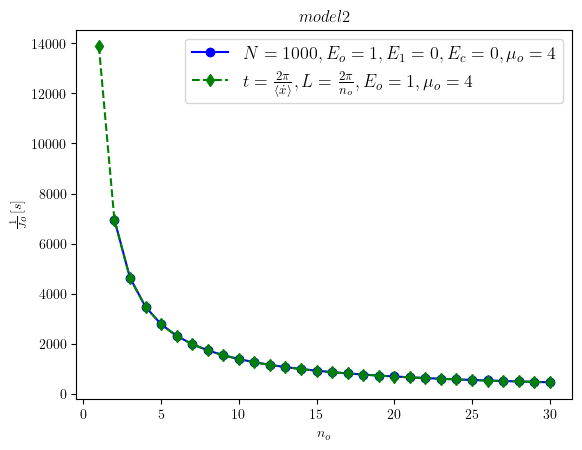

In [ ]:
# Data arrays
timescale=2.1 * 10**-8


J0_array_1000_1_0_0_4_2 = np.array([0.0001437526603280887, 0.0002156294796582678, 0.0002875068857424579, 0.0003593850739057029, 0.0004312642393552016, 0.0005031445771930882, 0.0005750262824260954, 0.0006469095499769611, 0.0007187945746943363, 0.0007906815513646061, 0.0008625706747216542, 0.000934462139459094, 0.0010063561402401102, 0.0010782528717098005, 0.0011501525285049987, 0.0012220553052665689, 0.0012939613966491937, 0.0013658709973340308, 0.0014377843020380071, 0.0015097015055271824, 0.0015816228026243055, 0.0016535483882234058, 0.0017254784572975743, 0.0017974132049119464, 0.0018693528262325254, 0.0019412975165378195, 0.002013247471228465, 0.002085202885838256, 0.0021571639560427464]
)
J1_array_1000_1_0_0_4_2 = np.array([-0.00029124464814938515, -0.0002912449028355536, -0.00029124516156163645, -0.0002912454242920088, -0.0002912456909891544, -0.00029124596161534414, -0.00029124623613218775, -0.0002912465145011129, -0.0002912467966829135, -0.00029124708263822305, -0.00029124737232703743, -0.0002912476657092125, -0.000291247962744049, -0.0002912482633907145, -0.0002912485676078697, -0.0002912488753540171, -0.00029124918658717745, -0.00029124950126528713, -0.0002912498193458062, -0.00029125014078623657, -0.00029125046554344326, -0.0002912507935744091, -0.0002912511248356673, -0.00029125145928373113, -0.00029125179687479886, -0.00029125213756496147, -0.0002912524813101006, -0.0002912528280660223, -0.0002912531777882605]
)
n0_array_1000_1_0_0_4_2 = array([2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       

t_tot_data_mu_4_2_N_1000 = (J0_array_1000_1_0_0_4_2**-1)

plt.title(r"$model2$")
plt.plot(n0_array_1000_1_0_0_4_2, t_tot_data_mu_4_2_N_1000, marker = "o",label=r"$N=1000, E_o=1, E_1=0, E_c=0, \mu_{o}=4$", color="blue")

###analytical#####
n_4 = array([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0])       

speed_f_4 = array([0.000452688, 0.000905377, 0.00135807, 0.00181075, 0.00226344, 0.00271613, 0.00316882,
    0.00362151, 0.0040742, 0.00452688, 0.00497957, 0.00543226, 0.00588495, 0.00633764,
    0.00679033, 0.00724301, 0.0076957, 0.00814839, 0.00860108, 0.00905377, 0.00950646,
    0.00995915, 0.0104118, 0.0108645, 0.0113172, 0.0117699, 0.0122226, 0.0126753,
    0.013128, 0.0135807])


plt.plot(n_4, 2*pi/(speed_f_4), linestyle="dashed", marker='d',color="green", label=r"$ t = \frac{2\pi}{\langle \dot x \rangle}, L = \frac{2\pi}{n_o}, E_o = 1,\mu_o = 4$")


plt.xlabel(r'$n_o$')
plt.ylabel(r'$\frac{1}{Jo}[s]$')
plt.legend(fontsize=13)
# plt.savefig("/Users/sarealles/Desktop/Temp pics/raw_data_diff_barrier_tot.png",dpi=500)
plt.show()  
    
    


In [ ]:
J0_array_500_multi_0_0_0_0=array([-9.415618918122865e-11, -4.158478196871415e-10, -1.0837316211142277e-09, -2.1834859445902308e-09])
# in_Y1 is: [1.3320523423282122e-20, 3.532364065663464e-21, 5.000984411325997e-21, 8.112148360074694e-21]


In [ ]:
##############
# fig, ax = plt.subplots(1, 1, figsize=(5,5))
# # ax.plot(n_0,res_0,linestyle="dotted",marker = 'd',label="difusion const")

# f = [0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8]

# paper = array([0.0000816838, 0.000690868, 0.00442241, 0.0198504, 0.0557231,0.0930716, 0.104138, 0.0948069, 0.0807799, 0.0687591, 0.0597336,0.0531303, 0.0482566, 0.044585, 0.0417572])
# ax.plot(f,4*pi*pi*paper,marker = 'o',label="2pi/n")

# ax.legend()
# ax.set_xlabel(r"$f$")
# ax.set_ylabel(r"$D/D_{0}$")

# print(f"a={exp(lnA)},b={b}")
# print("total tie is: ", t_tot_data)
# print("total diff:", timescale*(J0_diff**-1)/n0_array_500_1_0_0_0_0)


In [ ]:
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True


Landscape animation

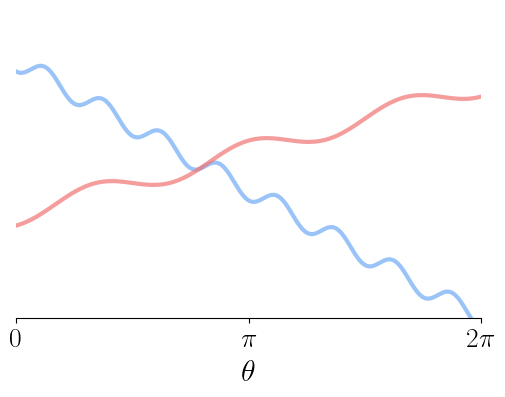

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parameters
F0 = 4  # Tilting force for the first potential
F1 = -2  # Tilting force for the second potential
V0_amplitude = 1  # Amplitude of the base potential
n0 =  8# Frequency of the base potential for the first potential
n1 = 3  # Frequency of the base potential for the second potential

# Potential functions
def potential_0(x):
    return - V0_amplitude * np.cos(n0 * x) - F0 * x + 25

def potential_1(x):
    return - V0_amplitude * np.cos(n1 * x) - F1 * x + 10

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlim(0, 2 * np.pi)
ax.set_ylim(0, 30)

# Dominant colors: ['#6faaf5', '#f17373']
# Potential landscapes
x = np.linspace(0, 2 * np.pi, 400)
V0 = potential_0(x)
V1 = potential_1(x)
ax.plot(x, V0, color='#6faaf5', linestyle='-', alpha=0.7, label='Potential 0', markersize=80, linewidth=3)
ax.plot(x, V1, color='#f17373', linestyle='-', alpha=0.7, label='Potential 1', markersize=80, linewidth=3)

# Sample array of size N
N = 400
x_array = np.linspace(0, 2 * np.pi, N)
array0 = potential_0(x_array)
array1 = potential_1(x_array)

# Initialize the plot
point0, = ax.plot([], [], marker='o', color="b", markersize=20)
point1, = ax.plot([], [], 'ro', markersize=20)

def init():
    point0.set_data([], [])
    point1.set_data([], [])
    return point0, point1

def update(frame):
    x0 = [x_array[frame]]
    y0 = [array0[frame]]
    point0.set_data(x0, y0)
    
    x1 = [x_array[frame]]
    y1 = [array1[frame]]
    point1.set_data(x1, y1)
    
    # Save a snapshot every 100 frames
    if frame % 100 == 0:
        plt.savefig(f'frame_{frame}.png', dpi=300)
    
    return point0, point1

# Customize plot appearance
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_yticks([])
ax.set_xticks([0, np.pi, 2 * np.pi])
ax.set_xticklabels(['$0$','$\\pi$', '$2\\pi$'], fontsize=20)
# ax.set_ylabel("$V(\\theta)$", fontsize=22)
ax.set_xlabel("$\\theta$", fontsize=22)

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=range(N), init_func=init, blit=True, interval=50)

# Save the animation
Writer = animation.writers['ffmpeg']
writer = Writer(fps=60, metadata=dict(artist='Me'), bitrate=20000)
# ani.save('high_quality_animation.mp4', writer=writer)
plt.savefig("/Users/sarealles/Desktop/research/Thesis_plots/landscape.pdf",dpi=500, bbox_inches='tight')
# Display the plot
plt.show()


## Destructive/constructive picture

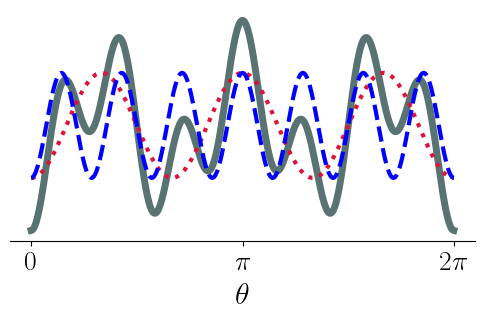

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(6,3))

n0_30 = 30
n0_15 = 15
n0_12 = 12
n0_5 = 5
n1_5 = 5
n0_10 =10
n0_6 = 6
n0_7 = 7
n0_4 = 4
n0_9 = 9
n0_3 = 3
n0_2 = 2
n0_1 = 1
n1 = 3
x= np.linspace(0,2*np.pi,500)
y_30 = -np.cos(n0_30*x)
y_5 = -np.cos(n0_5*x)
y_12 = -np.cos(n0_12*x)
y_15 = -np.cos(n0_15*x)
y_3 = -np.cos(n0_3*x)
y_6 = -np.cos(n0_6*x)
y_7 = -np.cos(n0_7*x)
y_1 = -np.cos(n0_1*x)
y_10 = -np.cos(n0_10*x)
y_4 = -np.cos(n0_4*x)
y_2 = -np.cos(n0_2*x)
y_9 = -np.cos(n0_9*x)
y5 = -np.cos(n1*x)

# ax.plot(x,y_1,label=f"n0={n0_1}")
# ax.plot(x,y_2,label=f"n0={n0_2}")
# ax.plot(x,y_30 + y3,label=f"n0={n0_30} + n1={n1}",linewidth=3)
# ax.plot(x,y_5 + y3,label=f"n0={n0_5} + n1={n1}",linewidth=3)

# ax.plot(x, y5, label=f"$n0={n0_10} + n1={n1}$", color="navy",linestyle="dashed",linewidth=2)

ax.plot(x, y_3, label=f"$n1={n1}$", color="crimson",linestyle="dotted",linewidth=3)
ax.plot(x, y_7, label=f"$n0={n0_7}$", color="blue",linestyle="dashed",linewidth=3)
ax.plot(x, y_7 + y_3, label=f"$n0={n0_7} + n1={n1}$", color="darkslategrey",linewidth=5, alpha = 0.8, zorder=-10)
# ax.plot(x, y_2 + y3, label=f"$n_o={n0_2} + n_1={n1}$", linewidth=2.5)
# ax.plot(x, y_6 + y3, label=f"$n_o={n0_3} + n_1={n1}$", linewidth=2.5)
# ax.plot(x, y_6 + y3, label=f"n0={n0_6} + n1={n1}", color="black", linewidth=2.5)
# ax.plot(x, y_9 + y3, label=f"n0={n0_9} + n1={n1}", linewidth=2.5)
# ax.plot(x, y_12 + y3, label=f"n0={n0_12} + n1={n1}", linewidth=2.5)
# ax.plot(x, y_15 + y3, label=f"n0={n0_15} + n1={n1}", linewidth=2.5)
# ax.plot(x,y_6,c="black",label=f"n0={n1}")

# ax.plot(x, y_6, label=f"$n0={n0_1} + n1={n1}$", color="navy",linestyle="dashed",linewidth=2)
# ax.plot(x, y_3, label=f"$n0={n0_1} + n1={n1}$", color="crimson",linestyle="dotted",linewidth=3)
# ax.plot(x, y_3 + y_6, label=f"$n0={n0_1} + n1={n1}$", color="purple",linewidth=5, alpha =0.8, zorder=-10)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# 
# ax.spines['bottom'].set_visible(False)

ax.set_yticks([])
ax.set_xticks([])
ax.set_xticks([0, np.pi/3, 2 * np.pi/3, pi, 4 * np.pi/3, 5*pi/3, 2 * np.pi])
ax.set_xticklabels([r'$0$', r'$\pi/3$', r'$2\pi/3$', r'$\pi$', r'$4\pi/3$', r'$5\pi/3$', r'$2\pi$'], fontsize=12)
# ax.set_ylabel("$V(\\theta)$", fontsize=20)
ax.set_xlabel("$\\theta$", fontsize=16)
two = False
if two:
    fig2, ax2 = plt.subplots(2,1,figsize=(5,5), sharex=True)
    ax2[0].plot(x, y_3, label=f"$n0={n0_1} + n1={n1}$", color="navy",linestyle="dashed",linewidth=2)
    ax2[0].plot(x, y_3, label=f"$n0={n0_1} + n1={n1}$", color="crimson",linestyle="dotted",linewidth=2)
    ax2[0].plot(x, y_3 + y_3, label=f"$n0={n0_1} + n1={n1}$", color="green",linewidth=5, alpha = 0.5, zorder=-10)
    ax2[1].plot(x, y_6, label=f"$n0={n0_1} + n1={n1}$", color="navy",linestyle="dashed",linewidth=2)
    ax2[1].plot(x, y_3, label=f"$n0={n0_1} + n1={n1}$", color="crimson",linestyle="dotted",linewidth=2)
    ax2[1].plot(x, y_3 + y_6, label=f"$n0={n0_1} + n1={n1}$", color="purple",linewidth=5, alpha = 0.5, zorder=-10)
    ax2[0].set_yticks([])
    ax2[1].set_yticks([])
    ax2[0].spines['top'].set_visible(False)
    ax2[0].spines['right'].set_visible(False)
    ax2[0].spines['left'].set_visible(False)
    ax2[1].spines['top'].set_visible(False)
    ax2[1].spines['right'].set_visible(False)
    ax2[1].spines['left'].set_visible(False)
    # ax2[1].set_xticks([0, np.pi/3, 2 * np.pi/3, pi, 4 * np.pi/3, 5*pi/3, 2 * np.pi])
    # ax2[1].set_xticklabels([r'$0$', r'$\pi/3$', r'$2\pi/3$', r'$\pi$', r'$4\pi/3$', r'$5\pi/3$', r'$2\pi$'], fontsize=12)
    ax2[1].set_xticks([0, pi, 2 * np.pi])
    ax2[1].set_xticklabels([r'$0$',  r'$\pi$',  r'$2\pi$'], fontsize=12)
ax.set_xticks([0, pi, 2 * np.pi])
ax.set_xticklabels([r'$0$',  r'$\pi$',  r'$2\pi$'], fontsize=20)
ax.set_xlabel("$\\theta$", fontsize=22)

# ax.legend()
# fig.savefig("/Users/sarealles/Desktop/research/nov24/6_land.png",dpi=500)
fig.savefig("/Users/sarealles/Desktop/research/Paper/7_3_land.pdf", bbox_inches='tight', dpi=500)
# fig2.savefig("/Users/sarealles/Desktop/research/Paper/two_land.pdf", bbox_inches='tight', dpi=500)
plt.show()


### force on F0

In [ ]:
n1=3

x = np.linspace(0,2*np.pi,500)*180/(np.pi)
for no in [2]:
    xx = np.linspace(0,2*np.pi,100)
    for X0 in [pi/3]:
        '''F0 is fixed here'''
        # plt.plot(xx,np.sign(np.sin(no*X0*np.ones(100) - 3*xx)) ,label=f"n0={no},n1={n1}")
        '''F1 is fixed here'''
        plt.plot(xx*180/(np.pi),-np.sign(np.sin(no*xx - 3*X0*np.ones(100))) ,label=f"n0={no},n1={n1}")
        plt.plot(xx*180/(np.pi),-np.sign(np.sin(no*xx)) ,label=f"f_o",color="purple")
# plt.plot(x,np.sign(np.sin(X0*np.ones(100) - x)) ,color="black",label=f"n0={no},n1={n1}")
plt.plot(x, y_2 + y3, label=f"$n0={n0_1} + n1={n1}$", color="black",linewidth=2.5)

# plt.plot(x, y_3 + y3, label=f"$n0=3 + n1=3$", color="red",linewidth=0.5)

# plt.xticks([0, 2*np.pi/3,np.pi, 2*np.pi], ['0', '$2\\pi/3$','$\\pi$', '$2\\pi$'])
# plt.xticks([0, 2*np.pi/6, 2*np.pi/3], ['0', '$2\\pi/6$', '$2\\pi/3$'])

### Force on F1

In [ ]:
n1=3

for no in [1]:
    x = np.linspace(0,2*np.pi/no,100)
    for X1 in [2*np.pi/3]:
        plt.plot(x,-np.sign(np.sin(no*x - 3*X1*np.ones(100))) ,label=f"n0={no},n1={n1}")
plt.plot(x,-np.sign(np.sin(x - X1*np.ones(100))) ,color="black",label=f"n0={no},n1={n1}")
plt.xticks([0, np.pi/no, 2*np.pi/no], ['0', '$2\\pi/12$', '$2\\pi/6$'])
plt.xticks([0, 2*np.pi/6, 2*np.pi/3], ['0', '$2\\pi/6$', '$2\\pi/3$'])


# n0 vs Ec

model 1

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [ ]:

def which_Ec_maximizes_P1(target_dir, model,n0_array,N=1000,n1=3.0,f0=4.0,dt=0.001,E0=2.0,E1=2.0,vs_n0=True):
    timescale = 1.5 * 10**4 
    #individually plotting for each model P vs no for various Ec values in one single plot

    #fig for Ec that maximizes P1 vs n0
    fig, ax = plt.subplots(1, 1, figsize=(4,2))
    ax.vlines(x=3, ymin=0, ymax=100, color='green', linestyle='--', linewidth=1)
    ax.vlines(x=6, ymin=0, ymax=100, color='purple', linestyle='dashed', linewidth=1)
    ax.hlines(y=16, xmin=0, xmax=30, color='grey', linestyle='--', linewidth=1)
    f1 = -2.0
    Ec_that_maximizes_P1 = []
    n0_exists = []
    if vs_n0:
        for n0 in n0_array:
            params = set_params(model, n0,n1,f0,f1,E0,E1)
            n0n1_str = str(int(n0))+"_"+ str(int(n1))
            target_dir_temp = target_dir + n0n1_str
            [
            E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
            m0, m1, phase,beta, gamma,__
            ] = params
            input_file_name = ("/" + model + "_flux_power_efficiency_"
                + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                
            if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                print(f"File not found: {target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)}")
                continue
            print("path is:", target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N))

            
            Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

            # Convert Ec_list to a list if it is a single value
            if isinstance(Ec_list, float):
                Ec_list = [Ec_list]
                integrate_power_Y = [integrate_power_Y]
                integrate_power_X = [integrate_power_X]
                integrate_flux_X = [integrate_flux_X]
                integrate_flux_Y = [integrate_flux_Y]
                efficiency_mod = [efficiency_mod]
                efficiency = [efficiency]
            print("Ec_list is:", Ec_list)  
            if len(Ec_list) != 0:
                n0_exists.append(n0) 
                Ec_that_maximizes_P1.append(Ec_list[argmax(integrate_flux_Y)])


                    
        # fig.suptitle(fr"${model},\ n_1 = {n1}, \ f_0 = {psi_0}$", fontsize=12)
        ax.plot(n0_exists,Ec_that_maximizes_P1, label = "model1",marker ="o", color="black",lw=1.0,markersize=3)
        ax.tick_params(labelsize=9, axis='both')
        ax.set_xlabel(r"$ \mathrm{\#\ subunits \ on} \ \mathrm{F_o} \ (n_\mathrm{o})$", fontsize=10)
        ax.set_xticks(n0_exists)
        ax.set_ylabel(r"${\rm{argmax}}_{\beta E_{\rm c}} \beta \mathcal{P}_1$", fontsize=10)
        ax.set_yscale("log")
        ax.set_ylim(bottom=10)
        ax.set_ylim(top=50)
        # ax.set_xscale('log')
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        ax.set_xscale("log")
        
        ax.set_xticks([1, 2, 5, 10, 15])
        ax.set_xlim(1, 15)
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

        ax.set_yticks([10, 20, 50])
        ax.set_ylim(10, 55)
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

        # Minor tick at 16 with plain formatting
        ax.yaxis.set_minor_locator(ticker.FixedLocator([16]))
        minor_formatter = ticker.ScalarFormatter()
        minor_formatter.set_scientific(False)
        ax.yaxis.set_minor_formatter(minor_formatter)

        # Optional: ensures 'plain' formatting on all y-ticks (redundant if above is enough)
        ax.ticklabel_format(style='plain', axis='y')
        
        # Add an inset at x=3 and y=10
        
        # Save the figure with the timestamp in the filename
        # fig.savefig(fr"/Users/sarealles/Desktop/research/Feb25/{model}_Ec_which_maximizes_P1_vs_n0_{timestamp}.pdf")         
        fig.savefig(fr"/Users/sarealles/Desktop/research/Paper/{model}_Ec_which_maximizes_P1_vs_n0.pdf", bbox_inches='tight')         

        print("Ec is :", Ec_that_maximizes_P1)
        print("n0 is:", n0_exists)
        # plt.show()
        return n0_exists, Ec_that_maximizes_P1

path is: /Users/sarealles/Desktop/Data/Data_processed/pfe_old/1_3/model1_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_1.0_n1_3.0_phase_0.0_outfile.dat
Ec_list is: [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  40.  50.  60.  64.  70.  80.  90. 100. 120.
 128. 130. 140. 150.]
path is: /Users/sarealles/Desktop/Data/Data_processed/pfe_old/2_3/model1_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_2.0_n1_3.0_phase_0.0_outfile.dat
Ec_list is: [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  40.  50.  60.  64.  70.  80.  90. 100. 120.
 128. 130. 140. 150.]
path is: /Users/sarealles/Desktop/Data/Data_processed/pfe_old/3_3/model1_flux_power_efficiency_E0_2.0_E1_2.0_psi0_4.0_psi1_-2.0_n0_3.0_n1_3.0_phase_0.0_outfile.dat
Ec_list is: [ 

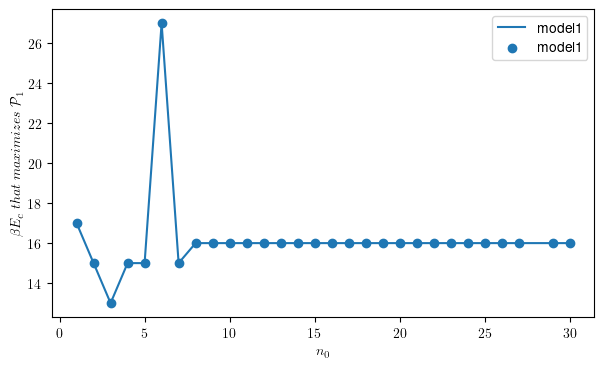

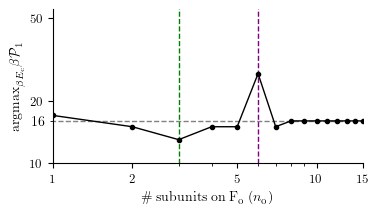

In [ ]:
# A plot of P vs n0 for different Ec

# Define arrays
Ecouple_array = [150.0]
model_array = ["model1"]
# model_array = ["model1"]
Ec_array = [12.0, 13.0, 14.0, 15.0]  # Can be adjusted as needed
n1_array = [3.0]
n0_array = [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0] 
n0_array = [1.0,2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,29.0,30.0] 
f0 = 4.0
n1=3.0
# Set up the figure
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

# Loop through each model
for model in model_array:
    # Define target directory and N based on model and f0
    if f0 == 8.0:
        if model == "model3":
            target_dir = "/Users/sarealles/Desktop/model3/new/pfe/"
            N = 1000
        elif model == "model4":
            target_dir = "/Users/sarealles/Desktop/model4/new/pfe/"
            N = 1000
        elif model == "model2":
            target_dir =  "/Users/sarealles/Desktop/Data/"
            N = 540
        else:
            target_dir =  "/Users/sarealles/Desktop/Data/"
            N = 540
    else: 
        if model == "model2":
            target_dir =  "/Users/sarealles/Desktop/Data/Data_processed/pfe/"
            
        if model == "model1":
            target_dir = "/Users/sarealles/Desktop/Data/Data_processed/pfe_old/"
            

    # Determine n0 and Ec values that maximize P1
    N = 540
    n0, Ec = which_Ec_maximizes_P1(target_dir, model, n0_array, N, n1, f0, dt=0.001, E0=2.0, E1=2.0, vs_n0=True)

    # Plot results

    ax.plot(n0, Ec, label=f"{model}")
    ax.scatter(n0, Ec, label=f"{model}")


# Add legend and show plot
ax.set_xlabel(r"$n_0$")
ax.set_ylabel(r"$\beta E_c \ that \ maximizes \ \mathcal{P}_1$")
ax.legend()
# fig.show()

model 2

In [ ]:
'''plotting n0 maximizing j1 vs Ec'''

def linear_func(x, m, c):
    return m * x + c

fig, ax = plt.subplots(2, 1, figsize=(9,7), sharey="row")
fig.suptitle(fr"$n_o (\ which \ maximizes \ J_1) \ vs. \ E_c$", fontsize=20)

fig2, ax2 = plt.subplots(1, 1, figsize=(9,6))
fig2.suptitle(fr"$model 2$", fontsize=15)

#model1
#f0 = 4


Ec_mod1_f0_4=[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 32.0, 40.0, 50.0, 60.0, 64.0, 70.0, 80.0, 90.0, 100.0, 120.0, 128.0, 130.0, 140.0, 150.0]
n0_mod1_f0_4= [5, 5, 5, 4, 4, 4, 5, 5, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

# ax.plot(n0_exists,P_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)


###############################model2##############################
##############################f0 = 4##############################


Ec_mod2_f0_4=[0.0, 1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0]
n0_mod2_f0_4=[1, 1, 2, 2, 4, 5, 6, 7, 9, 12, 14, 17, 19, 21, 23, 25]



Ec_mod2_f0_4=array([ 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0])
n0_mod2_f0_4=0.5*array([ 7, 9, 12, 14, 17, 19, 21, 23, 25])


Ec_mod2_f0_4=array([8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 15.0, 16.0])
n0_mod2_f0_4=0.5*array([8, 9, 10, 12, 13, 14, 15, 16, 17, 19, 20, 21, 23, 25])


Ec_mod2_f0_4=array([7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0] )
n0_mod2_f0_4=array( [3.30570578, 3.73750886, 4.20837149, 4.71245719, 5.2423991 , 5.80062701,6.37432942 ,6.95492983 ,7.53717696 ,8.11786159])
################################



x4 = np.array(Ec_mod2_f0_4)
y4 = np.array(n0_mod2_f0_4)

params, _ = curve_fit(linear_func, x4, y4)

m4 = params[0]
c4 = params[1]

fit_line4 = linear_func(x4, m4, c4)
ax[1].plot(x4, fit_line4, color='blue', label=f'fit: y = {m4:.2f}x + {c4:.2f}')
# Ec_mod2_f0_4=[1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 32.0, 40.0, 50.0, 60.0, 64.0, 70.0, 80.0, 90.0, 100.0, 120.0, 128.0, 130.0, 140.0, 150.0]
# n0_mod2_f0_4=[1, 2, 2, 4, 5, 6, 7, 9, 12, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15]

##############################f0=8##############################


Ec_mod2_f0_8=[0.0,1.0, 2.0, 4.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 32.0, 64.0, 128.0]
n0_mod2_f0_8=[1,1, 1, 2, 4, 5, 5, 7, 8, 9, 10, 10, 10, 10, 10, 10]



# Ec_mod2_f0_8=array([9.0, 10.0, 11.0, 12.0, 13.0, 14.0])
# n0_mod2_f0_8=array([5, 5, 7, 8, 9, 10])

Ec_mod2_f0_8=array([8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0]
)
n0_mod2_f0_8=array([ 4, 5, 5, 5, 7, 7, 8, 8, 9, 9, 10, 10, 11, 11, 12, 12])





Ec_mod2_f0_8=array([7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0])
n0_mod2_f0_8=array([3.49070732, 3.8879021, 4.338728, 4.90122742, 5.38739965, 5.98191815,
                         6.54793278, 7.12309947, 7.62018679, 8.18872586, 8.72879699, 9.26904467,
                         9.8103163, 10.33132681, 10.87149293, 11.38424697, 11.92426465, 12.43357781])


###################################

x8 = np.array(Ec_mod2_f0_8)
y8 = np.array(n0_mod2_f0_8)

params, _ = curve_fit(linear_func, x8, y8)

m8 = params[0]
c8 = params[1]

fit_line8 = linear_func(x8, m8, c8)
ax[1].plot(x8, fit_line8, color='blue', label=f'fit: y = {m8:.2f}x + {c8:.2f}')

####################################
'''the negative P1s are considered here'''
'''missing Ec=2,12'''
Ec_mod2_f0_8_E0_3=array([7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5]) 
n0_mod2_f0_8_E0_3=array([ 3.22335269,  3.28801389,  3.57892889,  3.98794371,  4.58939372,
        5.1331583 ,  5.67161033,  6.4292442 ,  7.09941323,  7.66101609,
        8.37302871,  9.14363052,  9.90163417, 10.55651874, 10.99202039,
       12.83360521, 13.19126932, 13.65507228])

##########
x8_E3 = np.array(Ec_mod2_f0_8_E0_3)
y8_E3 = np.array(n0_mod2_f0_8_E0_3)

params, _ = curve_fit(linear_func, x8_E3, y8_E3)

m8_E3 = params[0]
c8_E3 = params[1]

fit_line8_E3 = linear_func(x8_E3, m8_E3, c8_E3)
ax[1].plot(x8_E3, fit_line8_E3, color='orange', label=f'fit, E=3.0: y = {m8_E3:.2f}x + {c8_E3:.2f}')


##########################f0=4#################################
'''the negative P1s are considered here'''

'''there are missing data here n0=2,12 and also some Ec values. Still dont think its a big issue'''
'''There seems to be sth wrong'''
Ec_mod2_f0_4_E0_4=array([7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5])
n0_mod2_f0_4_E0_4=0.5*array([5.19544239, 6.11813851, 6.22564935, 7.1557028, 8.07102703, 9.0817,
          10.17029333, 10.91179633, 13.05756786, 13.92296511, 15.33454894,
          16.86713677, 18.49732555, 20.29558219, 22.23999847, 24.35069208, 
          26.65491671, 29.16724902])

'''there are missing data here n0=2,12 and also some Ec values. Still dont think its a big issue'''
'''There seems to be sth wrong'''
Ec_mod2_f0_4_E0_3=array([7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5])
n0_mod2_f0_4_E0_3=0.5*array([5.34466853, 5.99349707, 6.74827758, 7.63445512, 8.5993248, 9.65195728,
          10.61511237, 11.49120551, 13.27813158, 14.59926078, 16.04320311, 
          17.53253321, 19.13874761, 21.14217901, 22.49037753, 24.25239365, 
          26.02332044, 27.79043902])
'''raw data no smoothing,commented now'''
# Ec_mod2_f0_4_E0_3=array([7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0])
# n0_mod2_f0_4_E0_3=0.5*array([5, 6, 7, 8, 9, 10, 11, 11, 13, 15, 16, 18, 19, 21, 22, 24, 26, 28, 30])


Ec_mod2_f0_4_E0_1=array([5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0])
n0_mod2_f0_4_E0_1=0.5*array([ 4.00218793,  5.10525433,  6.53778905,  8.1895991,   9.92905351, 11.70033558,
 13.47806092, 15.27722009, 17.07382749, 18.87260474])

Ec_mod2_f0_4_E0_1=array([5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0])
n0_mod2_f0_4_E0_1=0.5*array([ 4.00218793 , 5.10525433,  6.53778905,  8.1895991 ,  9.92905351, 11.70033558,
 13.47806092, 15.27722009, 17.07382749, 18.87260474 ,20.67716234, 22.49036423,
 24.32308035, 26.16447989, 28.01458098])


Ec_mod2_f0_4_E0_0=array([5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0])
n0_mod2_f0_4_E0_0=0.5*array([ 4.03737083,  5.38998441 , 6.86310718 , 8.36429586 , 9.93619532, 11.51405409,
 13.15186976, 14.80051702, 16.46009841, 18.15464613])
Ec_mod2_f0_4_E0_0=array([5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0])
n0_mod2_f0_4_E0_0=0.5*array([ 4.03737083,  5.38998441,  6.86310718 , 8.36429586,  9.93619532, 11.51405409,
 13.15186976, 14.80051702, 16.46009841, 18.5 ,       20.5,        21.56781328, 23.29693778, 25.03790521, 26.78570385, 28.53929746])
#################################################

x4_E4 = np.array(Ec_mod2_f0_4_E0_4)
y4_E4 = np.array(n0_mod2_f0_4_E0_4)

params, _ = curve_fit(linear_func, x4_E4, y4_E4)

m4_E4 = params[0]
c4_E4 = params[1]

fit_line4_E4 = linear_func(x4_E4, m4_E4, c4_E4)
ax[1].plot(x4_E4, fit_line4_E4, color='purple', label=f'fit, E=3.0: y = {m4_E4:.2f}x + {c4_E4:.2f}')
############
x4_E3 = np.array(Ec_mod2_f0_4_E0_3)
y4_E3 = np.array(n0_mod2_f0_4_E0_3)

params, _ = curve_fit(linear_func, x4_E3, y4_E3)

m4_E3 = params[0]
c4_E3 = params[1]

fit_line4_E3 = linear_func(x4_E3, m4_E3, c4_E3)
ax[1].plot(x4_E3, fit_line4_E3, color='brown', label=f'fit, E=3.0: y = {m4_E3:.2f}x + {c4_E3:.2f}')
############
x4_E1 = np.array(Ec_mod2_f0_4_E0_1)
y4_E1 = np.array(n0_mod2_f0_4_E0_1)

params, _ = curve_fit(linear_func, x4_E1, y4_E1)

m4_E1 = params[0]
c4_E1 = params[1]

fit_line4_E1 = linear_func(x4_E1, m4_E1, c4_E1)
ax[1].plot(x4_E1, fit_line4_E1, color='green', label=f'fit, E=1.0: y = {m4_E1:.2f}x + {c4_E1:.2f}')
############
x4_E0 = np.array(Ec_mod2_f0_4_E0_0)
y4_E0 = np.array(n0_mod2_f0_4_E0_0)

params, _ = curve_fit(linear_func, x4_E0, y4_E0)

m4_E0 = params[0]
c4_E0 = params[1]

fit_line4_E0 = linear_func(x4_E0, m4_E0, c4_E0)
ax[1].plot(x4_E0, fit_line4_E0, color='red', label=f'fit, E=0.0: y = {m4_E0:.2f}x + {c4_E0:.2f}')
 #################################################
 ################ Model 1#######################
'''dont multiply the x axis by 0.5 or anything.
its the real f values. these values are for n0 = 8 and n1 = 3'''

Ec_mod1_E0_2=[8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0] 
f0_mod1_E0_2=[4.5,4.5,4.83170969,5.35578412,5.95008445,6.47634823,7.5]


Ec_mod1_E0_2=[7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0] 
f0_mod1_E0_2= [3.1682499,  3.5278435 , 4.49051873, 4.53768869, 5.15025296, 5.79502925,
 6.44460187, 7.0789306 ]

x_mod1_f0_E0_2 = np.array(Ec_mod1_E0_2)
ymod1__f0_E0_2 = np.array(f0_mod1_E0_2)

params, _ = curve_fit(linear_func, x_mod1_f0_E0_2, ymod1__f0_E0_2)

m_mod1_f0_E0_2 = params[0]
c_mod1_f0_E0_2 = params[1]

fit_line_mod1_f0_E0_2 = linear_func(x_mod1_f0_E0_2, m_mod1_f0_E0_2, c_mod1_f0_E0_2)

# ax2.scatter(Ec_mod1_E0_2,f0_mod1_E0_2,label=r"$mod1 \ \beta \mu_{o} $",marker ="o",color="orange", lw=1.0,s=80)
# ax2.plot(x_mod1_f0_E0_2, fit_line_mod1_f0_E0_2, color="orange",linestyle="dashed", label=fr'$mod1, \ fit: \beta \mu_o^* = {m_mod1_f0_E0_2:.2f}\ \beta E_c   {c_mod1_f0_E0_2:.2f}$')


########################################

ax[0].plot(Ec_mod1_f0_4,label=r"$\beta \mu_{o} = 4$",marker ="o",color="blue", lw=1.0,markersize=3)
# ax[0].plot(n0_mod1_f0_4,Ec_mod1_f0_4)
# ax[0].plot(n0_mod1_f0_4,Ec_mod1_f0_4)
ax[1].plot(Ec_mod2_f0_4[0:13],n0_mod2_f0_4[0:13],label=r"$\mu_{o,\frac{2\pi}{n_o}} = 0.5$",marker ="o",color="red", lw=1.0,markersize=3)
ax[1].plot(Ec_mod2_f0_8[9:11],n0_mod2_f0_8[9:11],label=r"$\mu_{o,\frac{2\pi}{n_o}} = 1$",marker ="o",color="green", lw=1.0,markersize=6)

ax2.scatter(Ec_mod2_f0_4,n0_mod2_f0_4,label=r"$\beta \mu_{o} = 0.5\times n_o $",marker ="o",color="cornflowerblue", lw=1.0,s=80)
ax2.plot(x4, fit_line4, color="cornflowerblue",linestyle="dashed", label=fr'$fit: \beta \mu_o^* = {m4:.2f}\ \beta E_c   {c4:.2f}$')


ax2.scatter(Ec_mod2_f0_8,n0_mod2_f0_8,label=r"$\beta \mu_{o} = n_o $",marker ="o",color="navy", lw=1.0,s=80)
ax2.plot(x8, fit_line8, color='navy',linestyle="dashed", label=fr'$fit: \beta \mu_o^* = {m8:.2f}\ \beta E_c   {c8:.2f}$')

ax2.scatter(Ec_mod2_f0_8_E0_3,n0_mod2_f0_8_E0_3,label=r"$E_o = 3.0,\beta \mu_{o} = n_o $",marker ="o",color="orange", lw=1.0,s=80)
ax2.plot(x8_E3, fit_line8_E3, color='orange',linestyle="dashed", label=fr'$fit: \beta \mu_o^* = {m8_E3:.2f}\ \beta E_c   {c8_E3:.2f}$')


ax2.scatter(Ec_mod2_f0_4_E0_4,n0_mod2_f0_4_E0_4,label=r"$E_o = 4.0,\beta \mu_{o} = 0.5\times n_o $",marker ="o",color="purple", lw=1.0,s=80)
ax2.plot(x4_E4, fit_line4_E4, color='purple',linestyle="dashed", label=fr'$fit: \beta \mu_o^* = {m4_E4:.2f}\ \beta E_c   {c4_E4:.2f}$')

ax2.scatter(Ec_mod2_f0_4_E0_3,n0_mod2_f0_4_E0_3,label=r"$E_o = 3.0,\beta \mu_{o} = 0.5\times n_o $",marker ="o",color="brown", lw=1.0,s=80)
ax2.plot(x4_E3, fit_line4_E3, color='brown',linestyle="dashed", label=fr'$fit: \beta \mu_o^* = {m4_E3:.2f}\ \beta E_c   {c4_E3:.2f}$')

ax2.scatter(Ec_mod2_f0_4_E0_1,n0_mod2_f0_4_E0_1,label=r"$E_o = 1.0,\beta \mu_{o} = 0.5\times n_o $",marker ="o",color="green", lw=1.0,s=80)
ax2.plot(x4_E1, fit_line4_E1, color='green',linestyle="dashed", label=fr'$fit: \beta \mu_o^* = {m4_E1:.2f}\ \beta E_c   {c4_E1:.2f}$')

ax2.scatter(Ec_mod2_f0_4_E0_0,n0_mod2_f0_4_E0_0,label=r"$E_o = 0.0,\beta \mu_{o} = 0.5\times n_o $",marker ="o",color="red", lw=1.0,s=80)
ax2.plot(x4_E0, fit_line4_E0, color='red',linestyle="dashed", label=fr'$fit: \beta \mu_o^* = {m4_E0:.2f}\ \beta E_c   {c4_E0:.2f}$')
#################
# ax2.plot(n0_mod2_f0_4,emma_E_star_prediction(n0_mod2_f0_4,-2),label=r"$: \beta E_c^* = 1.4\ \beta\Delta\mu_o + 6.11  $",marker ="s",color="green", lw=1.0)

##################
# ax2.plot(Ec_mod2_f0_8[9:11],n0_mod2_f0_8[9:11],label=r"$\Delta\mu_{o,\frac{2\pi}{n_o}} = 1$",marker ="o",color="green", lw=1.0,markersize=6)

# ax[0].set_xscale("log")
# ax[0].set_xscale("log")
ax[0].tick_params(labelsize=15, axis='both')
ax[0].set_ylabel(r"$n_o$", fontsize=15)
# ax[0].set_xticks(n1_exists)
# ax[0].set_xlabel(r"$E_c$", fontsize=15)
ax[0].legend()
ax[0].set_title(fr"$model \ 1$")

# ax2.text(12, 10, rf'$\beta \mu_o^* = {m4:.2f}\ \beta E_c   {c4:.2f}$', fontsize=18, color='black', rotation=36, ha='center', va='center')

# ax[1].set_xscale("log")
# ax[1].set_xscale("log")
ax[1].tick_params(labelsize=15, axis='both')
ax[1].set_ylabel(r"$n_o$", fontsize=15)
# ax[0].set_xticks(n1_exists)
ax[1].set_xlabel(r"$\beta E_c$", fontsize=15)
ax[1].legend()
ax[1].set_title(fr"$model \ 2$")

# ax2.set_xscale("log")
# ax2.set_yscale("log")
ax2.tick_params(labelsize=15, axis='both')
ax2.set_ylabel(r"$Driving \ Force^* (\beta\mu_{o}^*)$", fontsize=15)
# ax[0].set_xticks(n1_exists)
ax2.set_xlabel(r"$Coupling\ Strength (\beta E_c)$", fontsize=15)
ax2.legend()

# fig2.savefig("/Users/sarealles/Desktop/research/CM_Aug_2024/mu_star_vs_Ec.pdf")

# ax2.set_title(fr"$model \ 2$")

Trying to get a smoother transitions

In [ ]:
def around_maximum(target_dir,model,n0_array,n1_array,Ec_array,dt,N,E0,E1,vs_n0=True):
    
    Ecouple= []
    around_maximizing_n0 = []
    P_around_maximizing_n0 = []
    if vs_n0:
        for n1 in n1_array:
            for i,Ec in enumerate(Ec_array):
                n0_exists = []
                P_at_Ec = []
                P0_at_Ec = []
                eta_at_Ec = []
                eta_at_inf = []
                eta_Fo_wins = []
                j1_at_Ec = []
                jo_at_Ec = []

                
                for n0 in n0_array:
                    params = set_params_Fo_8(model, n0,n1,E0,E1)
                    n0n1_str = str(int(n0))+"_"+ str(int(n1))
                    target_dir_temp = target_dir + n0n1_str
                
                    [
                    E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                    m0, m1, phase,beta, gamma,__
                    ] = params

                    input_file_name = ("/" + model + "_flux_power_efficiency_"
                    + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    
                    if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                        continue

                    Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                    # Convert Ec_list to a list if it is a single value
                    if isinstance(Ec_list, float):
                        Ec_list = [Ec_list]
                        integrate_power_Y = [integrate_power_Y]
                        integrate_power_X = [integrate_power_X]
                        integrate_flux_X = [integrate_flux_X]
                        integrate_flux_Y = [integrate_flux_Y]
                        efficiency_mod = [efficiency_mod]
                        efficiency = [efficiency]

                    # print(integrate_power_Y)
                    for j in range(len(Ec_list)):
                        if Ec_list[j] == Ec:
                            n0_exists.append(int(n0))
                            P0_at_Ec.append(2*pi*integrate_power_X[j])
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            eta_at_Ec.append(efficiency_mod[j])
                            j1_at_Ec.append(integrate_flux_Y[j])
                            jo_at_Ec.append(integrate_flux_X[j])
                            eta_Fo_wins.append(efficiency[j])
                if len(n0_exists)!=0:
                    # print(f"Ec is :{Ec}")
                    Ecouple.append(Ec)
                    around_maximizing_n0.append([n0_exists[argmax(P_at_Ec)-1],n0_exists[argmax(P_at_Ec)], n0_exists[argmax(P_at_Ec)]+1])
                    P_around_maximizing_n0.append([P_at_Ec[argmax(P_at_Ec)-1],P_at_Ec[argmax(P_at_Ec)], P_at_Ec[argmax(P_at_Ec)+1]])
    return Ecouple,around_maximizing_n0,P_around_maximizing_n0

def der_func(x,y):
    der = (y[2]-y[0])/(x[2]-x[0])
    derder = (y[2]-2*y[1]+y[0])/(x[2]-x[1])
    
    return der,derder


# target_dir = "/Users/sarealles/Desktop/Data_processed/pfe_old/"

# target_dir="/Users/sarealles/Desktop/model2/data_540_probably_previously_downloaded_somewhere/f0_4/pfe/"

# target_dir = "/Users/sarealles/Desktop/model1/Data_N_360/cluster/pfe/"
# target_dir = "/Users/sarealles/Desktop/model1/Data_N_100/pfe/"
# target_dir ="/Users/sarealles/Desktop/model2/new_data_540_CM/f0_4/pfe/"
target_dir ="/Users/sarealles/Desktop/model2/new_data_540_CM/E0_3/f0_8/pfe/"

    
#individual plots for each model
Ec_array = [0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,32.0,40.0,50.0,64.0,70.0,80.0,90.0,128.0] 
# Ec_array = [8.0,9.0,10.0,11.0,12.0]

# Ec_array = np.array([9.0,10.0,11.0, 12.0])

# Ec_array = [7.0,7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0,11.5,12.0,12.5,13.0,13.5,14.0,14.5,15.0,15.5,16.0]
# Ec_array = [5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30., 31., 32., 40., 50., 60., 64., 70., 80., 90., 100., 120., 128., 130., 150.]
Ec_array = [5., 6., 7., 8., 9., 10., 11., 12., 13., 14.,15.0,16.0,17.0,18.0, 19.0]
Ec_array= [7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5]
# J1 maximizing n0 is: [5, 6, 7, 8, 9, 10, 11, 11, 13, 15, 16, 18, 19, 21, 22, 24, 26, 28, 30
# Ec is : [5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]
# j1 maximizing n0 is: [4, 5, 7, 8, 10, 12, 13, 15, 16, 18, 20, 22, 23, 25, 27, 29]

n1_array = [3.0]
n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0] 
# n0_array = [2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0] 
for model in ["model2"]:
    Ec_array,neigh_n0,neigh_P1 = around_maximum(target_dir, model,n0_array,n1_array,Ec_array,dt=0.001,N=540,E0=3.0,E1=3.0,vs_n0=True)

print(Ec_array)
print(neigh_n0) 
print(neigh_P1) 

n0_max = []
for i,Ec in enumerate(Ec_array):
    n0_assumed_max = neigh_n0[i][1]
    der,derder = der_func(neigh_n0[i],neigh_P1[i])
    n0_max.append(n0_assumed_max - (der/derder))
    
n0_max = array(n0_max)
print(f"Ec array is: {Ec_array} \n n0_max is {n0_max}")
    
    
    




model 1: driving force vs Ec

In [ ]:
def plot_DF_vs_Ec(target_dir,model,f0_array,n0,n1,Ec_array,dt,N,vs_n0=True):
    timescale = 1.5 * 10**4 
    #individually plotting for each model P vs no for various Ec values in one single plot

    #fig for P vs n0
    fig, ax = plt.subplots(1, 1, figsize=(5,5))
    #fig6 for P0 vs n0
    fig6, ax6 = plt.subplots(1, 1, figsize=(5,5))
    #fig1 for eta vs n0
    fig1, ax1 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for j1 vs n0
    fig2, ax2 = plt.subplots(1, 1, figsize=(5,5))
    #fig2 for jo vs n0
    fig5, ax5 = plt.subplots(1, 1, figsize=(5,5))
    #fig3 for jslip vs n0
    fig3, ax3 = plt.subplots(1, 1, figsize=(5,5))
    # #fig4 for eta if assume fo always wins
    fig4, ax4 = plt.subplots(1, 1, figsize=(5,5))
    #fig7 P1 vs. eta
    fig7, ax7 = plt.subplots(1, 2, figsize=(8,4), sharey="row")
    
    # ax.axhline(0.0,color="black", lw=1.0)
    # ax3.axhline(0.0,color="black", lw=1.0)
    # ax6.axhline(0.0,color="black", lw=1.0)
    # ax4.axhline(0.0,color="black", lw=1.0)
    # ax2.axhline(0.0,color="black", lw=1.0)
    # ax5.axhline(0.0,color="black", lw=1.0)
    # ax1.axhline(1.0,color="black", lw=1.0)
    
    index = int(model[-1])-1
    Ecouple= []
    maximizing_n0 = []
    if vs_n0:
        for n1 in n1:
            for i,Ec in enumerate(Ec_array):
                f0_exists = []
                P_at_Ec = []
                P0_at_Ec = []
                eta_at_Ec = []
                eta_at_inf = []
                eta_Fo_wins = []
                j1_at_Ec = []
                jo_at_Ec = []
                jslip_at_Ec = []
                
                for f0 in f0_array:
                    params = set_params(model, n0,n1,f0)
                    n0n1_str = str(int(n0))+"_"+ str(int(n1))
                    target_dir_temp = target_dir + n0n1_str
                    print(f"targetdir is {target_dir_temp}")
                
                    [
                    E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
                    m0, m1, phase,beta, gamma,__
                    ] = params
                    
                
                    # input_file_name = ("/" + model +"_dt_{7}_N_{8}"+ "_flux_power_efficiency_"
                    # + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    #change the input name
                    input_file_name = ("/" + model + "_flux_power_efficiency_"
                    + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
                    
                    if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase,dt,N)):
                        continue

                    Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
                    target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase,dt,N),unpack=True, usecols=(0,1,2,3,4,5,6))

                    # Convert Ec_list to a list if it is a single value
                    if isinstance(Ec_list, float):
                        Ec_list = [Ec_list]
                        integrate_power_Y = [integrate_power_Y]
                        integrate_power_X = [integrate_power_X]
                        integrate_flux_X = [integrate_flux_X]
                        integrate_flux_Y = [integrate_flux_Y]
                        efficiency_mod = [efficiency_mod]
                        efficiency = [efficiency]

                    # print(integrate_power_Y)
                    for j in range(len(Ec_list)):
                        if Ec_list[j] == Ec:
                            f0_exists.append(f0)
                            P0_at_Ec.append(2*pi*integrate_power_X[j])
                            P_at_Ec.append(-2*pi*integrate_power_Y[j])
                            eta_at_Ec.append(efficiency_mod[j])
                            j1_at_Ec.append(integrate_flux_Y[j])
                            jo_at_Ec.append(integrate_flux_X[j])
                            eta_Fo_wins.append(efficiency[j])
                            if model =="model3" or model=="model4":
                                jslip_at_Ec.append(n0*integrate_flux_X[j]-n1*integrate_flux_Y[j])
                            else:
                                jslip_at_Ec.append(integrate_flux_X[j]-integrate_flux_Y[j])
                                
                            
                    eta_at_inf.append(infinite_eff(psi_0,psi_1,n0,n1,model))
                print("J0: ",jo_at_Ec)
                print("J1: ",j1_at_Ec)
                print("eff is ",eta_at_Ec)
                print("f0: ",f0_exists)
                if len(f0_exists)!=0:
                    Ecouple.append(Ec)
                    maximizing_n0.append(f0_exists[argmax(j1_at_Ec)])
                # print(fr"at {Ec}, n0 that maximizes J1 is: {n0_exists[argmax(j1_at_Ec)]}")
                    
                if model =="model2" or model=="model4":
                    x = str(psi_0/8)
                    psi_0 = "\\frac{n_o}{2}"
                    psi_0 = "2"
                    f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                else:
                    # f_o = "\\left| \\frac{\\Delta \\mu_o}{\\Delta \\mu_1} \\right|"
                    f_o = "\\Delta \\mu_o"
                    
                fig.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax.plot(f0_exists,P_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax.tick_params(labelsize=15, axis='both')
                ax.set_xlabel(r"$\mu_{\rm o}$", fontsize=15)
                ax.set_xticks(f0_exists)
                ax.set_ylabel(r"$output \ power\ \beta\mathcal{P}_{1} \ [1/s]$", fontsize=15)
                #ax.legend(loc='upper right', prop={'size':12})

                fig1.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax1.plot(f0_exists,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                for i,e in enumerate(eta_at_Ec):
                    if e > 0.5:
                        print(fr"eta is {e} at Ec = {Ec}, n0 = {f0_exists[i]}")
                    
                        
                ax1.tick_params(labelsize=15, axis='both')
                ax1.set_xlabel(r"$\mu_{\rm o}$", fontsize=15)
                ax1.set_ylabel(r"$\eta$", fontsize=15)
                #ax1.legend(loc='upper right', prop={'size':12})
                
                fig7.suptitle(fr"${model} ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax7[0].plot(P_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax7[1].plot(P0_at_Ec,eta_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                # ax7[1].set_title(r"$\mathcal{P}_{o}$")
                # ax7[0].set_title(r"$\mathcal{P}_{1}$")
                ax7[0].tick_params(labelsize=15, axis='both')
                ax7[1].tick_params(labelsize=15, axis='both')
                ax7[0].set_xlabel(r"$\mathcal{P}_{1}$", fontsize=15)
                ax7[1].set_xlabel(r"$\mathcal{P}_{o}$", fontsize=15)
                ax7[0].set_ylabel(r"$\eta$", fontsize=15)
                
                fig2.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax2.plot(f0_exists,j1_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax2.tick_params(labelsize=15, axis='both')
                ax2.set_xlabel(r"$n_o$", fontsize=15)
                ax2.set_xticks(f0_exists)
                ax2.set_ylabel(r"$J_{1}$", fontsize=15)
                
                fig5.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax5.plot(f0_exists,jo_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax5.tick_params(labelsize=15, axis='both')
                ax5.set_xlabel(r"$n_o$", fontsize=15)
                ax5.set_xticks(f0_exists)
                ax5.set_ylabel(r"$J_{o}$", fontsize=15)
                
                fig3.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax3.plot(f0_exists,jslip_at_Ec, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax3.tick_params(labelsize=15, axis='both')
                ax3.set_xlabel(r"$n_o$", fontsize=15)
                ax3.set_xticks(f0_exists)
                ax3.set_ylabel(r"$J_{slip}$", fontsize=15)

                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                fig4.suptitle(fr"${model},\ \eta ,\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=12)
                ax4.plot(f0_exists,eta_Fo_wins, label = fr"${Ec}$",marker ="o",lw=1.0, markersize=8)
                ax4.tick_params(labelsize=15, axis='both')
                ax4.set_xlabel(r"$n_o$", fontsize=15)
                ax4.set_xticks(f0_exists)
                ax4.set_ylabel(r"$\eta_{Fo_wins}$", fontsize=15)


                fig6.suptitle(fr"${model},\ n_1 = {n1}, \ {f_o} = {psi_0}$", fontsize=15)
                ax6.plot(f0_exists,P0_at_Ec, label = fr"${Ec}$",marker ="o", lw=1.0,markersize=8)
                ax6.tick_params(labelsize=15, axis='both')
                ax6.set_xlabel(r"$n_o$", fontsize=15)
                ax6.set_xticks(f0_exists)
                ax6.set_ylabel(r"$\mathcal{P}_{o}$", fontsize=15)
                
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax.spines['right'].set_visible(False)
                ax.spines['bottom'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax2.spines['right'].set_visible(False)
                ax2.spines['bottom'].set_visible(False)
                ax2.spines['top'].set_visible(False)
                
                ax5.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax5.spines['right'].set_visible(False)
                ax5.spines['bottom'].set_visible(False)
                ax5.spines['top'].set_visible(False)
                
                ax7[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[0].spines['right'].set_visible(False)
                ax7[0].spines['bottom'].set_visible(False)
                ax7[0].spines['top'].set_visible(False)
                ax7[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                # ax7[1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
                ax7[1].spines['right'].set_visible(False)
                ax7[1].spines['bottom'].set_visible(False)
                ax7[1].spines['top'].set_visible(False)
                
                ax6.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax6.spines['right'].set_visible(False)
                ax6.spines['bottom'].set_visible(False)
                ax6.spines['top'].set_visible(False)
                
                ax4.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax4.spines['right'].set_visible(False)
                ax4.spines['bottom'].set_visible(False)
                ax4.spines['top'].set_visible(False)
                
                ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax3.spines['right'].set_visible(False)
                ax3.spines['bottom'].set_visible(False)
                ax3.spines['top'].set_visible(False)
                
                ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
                ax1.spines['right'].set_visible(False)
                ax1.spines['bottom'].set_visible(False)
                ax1.spines['top'].set_visible(False)
                
                ax.set_xscale("log")
                ax1.set_xscale("log")
                ax2.set_xscale("log")
                ax3.set_xscale("log")
                ax4.set_xscale("log")
                ax5.set_xscale("log")
                ax6.set_xscale("log")
                ax7[0].set_xscale("symlog")
                ax7[1].set_xscale("symlog")
                
            
                #ax.set_yscale("log")
            # ax1.plot(n0_array, eta_at_inf, label=fr"$E_{{\infty}}$", color="black", markersize=15)
        
        ax.legend(prop={'size': 12}, title='$E_c$', frameon=False, ncol=2, labelspacing=0.05,
            bbox_to_anchor=(0.31, 0.6), loc='center')
        # ax.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax1.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax2.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax3.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax4.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax6.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax5.legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        ax7[0].legend(prop={'size':12},title='$E_c$', frameon= False, labelspacing=1)
        # fig.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_P_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig1.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_eta_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        # fig2.savefig(fr"/Users/sarealles/Desktop/Data/individual_{model}_J1_vs_n0_Ec_{Ec}_n1_{n1}_fo_{psi_0}.pdf")
        
        print("Ec is :", Ecouple)
        print("j1 maximizing n0 is:", maximizing_n0)
        plt.show()
        
    

In [ ]:
#A plot of P vs n0 for different Ec

Ecouple_array = [150.0]
model_array = ["model1", "model2","model3","model4"]
#model_array = ["model2"]
# target_dir = "/Users/sarealles/Desktop/Data_processed/pfe_old/"
target_dir ="/Users/sarealles/Desktop/model1/DF_vs_Ec/pfe/"
# target_dir="/Users/sarealles/Desktop/model2/data_540_probably_previously_downloaded_somewhere/f0_4/pfe/"

# target_dir = "/Users/sarealles/Desktop/model1/Data_N_360/cluster/pfe/"
# target_dir = "/Users/sarealles/Desktop/model1/Data_N_100/pfe/"

    
#individual plots for each model
Ec_array = [0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,32.0,40.0,50.0,64.0,70.0,80.0,90.0,128.0] 
# Ec_array = [8.0,9.0,10.0,11.0,12.0]

# Ec_array = np.array([9.0,10.0,11.0, 12.0])

Ec_array = [7.5,8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0]


f0_array = [1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0]
n1_array = [3.0]
n0=8.0
# n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0] 
# n0_array = [1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0] 
for model in ["model1"]:
    plot_DF_vs_Ec(target_dir, model,f0_array,n0,n1_array,Ec_array,dt=0.001,N=540,vs_n0=True)
    plt.show()  


## model 1: Finding the true maximum for obove plots

In [ ]:
def around_maximum_mod1(target_dir,model,f0_array,n0,n1,Ec_array,E0,E1):
    
    Ecouple= []
    around_maximizing_n0 = []
    P_around_maximizing_n0 = []


    for i,Ec in enumerate(Ec_array):
        f0_exists = []
        P_at_Ec = []
        P0_at_Ec = []
        eta_at_Ec = []
        eta_at_inf = []
        eta_Fo_wins = []
        j1_at_Ec = []
        jo_at_Ec = []

        
        for f0 in f0_array:
            params = set_params(model, n0,n1,f0,E0,E1)
            n0n1_str = str(int(n0))+"_"+ str(int(n1))
            target_dir_temp = target_dir + n0n1_str
        
            [
            E0, __,E1, psi_0, psi_1,psi_0_n, psi_1_n, __, __,
            m0, m1, phase,beta, gamma,__
            ] = params

            input_file_name = ("/" + model + "_flux_power_efficiency_"
            + "E0_{0}_E1_{1}_psi0_{2}_psi1_{3}_n0_{4}_n1_{5}_phase_{6}_outfile.dat")
            
            if not os.path.exists(target_dir_temp + input_file_name.format(E0, E1, psi_0, psi_1, n0, n1, phase)):
                continue
            # print("input file name", input_file_name)
            Ec_list,integrate_flux_X, integrate_flux_Y,integrate_power_X, integrate_power_Y, efficiency,efficiency_mod= loadtxt(
            target_dir_temp + input_file_name.format(E0,E1, psi_0, psi_1, n0,n1,phase),unpack=True, usecols=(0,1,2,3,4,5,6))

            # Convert Ec_list to a list if it is a single value
            if isinstance(Ec_list, float):
                Ec_list = [Ec_list]
                integrate_power_Y = [integrate_power_Y]
                integrate_power_X = [integrate_power_X]
                integrate_flux_X = [integrate_flux_X]
                integrate_flux_Y = [integrate_flux_Y]
                efficiency_mod = [efficiency_mod]
                efficiency = [efficiency]

            # print(integrate_power_Y)
            for j in range(len(Ec_list)):
                if Ec_list[j] == Ec:
                    f0_exists.append(f0)
                    P0_at_Ec.append(2*pi*integrate_power_X[j])
                    P_at_Ec.append(-2*pi*integrate_power_Y[j])
                    eta_at_Ec.append(efficiency_mod[j])
                    j1_at_Ec.append(integrate_flux_Y[j])
                    jo_at_Ec.append(integrate_flux_X[j])
                    eta_Fo_wins.append(efficiency[j])
        if len(f0_exists)!=0:
            Ecouple.append(Ec)
            print("f0 array is", f0_exists)
            arg = argmax(P_at_Ec)
            around_maximizing_n0.append([f0_exists[arg-1],f0_exists[arg], f0_exists[arg+1]])
            P_around_maximizing_n0.append([P_at_Ec[arg-1],P_at_Ec[arg], P_at_Ec[arg+1]])
    return Ecouple,around_maximizing_n0,P_around_maximizing_n0

def der_func(x,y):
    der = (y[2]-y[0])/(x[2]-x[0])
    derder = (y[2]-2*y[1]+y[0])/(x[2]-x[1])
    
    return der,derder


# target_dir = "/Users/sarealles/Desktop/Data_processed/pfe_old/"

# target_dir="/Users/sarealles/Desktop/model2/data_540_probably_previously_downloaded_somewhere/f0_4/pfe/"

# target_dir = "/Users/sarealles/Desktop/model1/Data_N_360/cluster/pfe/"
# target_dir = "/Users/sarealles/Desktop/model1/Data_N_100/pfe/"
# target_dir ="/Users/sarealles/Desktop/model2/new_data_540_CM/f0_4/pfe/"
target_dir ="/Users/sarealles/Desktop/model2/new_data_540_CM/E0_1/f0_4/pfe/"
target_dir ="/Users/sarealles/Desktop/model1/DF_vs_Ec/pfe/"
    
#individual plots for each model
Ec_array = [0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,32.0,40.0,50.0,64.0,70.0,80.0,90.0,128.0] 
# Ec_array = [8.0,9.0,10.0,11.0,12.0]

# Ec_array = np.array([9.0,10.0,11.0, 12.0])

# Ec_array = [7.0,7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0,11.5,12.0,12.5,13.0,13.5,14.0,14.5,15.0,15.5,16.0]
# Ec_array = [5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30., 31., 32., 40., 50., 60., 64., 70., 80., 90., 100., 120., 128., 130., 150.]
# Ec_array = [5., 6., 7., 8., 9., 10., 11., 12., 13., 14.,15.0,16.0,17.0,18.0, 19.0]
Ec_array = [7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0]
f0_array = [1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0]
n0 = 8.0
n1 = 3.0
for model in ["model1"]:
    Ec_array,neigh_n0,neigh_P1 = around_maximum_mod1(target_dir, model,f0_array,n0,n1,Ec_array,E0=2.0,E1=2.0)

print(Ec_array)
print(neigh_n0) 
print(neigh_P1) 

n0_max = []
for i,Ec in enumerate(Ec_array):
    n0_assumed_max = neigh_n0[i][1]
    der,derder = der_func(neigh_n0[i],neigh_P1[i])
    n0_max.append(n0_assumed_max - (der/derder))
    
n0_max = array(n0_max)
print(Ec_array,n0_max)
    
    
    




# coming up with theory

In [ ]:
def potential(E0,E1,Ec,n0,n1,mu0,mu1,x0,x1):
    V = -0.5*E0*cos(n0*x0) -0.5*E0*cos(n1*x1) -0.5*Ec*cos(x0-x1) 


x = np.arange(0, 2*pi+2*pi/6, 2*pi/6)
x

## finish one F0

In [ ]:
import random




def potential(Ec,n0,x0,x1):
    V = -cos(n0*x0) -cos(3*x1) -0.5*Ec*cos(x0-x1) 
    return V

def rate1(x0,x1,n0,Ec):
    counter = 1
    denom = 1
    res = [1]
    while counter <= n0/3:
        m = np.exp(-(potential(Ec,n0,(x0+counter)*(2*pi/n0),x1*(2*pi/3)) - potential(Ec,n0,x0*(2*pi/n0),x1*(2*pi/3))-counter*mu0_n*n0*2*pi/n0))
        counter += 1
        denom += m
        res.append(m)
    
    return array(res)/denom

def rate2(x0,x1,n0,Ec):
    remain = 1
    m1 = np.exp(-(potential(Ec,n0,x0*(2*pi/n0),(x1+1)*(2*pi/3)) - potential(Ec,n0,x0*(2*pi/n0),x1*(2*pi/3))-mu1*2*pi/3))
    denom = 1 + m1 
    return 1/denom, m1/denom

def calculate_time_to_state(n0,Ec):
    current_state = 0
    current_state_1 = 0
    time = 0
    traj = [0]
    traj_1 = [0]
    options = arange(0,(n0/3)+1)

    # w = n*0.5/2
    while current_state < n0:
    
        # Flip a coin

        # print("rate1: ",r,m1,m2)
        coin_flip = int(random.choices(options,weights=rate1(current_state%n0,current_state_1%3,n0,Ec))[0])
        # print("flip1",coin_flip)
        
        current_state += coin_flip
        
            
        if current_state%n0 -current_state_1 >= int(n0/3):
            r,m1 = rate2(current_state%n0,current_state_1%3,n0,Ec)
            # print("rate2 :",r,m1)
            coin_flip = random.choices(["r","m"],weights=[r,m1])[0]
            # print(coin_flip)
            if coin_flip  == "m" :
                    # print("moved")
                    current_state_1 += 1
                
        
        
        
        # If we have stayed at the current state for 2 seconds, move to the next state
        # print("states:", current_state,current_state_1)
        traj.append(current_state%n0)
        traj_1.append(current_state_1%3)
        
        # print(traj,traj_1)
    
    return traj, traj_1



def is_subsequence_in_list(sequence, lst):
    sequence_str = ''.join(map(str, sequence))
    lst_str = ''.join(map(str, lst))
    return sequence_str in lst_str


def counting(x,n):
    i = 0
    c = 0
    while i<n:
        c += x.count(i)
        i+=1
    return c
        
        



traj_array = []
inch = 0
slip = 0
eff = []
P1 = []

E0=E1=2
mu0_n=1
mu1=-2
eff_list = []
P1_list = []
P0_list = []
Ec = 12

n0_list = [3,6,9,12,15,18,21,30]

for n0 in n0_list:
    inch = 0
    slip = 0

    eff_2 = array([])
    P1 = array([])
    P0 = array([])

    for run in range(1000):
        x0,x1 = calculate_time_to_state(n0,Ec)
        # print(x0,x1)
        
        P0 = np.append(P0, 1/counting(x0,n0))
        
        
        if is_subsequence_in_list([2,0], x1):
            # print("yes")
            P1 = np.append(P1, 1/counting(x1,3))
            eff_2 = np.append(eff_2 , (1 + (x1[-1]/3))/(1 + (x0[-1]/n0)))
            inch +=1
            

        else: 
            P1 = np.append(P1, (x1[-1]/3)/counting(x1,3))
            eff_2 = np.append(eff_2, (x1[-1]/3)/(1 + (x0[-1]/n0)) )
            slip +=1
    # eff_list.append(float(round(np.mean(eff_2)*(2/(n0*mu0_n)), 2)))
    P0_list.append(float(round(mu0_n*n0*np.mean(P0), 2)))
    P1_list.append(float(round(-mu1*np.mean(P1), 2)))
    eff_list.append(float(round(np.mean(eff_2), 2)))
            
        # traj_array.append([x0,x1])
    eff.append(inch/(inch+slip))

    
eff_list,P1_list,P0_list

plt.xscale("log")
# plt.plot(n0_list, eff_list, label="eff")
plt.plot(n0_list, P1_list, label="p1")
# plt.plot(n0_list, P0_list, label="p0")
plt.legend()

In [ ]:
from math import ceil
import random

## finish one F1

In [ ]:

def potential(Ec,n0,x0,x1):
    V = -cos(n0*x0) -cos(3*x1) -0.5*Ec*cos(x0-x1) 
    # V = -0.5*Ec*cos(x0-x1) 
    return V

def rate1(x0,x1,n0,Ec):
    # counter = 1
    # denom = 1
    # res = [1]
    # while counter <= n0/3:
    #     m = np.exp(-(potential(Ec,n0,(x0+counter)*(2*pi/n0)-(pi/n0),x1*(2*pi/3)) - potential(Ec,n0,x0*(2*pi/n0),x1*(2*pi/3))-counter*mu0_n*n0*2*pi/n0))
    #     counter += 1
    #     denom += m
    #     res.append(m)
    
    # return array(res)/denom

    m1 = np.exp(-(potential(Ec,n0,(x0+0.5)*(2*pi/n0),x1*(2*pi/3)) - potential(Ec,n0,x0*(2*pi/n0),x1*(2*pi/3))-mu0_n*n0*pi/n0))
    denom = 1 + m1
    return 1/denom, m1/denom

def rate2(x0,x1,n0,Ec):
    m1 = np.exp(-(potential(Ec,n0,x0*(2*pi/n0),(x1+0.5)*(2*pi/3)) - potential(Ec,n0,x0*(2*pi/n0),x1*(2*pi/3))-mu1*pi/3))
    denom = 1 + m1 
    return 1/denom, m1/denom


'''moves 1,2,3... steps ahead'''
def calculate_time_to_state(n0,Ec):
    current_state = 0
    current_state_1 = 0
    
    traj = [0]
    traj_1 = [0]
    options = arange(0,ceil(n0//3)+1)
    options = [0,1]
    movement = 0
    # w = n*0.5/2
    while current_state_1 < 3:
        # print(f"F0:{current_state}, F1={current_state_1}")
        current_state_prev = current_state
        # Flip a coin

        # print("rate1: ",r,m1,m2)
        coin_flip = int(random.choices(options,weights=rate1(current_state,current_state_1,n0,Ec))[0])
        # print("flip1",coin_flip)
        
        current_state += coin_flip
        
        
        delta = current_state - current_state_prev
        if delta >0:
            movement += delta
        if delta < 0: 
            movement += n0+delta
        current_state %= n0
            
        # if current_state%n0 -current_state_1 >= int(ceil(n0//3)):
        if current_state/n0 -current_state_1/3 >= (1/3) :
            # dx = current_state/n0 - current_state_1/3
            r,m1 = rate2(current_state,current_state_1,n0,Ec)
            coin_flip = random.choices(["r","m"],weights=[r,m1])[0]
            # if dx >= 1/3 :
            #     r,m1 = rate2(current_state,current_state_1,n0,Ec)
            #     coin_flip = random.choices(["r","m"],weights=[r,m1])[0]
            # elif dx<0:
            #     r,m1 = rate2(current_state+n0,current_state_1,n0,Ec)
            #     coin_flip = random.choices(["r","m"],weights=[r,m1])[0]
            # else:
            #     coin_flip = "dud"
                
            # print("rate2 :",r,m1)
            
            # print(coin_flip)
            if coin_flip  == "m" :
                    # print("moved")
                    current_state_1 += 1
        current_state_1 %= 3
                
        
        
        # If we have stayed at the current state for 2 seconds, move to the next state
        # print("states:", current_state,current_state_1)
        traj.append(current_state)
        traj_1.append(current_state_1)
        
        # print(traj,traj_1,movement)
    
    return traj, traj_1,movement


'''can only jump one state'''
def calculate_time_to_state_one(n0,Ec):
    current_state = 0
    current_state_1 = 0
    move_or_not = 1/3
    
    traj = [0]
    traj_1 = [0]
    options = arange(0,ceil(n0//3)+1)
    movement = 0
    # w = n*0.5/2
    while current_state_1 < 3:
        
        current_state_prev = current_state
        # Flip a coin

        # print("rate1: ",r,m1,m2)
        cs = current_state%n0
        cs_1 = current_state_1%3
        r,m1 = rate1(cs,cs_1,n0,Ec)
        # print("rate1:", r,m1)
        coin_flip = int(random.choices([0,1],weights=[r,m1])[0])
        # print("flip1",coin_flip)
        
        current_state += coin_flip
        current_state %= n0
        print(f"F0:{current_state}")
        
        delta = current_state - current_state_prev
        movement += delta
        # if delta >0:
        #     movement += delta
        # if delta < 0: 
        #     movement += n0+delta

        criteria = current_state/n0 -current_state_1/3 
        criteria_1 = current_state%n0/n0 -current_state_1%3/3 
        if criteria!= criteria_1: 
            print(f"no = {n0},F0: {current_state},  F1: {current_state_1}")  
            print("criteria",criteria) 
            print("criteria_1",criteria_1)  
            
        if  criteria_1 >= move_or_not:
            cs = current_state%n0
            cs_1 = current_state_1%3
            r,m1 = rate2(cs,cs_1,n0,Ec)
            # print("rate2 :",r,m1)
            coin_flip = random.choices(["r","m"],weights=[r,m1])[0]
            # print(coin_flip)
            if coin_flip  == "m" :
                    # print("moved")
                    current_state_1 += 1
        print(f"F1={current_state_1}")
                
        
        
        # If we have stayed at the current state for 2 seconds, move to the next state
        # print("states:", current_state,current_state_1)
        # print(f"F0:{current_state}, F1={current_state_1}")
        traj.append(current_state%n0)
        traj_1.append(current_state_1%3)
        
        print(traj,traj_1,movement)
    
    return traj, traj_1,movement

def is_subsequence_in_list(sequence, lst):
    sequence_str = ''.join(map(str, sequence))
    lst_str = ''.join(map(str, lst))
    return sequence_str in lst_str


def counting(x,n):
    i = 0
    c = 0
    while i<n:
        c += x.count(i)
        i+=1
    return c
        
        



traj_array = []
inch = 0
slip = 0
eff = []
P1 = []

E0=E1=2
mu0_n=0.5
mu1=-2


Ec_list = [12]
n0_list = [6]

# Ec_list = [8,12,16,24]
# n0_list = [6,9,12,15,18,21,24,27,30]

P1_all = []
P0_all = []

# Ec_list = [12]
# n0_list = [6]

for Ec in Ec_list:
    eff_list = []
    P1_list = []
    P0_list = []
    for n0 in n0_list:
        inch = 0
        slip = 0

        eff_2 = array([])
        P1 = array([])
        P0 = array([])

        for run in range(1):
            x0,x1,movement = calculate_time_to_state_one(n0,Ec)
            # print(x0,x1)
            # time = counting(x1,3)
            time = len(x1)
            P1 = np.append(P1, 1/time)
            P0 = np.append(P0, (movement/n0)/time)
            
            
            # if is_subsequence_in_list([2,0], x1):
            #     # print("yes")
            #     P1 = np.append(P1, 1/counting(x1,3))
            #     eff_2 = np.append(eff_2 , (1 + (x1[-1]/3))/(1 + (x0[-1]/n0)))
            #     inch +=1
                

            # else: 
            #     P1 = np.append(P1, (x1[-1]/3)/counting(x1,3))
            #     eff_2 = np.append(eff_2, (x1[-1]/3)/(1 + (x0[-1]/n0)) )
            #     slip +=1
        # eff_list.append(float(round(np.mean(eff_2)*(2/(n0*mu0_n)), 2)))
        P0_list.append(float(round(mu0_n*n0*np.mean(P0), 2)))
        P1_list.append(float(round(-mu1*np.mean(P1), 2)))
        
        # eff_list.append(float(round(np.mean(eff_2), 2)))
                
            # traj_array.append([x0,x1])
        # eff.append(inch/(inch+slip))
    print(P1_list,P0_list)    
    P1_all.append(P1_list)
    P0_all.append(P0_list)
    
eff_list = (array(P1_all)/array(P0_all))  

print(eff_list)




In [ ]:

P0_all = array(P0_all)
for i,Ec in enumerate(Ec_list):
    plt.xscale("log")
    # plt.plot(n0_list, eff_list[i], label=f"Ec = {Ec}")
    # Fit a curve to n0_list and P1_all[i]
    coefficients = np.polyfit(n0_list, P1_all[i], deg=2)
    curve_fit = np.poly1d(coefficients)

    # Plot the curve
    # plt.plot(n0_list, curve_fit(n0_list), label=f"Curve Fit, Ec = {Ec_list[i]}")
    plt.scatter(n0_list, P1_all[i], label=f"p1, Ec = {Ec}")
    plt.plot(n0_list, P1_all[i])
    # plt.plot(n0_list, 2*pi*P0_all[i], label=f"Ec = {Ec}")
    plt.legend()
plt.show()

# eff_list


In [ ]:
[0.749599,0.742046,0.583625,0.566364,0.586596,0.611198,0.629218,0.643905,0.654257,0.662662]

In [ ]:
options = arange(0,(6//3)+1)
options

### Fig 5.10